<a href="https://colab.research.google.com/github/Hamid-Ghalandari/XAI/blob/main/Obesity_in_NHANES_(Binary_classification)_(Edited_Version%2BABM).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Initiation

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from IPython import display
display.Javascript("google.colab.output.setIframeHeight('100px');")

<IPython.core.display.Javascript object>

In [3]:
# @title Installing some necessary packages

# !pip install scikit-learn
# !pip install --upgrade scikit-learn
# !pip install boruta
!pip install prince
# !pip install prince --upgrade
# !pip install streamlit
!pip install semopy
# !pip install cmdstanpy
# from cmdstanpy import install_cmdstan
# install_cmdstan()
# !pip uninstall -y scikit-learn
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.3/417.3 kB 24.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 9.1 MB/s eta 0:00:00
  Created wheel for semopy: filename=semopy-2.3.11-py3-none-any.whl size=1659681 sha256=4484f77adb41e0c69bd2ac77aa06a00744c59464f7170b1d2c753fdd07571c9a
  Stored in directory: /root/.cache/pip/wheels/d2/9a/31/fae291ff6a649bad125037eef8c7cc63d8c542e14bdcccea37
Successfully built semopy


In [4]:
# @title Importing the packages

import pandas as pd
import numpy as np
# import streamlit as st

In [5]:
# @title requirements.txt

# Open and read the file
with open('/content/drive/MyDrive/requirements.txt', 'r') as file:
    content = file.read()

# Print the content of the file
print(content)


streamlit
pandas
numpy


In [6]:
# @title Loading the main dataset

# %%capture

import pandas as pd
import numpy as np
crude_dataset = pd.read_excel('/content/drive/MyDrive/2017-prepand NHANES datasets/Relevant Dataset_New_1.xlsx')
crude_dataset.set_index('SEQN', inplace=True)
crude_dataset

,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,DMDBORN4,DMDEDUC2,DMDMARTZ,RIDEXPRG,INDFMPIR,ALQ130,...,DR2T_D_MILK,DR2T_D_YOGURT,DR2T_D_CHEESE,DR2T_OILS,DR2T_SOLID_FATS,DR2T_ADD_SUGARS,DR2T_A_DRINKS,DR1TSODI,DR2TSODI,DR1TCHOL
SEQN,,,,,,,,,,,,,,,,,,,,,
109266,2,29,5,6,2,5.0,3.0,2.0,5.00,1.0,...,0.08,0.29,2.17,30.83,25.44,1.51,0.00,2001.0,3439.0,120
109267,2,21,2,2,2,4.0,3.0,3.0,5.00,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
109268,2,18,3,3,1,NaN,NaN,NaN,1.66,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
109271,1,49,3,3,1,2.0,3.0,NaN,NaN,NaN,...,0.35,0.00,1.63,49.54,115.34,30.97,0.00,5446.0,6157.0,269
109273,1,36,3,3,1,4.0,3.0,NaN,0.83,NaN,...,4.07,0.00,0.00,32.03,51.88,11.84,0.00,1990.0,2949.0,114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124815,1,52,4,4,1,4.0,2.0,NaN,5.00,1.0,...,0.00,0.00,0.00,1.60,1.89,1.09,2.02,3415.0,1541.0,699
124817,2,67,1,1,2,2.0,1.0,NaN,2.19,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1129.0,NaN,813
124818,1,40,4,4,1,5.0,1.0,NaN,3.82,2.0,...,0.55,0.00,2.57,28.76,67.08,46.32,0.00,7742.0,6120.0,220


In [7]:
crude_dataset.columns.to_list()

['RIAGENDR',
 'RIDAGEYR',
 'RIDRETH1',
 'RIDRETH3',
 'DMDBORN4',
 'DMDEDUC2',
 'DMDMARTZ',
 'RIDEXPRG',
 'INDFMPIR',
 'ALQ130',
 'BMDSTATS',
 'BMXWT',
 'BMIWT',
 'BMXHT',
 'BMIHT',
 'BMXBMI',
 'BMDBMIC',
 'BMXWAIST',
 'BMIWAIST',
 'BMXHIP',
 'BMIHIP',
 'BPXOSY1',
 'BPXODI1',
 'BPXOSY2',
 'BPXODI2',
 'BPXOSY3',
 'BPXODI3',
 'CBQ506',
 'CBQ536',
 'CBQ541',
 'CBQ551',
 'CBQ581',
 'CBQ586',
 'CBQ830',
 'CBQ835',
 'CBQ840',
 'CBQ845',
 'CBQ850',
 'CBQ855',
 'CBQ860',
 'CBQ865',
 'CBQ870',
 'CBQ875',
 'CBQ880',
 'CBQ885',
 'CBQ890',
 'CBQ895',
 'CBQ900',
 'CBQ645',
 'CBQ700',
 'DBQ780',
 'DBQ750',
 'DBQ760',
 'DBQ770',
 'CBQ905',
 'CBQ910',
 'CBQ685',
 'CBQ915',
 'CBD925',
 'CBQ930',
 'CBQ935',
 'CBQ945',
 'CBQ950',
 'CBQ695A',
 'CBQ695B',
 'CBQ695C',
 'DBQ010',
 'DBD030',
 'DBQ700',
 'CBQ596',
 'CBQ611',
 'DIQ010',
 'DIQ160',
 'DPQ010',
 'DPQ020',
 'DPQ030',
 'DPQ040',
 'DPQ050',
 'DPQ060',
 'DPQ070',
 'DPQ080',
 'DPQ090',
 'DPQ100',
 'DR1DRSTZ',
 'DBD100',
 'DRQSDIET',
 'DR1TKCAL',
 'DR1TP

In [8]:
#%% Deleting the rows with no information regarding the outcome (i.e. BMI)

%%capture

crude_dataset = crude_dataset.dropna(subset=['BMXBMI'])
crude_dataset

In [9]:
# print(crude_dataset['WHQ030M'].describe())
# print(crude_dataset['WHQ030M'].isna().sum())

# List of unnecessary objects(need to be dropped after the preprocessing is complete):


RIDEXPRG (Pregnancy satus)**
BMDSTATS (Body Measures Component Status Code)
BMXWT (Weight (kg))
BMIWT (Weight Comment)**
BMXHT (Standing Height (cm))
BMIHT (Standing Height Comment)**
BMDBMIC (BMI Category - Children/Youth)
BPXOSY1 (Systolic - 1st oscillometric reading)
BPXODI1 (Diastolic - 1st oscillometric reading)
BPXOSY2 (Systolic - 2nd oscillometric reading)
BPXODI2 (Diastolic - 2nd oscillometric reading)
BPXOSY3 (Systolic - 3rd oscillometric reading)
BPXODI3 (Diastolic - 3rd oscillometric reading)
DPQs (DPQ010 - 100)**
DR1DRSTZ (Dietary recall status(day1))**
DR2DRSTZ (Dietary recall status(day2))**
**!!! DO NOT FORGET to also remove the related dietary data of day 1 if only the dietary data of the first day is used!!!**

ECD010 (Mother's age when born)
ECD070B (Weight at birth, ounces)
ECQ080 (Weight more/less than 5.5 lbs)
ECQ090 (Weight more/less than 9.0 lbs)

MCQ160B (Ever told had congestive heart failure)**
MCQ170M (Do you still have thyroid problem) **bold text** Studies seem inconsisitent in showing having a thyroid problem is associated with disturbed anthropometric measurements. Moreover, the 'problems' are not specified.
MCQ170L (Do you still have a liver condition)
MCQ371A (Are you now controlling or losing weight)
MCQ371B (Are you now increasing exercise)
MCQ371C (Are you now reducing salt in diet)
MCQ371D (Are you now reducing fat in diet)

[PAQ610 (Number of days vigorous work)
PAD615 (Minutes vigorous-intensity work)
PAQ625 (Number of days moderate work)
PAD630 (Minutes moderate-intensity work)
PAQ640 (Number of days walk or bicycle)
PAD645 (Minutes walk/bicycle for transportation)
PAQ655 (Days vigorous recreational activities)
PAD660 (Minutes vigorous recreational activities)
PAQ670 (Days moderate recreational activities)
PAD675 (Minutes moderate recreational activities)]
**These physical activity attributes should be removed before data imputation. They contain a very high level of missing values.**

SLQ300 (Usual sleep time on weekdays or workdays)
SLQ310 (Usual wake time on weekdays or workdays)
SLQ320 (Usual sleep time on weekends)
SLQ330 (Usual wake time on weekends)

WHQ060 (Weight change intentional)
WHD080A - L (the methods of trying to lose weight) (21 variables)
WHQ030M (How do you consider your weight) **No valid data!! All missing!**
WHQ500 (Trying to do about weight) **No valid data!! All missing!**
WHQ520 (How often tried to lose weight) **No valid data!! All missing!**


Do not provide relevant information:
WHD010 (Current self-reported height (inches))
WHD020 (Current self-reported weight (pounds))
WHQ030 (How do you consider your weight)
WHQ040 (Like to weigh more, less or same)
WHQ060 (Weight change intentional)
WHQ070 (Tried to lose weight in past year)
WHQ225 (Times lost 10 lbs or more to lose weight)



SDMVPSU (Masked variance pseudo-PSU)
SDMVSTRA (Masked variance pseudo-stratum)
WTDRD1PP (Dietary day one sample weight)
WTDR2DPP (Dietary two-day sample weight)
DRABF (Breast-fed infant (either day))
DRDINT (Number of days of intake)**
DR1TNUMF (Number of foods/beverages reported)
DR2TNUMF (Number of foods/beverages reported)

All dietary data used to calculate HEI-2020 minus energy, macronutrients, alcohol, cholestrol, and final components of HEI-2020

All variables with equal to and more than 50% missing values





Future outcomes:
BMXWAIST (Waist Circumference (cm))
BMIWAIST (Waist Circumference Comment)
**# Be SUPER careful to exclude cases from which data could not be obtained (when regarded as outcome)**
BMXHIP (Hip Circumference (cm))
BMIHIP (Hip Circumference Comment)
**# Be SUPER careful to exclude cases from which data could not be obtained (when regarded as outcome)**




** Used as a exclusion criteria/to calculate a score before deleting the attribute


# Defining some functions

In [10]:
# @title Defining a function to remove indices (rows) based on an exclusing criterion

def exclusion_criteria(df, index_excl_codes):
    modified_df = df.copy()
    for column_name, exclusion_criteria in index_excl_codes:
        try:
            modified_df = modified_df[~df[column_name].isin(exclusion_criteria)]
        except KeyError:
            print(f'Column {column_name} not found in the dataset.')
    return modified_df



In [11]:
# @title Defining the saving function

def save_dataset_excel(df,file_path, index = False):
  try:
    df.to_excel(file_path, index=index)
    print(f'Successfully saved to {file_path}')
  except Exception as e:
    print(f'error{str(e)}')


In [12]:
# @title Defining a function that will return 'NaN' whenever the denominator is zero (to prevent the production of infinite numbers when dividing two numbers)
def safe_division(numerator, denominator):
  if denominator == 0:
    return np.nan
  else:
    return numerator / denominator

In [13]:
# @title Defining a function to calculate the mean (** it returns NaN whenever there's a missing value in either of the columns**)

def custom_mean(row,col_1,col_2):
  if pd.isnull(row[col_1]) or pd.isnull(row[col_2]):
    return np.nan
  else:
    return row[[col_1,col_2]].mean()

# Exclusion criteria

In [14]:
# @title Removing subjects based on the exclusion criteria

index_excl_codes = [
    ('RIDEXPRG' , [1]), # Removing the pregnant subjects
    ('BMIWT', [1,4]),   # Excluding subjects with code=1 (weight not obtained) and code=4 (subjects' weights were measured when a 'medical appliance' was attached to  them) of BMIWT
                        # Note: Preliminary analyses showed that having a medical appliance (code = 4) seem to overestimate the BMI measurements
    ('BMIHT', [1,3]),  # Excluding subjects with code=1 (height not obtained) and code=3 (not straight) of BMIHT
    ('DPQ010', [7,9]), # Excluding subjects who refused to answer (code = 7) or replied 'don't know' (code = 9) to PHQ-9 questionnaire (depression)
    ('DPQ020', [7,9]),
    ('DPQ030', [7,9]),
    ('DPQ040', [7,9]),
    ('DPQ050', [7,9]),
    ('DPQ060', [7,9]),
    ('DPQ070', [7,9]),
    ('DPQ080', [7,9]),
    ('DPQ090', [7,9]),
    ('DPQ100', [7,9]),
    ('DR1DRSTZ', [2,5]), # Excluding subjects with code=2 (unreliable dietary data) and code=5 (dietary data was not obtained(days 1 and 2))
    ('DR2DRSTZ', [2,5]),  # Due to remarkable number of fallouts, two sets of datasets were created (one which includes valid subjects who completed day 1 of
                          # of dietary questionnaire and another one which includes the subjects with valid information for both days).
    ('MCQ160B', [1]), # Excluding subjects with a history of congestive heart failure
]

In [15]:
# @title Removing the cases having the exclusion criteria and producing the modified dataset

df_modified_excl = exclusion_criteria(crude_dataset, index_excl_codes)
df_modified_excl

<ipython-input-10-3eeb5e990dd6>:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  modified_df = modified_df[~df[column_name].isin(exclusion_criteria)]
<ipython-input-10-3eeb5e990dd6>:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  modified_df = modified_df[~df[column_name].isin(exclusion_criteria)]
<ipython-input-10-3eeb5e990dd6>:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  modified_df = modified_df[~df[column_name].isin(exclusion_criteria)]
<ipython-input-10-3eeb5e990dd6>:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  modified_df = modified_df[~df[column_name].isin(exclusion_criteria)]
<ipython-input-10-3eeb5e990dd6>:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  modified_df = modified_df[~df[column_name].isin(exclusion_criteria)]
<ipython-input-10-3eeb5e990dd6>:7: UserWarning: Boolean Series key will be reindexed to ma

,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,DMDBORN4,DMDEDUC2,DMDMARTZ,RIDEXPRG,INDFMPIR,ALQ130,...,DR2T_D_MILK,DR2T_D_YOGURT,DR2T_D_CHEESE,DR2T_OILS,DR2T_SOLID_FATS,DR2T_ADD_SUGARS,DR2T_A_DRINKS,DR1TSODI,DR2TSODI,DR1TCHOL
SEQN,,,,,,,,,,,,,,,,,,,,,
109266,2,29,5,6,2,5.0,3.0,2.0,5.00,1.0,...,0.08,0.29,2.17,30.83,25.44,1.51,0.00,2001.0,3439.0,120
109271,1,49,3,3,1,2.0,3.0,NaN,NaN,NaN,...,0.35,0.00,1.63,49.54,115.34,30.97,0.00,5446.0,6157.0,269
109273,1,36,3,3,1,4.0,3.0,NaN,0.83,NaN,...,4.07,0.00,0.00,32.03,51.88,11.84,0.00,1990.0,2949.0,114
109274,1,68,5,7,1,4.0,3.0,NaN,1.20,2.0,...,0.05,0.00,0.00,18.99,30.67,3.28,0.00,6717.0,3439.0,300
109284,2,44,1,1,2,2.0,1.0,2.0,NaN,NaN,...,2.36,0.00,0.48,0.00,13.38,5.45,0.00,3251.0,1575.0,264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124811,1,76,3,3,1,5.0,1.0,NaN,5.00,NaN,...,1.00,0.00,0.00,102.76,34.96,18.04,0.00,4678.0,4469.0,361
124812,2,62,2,2,1,4.0,1.0,NaN,5.00,3.0,...,0.55,0.00,0.00,0.00,50.91,10.40,0.25,3543.0,1531.0,610
124813,2,43,4,4,2,5.0,1.0,2.0,NaN,NaN,...,0.00,0.00,0.00,17.44,0.83,0.00,0.00,3807.0,2462.0,179


# Exploring some variables

In [16]:

%%capture
#%% Exploring the variables


# df_modified_excl['RIDEXPRG'].describe()
# df_modified_excl['BMIWT'].describe()
# df_modified_excl['BMIHT'].describe()
# df_modified_excl['DPQ100'].describe()
# df_modified_excl['DPQ100'].isnull().sum()
# df_modified_excl['PAD615'].isnull().sum()
# count_1 = (df_modified_excl['MCQ160B']==1).sum()
# count_1


In [17]:

#%% Calculating the depression score (PHQ-9)

# @title Calculating the depression score (PHQ-9)
#%%% The codes are adjusted so that missing values are not summed up #%%%

depression_vars = ['DPQ010','DPQ020','DPQ030','DPQ040','DPQ050','DPQ060','DPQ070','DPQ080','DPQ090','DPQ100']
df_modified_excl['Depression_total'] = np.where(df_modified_excl[depression_vars].notna().all(axis=1), df_modified_excl[depression_vars].sum(axis=1), np.nan)



# print((df_modified_excl['Depression_total'].isnull().sum()) / len(df_modified_excl) * 100)

In [18]:

#%% Slicing the dietary dataframe

# @title Slicing the dietary dataframe

# diet_df = df_modified_excl[['DR1TKCAL','DR1TPROT','DR1TCARB','DR1TSUGR','DR1TFIBE','DR1TTFAT','DR1TSFAT','DR1TMFAT','DR1TPFAT','DR1_320Z','DR2TKCAL',
# 'DR2TPROT','DR2TCARB','DR2TSUGR','DR2TFIBE','DR2TTFAT','DR2TSFAT','DR2TMFAT','DR2TPFAT','DR2TCHOL','DR2_320Z','DR1T_F_TOTAL', 'DR1T_F_CITMLB',
# 'DR1T_F_OTHER', 'DR1T_F_JUICE', 'DR1T_V_TOTAL', 'DR1T_V_DRKGR', 'DR1T_V_REDOR_TOTAL', 'DR1T_V_REDOR_TOMATO', 'DR1T_V_REDOR_OTHER', 'DR1T_V_STARCHY_TOTAL',
# 'DR1T_V_STARCHY_POTATO', 'DR1T_V_STARCHY_OTHER', 'DR1T_V_OTHER', 'DR1T_V_LEGUMES', 'DR1T_G_TOTAL', 'DR1T_G_WHOLE', 'DR1T_G_REFINED', 'DR1T_PF_TOTAL',
# 'DR1T_PF_MPS_TOTAL', 'DR1T_PF_MEAT', 'DR1T_PF_CUREDMEAT', 'DR1T_PF_ORGAN', 'DR1T_PF_POULT', 'DR1T_PF_SEAFD_HI', 'DR1T_PF_SEAFD_LOW', 'DR1T_PF_EGGS',
# 'DR1T_PF_SOY', 'DR1T_PF_NUTSDS', 'DR1T_PF_LEGUMES', 'DR1T_D_TOTAL', 'DR1T_D_MILK', 'DR1T_D_YOGURT', 'DR1T_D_CHEESE', 'DR1T_OILS', 'DR1T_SOLID_FATS',
# 'DR1T_ADD_SUGARS','DR1T_A_DRINKS', 'DR2TNUMF', 'DR2T_F_TOTAL', 'DR2T_F_CITMLB', 'DR2T_F_OTHER', 'DR2T_F_JUICE', 'DR2T_V_TOTAL', 'DR2T_V_DRKGR',
# 'DR2T_V_REDOR_TOTAL', 'DR2T_V_REDOR_TOMATO', 'DR2T_V_REDOR_OTHER', 'DR2T_V_STARCHY_TOTAL', 'DR2T_V_STARCHY_POTATO', 'DR2T_V_STARCHY_OTHER',
# 'DR2T_V_OTHER', 'DR2T_V_LEGUMES', 'DR2T_G_TOTAL', 'DR2T_G_WHOLE', 'DR2T_G_REFINED', 'DR2T_PF_TOTAL', 'DR2T_PF_MPS_TOTAL', 'DR2T_PF_MEAT',
# 'DR2T_PF_CUREDMEAT', 'DR2T_PF_ORGAN', 'DR2T_PF_POULT', 'DR2T_PF_SEAFD_HI', 'DR2T_PF_SEAFD_LOW', 'DR2T_PF_EGGS', 'DR2T_PF_SOY', 'DR2T_PF_NUTSDS',
# 'DR2T_PF_LEGUMES', 'DR2T_D_TOTAL', 'DR2T_D_MILK', 'DR2T_D_YOGURT', 'DR2T_D_CHEESE', 'DR2T_OILS', 'DR2T_SOLID_FATS', 'DR2T_ADD_SUGARS', 'DR2T_A_DRINKS',
# 'DR1TSODI', 'DR2TSODI']]

# diet_df.set_index(df_modified_excl['SEQN'], inplace=True)
# diet_df

# HEI Calculation

In [19]:

#%% Calculating some components needed for HEI-2020

# @title Calculating some components needed for HEI-2020

## To refernce the method used:
## https://epi.grants.cancer.gov/hei/hei-scoring-method.html#:~:text=To%20convert%20to%20a%20percent%20of%20calories%20basis%2C,to%20kcal%2C%20prior%20to%20dividing%20by%20total%20energy.
##!! 'Whole fruit' is calculated differently from NCI method; however, the results were verified and are identical

# Whole Fruit
Whole_Fruit_D1 = (df_modified_excl['DR1T_F_TOTAL'] - df_modified_excl['DR1T_F_JUICE']) # Total fruit minus fruit juices (Day1) (cup eq.)
df_modified_excl['Whole_Fruit_D1'] = Whole_Fruit_D1
Whole_Fruit_D2 = (df_modified_excl['DR2T_F_TOTAL'] - df_modified_excl['DR2T_F_JUICE'])
df_modified_excl['Whole_Fruit_D2'] = Whole_Fruit_D2

# Total vegetables
Total_Veg_incl_legumes_D1 = df_modified_excl['DR1T_V_TOTAL'] + df_modified_excl['DR1T_V_LEGUMES'] # Total vegetables calculated as FPED total veg. plus legumes counted as vegetables (Day1) (cup eq.)
df_modified_excl['Total_Veg_incl_legumes_D1'] = Total_Veg_incl_legumes_D1
Total_Veg_incl_legumes_D2 = df_modified_excl['DR2T_V_TOTAL'] + df_modified_excl['DR2T_V_LEGUMES']
df_modified_excl['Total_Veg_incl_legumes_D2'] = Total_Veg_incl_legumes_D2

# Dark greens and beans
Dark_Greens_and_Beans_D1 =  df_modified_excl['DR1T_V_DRKGR'] + df_modified_excl['DR1T_V_LEGUMES'] # Dark Green vegetables plus legumes counted as vegetables (Day1) (cup eq.)
df_modified_excl['Dark_Greens_and_Beans_D1'] = Dark_Greens_and_Beans_D1
Dark_Greens_and_Beans_D2 =  df_modified_excl['DR2T_V_DRKGR'] + df_modified_excl['DR2T_V_LEGUMES']
df_modified_excl['Dark_Greens_and_Beans_D2'] = Dark_Greens_and_Beans_D2

# Total protein
Total_Protein_D1 = df_modified_excl['DR1T_PF_TOTAL'] + df_modified_excl['DR1T_PF_LEGUMES'] # Total meat, poultry, seafood, organ meats, cured meat, eggs, soy, and nuts and seeds; excludes legumes (oz. eq.)
# + Legumes computed as protein foods (oz. eq.)
df_modified_excl['Total_Protein_D1'] = Total_Protein_D1
Total_Protein_D2 = df_modified_excl['DR2T_PF_TOTAL'] + df_modified_excl['DR2T_PF_LEGUMES']
df_modified_excl['Total_Protein_D2'] = Total_Protein_D2

# Seafood and plant proteins
Seafood_and_plant_proteins_D1 = df_modified_excl['DR1T_PF_SEAFD_HI'] + df_modified_excl['DR1T_PF_SEAFD_LOW'] + df_modified_excl['DR1T_PF_SOY'] + df_modified_excl['DR1T_PF_NUTSDS'] + df_modified_excl['DR1T_PF_LEGUMES']
# Seafood (finfish, shellfish and other seafood) high in n-3 fatty acids (oz. eq.) + Seafood (finfish, shellfish and other seafood) low in n-3 fatty acids (oz. eq.)
# + Soy products, excluding calcium fortified soy milk and immature soybeans (oz. eq.) + Peanuts, tree nuts, and seeds, excludes coconut (oz. eq.)
# + Legumes computed as protein foods (oz. eq.)
df_modified_excl ['Seafood_and_plant_proteins_D1'] = Seafood_and_plant_proteins_D1
Seafood_and_plant_proteins_D2 = df_modified_excl['DR2T_PF_SEAFD_HI'] + df_modified_excl['DR2T_PF_SEAFD_LOW'] + df_modified_excl['DR2T_PF_SOY'] + df_modified_excl['DR2T_PF_NUTSDS'] + df_modified_excl['DR2T_PF_LEGUMES']
df_modified_excl ['Seafood_and_plant_proteins_D2'] = Seafood_and_plant_proteins_D2



# Fatty acids
PUFA_MUFA_D1 = (df_modified_excl['DR1TPFAT'] + df_modified_excl['DR1TMFAT']) # PUFA + MUFA (d1)
df_modified_excl['PUFA_MUFA_D1'] = PUFA_MUFA_D1
# print(df_modified_excl['PUFA_MUFA_D1'].describe())
df_modified_excl['Fatty_acids_D1'] = df_modified_excl.apply(lambda row: safe_division(row['PUFA_MUFA_D1'], row['DR1TSFAT']), axis=1).round(2)
# print(df_modified_excl['Fatty_acids_D1'].describe())
PUFA_MUFA_D2 = (df_modified_excl['DR2TPFAT'] + df_modified_excl['DR2TMFAT']) # PUFA + MUFA (d2)
df_modified_excl['PUFA_MUFA_D2'] = PUFA_MUFA_D2
# print(df_modified_excl['PUFA_MUFA_D2'].describe())
df_modified_excl['Fatty_acids_D2'] = df_modified_excl.apply(lambda row: safe_division(row['PUFA_MUFA_D2'], row['DR2TSFAT']), axis=1).round(2)
# print(df_modified_excl['Fatty_acids_D2'].describe())





# Sodium (in grams)
Sodium_D1 = df_modified_excl['DR1TSODI'] / 1000
df_modified_excl['Sodium_D1'] = Sodium_D1
Sodium_D2 = df_modified_excl['DR2TSODI'] / 1000
df_modified_excl['Sodium_D2'] = Sodium_D2

modified_df_hei = df_modified_excl.copy()
# modified_df_hei





In [20]:

#%% Calculating the energy-adjusted (in 1000 Cal energy intake) components

# @title Calculating the energy-adjusted (in 1000 Cal energy intake) components



# Total Fruit
Total_fruit_EA_d1 = ((modified_df_hei['DR1T_F_TOTAL'] / modified_df_hei['DR1TKCAL'])*1000).round(2)
modified_df_hei['Total_fruit_EA_d1'] = Total_fruit_EA_d1
Total_fruit_EA_d2 = ((modified_df_hei['DR2T_F_TOTAL'] / modified_df_hei['DR2TKCAL'])*1000).round(2)
modified_df_hei['Total_fruit_EA_d2'] = Total_fruit_EA_d2


# Whole Fruit
Whole_fruit_EA_d1 = ((modified_df_hei['Whole_Fruit_D1'] / modified_df_hei['DR1TKCAL'])*1000).round(2)
modified_df_hei['Whole_fruit_EA_d1'] = Whole_fruit_EA_d1
Whole_fruit_EA_d2 = ((modified_df_hei['Whole_Fruit_D2'] / modified_df_hei['DR2TKCAL'])*1000).round(2)
modified_df_hei['Whole_fruit_EA_d2'] = Whole_fruit_EA_d2

# Total Vegetables
Total_veg_EA_d1 = ((modified_df_hei['Total_Veg_incl_legumes_D1'] / modified_df_hei['DR1TKCAL'])*1000).round(2)
modified_df_hei['Total_veg_EA_d1'] = Total_veg_EA_d1
Total_veg_EA_d2 = ((modified_df_hei['Total_Veg_incl_legumes_D2'] / modified_df_hei['DR2TKCAL'])*1000).round(2)
modified_df_hei['Total_veg_EA_d2'] = Total_veg_EA_d2

# Greans and Beans
Greens_Beans_EA_d1 = ((modified_df_hei['Dark_Greens_and_Beans_D1'] / modified_df_hei['DR1TKCAL'])*1000).round(2)
modified_df_hei['Greens_Beans_EA_d1'] = Greens_Beans_EA_d1
Greens_Beans_EA_d2 = ((modified_df_hei['Dark_Greens_and_Beans_D2'] / modified_df_hei['DR2TKCAL'])*1000).round(2)
modified_df_hei['Greens_Beans_EA_d2'] = Greens_Beans_EA_d2

# Whole Grains
Whole_grains_EA_d1 = ((modified_df_hei['DR1T_G_WHOLE'] / modified_df_hei['DR1TKCAL'])*1000).round(2)
modified_df_hei['Whole_grains_EA_d1'] = Whole_grains_EA_d1
Whole_grains_EA_d2 = ((modified_df_hei['DR2T_G_WHOLE'] / modified_df_hei['DR2TKCAL'])*1000).round(2)
modified_df_hei['Whole_grains_EA_d2'] = Whole_grains_EA_d2

# Dairy
Dairy_EA_d1 = ((modified_df_hei['DR1T_D_TOTAL'] / modified_df_hei['DR1TKCAL'])*1000).round(2)
modified_df_hei['Dairy_EA_d1'] = Dairy_EA_d1
Dairy_EA_d2 = ((modified_df_hei['DR2T_D_TOTAL'] / modified_df_hei['DR2TKCAL'])*1000).round(2)
modified_df_hei['Dairy_EA_d2'] = Dairy_EA_d2

# Total Protein
Total_protein_EA_d1 = ((modified_df_hei['Total_Protein_D1'] / modified_df_hei['DR1TKCAL'])*1000).round(2)
modified_df_hei['Total_protein_EA_d1'] = Total_protein_EA_d1
Total_protein_EA_d2 = ((modified_df_hei['Total_Protein_D2'] / modified_df_hei['DR2TKCAL'])*1000).round(2)
modified_df_hei['Total_protein_EA_d2'] = Total_protein_EA_d2

# Seafood and Plant Proteins
Seafood_and_plant_EA_d1 = ((modified_df_hei['Seafood_and_plant_proteins_D1'] / modified_df_hei['DR1TKCAL'])*1000).round(2)
modified_df_hei['Seafood_and_plant_EA_d1'] = Seafood_and_plant_EA_d1
Seafood_and_plant_EA_d2 = ((modified_df_hei['Seafood_and_plant_proteins_D2'] / modified_df_hei['DR2TKCAL'])*1000).round(2)
modified_df_hei['Seafood_and_plant_EA_d2'] = Seafood_and_plant_EA_d2

# Refined Grains
Refined_grain_EA_d1 = ((modified_df_hei['DR1T_G_REFINED'] / modified_df_hei['DR1TKCAL'])*1000).round(2)
modified_df_hei['Refined_grain_EA_d1'] = Refined_grain_EA_d1
Refined_grain_EA_d2 = ((modified_df_hei['DR2T_G_REFINED'] / modified_df_hei['DR2TKCAL'])*1000).round(2)
modified_df_hei['Refined_grain_EA_d2'] = Refined_grain_EA_d2

# Sodium
# Sodium_EA_d1 = ((modified_df_hei['Sodium_D1'] / modified_df_hei['DR1TKCAL'])*1000).round(2)
Sodium_EA_d1 = ((modified_df_hei.apply(lambda row: safe_division(row['Sodium_D1'], row['DR1TKCAL']), axis=1))*1000).round(2)
modified_df_hei['Sodium_EA_d1'] = Sodium_EA_d1
# Sodium_EA_d2 = ((modified_df_hei['Sodium_D2'] / modified_df_hei['DR2TKCAL'])*1000).round(2)
Sodium_EA_d2 = ((modified_df_hei.apply(lambda row: safe_division(row['Sodium_D2'], row['DR2TKCAL']), axis=1))*1000).round(2)
modified_df_hei['Sodium_EA_d2'] = Sodium_EA_d2

# Added Sugars
Added_sugar_percent_d1 = (((modified_df_hei['DR1T_ADD_SUGARS']*16) / modified_df_hei['DR1TKCAL'])*100).round(2) # Refer to NCI (link in the preceding code) (Each tsp eq. of added sugar yields 16 kcal energy)
modified_df_hei['Added_sugar_percent_d1'] = Added_sugar_percent_d1
Added_sugar_percent_d2 = (((modified_df_hei['DR2T_ADD_SUGARS']*16) / modified_df_hei['DR2TKCAL'])*100).round(2)
modified_df_hei['Added_sugar_percent_d2'] = Added_sugar_percent_d2


# Saturated Fats
Saturated_fat_percent_d1 = (((modified_df_hei['DR1TSFAT']*9) / modified_df_hei['DR1TKCAL'])*100).round(2)
modified_df_hei['Saturated_fat_percent_d1'] = Saturated_fat_percent_d1
Saturated_fat_percent_d2 = (((modified_df_hei['DR2TSFAT']*9) / modified_df_hei['DR2TKCAL'])*100).round(2)
modified_df_hei['Saturated_fat_percent_d2'] = Saturated_fat_percent_d2




# row_num_2 = len(modified_df_hei)
# print(modified_df_hei['Sodium_EA_d1'].describe())
# print(modified_df_hei['Sodium_EA_d1'].isnull().sum())
# print(((modified_df_hei['Sodium_EA_d1'].isnull().sum() / row_num_2) * 100).round(2))

# print(modified_df_hei['Sodium_EA_d2'].describe())
# print(modified_df_hei['Sodium_EA_d2'].isnull().sum())
# print(((modified_df_hei['Sodium_EA_d2'].isnull().sum() / row_num_2) * 100).round(2))






In [21]:
#%%Calculating the mean of 2-day intake of **energy-adjusted** HEI components

# @title Calculating the mean of 2-day intake of **energy-adjusted** HEI components

###*** The first calculation functions in a way that if there is a missing value, then the only existing one (the one with non-missing) will be output***###

# # Total Fruit
## modified_df_hei['Total_fruit_mean'] = (modified_df_hei[['Total_fruit_EA_d1', 'Total_fruit_EA_d2']].mean(axis = 1)).round(2)
modified_df_hei['Total_fruit_mean'] = modified_df_hei.apply(lambda row: custom_mean(row, 'Total_fruit_EA_d1', 'Total_fruit_EA_d2'), axis=1).round(2)

# # Whole Fruit
## modified_df_hei['Whole_fruit_mean'] = (modified_df_hei[['Whole_fruit_EA_d1', 'Whole_fruit_EA_d2']].mean(axis = 1)).round(2)
modified_df_hei['Whole_fruit_mean'] = modified_df_hei.apply(lambda row: custom_mean(row, 'Whole_fruit_EA_d1', 'Whole_fruit_EA_d2'), axis=1).round(2)

# # Total Vegetables
# modified_df_hei['Total_veg_mean'] = (modified_df_hei[['Total_veg_EA_d1', 'Total_veg_EA_d2']].mean(axis = 1)).round(2)
modified_df_hei['Total_veg_mean'] = modified_df_hei.apply(lambda row: custom_mean(row, 'Total_veg_EA_d1', 'Total_veg_EA_d2'), axis=1).round(2)

# # Greens and Beans
# modified_df_hei['Green_bean_mean'] = (modified_df_hei[['Greens_Beans_EA_d1', 'Greens_Beans_EA_d2']].mean(axis = 1)).round(2)
modified_df_hei['Green_bean_mean'] = modified_df_hei.apply(lambda row: custom_mean(row, 'Greens_Beans_EA_d1', 'Greens_Beans_EA_d2'), axis=1).round(2)

# # Whole Grains
# modified_df_hei['Whole_grains_mean'] = (modified_df_hei[['Whole_grains_EA_d1', 'Whole_grains_EA_d2']].mean(axis = 1)).round(2)
modified_df_hei['Whole_grains_mean'] = modified_df_hei.apply(lambda row: custom_mean(row, 'Whole_grains_EA_d1', 'Whole_grains_EA_d2'), axis=1).round(2)

# # Dairy
# modified_df_hei['Dairy_mean'] = (modified_df_hei[['Dairy_EA_d1', 'Dairy_EA_d2']].mean(axis = 1)).round(2)
modified_df_hei['Dairy_mean'] = modified_df_hei.apply(lambda row: custom_mean(row, 'Dairy_EA_d1', 'Dairy_EA_d2'), axis=1).round(2)

# # Total Protein Foods
# modified_df_hei['Total_protein_mean'] = (modified_df_hei[['Total_protein_EA_d1', 'Total_protein_EA_d2']].mean(axis = 1)).round(2)
modified_df_hei['Total_protein_mean'] = modified_df_hei.apply(lambda row: custom_mean(row, 'Total_protein_EA_d1', 'Total_protein_EA_d2'), axis=1).round(2)

# # Seafood and Plant Proteins
# modified_df_hei['Seafood_plant_protein_mean'] = (modified_df_hei[['Seafood_and_plant_EA_d1', 'Seafood_and_plant_EA_d1']].mean(axis = 1)).round(2)
modified_df_hei['Seafood_plant_protein_mean'] = modified_df_hei.apply(lambda row: custom_mean(row, 'Seafood_and_plant_EA_d1', 'Seafood_and_plant_EA_d1'), axis=1).round(2)

# # Fatty Acids
# modified_df_hei['Fatty_acids_mean'] = (modified_df_hei[['Fatty_acids_D1', 'Fatty_acids_D2']].mean(axis = 1)).round(2)
modified_df_hei['Fatty_acids_mean'] = modified_df_hei.apply(lambda row: custom_mean(row, 'Fatty_acids_D1', 'Fatty_acids_D2'), axis=1).round(2)



# # Refined Grains
# modified_df_hei['Refined_grain_mean'] = (modified_df_hei[['Refined_grain_EA_d1', 'Refined_grain_EA_d2']].mean(axis = 1)).round(2)
modified_df_hei['Refined_grain_mean'] = modified_df_hei.apply(lambda row: custom_mean(row, 'Refined_grain_EA_d1', 'Refined_grain_EA_d2'), axis=1).round(2)

# # Sodium
# modified_df_hei['Sodium_mean'] = (modified_df_hei[['Sodium_EA_d1', 'Sodium_EA_d2']].mean(axis = 1)).round(2)
modified_df_hei['Sodium_mean'] = modified_df_hei.apply(lambda row: custom_mean(row, 'Sodium_EA_d1', 'Sodium_EA_d2'), axis=1).round(2)

# # Added Sugar
# modified_df_hei['Added_sugar_mean'] = (modified_df_hei[['Added_sugar_percent_d1', 'Added_sugar_percent_d2']].mean(axis = 1)).round(2)
modified_df_hei['Added_sugar_mean'] = modified_df_hei.apply(lambda row: custom_mean(row, 'Added_sugar_percent_d1', 'Added_sugar_percent_d2'), axis=1).round(2)

# # Saturated Fat
# modified_df_hei['Saturated_fat_mean'] = (modified_df_hei[['Saturated_fat_percent_d1', 'Saturated_fat_percent_d2']].mean(axis = 1)).round(2)
modified_df_hei['Saturated_fat_mean'] = modified_df_hei.apply(lambda row: custom_mean(row, 'Saturated_fat_percent_d1', 'Saturated_fat_percent_d2'), axis=1).round(2)






In [22]:

# @title Further investigating  of the built variables


# print((modified_df_hei['Sodium_EA_d1'] == np.inf).sum())
# print((modified_df_hei['Sodium_EA_d2'] == np.inf).sum())
# print((modified_df_hei['Sodium_mean'] == np.inf).sum())

# inf_rows = modified_df_hei['Sodium_mean'] == np.inf
# print(modified_df_hei.loc[inf_rows, ['Sodium_EA_d1', 'Sodium_EA_d2']])


# row_num_1 = len(df_modified_excl)
# row_num_2 = len(modified_df_hei)

# # print(df_modified_excl[''].describe())
# # print(df_modified_excl[''].isnull().sum())
# # print(((df_modified_excl[''].isnull().sum() / row_num) * 100).round(2))  # Missing Percentage

# # print(modified_df_hei[''].describe())
# # print(modified_df_hei[''].isnull().sum())
# # print(((modified_df_hei[''].isnull().sum() / row_num) * 100).round(2))  # Missing Percentage


# # df_modified_excl['Depression_total'].describe()
# # df_modified_excl['Depression_total'].isnull().sum()
# # df_modified_excl['Depression_total'].isnull().sum() / row_num * 100
# # df_modified_excl['PA_vigorous_total'].describe()
# # df_modified_excl['PA_vigorous_total'].isnull().sum() / row_num * 100            ### More that 91% missing value in vigorous PA !!! ###
# # df_modified_excl['Whole_Fruit_D1'].describe()
# # df_modified_excl['Whole_Fruit_D1'].isnull().sum()
# # df_modified_excl['Whole_Fruit_D1'].isnull().sum() / row_num * 100   # Missing Percentage
# # print(df_modified_excl['Whole_Fruit_D1'].describe())
# # print(df_modified_excl['DR1T_F_TOTAL'].describe())

# print(modified_df_hei['Total_fruit_mean'].describe())
# print(modified_df_hei['Total_fruit_mean'].isnull().sum())
# print(((modified_df_hei['Total_fruit_mean'].isnull().sum() / row_num_2) * 100).round(2))  # Missing Percentage

# print(modified_df_hei['Whole_fruit_mean'].describe())
# print(modified_df_hei['Whole_fruit_mean'].isnull().sum())
# print(((modified_df_hei['Whole_fruit_mean'].isnull().sum() / row_num_2) * 100).round(2))  # Missing Percentage

# print(modified_df_hei['Total_veg_mean'].describe())
# print(modified_df_hei['Total_veg_mean'].isnull().sum())
# print(((modified_df_hei['Total_veg_mean'].isnull().sum() / row_num_2) * 100).round(2))  # Missing Percentage

# print(modified_df_hei['Green_bean_mean'].describe())
# print(modified_df_hei['Green_bean_mean'].isnull().sum())
# print(((modified_df_hei['Green_bean_mean'].isnull().sum() / row_num_2) * 100).round(2))  # Missing Percentage

# print(modified_df_hei['Whole_grains_mean'].describe())
# print(modified_df_hei['Whole_grains_mean'].isnull().sum())
# print(((modified_df_hei['Whole_grains_mean'].isnull().sum() / row_num_2) * 100).round(2))

# print(modified_df_hei['Dairy_mean'].describe())
# print(modified_df_hei['Dairy_mean'].isnull().sum())
# print(((modified_df_hei['Dairy_mean'].isnull().sum() / row_num_2) * 100).round(2))

# print(modified_df_hei['Total_protein_mean'].describe())
# print(modified_df_hei['Total_protein_mean'].isnull().sum())
# print(((modified_df_hei['Total_protein_mean'].isnull().sum() / row_num_2) * 100).round(2))

# print(modified_df_hei['Seafood_plant_protein_mean'].describe())
# print(modified_df_hei['Seafood_plant_protein_mean'].isnull().sum())
# print(((modified_df_hei['Seafood_plant_protein_mean'].isnull().sum() / row_num_2) * 100).round(2))

# print(modified_df_hei['Fatty_acids_mean'].describe())
# print(modified_df_hei['Fatty_acids_mean'].isnull().sum())
# print(((modified_df_hei['Fatty_acids_mean'].isnull().sum() / row_num_2) * 100).round(2))


# print(modified_df_hei['Refined_grain_mean'].describe())
# print(modified_df_hei['Refined_grain_mean'].isnull().sum())
# print(((modified_df_hei['Refined_grain_mean'].isnull().sum() / row_num_2) * 100).round(2))

# print(modified_df_hei['Refined_grain_EA_d1'].describe())
# print(modified_df_hei['Refined_grain_EA_d1'].isnull().sum())
# print(((modified_df_hei['Refined_grain_EA_d1'].isnull().sum() / row_num_2) * 100).round(2))

# print(modified_df_hei['Refined_grain_EA_d2'].describe())
# print(modified_df_hei['Refined_grain_EA_d2'].isnull().sum())
# print(((modified_df_hei['Refined_grain_EA_d2'].isnull().sum() / row_num_2) * 100).round(2))



# print(modified_df_hei['Sodium_mean'].describe())
# print(modified_df_hei['Sodium_mean'].isnull().sum())
# print(((modified_df_hei['Sodium_mean'].isnull().sum() / row_num_2) * 100).round(2))

# print(modified_df_hei['Sodium_D1'].describe())
# print(modified_df_hei['Sodium_D1'].isnull().sum())
# print(((modified_df_hei['Sodium_D1'].isnull().sum() / row_num_2) * 100).round(2))

# print(modified_df_hei['Sodium_D2'].describe())
# print(modified_df_hei['Sodium_D2'].isnull().sum())
# print(((modified_df_hei['Sodium_D2'].isnull().sum() / row_num_2) * 100).round(2))



# print(modified_df_hei['Added_sugar_mean'].describe())
# print(modified_df_hei['Added_sugar_mean'].isnull().sum())
# print(((modified_df_hei['Added_sugar_mean'].isnull().sum() / row_num_2) * 100).round(2))

# print(modified_df_hei['Saturated_fat_mean'].describe())
# print(modified_df_hei['Saturated_fat_mean'].isnull().sum())
# print(((modified_df_hei['Saturated_fat_mean'].isnull().sum() / row_num_2) * 100).round(2))




# print(modified_df_hei['Fatty_acids_mean'].describe())
# print(modified_df_hei['Fatty_acids_mean'].isnull().sum())
# print(((modified_df_hei['Fatty_acids_mean'].isnull().sum() / row_num_2) * 100).round(2))  # Missing Percentage



In [23]:

# @title Redefining the food group information to be used in HEI-2020


from tables.table import Column

from sklearn.impute import KNNImputer
imputer_diet = KNNImputer(n_neighbors=2)


HEI_dataset = {
    'Total Fruits': modified_df_hei['Total_fruit_mean'],
    'Whole Fruits': modified_df_hei['Whole_fruit_mean'],
    'Total Vegetables': modified_df_hei['Total_veg_mean'],
    'Greens and Beans': modified_df_hei['Green_bean_mean'],
    'Whole Grains': modified_df_hei['Whole_grains_mean'],
    'Dairy': modified_df_hei['Dairy_mean'],
    'Total Protein Foods': modified_df_hei['Total_protein_mean'],
    'Seafood and Plant Proteins': modified_df_hei['Seafood_plant_protein_mean'],
    'Fatty Acids Ratio (PUFAs + MUFAs)/SFAs': modified_df_hei['Fatty_acids_mean'],
    "Refined Grains" : modified_df_hei['Refined_grain_mean'],
    "Sodium" : modified_df_hei['Sodium_mean'],
    "Added Sugars" : modified_df_hei['Added_sugar_mean'],
    "Saturated Fats" : modified_df_hei['Saturated_fat_mean']
}

HEI_dataset_df = pd.DataFrame(HEI_dataset)
HEI_dataset_df
HEI_dataset_imput = imputer_diet.fit_transform(HEI_dataset_df)
HEI_dataset_df_imput = pd.DataFrame(HEI_dataset_imput, columns=['Total Fruits','Whole Fruits','Total Vegetables','Greens and Beans','Whole Grains',
'Dairy','Total Protein Foods','Seafood and Plant Proteins','Fatty Acids Ratio (PUFAs + MUFAs)/SFAs',"Refined Grains","Sodium","Added Sugars","Saturated Fats"]
)
HEI_dataset_df_imput.index = HEI_dataset_df.index
# HEI_dataset_df_imput






In [24]:

# @title HEI-2020 function

import pandas as pd
import numpy as np

def calculate_hei_2020(df):
    # Define the standards for maximum and minimum scores
    standards = {
        'Total Fruits': {'max': 0.8, 'min': 0, 'max_points': 5, 'adequacy': True},
        'Whole Fruits': {'max': 0.4, 'min': 0, 'max_points': 5, 'adequacy': True},
        'Total Vegetables': {'max': 1.1, 'min': 0, 'max_points': 5, 'adequacy': True},
        'Greens and Beans': {'max': 0.2, 'min': 0, 'max_points': 5, 'adequacy': True},
        'Whole Grains': {'max': 1.5, 'min': 0, 'max_points': 10, 'adequacy': True},
        'Dairy': {'max': 1.3, 'min': 0, 'max_points': 10, 'adequacy': True},
        'Total Protein Foods': {'max': 2.5, 'min': 0, 'max_points': 5, 'adequacy': True},
        'Seafood and Plant Proteins': {'max': 0.8, 'min': 0, 'max_points': 5, 'adequacy': True},
        'Fatty Acids Ratio (PUFAs + MUFAs)/SFAs': {'max': 2.5, 'min': 1.2, 'max_points': 10, 'adequacy': True},

        # Moderation components
        'Refined Grains': {'max': 1.8, 'min': 4.3, 'max_points': 10, 'adequacy': False},
        'Sodium': {'max': 1.1, 'min': 2.0, 'max_points': 10, 'adequacy': False},
        'Added Sugars': {'max': 6.5, 'min': 26, 'max_points': 10, 'adequacy': False},
        'Saturated Fats': {'max': 8, 'min': 16, 'max_points': 10, 'adequacy': False}
    }

    # Initialize an empty DataFrame to store the scores
    scores = pd.DataFrame(index=df.index)

    # Calculate scores for each component
    for component, params in standards.items():
        max_val = params['max']
        min_val = params['min']
        max_points = params['max_points']
        adequacy = params['adequacy']

        if adequacy:
            # For adequacy components: higher intake -> higher score
            scores[component] = ((df[component] - min_val) / (max_val - min_val)) * max_points
        else:
            # For moderation components: higher intake -> lower score
            scores[component] = max_points - ((df[component] - max_val) / (min_val - max_val)) * max_points
            scores.loc[df[component] > min_val, component] = 0  # Overconsumption
            scores.loc[df[component] <= max_val, component] = max_points  # Ideal consumption

        # Ensure that scores are within the range [0, max_points]
        scores[component] = np.clip(scores[component], 0, max_points)

    # Sum up the scores to get the final HEI-2020 score
    scores['HEI-2020'] = scores.sum(axis=1)

    return scores



In [25]:
# @title HEI-2020 calculation (** Missing values are regarded as means of the column** (i.e Testing the function)**)

# #If you want to test again, replace 'scores['HEI-2020'] = scores.sum(axis=1)' with 'scores['HEI-2020'] = scores.fillna(np.mean).sum(axis=1)' in the function # #

# HEI_2020_test = calculate_hei_2020(HEI_dataset_df).round(2)
# HEI_2020_test
# print(HEI_2020_test.describe())

In [26]:
# @title HEI-2020 calculation (**Missing values filled using KNNimputer**)

# #%% HEI-2020 calculation (** Missing values filled using KNNimputer**)
HEI_2020_test_KNN = calculate_hei_2020(HEI_dataset_df_imput).round(2)
# HEI_2020_test_KNN
# print(HEI_2020_test_KNN.describe())

In [27]:

# @title Concatenation of the HEI-2020 dataset with the previous dataset
#%% Concatenation of the HEI-2020 dataset with the previous dataset

modified_df_1 = pd.concat([modified_df_hei,HEI_2020_test_KNN], axis=1)
# modified_df_1

# Dropping the unnecessary variables



In [28]:
# @title Deleting the variables used to estimate HEI-2020 score

#%% Deleting the variables used to estimate HEI-2020 score

modified_df_2 = modified_df_1.drop(columns = ['DR1_320Z','DR2_320Z','DR1T_F_TOTAL', 'DR1T_F_CITMLB',
'DR1T_F_OTHER', 'DR1T_F_JUICE', 'DR1T_V_TOTAL', 'DR1T_V_DRKGR', 'DR1T_V_REDOR_TOTAL', 'DR1T_V_REDOR_TOMATO', 'DR1T_V_REDOR_OTHER', 'DR1T_V_STARCHY_TOTAL',
'DR1T_V_STARCHY_POTATO', 'DR1T_V_STARCHY_OTHER', 'DR1T_V_OTHER', 'DR1T_V_LEGUMES', 'DR1T_G_TOTAL', 'DR1T_G_WHOLE', 'DR1T_G_REFINED', 'DR1T_PF_TOTAL',
'DR1T_PF_MPS_TOTAL', 'DR1T_PF_MEAT', 'DR1T_PF_CUREDMEAT', 'DR1T_PF_ORGAN', 'DR1T_PF_POULT', 'DR1T_PF_SEAFD_HI', 'DR1T_PF_SEAFD_LOW', 'DR1T_PF_EGGS',
'DR1T_PF_SOY', 'DR1T_PF_NUTSDS', 'DR1T_PF_LEGUMES', 'DR1T_D_TOTAL', 'DR1T_D_MILK', 'DR1T_D_YOGURT', 'DR1T_D_CHEESE', 'DR1T_OILS', 'DR1T_SOLID_FATS',
'DR1T_ADD_SUGARS', 'DR2TNUMF', 'DR2T_F_TOTAL', 'DR2T_F_CITMLB', 'DR2T_F_OTHER', 'DR2T_F_JUICE', 'DR2T_V_TOTAL', 'DR2T_V_DRKGR',
'DR2T_V_REDOR_TOTAL', 'DR2T_V_REDOR_TOMATO', 'DR2T_V_REDOR_OTHER', 'DR2T_V_STARCHY_TOTAL', 'DR2T_V_STARCHY_POTATO', 'DR2T_V_STARCHY_OTHER',
'DR2T_V_OTHER', 'DR2T_V_LEGUMES', 'DR2T_G_TOTAL', 'DR2T_G_WHOLE', 'DR2T_G_REFINED', 'DR2T_PF_TOTAL', 'DR2T_PF_MPS_TOTAL', 'DR2T_PF_MEAT',
'DR2T_PF_CUREDMEAT', 'DR2T_PF_ORGAN', 'DR2T_PF_POULT', 'DR2T_PF_SEAFD_HI', 'DR2T_PF_SEAFD_LOW', 'DR2T_PF_EGGS', 'DR2T_PF_SOY', 'DR2T_PF_NUTSDS',
'DR2T_PF_LEGUMES', 'DR2T_D_TOTAL', 'DR2T_D_MILK', 'DR2T_D_YOGURT', 'DR2T_D_CHEESE', 'DR2T_OILS', 'DR2T_SOLID_FATS', 'DR2T_ADD_SUGARS', 'DR2T_A_DRINKS',
'DR1TSODI', 'DR2TSODI', 'Whole_Fruit_D1', 'Whole_Fruit_D2', 'Total_Veg_incl_legumes_D1', 'Total_Veg_incl_legumes_D2', 'Dark_Greens_and_Beans_D1', 'Dark_Greens_and_Beans_D2',
'Total_Protein_D1', 'Total_Protein_D2', 'Seafood_and_plant_proteins_D1', 'Seafood_and_plant_proteins_D2', 'PUFA_MUFA_D1', 'Fatty_acids_D1', 'PUFA_MUFA_D2',
'Fatty_acids_D2', 'Sodium_D1', 'Sodium_D2', 'Total_fruit_EA_d1', 'Total_fruit_EA_d2', 'Whole_fruit_EA_d1', 'Whole_fruit_EA_d2', 'Total_veg_EA_d1', 'Total_veg_EA_d2',
'Greens_Beans_EA_d1', 'Greens_Beans_EA_d2', 'Whole_grains_EA_d1', 'Whole_grains_EA_d2', 'Dairy_EA_d1', 'Dairy_EA_d2', 'Total_protein_EA_d1', 'Total_protein_EA_d2',
'Seafood_and_plant_EA_d1', 'Seafood_and_plant_EA_d2', 'Refined_grain_EA_d1', 'Refined_grain_EA_d2', 'Sodium_EA_d1', 'Sodium_EA_d2', 'Added_sugar_percent_d1',
'Added_sugar_percent_d2', 'Saturated_fat_percent_d1', 'Saturated_fat_percent_d2', 'Total_fruit_mean', 'Whole_fruit_mean', 'Total_veg_mean', 'Green_bean_mean',
'Whole_grains_mean', 'Dairy_mean', 'Total_protein_mean', 'Seafood_plant_protein_mean', 'Fatty_acids_mean', 'Refined_grain_mean', 'Sodium_mean', 'Added_sugar_mean',
'Saturated_fat_mean'])
# modified_df_2


In [29]:
# @title Averaging the calorie, macronutrient and cholesterol intake
# (of individuals with two-day dietary recoreds)

modified_df_2['Calorie_intake_mean'] = modified_df_2.apply(lambda row: custom_mean(row, 'DR1TKCAL', 'DR2TKCAL'), axis=1).round(2)
modified_df_2['Protein_intake_mean'] = modified_df_2.apply(lambda row: custom_mean(row, 'DR1TPROT', 'DR2TPROT'), axis=1).round(2)
modified_df_2['Carb_intake_mean'] = modified_df_2.apply(lambda row: custom_mean(row, 'DR1TCARB', 'DR2TCARB'), axis=1).round(2)
modified_df_2['Fat_intake_mean'] = modified_df_2.apply(lambda row: custom_mean(row, 'DR1TTFAT', 'DR2TTFAT'), axis=1).round(2)
modified_df_2['Sugar_intake_mean'] = modified_df_2.apply(lambda row: custom_mean(row, 'DR1TSUGR', 'DR2TSUGR'), axis=1).round(2)
modified_df_2['Fiber_intake_mean'] = modified_df_2.apply(lambda row: custom_mean(row, 'DR1TFIBE', 'DR2TFIBE'), axis=1).round(2)
modified_df_2['SAFA_intake_mean'] = modified_df_2.apply(lambda row: custom_mean(row, 'DR1TSFAT', 'DR2TSFAT'), axis=1).round(2)
modified_df_2['MUFA_intake_mean'] = modified_df_2.apply(lambda row: custom_mean(row, 'DR1TMFAT', 'DR2TMFAT'), axis=1).round(2)
modified_df_2['PUFA_intake_mean'] = modified_df_2.apply(lambda row: custom_mean(row, 'DR1TPFAT', 'DR2TPFAT'), axis=1).round(2)
modified_df_2['Cholesterol_intake_mean'] = modified_df_2.apply(lambda row: custom_mean(row, 'DR1TCHOL', 'DR2TCHOL'), axis=1).round(2)

# modified_df_hei


In [30]:

# @title Removing other unnecessary variables


modified_df_3 = modified_df_2.drop(columns = ['RIDEXPRG', 'BMDSTATS', 'BMXWT', 'BMIWT', 'BMXHT', 'BMIHT', 'BMDBMIC', 'BPXOSY1',
                                              'BPXODI1', 'BPXOSY2', 'BPXODI2', 'BPXOSY3', 'BPXODI3', 'DIQ010', 'DIQ160',  'DPQ010',  'DPQ020',
                                              'DPQ030', 'DPQ040', 'DPQ050', 'DPQ060', 'DPQ070', 'DPQ080', 'DPQ090', 'DPQ100', 'DR1DRSTZ', 'DR2DRSTZ',
                                              'ECD010', 'ECD070B', 'ECQ080', 'ECQ090', 'MCQ160B', 'MCQ170M', 'MCQ170L', 'PAQ610', 'PAD615', 'PAQ625',
                                              'PAD630', 'PAQ640', 'PAD645', 'PAQ655', 'PAD660', 'PAQ670', 'PAD675', 'SLQ300', 'SLQ310', 'SLQ320', 'SLQ330',
                                              'BMXWAIST', 'BMIWAIST', 'BMXHIP', 'BMIHIP', 'WHQ060', 'WHD080A',  'WHD080B',  'WHD080C', 'WHD080D',
                                              'WHD080E', 'WHD080F', 'WHD080G', 'WHD080H', 'WHD080I', 'WHD080J', 'WHD080K','WHD080M', 'WHD080N',
                                              'WHD080O', 'WHD080P', 'WHD080Q', 'WHD080R', 'WHD080S','WHD080T', 'WHD080U', 'WHD080L', 'WHQ030M',
                                              'WHQ500', 'WHQ520', 'WHQ225', 'MCQ371A', 'MCQ371B', 'MCQ371C', 'MCQ371D', 'SDMVPSU', 'SDMVSTRA','DRABF', 'DRDINT', 'DR1TNUMF','DR1TKCAL', 'DR2TKCAL','DR1TPROT', 'DR2TPROT',
                                              'DR1TCARB', 'DR2TCARB', 'DR1TCHOL', 'DR2TCHOL', 'DR1TSUGR','DR1TFIBE','DR1TTFAT','DR1TSFAT',
                                              'DR1TMFAT','DR1TPFAT','DR2TSUGR','DR2TFIBE','DR2TTFAT','DR2TSFAT', 'DR2TMFAT','DR2TPFAT'])



In [31]:
# @title Deleting attributes with high number of missing values

from tables import indexes
# Defining the % of NaNs in the dataset

# missing_value_Prc = (modified_df_3.isnull().mean()*100).round(2)
# missing_value_Prc
# missing_data = pd.DataFrame({'Missing_percentage': missing_value_Prc})
# missing_data

#%% Counting the number of attributes with high missing
threshold = 0.5
missing_proportion = modified_df_3.isnull().mean()
high_missing_attributes = missing_proportion[missing_proportion >= threshold].index.tolist()
high_missing_attributes

# num_high_missing_attributes = len(columns_to_remove)
# num_high_missing_attributes

#%% Defininng a function which drops the attribute that have >= 50% missing

def excluding_invaluable_attributes (df, threshold = 0.5):
  copied_df = df.copy()
  missing_proportion = df.isnull().mean()
  columns_to_remove = missing_proportion[missing_proportion >= threshold].index.tolist()
  cleaned_df = copied_df.drop(columns = columns_to_remove)
  return cleaned_df


modified_df_4 = excluding_invaluable_attributes (modified_df_3)
# modified_df_4
# print(modified_df_4['BMXBMI'].describe())


In [32]:
# @title Further removing of unnecessary variables (Either excessive or containing significant missing values)

#%% Further removing of unnecessary variables (Either excessive or containing significant missing values)

modified_df_5 = modified_df_4.drop(columns = ['RIDRETH1','ALQ130',
                                              # 'CBQ880',
                                              'CBQ581',
                                              # 'CBQ695A',
                                              'DBD100', 'DR1_300', 'DR2_300', 'OSQ230', 'WHD110',
                                              'WHD120', 'WHD140', 'WHQ150', 'WHD010' , 'WHD020', 'WHQ030', 'WHQ040', 'WHQ070'])
modified_df_5.loc[modified_df_5['PAD680']==9999, 'PAD680'] = np.nan
# modified_df_5.loc[modified_df_5['WHD010']==9999, 'WHD010'] = np.nan
# modified_df_5.loc[modified_df_5['WHD020']==9999, 'WHD020'] = np.nan
# modified_df_5.loc[modified_df_5['WHD020']==7777, 'WHD020'] = np.nan


modified_df_5
# print(modified_df_5['WHD020'].describe())

df_final = modified_df_5.copy()
# df_final

# Preparing the dataset for machine learning (Stage 1)

In [33]:
# @title Defining BMI categories

#%% Defining BMI categories

df_final['BMI_cat'] = pd.cut(df_final['BMXBMI'],
                                   bins =[0,24.99,np.inf],
                                   labels = [0,1])

In [34]:
# @title Visualizing the distribution of BMI and gender in the population


# import matplotlib.pyplot as plt

# fig, axs = plt.subplots(1,2, figsize = (8,6))
# axs[0].hist(df_final['BMI_cat'], bins = 4, edgecolor = 'black')
# axs[0].set_title('Ditribution of BMI categories')
# axs[0].set_xlabel('BMI categories')
# axs[0].set_ylabel('Count')

# axs[1].hist(modified_df_5['RIAGENDR'], bins = 2, edgecolor = 'black')
# axs[1].set_title('Ditribution of gender groups')
# axs[1].set_xlabel('Gender')
# axs[0].set_ylabel('Count')

# plt.tight_layout()
# plt.show()

In [35]:

# @title Visualizing the differences in outcome with regard to gender and race

# #%% Visualizing the differences in outcome with regard to gender and race

# import matplotlib
# import matplotlib.pyplot as plt
# from importlib import reload
# # reload(matplotlib)
# import seaborn as sns
# from matplotlib.pyplot import title


# # Only gender

# sns.countplot(x = 'BMI_cat', hue = 'RIAGENDR', data = df_final)
# plt.title('Ditribution of BMI categories across genders')
# plt.xlabel('BMI categories')
# plt.ylabel('Population')
# plt.legend(title = 'Gender', labels = ['Male','Female'], frameon = False)
# plt.grid(True, axis= 'y', alpha = 0.4, linestyle = '--')
# plt.show()

# # Only race

# sns.countplot(x = 'BMI_cat', hue = 'RIDRETH3', data = df_final)
# plt.title('Ditribution of BMI categories across races')
# plt.xlabel('BMI categories')
# plt.ylabel('Population')
# plt.legend(title = 'Race', labels = ['Mexican American', 'Other Hispanic', 'Non-Hispanic White',
#                                      'Non-Hispanic Black', 'Non-Hispanic Asian', 'Other Races'], frameon = False, prop = {'size':6})
# plt.grid(True, axis= 'y', alpha = 0.4, linestyle = '--')
# plt.show()


# # Gender and race

# #% Method 1

# g = sns.FacetGrid(df_final, col ='RIDRETH3', height = 4, aspect = 1)
# g.map(sns.countplot, 'BMI_cat' , hue = df_final['RIAGENDR'])
# plt.ylabel('Population')
# plt.grid(True, axis= 'y', alpha = 0.4, linestyle = '--')
# plt.show()

# #% Method 2


# pivot_df = df_final.groupby(['BMI_cat','RIAGENDR','RIDRETH3']).size().unstack()
# pivot_df.plot(kind = 'bar', stacked = True, figsize =(10,6))
# plt.title('Ditribution of BMI categories across genders and race groups')
# plt.legend(title = 'Race', labels = ['Mexican American', 'Other Hispanic', 'Non-Hispanic White',
#                                      'Non-Hispanic Black', 'Non-Hispanic Asian', 'Other Races'], frameon = False, prop = {'size':6})
# plt.grid(True, axis= 'y', alpha = 0.4, linestyle = '--')
# plt.xlabel('BMI Categories and Gender Combinations')
# plt.ylabel('Population')






In [36]:
# @title Exploration and conversion of datatypes (ONE)




df_final['RIAGENDR'] = df_final['RIAGENDR'].astype('category')
df_final['RIAGENDR'] = df_final['RIAGENDR'].astype('category')
df_final['RIDRETH3'] = df_final['RIDRETH3'].astype('category')
df_final['DMDBORN4'] = df_final['DMDBORN4'].astype('category') # Dummy
df_final['DMDEDUC2'] = df_final['DMDEDUC2'].astype('category')
df_final['DMDMARTZ'] = df_final['DMDMARTZ'].astype('category')
df_final['CBQ506'] = df_final['CBQ506'].astype('category') # Dummy
df_final['CBQ536'] = df_final['CBQ536'].astype('category') # Dummy
df_final['CBQ551'] = df_final['CBQ551'].astype('category') # Dummy
df_final['CBQ830'] = df_final['CBQ830'].astype('category') # Dummy
df_final['CBQ845'] = df_final['CBQ845'].astype('category') # Dummy
df_final['CBQ860'] = df_final['CBQ860'].astype('category') # Dummy
df_final['CBQ875'] = df_final['CBQ875'].astype('category') # Dummy
df_final['CBQ890'] = df_final['CBQ890'].astype('category') # Dummy
df_final['CBQ645'] = df_final['CBQ645'].astype('category')
df_final['CBQ700'] = df_final['CBQ700'].astype('category')
df_final['DBQ780'] = df_final['DBQ780'].astype('category')
df_final['DBQ750'] = df_final['DBQ750'].astype('category')
df_final['DBQ760'] = df_final['DBQ760'].astype('category')
df_final['DBQ770'] = df_final['DBQ770'].astype('category')
df_final['CBQ905'] = df_final['CBQ905'].astype('category')
df_final['CBQ910'] = df_final['CBQ910'].astype('category')
df_final['CBQ685'] = df_final['CBQ685'].astype('category')
df_final['CBQ915'] = df_final['CBQ915'].astype('category')
df_final['CBD925'] = df_final['CBD925'].astype('category')
df_final['CBQ930'] = df_final['CBQ930'].astype('category')
df_final['CBQ935'] = df_final['CBQ935'].astype('category')
df_final['CBQ945'] = df_final['CBQ945'].astype('category')
df_final['CBQ950'] = df_final['CBQ950'].astype('category')
df_final['DBQ700'] = df_final['DBQ700'].astype('category')
df_final['CBQ596'] = df_final['CBQ596'].astype('category') # Dummy
df_final['DRQSDIET'] = df_final['DRQSDIET'].astype('category') # Dummy
df_final['DR2STY'] = df_final['DR2STY'].astype('category') # Dummy
df_final['FSDHH'] = df_final['FSDHH'].astype('category')
df_final['FSDAD'] = df_final['FSDAD'].astype('category')
df_final['INDFMMPC'] = df_final['INDFMMPC'].astype('category')
df_final['MCQ300C'] = df_final['MCQ300C'].astype('category') # Dummy
df_final['MCQ300A'] = df_final['MCQ300A'].astype('category') # Dummy
# df_final['MCQ371A'] = df_final['MCQ371A'].astype('category') # Dummy
# df_final['MCQ371B'] = df_final['MCQ371B'].astype('category') # Dummy
# df_final['MCQ371C'] = df_final['MCQ371C'].astype('category') # Dummy
# df_final['MCQ371D'] = df_final['MCQ371D'].astype('category') # Dummy
df_final['PAQ605'] = df_final['PAQ605'].astype('category') # Dummy
df_final['PAQ620'] = df_final['PAQ620'].astype('category') # Dummy
df_final['PAQ635'] = df_final['PAQ635'].astype('category') # Dummy
df_final['PAQ650'] = df_final['PAQ650'].astype('category') # Dummy
df_final['PAQ665'] = df_final['PAQ665'].astype('category') # Dummy
df_final['PAQ665'] = df_final['PAQ665'].astype('category') # Dummy
df_final['SLQ030'] = df_final['SLQ030'].astype('category')
df_final['SLQ040'] = df_final['SLQ040'].astype('category')
df_final['SLQ050'] = df_final['SLQ050'].astype('category') # Dummy
df_final['SLQ120'] = df_final['SLQ120'].astype('category')
# df_final['WHQ030'] = df_final['WHQ030'].astype('category')




# df_final.select_dtypes(include = ['category'])
# df_final.select_dtypes(include = [np.number])

#%% Testing
# df_final['FSDHH'].dtype
# df_final['DR2STY'].dtype






# Descriptive Statistics

In [37]:
# @title Investigation of some variables

import statistics


## Outcome variable (BMI)


# BMI_mean_df = np.mean(df_final['BMXBMI'])
# print(BMI_mean_df)

# BMI_SD_df = np.std(df_final['BMXBMI'])
# print(BMI_SD_df)

# normal_df = (df_final['BMXBMI'] < 25).sum()
# print(normal_df)
# overweight_df = (df_final['BMXBMI'] >= 25).sum()
# print(overweight_df)




## Weighted descriptives

# total_individuals_weighted = df_final['WTDR2DPP'].sum()
# print(total_individuals_weighted)
# df_final['BMI_weighted_mean'] = (df_final['BMXBMI'] * df_final['WTDR2DPP']).sum() / total_individuals_weighted

# class_proportions_before = df_final['BMI_cat'].value_counts(normalize=True)

# df_final['BMI_weighted_count'] = df_final['WTDR2DPP'] * 1  # 1 represents each individual


# BMI_class_counts_after = df_final.groupby('BMI_cat')['BMI_weighted_count'].sum()
# total_individuals_after = df_final['BMI_weighted_count'].sum()
# class_proportions_after = BMI_class_counts_after / total_individuals_after

# print("Class proportions before weighting:")
# print(class_proportions_before)
# print("\nClass proportions after weighting:")
# print(class_proportions_after)



## Demographics
# males_df = (df_final['RIAGENDR'] == 1).sum()
# print(males_df)
# females_df = (df_final['RIAGENDR'] == 2).sum()
# print(females_df)

# age_mean_df = np.mean(df_final['RIDAGEYR'])
# print(age_mean_df)

# age_SD_df = np.std(df_final['RIDAGEYR'])
# print(age_SD_df)

## Races

# mex_am_df = (df_final['RIDRETH3'] == 1).sum()
# print(mex_am_df)
# other_his_df = (df_final['RIDRETH3'] == 2).sum()
# print(other_his_df)
# white_df = (df_final['RIDRETH3'] == 3).sum()
# print(white_df)
# black_df = (df_final['RIDRETH3'] == 4).sum()
# print(black_df)
# asian_df = (df_final['RIDRETH3'] == 6).sum()
# print(asian_df)
# other_races_df = (df_final['RIDRETH3'] == 7).sum()
# print(other_races_df)





In [38]:
# @title Sample
# import scipy.stats

# from scipy.stats import chi2_contingency




# main_domains = {
#  'RIDAGEYR': 'Sociodemographic',
#  'INDFMPIR': 'Socioeconomic',
#  'INDFMMPI': 'Socioeconomic',
#  'PAD680': 'Physical activity',
#  'SLD012': 'Sleep',
#  'SLD013': 'Sleep',
#  'DR1T_A_DRINKS': 'Dietary',
#  'Depression_total': 'Psychologic',
#  'Total Fruits': 'Dietary',
#  'Whole Fruits': 'Dietary',
#  'Total Vegetables': 'Dietary',
#  'Greens and Beans': 'Dietary',
#  'Whole Grains': 'Dietary',
#  'Dairy': 'Dietary',
#  'Total Protein Foods': 'Dietary',
#  'Seafood and Plant Proteins': 'Dietary',
#  'Fatty Acids Ratio (PUFAs + MUFAs)/SFAs': 'Dietary',
#  'Refined Grains': 'Dietary',
#  'Sodium': 'Dietary',
#  'Added Sugars': 'Dietary',
#  'Saturated Fats': 'Dietary',
#  'HEI-2020': 'Dietary',
#  'Calorie_intake_mean': 'Dietary',
#  'Protein_intake_mean': 'Dietary',
#  'Carb_intake_mean': 'Dietary',
#  'Fat_intake_mean': 'Dietary',
#  'Sugar_intake_mean': 'Dietary',
#  'Fiber_intake_mean': 'Dietary',
#  'SAFA_intake_mean': 'Dietary',
#  'MUFA_intake_mean': 'Dietary',
#  'PUFA_intake_mean': 'Dietary',
#  'Cholesterol_intake_mean': 'Dietary',
#  'RIAGENDR': 'Sociodemographic',
#  'RIDRETH3': 'Sociodemographic',
#  'DMDBORN4': 'Sociodemographic',
#  'DMDEDUC2': 'Sociodemographic',
#  'DMDMARTZ': 'Sociodemographic',
#  'CBQ506': 'Behavioral',
#  'CBQ536': 'Behavioral',
#  'CBQ551': 'Behavioral',
#  'CBQ830': 'Behavioral',
#  'CBQ845': 'Behavioral',
#  'CBQ860': 'Behavioral',
#  'CBQ875': 'Behavioral',
#  'CBQ890': 'Behavioral',
#  'CBQ645': 'Behavioral',
#  'CBQ700': 'Behavioral',
#  'DBQ780': 'Behavioral',
#  'DBQ750': 'Behavioral',
#  'DBQ760': 'Behavioral',
#  'DBQ770': 'Behavioral',
#  'CBQ905': 'Behavioral',
#  'CBQ910': 'Behavioral',
#  'CBQ685': 'Behavioral',
#  'CBQ915': 'Behavioral',
#  'CBD925': 'Behavioral',
#  'CBQ930': 'Behavioral',
#  'CBQ935': 'Behavioral',
#  'CBQ945': 'Behavioral',
#  'CBQ950': 'Behavioral',
#  'DBQ700': 'Behavioral',
#  'CBQ596': 'Behavioral',
#  'DRQSDIET': 'Behavioral',
#  'DR2STY': 'Behavioral',
#  'FSDHH': 'Socioeconomic',
#  'FSDAD': 'Socioeconomic',
#  'INDFMMPC': 'Socioeconomic',
#  'MCQ300C': 'Medical history',
#  'MCQ300A': 'Medical history',
#  'PAQ605': 'Physical activity',
#  'PAQ620': 'Physical activity',
#  'PAQ635': 'Physical activity',
#  'PAQ650': 'Physical activity',
#  'PAQ665': 'Physical activity',
#  'SLQ030': 'Sleep',
#  'SLQ040': 'Sleep',
#  'SLQ050': 'Sleep',
#  'SLQ120': 'Sleep'}


# main_domain_names = set(main_domains.values())

# # Create a dictionary to store features within each domain
# main_domain_features = {domain: [] for domain in main_domain_names}
# for feature, domain in main_domains.items():
#     main_domain_features[domain].append(feature)

# # main_domain_features



# # Function to calculate weighted mean and standard deviation
# def weighted_mean_std(data, weights):
#     average = np.average(data, weights=weights)
#     variance = np.average((data - average) ** 2, weights=weights)
#     return average, np.sqrt(variance)

# # Function to calculate weighted mode
# def weighted_mode(data, weights):
#     unique_data = data.unique()
#     weighted_counts = [np.sum(weights[data == val]) for val in unique_data]
#     max_count_idx = np.argmax(weighted_counts)
#     return unique_data[max_count_idx], weighted_counts[max_count_idx]

# def weighted_corr(x, y, weights):
#     x_w_mean = np.average(x, weights=weights)
#     y_w_mean = np.average(y, weights=weights)
#     cov_xy = np.average((x - x_w_mean) * (y - y_w_mean), weights=weights)
#     x_w_var = np.average((x - x_w_mean)**2, weights=weights)
#     y_w_var = np.average((y - y_w_mean)**2, weights=weights)
#     corr = cov_xy / np.sqrt(x_w_var * y_w_var)
#     t_stat = corr * np.sqrt((len(x) - 2) / (1 - corr**2))
#     p_value = 2 * (1 - scipy.stats.t.cdf(abs(t_stat), df=len(x) - 2))
#     return corr, p_value

# # Adjust the results table preparation to show p-values with more precision
# results = []

# # Loop through each domain and calculate the required statistics
# for domain, features in main_domain_features.items():
#     for feature in features:
#         if feature in df_final.columns:
#             if pd.api.types.is_numeric_dtype(df_final[feature]):
#                 mean, std = df_final[feature].mean(), df_final[feature].std()
#                 w_mean, w_std = weighted_mean_std(df_final[feature], df_final['WTDR2DPP'])
#                 corr, p_value = weighted_corr(df_final[feature], df_final['BMXBMI'], df_final['WTDR2DPP'])
#                 results.append({
#                     'Domain': domain,
#                     'Feature': feature,
#                     'Unweighted Mean (±SD)': f'{mean:.2f} (±{std:.2f})',
#                     'Weighted Mean (±SD)': f'{w_mean:.2f} (±{w_std:.2f})',
#                     'Weighted Pearson Correlation with BMXBMI': f'{corr:.2f}',
#                     'p-value': f'{p_value:.10f}'  # Show p-value with more precision
#                 })
#             else:
#                 mode, mode_count = df_final[feature].mode()[0], df_final[feature].value_counts().max()
#                 w_mode, w_mode_count = weighted_mode(df_final[feature], df_final['WTDR2DPP'])
#                 results.append({
#                     'Domain': domain,
#                     'Feature': feature,
#                     'Unweighted Mode (Count)': f'{mode} ({mode_count})',
#                     'Weighted Mode (Count)': f'{w_mode} ({w_mode_count})'
#                 })
#                 # Chi-square test for weighted categorical variables
#                 if df_final['BMI_cat'].nunique() > 1:
#                     contingency_table = pd.crosstab(df_final[feature], df_final['BMI_cat'], df_final['WTDR2DPP'], aggfunc=sum).fillna(0)
#                     chi2, p, dof, _ = chi2_contingency(contingency_table)
#                     results[-1].update({'Chi-square': chi2, 'p-value': f'{p:.10f}'})  # Show p-value with more precision

# # Convert results to DataFrame
# results_df = pd.DataFrame(results)

# # Save the results to a CSV file
# results_df.to_csv('general_characteristics_table.csv', index=False)

# results_df

# # second_column_values = results_df.iloc[:, 1].values
# # second_column_values




In [39]:
# @title General Characteristics

import scipy.stats
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

main_domains = {
    'RIDAGEYR': 'Sociodemographic',
    'INDFMPIR': 'Socioeconomic',
    'INDFMMPI': 'Socioeconomic',
    'PAD680': 'Physical activity',
    'SLD012': 'Sleep',
    'SLD013': 'Sleep',
    'DR1T_A_DRINKS': 'Dietary',
    'Depression_total': 'Psychologic',
    'Total Fruits': 'Dietary',
    'Whole Fruits': 'Dietary',
    'Total Vegetables': 'Dietary',
    'Greens and Beans': 'Dietary',
    'Whole Grains': 'Dietary',
    'Dairy': 'Dietary',
    'Total Protein Foods': 'Dietary',
    'Seafood and Plant Proteins': 'Dietary',
    'Fatty Acids Ratio (PUFAs + MUFAs)/SFAs': 'Dietary',
    'Refined Grains': 'Dietary',
    'Sodium': 'Dietary',
    'Added Sugars': 'Dietary',
    'Saturated Fats': 'Dietary',
    'HEI-2020': 'Dietary',
    'Calorie_intake_mean': 'Dietary',
    'Protein_intake_mean': 'Dietary',
    'Carb_intake_mean': 'Dietary',
    'Fat_intake_mean': 'Dietary',
    'Sugar_intake_mean': 'Dietary',
    'Fiber_intake_mean': 'Dietary',
    'SAFA_intake_mean': 'Dietary',
    'MUFA_intake_mean': 'Dietary',
    'PUFA_intake_mean': 'Dietary',
    'Cholesterol_intake_mean': 'Dietary',
    'RIAGENDR': 'Sociodemographic',
    'RIDRETH3': 'Sociodemographic',
    'DMDBORN4': 'Sociodemographic',
    'DMDEDUC2': 'Sociodemographic',
    'DMDMARTZ': 'Sociodemographic',
    'CBQ506': 'Behavioral',
    'CBQ536': 'Behavioral',
    'CBQ551': 'Behavioral',
    'CBQ830': 'Behavioral',
    'CBQ845': 'Behavioral',
    'CBQ860': 'Behavioral',
    'CBQ875': 'Behavioral',
    'CBQ890': 'Behavioral',
    'CBQ645': 'Behavioral',
    'CBQ700': 'Behavioral',
    'DBQ780': 'Behavioral',
    'DBQ750': 'Behavioral',
    'DBQ760': 'Behavioral',
    'DBQ770': 'Behavioral',
    'CBQ905': 'Behavioral',
    'CBQ910': 'Behavioral',
    'CBQ685': 'Behavioral',
    'CBQ915': 'Behavioral',
    'CBD925': 'Behavioral',
    'CBQ930': 'Behavioral',
    'CBQ935': 'Behavioral',
    'CBQ945': 'Behavioral',
    'CBQ950': 'Behavioral',
    'DBQ700': 'Behavioral',
    'CBQ596': 'Behavioral',
    'DRQSDIET': 'Behavioral',
    'DR2STY': 'Behavioral',
    'FSDHH': 'Socioeconomic',
    'FSDAD': 'Socioeconomic',
    'INDFMMPC': 'Socioeconomic',
    'MCQ300C': 'Medical history',
    'MCQ300A': 'Medical history',
    'PAQ605': 'Physical activity',
    'PAQ620': 'Physical activity',
    'PAQ635': 'Physical activity',
    'PAQ650': 'Physical activity',
    'PAQ665': 'Physical activity',
    'SLQ030': 'Sleep',
    'SLQ040': 'Sleep',
    'SLQ050': 'Sleep',
    'SLQ120': 'Sleep'}

main_domain_names = set(main_domains.values())

# Create a dictionary to store features within each domain
main_domain_features = {domain: [] for domain in main_domain_names}
for feature, domain in main_domains.items():
    main_domain_features[domain].append(feature)

# Function to calculate weighted mean and standard deviation
def weighted_mean_std(data, weights):
    average = np.average(data, weights=weights)
    variance = np.average((data - average) ** 2, weights=weights)
    return average, np.sqrt(variance)

# Function to calculate weighted mode
def weighted_mode(data, weights):
    unique_data = data.unique()
    weighted_counts = [np.sum(weights[data == val]) for val in unique_data]
    max_count_idx = np.argmax(weighted_counts)
    return unique_data[max_count_idx], weighted_counts[max_count_idx]

def weighted_corr(x, y, weights):
    x_w_mean = np.average(x, weights=weights)
    y_w_mean = np.average(y, weights=weights)
    cov_xy = np.average((x - x_w_mean) * (y - y_w_mean), weights=weights)
    x_w_var = np.average((x - x_w_mean)**2, weights=weights)
    y_w_var = np.average((y - y_w_mean)**2, weights=weights)
    corr = cov_xy / np.sqrt(x_w_var * y_w_var)
    t_stat = corr * np.sqrt((len(x) - 2) / (1 - corr**2))
    p_value = 2 * (1 - scipy.stats.t.cdf(abs(t_stat), df=len(x) - 2))
    return corr, p_value

# Adjust the results table preparation to show p-values with more precision
results = []

# # Loop through each domain and calculate the required statistics
# for domain, features in main_domain_features.items():
#     for feature in features:
#         if feature in df_final.columns:
#             if pd.api.types.is_numeric_dtype(df_final[feature]):
#                 mean, std = df_final[feature].mean(), df_final[feature].std()
#                 w_mean, w_std = weighted_mean_std(df_final[feature], df_final['WTDR2DPP'])
#                 corr, p_value = weighted_corr(df_final[feature], df_final['BMXBMI'], df_final['WTDR2DPP'])
#                 results.append({
#                     'Domain': domain,
#                     'Feature': feature,
#                     'Unweighted Mean (±SD)': f'{mean:.2f} (±{std:.2f})',
#                     'Weighted Mean (±SD)': f'{w_mean:.2f} (±{w_std:.2f})',
#                     'Weighted Pearson Correlation with BMXBMI': f'{corr:.2f}',
#                     'p-value': f'{p_value:.10f}'  # Show p-value with more precision
#                 })
#             else:
#                 mode, mode_count = df_final[feature].mode()[0], df_final[feature].value_counts().max()
#                 w_mode, w_mode_count = weighted_mode(df_final[feature], df_final['WTDR2DPP'])
#                 results.append({
#                     'Domain': domain,
#                     'Feature': feature,
#                     'Unweighted Mode (Count)': f'{mode} ({mode_count})',
#                     'Weighted Mode (Count)': f'{w_mode} ({w_mode_count})'
#                 })
#                 # Chi-square test for weighted categorical variables
#                 if df_final['BMI_cat'].nunique() > 1:
#                     contingency_table = pd.crosstab(df_final[feature], df_final['BMI_cat'], df_final['WTDR2DPP'], aggfunc=sum).fillna(0)
#                     chi2, p, dof, _ = chi2_contingency(contingency_table)
#                     results[-1].update({'Chi-square': chi2, 'p-value': f'{p:.10f}'})  # Show p-value with more precision

# # Convert results to DataFrame
# results_df = pd.DataFrame(results)

# # Save the results to a CSV file
# results_df.to_csv('general_characteristics_table.csv', index=False)

# # Calculate and display the total sample size after applying weights
# total_weighted_sample_size = df_final['WTDR2DPP'].sum()
# print(f'Total weighted sample size: {total_weighted_sample_size:.2f}')


# from google.colab import files
# files.download('general_characteristics_table.csv')



# Splitting into train and test

In [40]:

# @title Stratiffied splitting (based on gender)

from sklearn.model_selection import train_test_split

strat_train_set, strat_test_set = train_test_split(
    df_final, test_size = 0.2, stratify = df_final['RIAGENDR'], random_state=42)


# To verify the function of the splitter (How similar the proportions are regarding to the variables based on which the dataframe was stratified)
print(strat_test_set['RIAGENDR'].value_counts()/len(strat_test_set))
print(df_final['RIAGENDR'].value_counts()/len(df_final))



RIAGENDR
2    0.518861
1    0.481139
Name: count, dtype: float64
RIAGENDR
2    0.518484
1    0.481516
Name: count, dtype: float64


In [41]:
# @title Creating a copy of the train set

df_obesity = strat_train_set.copy()
# df_obesity
# print(df_obesity.columns)

# Further explorarion of dataset through correlation

In [42]:
# @title Correlation between numerical values

# %%capture

#%% Correlation between numerical values

# from pandas.plotting import scatter_matrix

# some_num_attributes = ['BMXBMI','RIDAGEYR', 'INDFMPIR', 'Calorie_intake_mean', 'Protein_intake_mean', 'Carb_intake_mean',
#        'Cholesterol_intake_mean', 'INDFMMPI', 'PAD680', 'SLD012', 'SLD013','HEI-2020']

# scatter_matrix(df_obesity[some_num_attributes], figsize = (40,30))
# plt.show()


In [43]:
# @title Thorough visualization of input features

# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt
# import numpy as np

# def visualize_data(df, response_var):
#     # Identify numerical and categorical variables
#     numerical_vars = df.select_dtypes(include=np.number).columns.tolist()
#     categorical_vars = df.select_dtypes(exclude=np.number).columns.tolist()

#     # Remove the response variable from the lists
#     if response_var in numerical_vars:
#         numerical_vars.remove(response_var)
#     if response_var in categorical_vars:
#         categorical_vars.remove(response_var)

#     # Plot numerical variables against the response variable (scatter plot)
#     for num_var in numerical_vars:
#         plt.figure(figsize=(10, 6))
#         sns.scatterplot(x=num_var, y=response_var, data=df)
#         plt.title(f'Scatter Plot: {num_var} vs {response_var}')
#         plt.xlabel(num_var)
#         plt.ylabel(response_var)
#         plt.show()

#     # Plot categorical variables against the response variable (swarm plot)
#     for cat_var in categorical_vars:
#         plt.figure(figsize=(10, 6))
#         sns.swarmplot(x=cat_var, y=response_var, data=df)
#         plt.title(f'Swarm Plot: {cat_var} vs {response_var}')
#         plt.xlabel(cat_var)
#         plt.ylabel(response_var)
#         plt.show()


# visualize_data(df_obesity, 'BMXBMI')


In [44]:
# @title Seperating the outcome and the weights from other attributes

df_obesity = strat_train_set.drop(['BMXBMI','BMI_cat','WTDRD1PP','WTDR2DPP'], axis = 1)
df_obesity_labels_1 = (strat_train_set[['BMXBMI']].copy()).values.ravel() # Converting it to 1d array at the same time
df_obesity_labels_2 = (strat_train_set[['BMI_cat']].copy()).values.ravel()
weights_1_day = (strat_train_set[['WTDRD1PP']].copy()).values.ravel()
weights_2_day = (strat_train_set[['WTDR2DPP']].copy()).values.ravel()
# df_obesity_labels = strat_train_set['BMI_cat'].copy()

# df_obesity = strat_train_set.drop('BMI_cat', axis = 1)
# df_obesity_labels = strat_train_set['BMI_cat'].copy()

df_obesity_labels_1
# df_obesity_labels_2
# df_obesity




array([36.1, 29. , 24.5, ..., 43. , 25.4, 24.8])

In [45]:
# @title Exploration and conversion of datatypes


# data_type = pd.DataFrame(df_obesity.dtypes)
# data_type

# print(df_obesity.columns)
df_obesity['RIAGENDR'] = df_obesity['RIAGENDR'].astype('category')
df_obesity['RIDRETH3'] = df_obesity['RIDRETH3'].astype('category')
df_obesity['DMDBORN4'] = df_obesity['DMDBORN4'].astype('category') # Dummy
df_obesity['DMDEDUC2'] = df_obesity['DMDEDUC2'].astype('category')
df_obesity['DMDMARTZ'] = df_obesity['DMDMARTZ'].astype('category')
df_obesity['CBQ506'] = df_obesity['CBQ506'].astype('category') # Dummy
df_obesity['CBQ536'] = df_obesity['CBQ536'].astype('category') # Dummy
df_obesity['CBQ551'] = df_obesity['CBQ551'].astype('category') # Dummy
df_obesity['CBQ830'] = df_obesity['CBQ830'].astype('category') # Dummy
df_obesity['CBQ845'] = df_obesity['CBQ845'].astype('category') # Dummy
df_obesity['CBQ860'] = df_obesity['CBQ860'].astype('category') # Dummy
df_obesity['CBQ875'] = df_obesity['CBQ875'].astype('category') # Dummy
df_obesity['CBQ890'] = df_obesity['CBQ890'].astype('category') # Dummy
df_obesity['CBQ645'] = df_obesity['CBQ645'].astype('category')
df_obesity['CBQ700'] = df_obesity['CBQ700'].astype('category')
df_obesity['DBQ780'] = df_obesity['DBQ780'].astype('category')
df_obesity['DBQ750'] = df_obesity['DBQ750'].astype('category')
df_obesity['DBQ760'] = df_obesity['DBQ760'].astype('category')
df_obesity['DBQ770'] = df_obesity['DBQ770'].astype('category')
df_obesity['CBQ905'] = df_obesity['CBQ905'].astype('category')
df_obesity['CBQ910'] = df_obesity['CBQ910'].astype('category')
df_obesity['CBQ685'] = df_obesity['CBQ685'].astype('category')
df_obesity['CBQ915'] = df_obesity['CBQ915'].astype('category')
df_obesity['CBD925'] = df_obesity['CBD925'].astype('category')
df_obesity['CBQ930'] = df_obesity['CBQ930'].astype('category')
df_obesity['CBQ935'] = df_obesity['CBQ935'].astype('category')
df_obesity['CBQ945'] = df_obesity['CBQ945'].astype('category')
df_obesity['CBQ950'] = df_obesity['CBQ950'].astype('category')
df_obesity['DBQ700'] = df_obesity['DBQ700'].astype('category')
df_obesity['CBQ596'] = df_obesity['CBQ596'].astype('category') # Dummy
df_obesity['CBQ880'] = df_obesity['CBQ880'].astype('category')
df_obesity['CBQ695A'] = df_obesity['CBQ695A'].astype('category')
df_obesity['DRQSDIET'] = df_obesity['DRQSDIET'].astype('category') # Dummy
df_obesity['DR2STY'] = df_obesity['DR2STY'].astype('category') # Dummy
df_obesity['FSDHH'] = df_obesity['FSDHH'].astype('category')
df_obesity['FSDAD'] = df_obesity['FSDAD'].astype('category')
df_obesity['INDFMMPC'] = df_obesity['INDFMMPC'].astype('category')
df_obesity['MCQ300C'] = df_obesity['MCQ300C'].astype('category') # Dummy
df_obesity['MCQ300A'] = df_obesity['MCQ300A'].astype('category') # Dummy
# df_obesity['MCQ371A'] = df_obesity['MCQ371A'].astype('category') # Dummy
# df_obesity['MCQ371B'] = df_obesity['MCQ371B'].astype('category') # Dummy
# df_obesity['MCQ371C'] = df_obesity['MCQ371C'].astype('category') # Dummy
# df_obesity['MCQ371D'] = df_obesity['MCQ371D'].astype('category') # Dummy
df_obesity['PAQ605'] = df_obesity['PAQ605'].astype('category') # Dummy
df_obesity['PAQ620'] = df_obesity['PAQ620'].astype('category') # Dummy
df_obesity['PAQ635'] = df_obesity['PAQ635'].astype('category') # Dummy
df_obesity['PAQ650'] = df_obesity['PAQ650'].astype('category') # Dummy
df_obesity['PAQ665'] = df_obesity['PAQ665'].astype('category') # Dummy
df_obesity['PAQ665'] = df_obesity['PAQ665'].astype('category') # Dummy
df_obesity['SLQ030'] = df_obesity['SLQ030'].astype('category')
df_obesity['SLQ040'] = df_obesity['SLQ040'].astype('category')
df_obesity['SLQ050'] = df_obesity['SLQ050'].astype('category') # Dummy
df_obesity['SLQ120'] = df_obesity['SLQ120'].astype('category')
# df_obesity['WHQ030'] = df_obesity['WHQ030'].astype('category')
# df_obesity['WHQ040'] = df_obesity['WHQ040'].astype('category')
# df_obesity['WHQ070'] = df_obesity['WHQ070'].astype('category') # Dummy
# df_obesity['WHQ225'] = df_obesity['WHQ225'].astype('category') # Ordinal



# df_obesity
# df_obesity.select_dtypes(include = ['category'])
# df_obesity.select_dtypes(include = [np.number])

#%% Testing
# df_obesity['FSDHH'].dtype
# df_obesity['DR2STY'].dtype






# Preparing the dataset for machine learning (Stage 2)

In [46]:
# @title Imputation of missing values

df_obesity_cat = df_obesity.select_dtypes(include = ['category'])
df_obesity_num = df_obesity.select_dtypes(include = [np.number])

from sklearn.impute import SimpleImputer

imputer_cat = SimpleImputer(strategy= 'most_frequent')
imputer_num = SimpleImputer(strategy= 'median')


print(imputer_cat.fit(df_obesity_cat))
print(imputer_num.fit(df_obesity_num))

#%% Testing

print(imputer_cat.statistics_)
print(df_obesity_cat.mode().values)

print(imputer_num.statistics_)
print(df_obesity_num.median().values)



SimpleImputer(strategy='most_frequent')
SimpleImputer(strategy='median')
[2. 3. 1. 4. 1. 1. 2. 1. 2. 2. 2. 1. 2. 2. 4. 1. 3. 3. 3. 3. 3. 5. 3. 3.
 3. 3. 3. 3. 3. 1. 3. 2. 2. 2. 1. 1. 3. 2. 2. 2. 2. 2. 2. 2. 3. 0. 2. 2.]
[[2. 3. 1. 4. 1. 1. 2. 1. 2. 2. 2. 1. 2. 2. 4. 1. 3. 3. 3. 3. 3. 5. 3. 3.
  3. 3. 3. 3. 3. 1. 3. 2. 2. 2. 1. 1. 3. 2. 2. 2. 2. 2. 2. 2. 3. 0. 2. 2.]]
[5.0000e+01 2.3600e+00 2.0000e+00 3.0000e+02 7.5000e+00 8.0000e+00
 0.0000e+00 4.0000e+00 1.8700e+00 2.2500e+00 3.1400e+00 1.0000e+00
 1.3300e+00 4.1500e+00 5.0000e+00 1.6900e+00 5.5400e+00 6.8800e+00
 4.4400e+00 7.9600e+00 5.8500e+00 5.1920e+01 1.9170e+03 7.2540e+01
 2.2215e+02 7.7090e+01 8.9110e+01 1.4450e+01 2.4310e+01 2.6100e+01
 1.7840e+01 2.6450e+02]
[5.0000e+01 2.3600e+00 2.0000e+00 3.0000e+02 7.5000e+00 8.0000e+00
 0.0000e+00 4.0000e+00 1.8700e+00 2.2500e+00 3.1400e+00 1.0000e+00
 1.3300e+00 4.1500e+00 5.0000e+00 1.6900e+00 5.5400e+00 6.8800e+00
 4.4400e+00 7.9600e+00 5.8500e+00 5.1920e+01 1.9170e+03 7.2540e+01
 2.

In [47]:
# @title One-hot encoding of categorical variables

#**Should be reconsidered if the final model is underfit!**

from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder(handle_unknown= 'ignore')
df_obesity_cat_1hot = cat_encoder.fit_transform(df_obesity_cat)

df_obesity_cat_1hot
# df_obesity_cat_1hot.toarray()

<5193x247 sparse matrix of type '<class 'numpy.float64'>'
	with 249264 stored elements in Compressed Sparse Row format>

In [48]:
# @title Scaling and transformation of numerical data

# Trnasformation of input features

#1: Yeo-Johnson method (chosen over 'log' method, because data may contain zero values)

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

transformer_num_feat = PowerTransformer(method = 'yeo-johnson')
obesity_num_trf = transformer_num_feat.fit_transform(df_obesity_num)
obesity_num_trf

scaler_num_feat = RobustScaler()
obesity_num_trf_scaled = scaler_num_feat.fit_transform(obesity_num_trf)

obesity_num_trf_scaled








array([[-0.20008566,  0.73359862,  0.91732426, ...,  0.94117453,
         0.23922863, -0.21784023],
       [-0.75867617, -0.59815542, -0.56599885, ..., -0.00465   ,
         0.78797223, -0.08962957],
       [ 0.94907582,  0.05912421, -0.05812307, ...,  0.08313483,
         0.32273719, -0.44764849],
       ...,
       [ 0.42049527,  0.73359862,  0.91732426, ...,  0.9801582 ,
         1.07219896,  0.59475764],
       [ 0.64073346,  0.73359862,  0.73193018, ..., -1.15435718,
        -1.2790698 , -0.8889432 ],
       [ 0.94907582,         nan,         nan, ..., -0.47629413,
        -0.32660805, -0.40352404]])

In [49]:

# @title Visualizing the impact of transformation

# import matplotlib.pyplot as plt
# import seaborn as sns
# from scipy import stats

# # %%capture

# # Histograms before and after transformation
# for column in df_obesity_num.columns:
#     sns.histplot(df_obesity_num[column], kde=True, label='Original')
#     sns.histplot(obesity_num_trf_scaled[:, df_obesity_num.columns.tolist().index(column)], kde=True, label='Transformed and Scaled')
#     plt.title(column)
#     plt.legend()
#     plt.show()

# # Q-Q plots before and after transformation
# for column in df_obesity_num.columns:
#     plt.figure(figsize=(12, 6))

#     plt.subplot(1, 2, 1)
#     stats.probplot(df_obesity_num[column], dist="norm", plot=plt)
#     plt.title('Original ' + column)

#     plt.subplot(1, 2, 2)
#     stats.probplot(obesity_num_trf_scaled[:, df_obesity_num.columns.tolist().index(column)], dist="norm", plot=plt)
#     plt.title('Transformed and Scaled ' + column)

#     plt.show()


In [50]:
# @title Visualization following scaling and transformation

# %%capture
# Input features

# new_columns = df_obesity_num.columns

# sample_transf_scaled_df = pd.DataFrame(obesity_num_trf_scaled, columns= new_columns, index= df_obesity_num.index)
# sample_transf_scaled_df

# from pandas.plotting import scatter_matrix

# some_num_attributes_input = ['RIDAGEYR', 'INDFMPIR', 'Calorie_intake_mean', 'Protein_intake_mean', 'Carb_intake_mean',
#        'Cholesterol_intake_mean', 'INDFMMPI', 'PAD680', 'SLD012', 'SLD013','HEI-2020']

# scatter_matrix(sample_transf_scaled_df[some_num_attributes_input], figsize = (40,30))
# plt.show()

# Transformation Pipelines

In [51]:
# @title Numerical variables

from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
   ('impute', SimpleImputer(strategy= 'median')),
   ('transform', PowerTransformer(method = 'yeo-johnson')),
   ('standardize', RobustScaler())
])
num_pipeline

Pipeline(steps=[('impute', SimpleImputer(strategy='median')),
                ('transform', PowerTransformer()),
                ('standardize', RobustScaler())])

In [52]:
# @title Applying 'num_pipeline' to numerical attributes

obesity_num_prepared = num_pipeline.fit_transform(df_obesity_num)
obesity_num_prepared


# Creating a dataframe
df_obesity_num_prepared = pd.DataFrame(
    obesity_num_prepared, columns = num_pipeline.get_feature_names_out(),
    index = df_obesity_cat.index)
# df_obesity_num_prepared.shape

In [53]:
# @title Categorical variables

from sklearn.pipeline import Pipeline

cat_pipeline = Pipeline([
   ('impute', SimpleImputer(strategy= 'most_frequent')),
   ('encoder', OneHotEncoder(handle_unknown= 'ignore')),
])
cat_pipeline

Pipeline(steps=[('impute', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

In [54]:
# @title Applying 'cat_pipeline' to categorical attributes

from sklearn.compose import ColumnTransformer

obesity_cat_prepared = cat_pipeline.fit_transform(df_obesity_cat)
obesity_cat_prepared.shape


# # Getting the original column names
# original_feature_names = df_obesity_cat.columns

# encoded_feature_names = cat_pipeline.named_steps['encoder'].get_feature_names_out()

# new_feature_names = [original_feature_names[int(name.split('_')[0][1:])] + '_' + name.split('_')[1] for name in encoded_feature_names]


# # # Creating a dataframe
# df_obesity_cat_prepared = pd.DataFrame(
#     obesity_cat_prepared.toarray(), columns = new_feature_names,
#     index = df_obesity_num.index)
# df_obesity_cat_prepared.head(2)

(5193, 215)

In [55]:
# @title Making a uniform transformer

from sklearn.compose import make_column_selector, make_column_transformer

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include='category'))
)


df_obesity_prepared = preprocessing.fit_transform(df_obesity)


df_obesity_prepared.shape

# preprocessing.get_feature_names_out()


(5193, 247)

In [56]:
# @title Visualizing the preprocessing procedure

preprocessing

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('transform',
                                                  PowerTransformer()),
                                                 ('standardize',
                                                  RobustScaler())]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x780a10b4c950>),
                                ('pipeline-2',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x7809f350ec50>)])

In [57]:
# @title Seperating behavioral data


# variables_CBQs = [col for col in df_obesity.columns if col.startswith('CBQ')]
# variables_DBQs = [col for col in df_obesity.columns if col.startswith('DBQ')]

# variables_CBQs
# variables_DBQs

In [58]:
# @title Factor Analysis of Mixed Data (There's a problem with the package!)
# To derive a uniform score

# import prince

# from prince import FAMD
# from prince import MFA

# behavioral_vars = [
#     'CBQ506', 'CBQ536', 'CBQ551', 'CBQ830', 'CBQ845',
#     'CBQ860', 'CBQ875', 'CBQ890', 'CBQ645', 'CBQ700',
#     'CBQ905', 'CBQ910', 'CBQ685', 'CBQ915', 'CBQ930',
#     'CBQ935', 'CBQ945', 'CBQ950', 'CBQ596'
# ]

# behavioral_vars_df = df_obesity[behavioral_vars]
# behavioral_vars_df_columns = behavioral_vars_df.columns

# ## With imputation only

# imputer_cat.fit(behavioral_vars_df)


# behavioral_vars_imputed = imputer_cat.transform(behavioral_vars_df)
# df_behavioral_vars_imputed = pd.DataFrame(behavioral_vars_imputed, columns= behavioral_vars_df_columns)


# BMI_cats_mfa = pd.DataFrame(df_obesity_labels_2)

# # combined_data = BMI_cats_mfa.join(behavioral_data)


# groups = {'numerical': BMI_cats_mfa.columns.tolist(), 'categorical': df_behavioral_vars_imputed.columns.tolist()}

# mfa = prince.MFA(
# groups=groups,
# n_components=2,
# n_iter=3,
# random_state=42
# )

# # mfa = mfa.fit(X)


In [59]:
# @title PCA

## PCA expects all variables as 'continuous'; seems not worthy to our analysis!

# from sklearn.decomposition import PCA
# # from sklearn.preprocessing import OneHotEncoder

# behavioral_vars = [
#     'CBQ506', 'CBQ536', 'CBQ551', 'CBQ830', 'CBQ845',
#     'CBQ860', 'CBQ875', 'CBQ890', 'CBQ645', 'CBQ700',
#     'CBQ905', 'CBQ910', 'CBQ685', 'CBQ915', 'CBQ930',
#     'CBQ935', 'CBQ945', 'CBQ950', 'CBQ596'
# ]

# behavioral_vars_df = df_obesity[behavioral_vars]
# behavioral_vars_df_columns = behavioral_vars_df.columns


# ## With imputation only

# imputer_cat.fit(behavioral_vars_df)


# behavioral_vars_imputed = imputer_cat.transform(behavioral_vars_df)
# df_behavioral_vars_imputed = pd.DataFrame(behavioral_vars_imputed, columns= behavioral_vars_df_columns)
# # df_behavioral_vars_imputed


# ## With complete preprocessing
# # behavioral_data_matrix = (cat_pipeline.fit_transform(df_obesity[behavioral_vars])).todense()
# # behavioral_data_df = pd.DataFrame(behavioral_data_matrix)

# # feature_names = cat_pipeline.named_steps['encoder'].get_feature_names_out(behavioral_vars)

# # behavioral_data_df.columns = feature_names

# # BMI_cats_pca = pd.DataFrame(df_obesity_labels_2)

# # combined_data_pca = pd.concat([behavioral_data_df, BMI_cats_pca], axis=1)





# pca = PCA(n_components=1, random_state=42)
# df_behavioral_vars_imputed['pca_score'] = pca.fit_transform(df_behavioral_vars_imputed)
# df_behavioral_vars_imputed
# # # print(pca.n_components_)

# behavior_components_df = pd.DataFrame(pca.components_, columns=df_behavioral_vars_imputed.columns)
# behavior_components_df

# sorted_behavior_components_df = behavior_components_df.abs().sort_values(by=0, axis=1, ascending=False)
# print(sorted_behavior_components_df)



In [60]:
# @title Multiple correspondence analysis (MCA)

## MCA is used when more than two categorical variables are investigated



# import prince
# from prince import MCA


# behavioral_vars = [
#     'CBQ506', 'CBQ536', 'CBQ551', 'CBQ830', 'CBQ845',
#     'CBQ860', 'CBQ875', 'CBQ890', 'CBQ645', 'CBQ700',
#     'CBQ905', 'CBQ910', 'CBQ685', 'CBQ915', 'CBQ930',
#     'CBQ935', 'CBQ945', 'CBQ950', 'CBQ596'
# ]

# behavioral_vars_df = df_obesity[behavioral_vars]
# behavioral_vars_df_columns = behavioral_vars_df.columns

# ## With imputation only

# imputer_cat.fit(behavioral_vars_df)


# behavioral_vars_imputed = imputer_cat.transform(behavioral_vars_df)
# df_behavioral_vars_imputed = pd.DataFrame(behavioral_vars_imputed, columns= behavioral_vars_df_columns)
# df_behavioral_vars_imputed

# MCA = MCA(n_components=1, random_state=42)
# MCA.fit(df_behavioral_vars_imputed)
# behavior_scores = MCA.transform(df_behavioral_vars_imputed)
# # behavior_scores
# print(MCA.explained_inertia_)

# final_behavior_scores = df_behavioral_vars_imputed.dot(behavior_scores.T)

# column_coordinates_mca = MCA.column_coordinates(df_behavioral_vars_imputed)
# column_coordinates_mca

# final_behavior_scores = np.dot(df_behavioral_vars_imputed.values, column_coordinates_mca.values)





# Training the models

In [ ]:
# @title Decision tree classifier

sample_weights = weights_2_day
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline

# tree_class = make_pipeline (preprocessing, DecisionTreeClassifier(random_state=42, max_depth = 11, max_features = 73, min_samples_split = 69))
# tree_class.fit(df_obesity,df_obesity_labels_2, decisiontreeclassifier__sample_weight= sample_weights)


In [ ]:
# @title Testing the decision tree classifier

# obesity_prediction_tree_class = tree_class.predict(df_obesity)
# print(obesity_prediction_tree_class[:5].round(0))
# print((df_obesity_labels_2[:5]))

# from sklearn.metrics import mean_squared_error
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# tree_class_acc = accuracy_score(df_obesity_labels_2,obesity_prediction_tree_class,
#                                     sample_weight=sample_weights)

# tree_class_acc

In [ ]:
# @title Logistic Regression (Classifier) (Underfit)

# from sklearn.linear_model import LogisticRegression
# from sklearn.pipeline import make_pipeline



# LR_class = make_pipeline(
#     preprocessing,
#     LogisticRegression(
#         C=0.20584494295802447,
#         penalty='l2',
#         solver='saga',
#         random_state=42
#     )
# )


# LR_class.fit(df_obesity,df_obesity_labels_2, logisticregression__sample_weight= sample_weights)

In [ ]:
# @title Testing the logistic regression classifier

# obesity_prediction_LR_class = LR_class.predict(df_obesity)
# print(obesity_prediction_LR_class[:5].round(0))
# print((df_obesity_labels_2[:5]))

# from sklearn.metrics import mean_squared_error
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# LR_class_acc = accuracy_score(df_obesity_labels_2,obesity_prediction_LR_class,
#                                     sample_weight=sample_weights)

# LR_class_acc

In [ ]:
# @title DT visualization

### After removing the normalization and standardization steps from preprocessing to avoid negative values:
### the results remain absolutely unchanged! ###

# from sklearn.tree import plot_tree
# import matplotlib.pyplot as plt

# # Redefining the prerocessing to avoid negative values for numerical features
# num_pipeline_DT_vis = Pipeline([
#    ('impute', SimpleImputer(strategy= 'median')),
#   #  ('transform', PowerTransformer(method = 'yeo-johnson')),  ## Normalization step was deleted ##
#   #  ('standardize', RobustScaler())  ## Standardization step was deleted ##
# ])

# cat_pipeline_DT_vis = Pipeline([
#    ('impute', SimpleImputer(strategy= 'most_frequent')),
#    ('encoder', OneHotEncoder(handle_unknown= 'ignore')),
# ])

# preprocessing_DT_vis = make_column_transformer(
#     (num_pipeline_DT_vis, make_column_selector(dtype_include=np.number)),
#     (cat_pipeline_DT_vis, make_column_selector(dtype_include='category'))
# )


# full_pipeline_DT_vis = Pipeline([
#     ('preprocessing_DT_vis', preprocessing_DT_vis),
#     ('tree_class_n', DecisionTreeClassifier(random_state=42, max_depth = 11, max_features = 73, min_samples_split = 69))
# ])

# full_pipeline_DT_vis.fit(df_obesity,df_obesity_labels_2)

# features_names_DT_vis = full_pipeline_DT_vis.named_steps['preprocessing_DT_vis'].get_feature_names_out()

# D_tree_n = full_pipeline_DT_vis['tree_class_n']

# fig, ax = plt.subplots(figsize=(30, 20))
# plot_tree(D_tree_n, filled=True, feature_names=features_names_DT_vis, class_names=True, ax=ax)
# plt.savefig('tree_high_res_n.png', dpi=600)
# # plt.show()

# # from google.colab import files
# # files.download('tree_high_res_n.png')


# # Mapping one-hot encoded feature names back to original categories
# cat_features = df_obesity.select_dtypes(include=['category']).columns
# encoder = full_pipeline_DT_vis.named_steps['preprocessing_DT_vis'].transformers_[1][1].named_steps['encoder']
# encoded_categories = encoder.categories_

# # Create a mapping of encoded feature names back to original features
# mapping = {}
# for feature, categories in zip(cat_features, encoded_categories):
#     for i, category in enumerate(categories):
#         mapping[f"{feature}_{i}"] = f"{feature}={category}"

# # Print the mapping
# for key, value in mapping.items():
#     print(f"{key}: {value}")

In [ ]:
# @title DT rule extraction

# from sklearn.tree import _tree

# def tree_to_code(tree, feature_names):
#     tree_ = tree.tree_
#     feature_name = [
#         feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
#         for i in tree_.feature
#     ]
#     print("def tree({}):".format(", ".join(feature_names)))

#     def recurse(node, depth):
#         indent = "  " * depth
#         if tree_.feature[node] != _tree.TREE_UNDEFINED:
#             name = feature_name[node]
#             threshold = tree_.threshold[node]
#             print("{}if {} <= {}:".format(indent, name, threshold))
#             recurse(tree_.children_left[node], depth + 1)
#             print("{}else:  # if {} > {}".format(indent, name, threshold))
#             recurse(tree_.children_right[node], depth + 1)
#         else:
#             print("{}return {}".format(indent, tree_.value[node]))

#     recurse(0, 1)

# # Assuming `tree_class` is already fitted and is a pipeline containing a `decisiontreeclassifier`
# tree_model = tree_class.named_steps['decisiontreeclassifier']

# # Verify the number of features used by the decision tree
# n_features = tree_model.n_features_in_

# # Example feature names, replace with actual feature names if available
# feature_names = [f"feature_{i}" for i in range(n_features)]

# # Use the function on the fitted decision tree
# tree_to_code(tree_model, feature_names)


In [ ]:
# @title Random forest classifier

sample_weights = weights_2_day
from sklearn.pipeline import make_pipeline

from sklearn.ensemble import RandomForestClassifier

# Hyperparameters where obtained by the randomized grid search below

forest_class = make_pipeline (preprocessing, RandomForestClassifier(random_state=42, max_depth=61, max_features=24, min_samples_split=81))
forest_class.fit(df_obesity,df_obesity_labels_2, randomforestclassifier__sample_weight= sample_weights)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('transform',
                                                                   PowerTransformer()),
                                                                  ('standardize',
                                                                   RobustScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x795355091c50>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x795357b3f310>)])),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=61, max_features=24,
                                        min_samples_split=81,
                                        random_state=42))])

In [ ]:
# @title Testing Random forest classifier

obesity_predict_frst_class = forest_class.predict(df_obesity)
print(obesity_predict_frst_class[:5].round(0))
print((df_obesity_labels_2[:5]))

from sklearn.metrics import mean_squared_error

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

forest_class_acc = accuracy_score(df_obesity_labels_2, obesity_predict_frst_class,
                                      sample_weight=sample_weights)
forest_class_acc

[1 1 1 1 1]
[1 1 0 1 1]


0.8162072766605581

In [ ]:

# @title RF visualization (One sample tree)

# from sklearn.tree import export_graphviz
# from subprocess import call
# from IPython.display import Image, display


# feature_names = forest_class.named_steps['columntransformer'].get_feature_names_out()
# tree_in_forest = forest_class.named_steps['randomforestclassifier'].estimators_[5]

# # Export the tree as a .dot file
# export_graphviz(tree_in_forest, out_file='tree.dot', feature_names=feature_names, filled=True)

# from subprocess import call
# call(['dot', '-Tpng', 'tree.dot', '-o', 'tree.png', '-Gdpi=600'])

# from IPython.display import Image
# Image(filename='tree.png')


In [ ]:
# @title Rule extraction of RF


# from sklearn.tree import _tree


# rf_model = forest_class.named_steps['randomforestclassifier']

# # Define the function to convert tree to code
# def tree_to_code(tree, feature_names):
#     tree_ = tree.tree_
#     feature_name = [
#         feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
#         for i in tree_.feature
#     ]
#     print("def tree({}):".format(", ".join(feature_names)))

#     def recurse(node, depth):
#         indent = "  " * depth
#         if tree_.feature[node] != _tree.TREE_UNDEFINED:
#             name = feature_name[node]
#             threshold = tree_.threshold[node]
#             print("{}if {} <= {}:".format(indent, name, threshold))
#             recurse(tree_.children_left[node], depth + 1)
#             print("{}else:  # if {} > {}".format(indent, name, threshold))
#             recurse(tree_.children_right[node], depth + 1)
#         else:
#             print("{}return {}".format(indent, tree_.value[node]))

#     recurse(0, 1)

# # Use the function on the first tree of the random forest
# tree_to_code(rf_model.estimators_[0], feature_names)



In [ ]:
# @title Support Vector Machine (classifier)

# from sklearn.svm import SVC

# SVC_class = make_pipeline (preprocessing, SVC(random_state= 42,  C=0.001, probability = True))
# SVC_class.fit(df_obesity,df_obesity_labels_2, svc__sample_weight= sample_weights)

In [ ]:
# @title Testing Support Vector Machine (classifier)


# obesity_predict_svc_class = SVC_class.predict(df_obesity)
# print(obesity_predict_frst_class[:5].round(0))
# print((df_obesity_labels_2[:5]))


# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# SVC_class_acc = accuracy_score(df_obesity_labels_2, obesity_predict_svc_class,
#                                       sample_weight=sample_weights)
# SVC_class_acc

In [ ]:
# @title KNN (classifier)

# from sklearn.neighbors import KNeighborsClassifier

# KNN_class = make_pipeline (preprocessing, KNeighborsClassifier(weights = 'distance', n_neighbors = 29))
# KNN_class.fit(df_obesity,df_obesity_labels_2)

In [ ]:
# @title Testing KNN (classifier)

# obesity_predict_knn_class = KNN_class.predict(df_obesity)
# print(obesity_predict_knn_class[:5].round(0))
# print((df_obesity_labels_2[:5]))



# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# KNN_class_acc = accuracy_score(df_obesity_labels_2, obesity_predict_knn_class,
#                                       sample_weight=sample_weights)
# KNN_class_acc

In [ ]:
# @title Gradient Boosting classifier

# !pip install xgboost

# sample_weights = weights_2_day

# from xgboost import XGBClassifier
# from sklearn.pipeline import make_pipeline




# XGB_class = make_pipeline (preprocessing, XGBClassifier(random_state=42))
# XGB_class.fit(df_obesity,df_obesity_labels_2, xgbclassifier__sample_weight= sample_weights)


In [ ]:
# @title Testing Gradient Boosting

# obesity_predict_xgb_class = XGB_class.predict(df_obesity)
# print(obesity_predict_xgb_class[:5].round(0))
# print((df_obesity_labels_2[:5]))

# from sklearn.metrics import mean_squared_error
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# xgb_class_acc = accuracy_score(df_obesity_labels_2, obesity_predict_xgb_class,
#                                       sample_weight=sample_weights)
# xgb_class_acc

In [ ]:
# @title XGBoost visualization


# from xgboost import plot_tree
# import matplotlib.pyplot as plt

# # Get the feature names from the ColumnTransformer
# column_transformer = XGB_class.named_steps['columntransformer']
# feature_names = []

# # Loop through transformers to get feature names
# for _, trans, columns in column_transformer.transformers_:
#     if hasattr(trans, 'get_feature_names_out'):
#         names = trans.get_feature_names_out(columns)
#     else:
#         names = columns
#     feature_names.extend(names)

# # Extract the first tree from the XGBClassifier
# tree_index = 0  # You can change this index to visualize a different tree
# fig, ax = plt.subplots(figsize=(150, 100), dpi=200)  # Bigger size and higher resolution
# plot_tree(XGB_class.named_steps['xgbclassifier'], num_trees=tree_index, ax=ax, feature_names=feature_names)
# plt.show()


# Cross-validation of the models

In [ ]:
# @title Cross-validation of DT classifier


from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define the metrics you want to calculate
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation with multiple metrics
tree_class_scores = cross_validate(tree_class, df_obesity, df_obesity_labels_2,
                                   scoring=scoring, cv=10,
                                   fit_params={'decisiontreeclassifier__sample_weight': sample_weights})



# Extract the scores for each metric
accuracy_scores_DT = tree_class_scores['test_accuracy']
print(pd.Series(accuracy_scores_DT).describe())
precision_scores_DT = tree_class_scores['test_precision']
print(pd.Series(precision_scores_DT).describe())
recall_scores_DT = tree_class_scores['test_recall']
print(pd.Series(recall_scores_DT).describe())
f1_scores_DT = tree_class_scores['test_f1']
print(pd.Series(f1_scores_DT).describe())
roc_auc_scores_DT = tree_class_scores['test_roc_auc']
print(pd.Series(roc_auc_scores_DT).describe())



count    10.000000
mean      0.692091
std       0.019884
min       0.661538
25%       0.680789
50%       0.687861
75%       0.703222
max       0.722543
dtype: float64
count    10.000000
mean      0.780414
std       0.011865
min       0.762626
25%       0.772907
50%       0.778526
75%       0.786179
max       0.802532
dtype: float64
count    10.000000
mean      0.811826
std       0.027619
min       0.781250
25%       0.786972
50%       0.811198
75%       0.824870
max       0.867188
dtype: float64
count    10.000000
mean      0.795593
std       0.015343
min       0.774359
25%       0.784338
50%       0.793924
75%       0.804527
max       0.822222
dtype: float64
count    10.000000
mean      0.640201
std       0.029964
min       0.586933
25%       0.615113
50%       0.646490
75%       0.667661
max       0.671817
dtype: float64


In [ ]:
# @title Cross-validation of RF classifier

from sklearn.model_selection import cross_val_score

forest_class_acc_scores = cross_val_score(forest_class, df_obesity,df_obesity_labels_2,
                                         scoring = 'accuracy', cv =10,
                                           fit_params={'randomforestclassifier__sample_weight': sample_weights})

pd.Series(forest_class_acc_scores).describe()

from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define the metrics you want to calculate
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation with multiple metrics
forest_class_scores = cross_validate(forest_class, df_obesity, df_obesity_labels_2,
                                   scoring=scoring, cv=10,
                                   fit_params={'randomforestclassifier__sample_weight': sample_weights})

# Extract the scores for each metric
accuracy_scores_RF = forest_class_scores['test_accuracy']
print(pd.Series(accuracy_scores_RF).describe())
precision_scores_RF = forest_class_scores['test_precision']
print(pd.Series(precision_scores_RF).describe())
recall_scores_RF = forest_class_scores['test_recall']
print(pd.Series(recall_scores_RF).describe())
f1_scores_RF = forest_class_scores['test_f1']
print(pd.Series(f1_scores_RF).describe())
roc_auc_scores_RF = forest_class_scores['test_roc_auc']
print(pd.Series(roc_auc_scores_RF).describe())

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:73: FutureWarning: `fit_params` is deprecated and will be removed in version 1.6. Pass parameters via `params` instead.
  warnings.warn(


count    10.000000
mean      0.745429
std       0.007148
min       0.736538
25%       0.740009
50%       0.744701
75%       0.751567
max       0.757225
dtype: float64
count    10.000000
mean      0.747828
std       0.005775
min       0.741683
25%       0.742884
50%       0.746814
75%       0.752485
max       0.758000
dtype: float64
count    10.000000
mean      0.989052
std       0.002966
min       0.984334
25%       0.986979
50%       0.989570
75%       0.989583
max       0.994792
dtype: float64
count    10.000000
mean      0.851674
std       0.003589
min       0.846927
25%       0.849330
50%       0.851206
75%       0.854652
max       0.857466
dtype: float64
count    10.000000
mean      0.725840
std       0.014535
min       0.702723
25%       0.718785
50%       0.723609
75%       0.733494
max       0.751485
dtype: float64


In [ ]:
# @title Cross-validation of SVC classifier


from sklearn.model_selection import cross_val_score

SVC_class_acc_score = cross_val_score(SVC_class, df_obesity,df_obesity_labels_2,
                                        scoring = 'accuracy', cv =10,
                                        fit_params={'svc__sample_weight': sample_weights})

pd.Series(SVC_class_acc_score).describe()

from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define the metrics you want to calculate
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation with multiple metrics
SVC_class_scores = cross_validate(SVC_class, df_obesity, df_obesity_labels_2,
                                   scoring=scoring, cv=10,
                                   fit_params={'svc__sample_weight': sample_weights})

# Extract the scores for each metric
accuracy_scores_SVC = SVC_class_scores['test_accuracy']
print(pd.Series(accuracy_scores_SVC).describe())
precision_scores_SVC = SVC_class_scores['test_precision']
print(pd.Series(precision_scores_SVC).describe())
recall_scores_SVC = SVC_class_scores['test_recall']
print(pd.Series(recall_scores_SVC).describe())
f1_scores_SVC = SVC_class_scores['test_f1']
print(pd.Series(f1_scores_SVC).describe())
roc_auc_scores_SVC = SVC_class_scores['test_roc_auc']
print(pd.Series(roc_auc_scores_SVC).describe())

count    10.000000
mean      0.742148
std       0.016479
min       0.720617
25%       0.731121
50%       0.740848
75%       0.755649
max       0.766859
dtype: float64
count    10.000000
mean      0.798220
std       0.012006
min       0.779343
25%       0.790836
50%       0.799061
75%       0.805076
max       0.821516
dtype: float64
count    10.000000
mean      0.871511
std       0.017785
min       0.846354
25%       0.857050
50%       0.875000
75%       0.884036
max       0.895833
dtype: float64
count    10.000000
mean      0.833151
std       0.011064
min       0.817610
25%       0.824240
50%       0.831538
75%       0.843783
max       0.847415
dtype: float64
count    10.000000
mean      0.707830
std       0.023163
min       0.674691
25%       0.687613
50%       0.709415
75%       0.728947
max       0.739236
dtype: float64


In [ ]:
# @title Cross-validation of KNN classifier


from sklearn.model_selection import cross_val_score

KNN_class_acc_score = cross_val_score(KNN_class, df_obesity,df_obesity_labels_2,
                                        scoring = 'accuracy', cv =10,
                                        )


pd.Series(KNN_class_acc_score).describe()

from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define the metrics you want to calculate
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation with multiple metrics
KNN_class_scores = cross_validate(KNN_class, df_obesity, df_obesity_labels_2,
                                   scoring=scoring, cv=10,
                                   )

# Extract the scores for each metric
accuracy_scores_KNN = KNN_class_scores['test_accuracy']
print(pd.Series(accuracy_scores_KNN).describe())
precision_scores_KNN = KNN_class_scores['test_precision']
print(pd.Series(precision_scores_KNN).describe())
recall_scores_KNN = KNN_class_scores['test_recall']
print(pd.Series(recall_scores_KNN).describe())
f1_scores_KNN = KNN_class_scores['test_f1']
print(pd.Series(f1_scores_KNN).describe())
roc_auc_scores_KNN = KNN_class_scores['test_roc_auc']
print(pd.Series(roc_auc_scores_KNN).describe())

count    10.000000
mean      0.742922
std       0.006086
min       0.732177
25%       0.740385
50%       0.741811
75%       0.745665
max       0.753846
dtype: float64
count    10.000000
mean      0.748728
std       0.004134
min       0.743590
25%       0.745327
50%       0.748024
75%       0.752256
max       0.754980
dtype: float64
count    10.000000
mean      0.981496
std       0.005817
min       0.971354
25%       0.979126
50%       0.981747
75%       0.986318
max       0.989583
dtype: float64
count    10.000000
mean      0.849443
std       0.003426
min       0.842938
25%       0.847955
50%       0.848962
75%       0.851513
max       0.855530
dtype: float64
count    10.000000
mean      0.676522
std       0.023030
min       0.639802
25%       0.663451
50%       0.672232
75%       0.697027
max       0.711227
dtype: float64


In [ ]:
# @title Cross validation of XGBoost Classifier



from sklearn.model_selection import cross_val_score

XGB_class_acc_score = cross_val_score(XGB_class, df_obesity,df_obesity_labels_2,
                                        scoring = 'accuracy', cv =10,
                                        fit_params={'xgbclassifier__sample_weight': sample_weights})

pd.Series(XGB_class_acc_score).describe()

from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Define the metrics you want to calculate
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Perform cross-validation with multiple metrics
XGB_class_scores = cross_validate(XGB_class, df_obesity, df_obesity_labels_2,
                                   scoring=scoring, cv=10,
                                   fit_params={'xgbclassifier__sample_weight': sample_weights})

# Extract the scores for each metric
accuracy_scores_XGB = XGB_class_scores['test_accuracy']
print(pd.Series(accuracy_scores_XGB).describe())
precision_scores_XGB = XGB_class_scores['test_precision']
print(pd.Series(precision_scores_XGB).describe())
recall_scores_XGB = XGB_class_scores['test_recall']
print(pd.Series(recall_scores_XGB).describe())
f1_scores_XGB = XGB_class_scores['test_f1']
print(pd.Series(f1_scores_XGB).describe())
roc_auc_scores_XGB = XGB_class_scores['test_roc_auc']
print(pd.Series(roc_auc_scores_XGB).describe())

count    10.000000
mean      0.743505
std       0.022503
min       0.707692
25%       0.728324
50%       0.741102
75%       0.759494
max       0.776493
dtype: float64
count    10.000000
mean      0.783616
std       0.013233
min       0.764840
25%       0.774626
50%       0.780491
75%       0.795888
max       0.804100
dtype: float64
count    10.000000
mean      0.902014
std       0.021090
min       0.872063
25%       0.890625
50%       0.899740
75%       0.916667
max       0.932115
dtype: float64
count    10.000000
mean      0.838580
std       0.014660
min       0.815085
25%       0.829190
50%       0.836879
75%       0.848788
max       0.860241
dtype: float64
count    10.000000
mean      0.710579
std       0.034263
min       0.629615
25%       0.701489
50%       0.714520
75%       0.729973
max       0.754745
dtype: float64


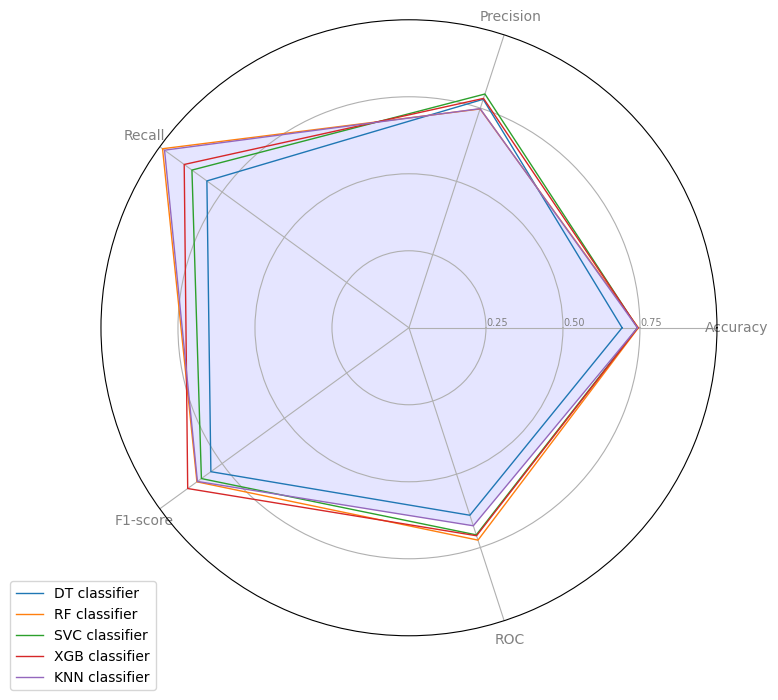

In [ ]:
# @title Comparative visualization model performances (Cross-validation)


import numpy as np
import matplotlib.pyplot as plt

# Define the metrics and their corresponding scores for each model
metrics_CV = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC']
model_names_CV = ['DT classifier', 'RF classifier', 'SVC classifier', 'XGB classifier', 'KNN classifier']

accuracy_scores_CV = [0.692, 0.745, 0.742, 0.743, 0.742]
precision_scores_CV = [0.780, 0.747, 0.798, 0.783, 0.748]
recall_scores_CV = [0.811, 0.989, 0.871, 0.902, 0.981]
f1_scores_CV = [0.795, 0.851, 0.833, 0.888, 0.849]
roc_scores_CV = [0.640, 0.725, 0.707, 0.710, 0.676]

# Combine the scores of all metrics for each model into a single list of lists
all_scores_CV = np.array([accuracy_scores_CV, precision_scores_CV, recall_scores_CV, f1_scores_CV, roc_scores_CV])

# Compute angles for each axis
angles_CV = np.linspace(0, 2 * np.pi, len(metrics_CV), endpoint=False).tolist()
angles_CV += angles_CV[:1]  # Close the plot

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Draw one axe per variable and add labels
plt.xticks(angles_CV[:-1], metrics_CV, color='grey', size=10)

# Draw ylabels
ax.set_rlabel_position(0)
plt.yticks([0.25, 0.5, 0.75], ["0.25", "0.50", "0.75"], color="grey", size=7)
plt.ylim(0, 1)

# Plot data
for i in range(len(model_names_CV)):
    values = all_scores_CV[:, i].tolist()
    ax.plot(angles_CV, values + [values[0]], linewidth=1, linestyle='solid', label=model_names_CV[i])  # Connect back to the start point

# Fill area
ax.fill(angles_CV, values + [values[0]], 'b', alpha=0.1)

plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()



# Grid Search

In [ ]:
# @title Decision Tree Classifier (Hyperparameter Tuning) (Multiple parameters)

# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import accuracy_score, precision_score, roc_auc_score, f1_score
# from sklearn.tree import DecisionTreeClassifier



# # Create a pipeline
# full_pipeline_DT = Pipeline([
#     ('preprocessing', preprocessing),
#     ('tree_class', DecisionTreeClassifier(random_state=42))
# ])

# # Update the parameter distribution dictionary with multiple parameters
# param_distrbs = {
#     'tree_class__max_features': randint(low=10, high=100),
#     'tree_class__max_depth': randint(low=10, high=100),
#     'tree_class__min_samples_split': randint(low=10, high=100),
# }

# # Define multiple scoring metrics
# scoring = {
#     'accuracy': 'accuracy',
#     'precision': 'precision_macro',
#     'roc_auc': 'roc_auc_ovr',
#     'f1': 'f1_macro'
# }

# # Create RandomizedSearchCV with multiple scoring
# rnd_search_DT = RandomizedSearchCV(
#     full_pipeline_DT, param_distributions=param_distrbs, n_iter=10, cv=10,
#     scoring=scoring, refit='roc_auc', random_state=42, n_jobs=-1
# )

# # Fit the RandomizedSearchCV
# rnd_search_DT.fit(df_obesity, df_obesity_labels_2)

# # Get the best parameters for each scoring metric
# best_params_DT = rnd_search_DT.best_params_
# print("Best Parameters:")
# print(best_params_DT)

# # Get the best scores for each scoring metric
# best_scores_DT = rnd_search_DT.best_score_
# print("Best Scores:")
# print(best_scores_DT)


In [ ]:
# @title Logistic Regression Classifier (Hyperparameter Tuning) (Multiple parameters)

# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import accuracy_score, precision_score, roc_auc_score, f1_score
# from sklearn.linear_model import LogisticRegression
# from scipy.stats import uniform #Any value between the range specified can be sampled

# LR_class = make_pipeline (preprocessing, LogisticRegression(C=1.0, random_state=42))
# LR_class.fit(df_obesity,df_obesity_labels_2, logisticregression__sample_weight= sample_weights)



# # Create a pipeline
# full_pipeline_LR = Pipeline([
#     ('preprocessing', preprocessing),
#     ('LR_class', LogisticRegression(C=1.0, random_state=42))
# ])

# # # Update the parameter distribution dictionary with multiple parameters
# param_dist = {
#     'LR_class__C': uniform(loc=0, scale=10),  # Regularization parameter
#     'LR_class__penalty': ['l1', 'l2'],       # Regularization type
#     'LR_class__solver': ['liblinear', 'saga']  # Solver algorithm
# }

# # # Define multiple scoring metrics
# scoring = {
#     'accuracy': 'accuracy',
#     'precision': 'precision_macro',
#     'roc_auc': 'roc_auc_ovr',
#     'f1': 'f1_macro'
# }

# # Create RandomizedSearchCV with multiple scoring
# rnd_search_LR = RandomizedSearchCV(
#     full_pipeline_LR, param_distributions=param_dist, n_iter=10, cv=10,
#     scoring=scoring, refit='roc_auc', random_state=42, n_jobs=-1
# )

# # Fit the RandomizedSearchCV
# rnd_search_LR.fit(df_obesity, df_obesity_labels_2)

# # Get the best parameters for each scoring metric
# best_params_LR = rnd_search_LR.best_params_
# print("Best Parameters:")
# print(best_params_LR)

# # Get the best scores for each scoring metric
# best_scores_LR = rnd_search_LR.best_score_
# print("Best Scores:")
# print(best_scores_LR)

In [ ]:
# @title Random Forest Classifier (Hyperparameter Tuning)

# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint

# full_pipeline = Pipeline([
#     ('preprocessing',preprocessing),
#     ('forest_calss',RandomForestClassifier(random_state=42))
# ])

# param_distrbs = {'RandomForestClassifier__max_features':randint(low=10,high=100)}
# rnd_search = RandomizedSearchCV(
#     full_pipeline, param_distributions=param_distrbs, n_iter = 10, cv = 3,
#     scoring='neg_root_mean_squared_error', random_state=42
# )
# rnd_search.fit(df_obesity,df_obesity_labels_2)
# rnd_search.best_params_

In [ ]:
# @title Random Forest Classifier (Hyperparameter Tuning) (Multiple parameters)

# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import accuracy_score, precision_score, roc_auc_score, f1_score
# from sklearn.ensemble import RandomForestClassifier


# # Create a pipeline
# full_pipeline = Pipeline([
#     ('preprocessing', preprocessing),
#     ('forest_class', RandomForestClassifier(random_state=42))
# ])

# # Update the parameter distribution dictionary with multiple parameters
# param_distrbs = {
#     'forest_class__max_features': randint(low=10, high=100),
#     'forest_class__max_depth': randint(low=10, high=100),
#     'forest_class__min_samples_split': randint(low=10, high=100),
# }

# # Define multiple scoring metrics
# scoring = {
#     'accuracy': 'accuracy',
#     'precision': 'precision_macro',
#     'roc_auc': 'roc_auc_ovr',
#     'f1': 'f1_macro'
# }

# # Create RandomizedSearchCV with multiple scoring
# rnd_search = RandomizedSearchCV(
#     full_pipeline, param_distributions=param_distrbs, n_iter=10, cv=10,
#     scoring=scoring, refit='roc_auc', random_state=42, n_jobs=-1
# )

# # Fit the RandomizedSearchCV
# rnd_search.fit(df_obesity, df_obesity_labels_2)

# # Get the best parameters for each scoring metric
# best_params = rnd_search.best_params_
# print("Best Parameters:")
# print(best_params)

# # Get the best scores for each scoring metric
# best_scores = rnd_search.best_score_
# print("Best Scores:")
# print(best_scores)


In [ ]:
# @title SVC Classifier (Hyperparameter Tuning)

# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.svm import SVC
# import numpy as np


# # Create a pipeline
# full_pipeline_svc = Pipeline([
#     ('preprocessing', preprocessing),
#     ('SVC_class', SVC(random_state=42))
# ])

# # Define the parameter values that should be searched
# param_dist = {'SVC_class__C': np.logspace(-3, 2, 6)}
#               # 'SVC_class__gamma': np.logspace(-3, 2, 6),
#               # 'SVC_class__kernel': ['linear', 'poly', 'rbf', 'sigmoid']}


# scoring = {
#     'accuracy': 'accuracy',
#     'precision': 'precision_macro',
#     'roc_auc': 'roc_auc_ovr',
#     'f1': 'f1_macro'
# }

# random_search_svc = RandomizedSearchCV(full_pipeline_svc, param_distributions=param_dist, n_iter=100, cv=5,
#                                    scoring = scoring, refit = 'roc_auc', verbose=2, random_state=42, n_jobs=-1)

# # Fit the model
# random_search_svc.fit(df_obesity, df_obesity_labels_2)

# # # Get the best parameters for each scoring metric
# best_params_svc = random_search_svc.best_params_
# print("Best Parameters:")
# print(best_params_svc)

# # Get the best scores for each scoring metric
# best_scores_svc = random_search_svc.best_score_
# print("Best Scores:")
# print(best_scores_svc)


In [ ]:
# @title XGB Classifier (Hyperparameter Tuning)


# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint
# from scipy.stats import uniform
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import accuracy_score, precision_score, roc_auc_score, f1_score



# # # Create a pipeline
# full_pipeline_xgb = Pipeline([
#     ('preprocessing', preprocessing),
#     ('XGB_class', XGBClassifier(random_state=42))
# ])

# param_distrbs = {
#     'XGB_class__n_estimators': randint(low=10, high=100),
#     'XGB_class__max_depth': randint(low=10, high=100),
#     'XGB_class__min_child_weight': randint(low=1, high=100),
#     'XGB_class__gamma': randint(low=0, high=100),
#     'XGB_class__subsample': uniform(loc=0.1, scale=0.9),
#     'XGB_class__colsample_bytree': uniform(loc=0.1, scale=0.9),
#     'XGB_class__learning_rate': [0.01, 0.02, 0.05, 0.1, 0.15, 0.2]
# }


# scoring = {
#     'accuracy': 'accuracy',
#     'precision': 'precision_macro',
#     'roc_auc': 'roc_auc_ovr',
#     'f1': 'f1_macro'
# }


# rnd_search_xgb = RandomizedSearchCV(
#     full_pipeline_xgb, param_distributions=param_distrbs, n_iter=10, cv=10,
#     scoring=scoring, refit='roc_auc', random_state=42, n_jobs=-1
# )

# rnd_search_xgb.fit(df_obesity, df_obesity_labels_2)

# best_params_xgb = rnd_search_xgb.best_params_
# print("Best Parameters of XGBooster:")
# print(best_params_xgb)


# best_scores_xgb = rnd_search_xgb.best_score_
# print("Best Scores of XGBooster:")
# print(best_scores_xgb)

<!--  -->

In [ ]:
# @title KNN Classifier (Hyperparameter Tuning) (Multiple parameters)

# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import randint
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import accuracy_score, precision_score, roc_auc_score, f1_score




# # Create a pipeline
# full_pipeline_KNN = Pipeline([
#     ('preprocessing', preprocessing),
#     ('KNN_class', KNeighborsClassifier())
# ])

# # Update the parameter distribution dictionary with multiple parameters
# k_range = list(range(1, 31))
# weight_options = ['uniform', 'distance']

# params_KNN = dict(KNN_class__n_neighbors=k_range, KNN_class__weights=weight_options)

# # Define multiple scoring metrics
# scoring = {
#     'accuracy': 'accuracy',
#     'precision': 'precision_macro',
#     'roc_auc': 'roc_auc_ovr',
#     'f1': 'f1_macro'
# }

# # Create RandomizedSearchCV with multiple scoring
# rnd_search_KNN = RandomizedSearchCV(
#     full_pipeline_KNN, param_distributions=params_KNN, n_iter=10, cv=10,
#     scoring=scoring, refit='roc_auc', random_state=42, n_jobs=-1
# )

# # Fit the RandomizedSearchCV
# rnd_search_KNN.fit(df_obesity, df_obesity_labels_2)

# # Get the best parameters for each scoring metric
# best_params_KNN = rnd_search_KNN.best_params_
# print("Best Parameters:")
# print(best_params_KNN)

# # Get the best scores for each scoring metric
# best_scores_KNN = rnd_search_KNN.best_score_
# print("Best Scores:")
# print(best_scores_KNN)

# Testing on the test set

In [ ]:
# @title DT classifier

X_test_1 = strat_test_set.drop('BMXBMI',axis=1)
X_test = X_test_1.drop('BMI_cat',axis=1)

y_test_1 = strat_test_set['BMXBMI'].copy()
y_test_2 = strat_test_set['BMI_cat'].copy()

# # # print(np.unique(y_test_2))

# predictions_DT_class = tree_class.predict(X_test)
# final_acc_DT_class = accuracy_score(y_test_2, predictions_DT_class)
# print(final_acc_DT_class)



In [ ]:
# @title RF classifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
X_test_1 = strat_test_set.drop('BMXBMI',axis=1)
X_test = X_test_1.drop('BMI_cat',axis=1)

y_test_1 = strat_test_set['BMXBMI'].copy()
y_test_2 = strat_test_set['BMI_cat'].copy()

predictions_RF_class = forest_class.predict(X_test)
final_acc_RF_class = accuracy_score(y_test_2, predictions_RF_class)
print(final_acc_RF_class)


0.7451886066204773


In [ ]:
# @title SVC classifier

# predictions_SVC_class = SVC_class.predict(X_test)
# final_acc_SVC_class = accuracy_score(y_test_2, predictions_SVC_class)
# print(final_acc_SVC_class)

0.7328714395688991


In [ ]:
# @title XGBooster

# X_test_1 = strat_test_set.drop('BMXBMI',axis=1)
# X_test = X_test_1.drop('BMI_cat',axis=1)

# y_test_1 = strat_test_set['BMXBMI'].copy()
# y_test_2 = strat_test_set['BMI_cat'].copy()

# predictions_XGB_class = XGB_class.predict(X_test)
# final_acc_XGB_class =accuracy_score(y_test_2, predictions_XGB_class)
# print(final_acc_XGB_class)

0.7390300230946882


In [ ]:
# @title KNN classifier

# X_test_1 = strat_test_set.drop('BMXBMI',axis=1)
# X_test = X_test_1.drop('BMI_cat',axis=1)

# y_test_1 = strat_test_set['BMXBMI'].copy()
# y_test_2 = strat_test_set['BMI_cat'].copy()

# predictions_KNN_class = KNN_class.predict(X_test)
# final_acc_KNN_class =accuracy_score(y_test_2, predictions_KNN_class)
# print(final_acc_KNN_class)

0.7421093148575828


# Assessing the performance of the selected models

0.6705157813702848
0.7627627627627628
0.7995802728226653
0.7807377049180327
0.6205168952319721


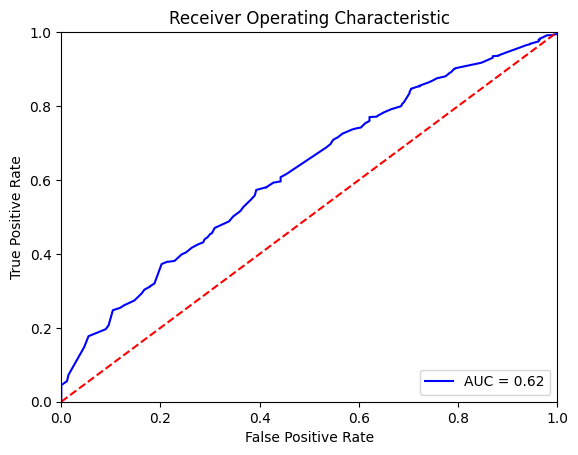

In [ ]:
# @title DT classifier (Complete performance metrics)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix



accuracy_DT_class = accuracy_score(y_test_2, predictions_DT_class)
print(accuracy_DT_class)

precision_DT_class = precision_score(y_test_2, predictions_DT_class)
print(precision_DT_class)

recall_DT_class = recall_score(y_test_2, predictions_DT_class)
print(recall_DT_class)

F1_DT_class = f1_score(y_test_2, predictions_DT_class)
print(F1_DT_class)

roc_auc_DT_class = roc_auc_score(y_test_2, tree_class.predict_proba(X_test)[:, 1])
print(roc_auc_DT_class)


## Visualization of ROC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


probs = tree_class.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test_2, preds)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()


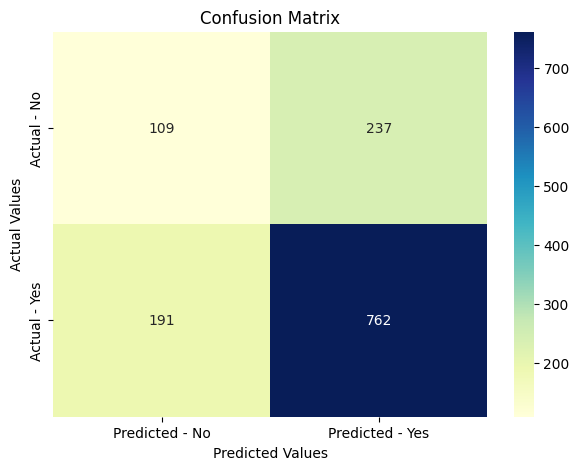

In [ ]:
# @title DT classifier (Confusion matrix)


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


predictions_DT_class = tree_class.predict(X_test)

cm = confusion_matrix(y_test_2, predictions_DT_class)

cm_df = pd.DataFrame(cm, index=[i for i in ["Actual - No", "Actual - Yes"]],
                     columns=[i for i in ["Predicted - No", "Predicted - Yes"]])

plt.figure(figsize=(7,5))

sns.heatmap(cm_df, annot=True, fmt="d", cmap="YlGnBu")

plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

0.7451886066204773
0.7460443037974683
0.9895068205666316
0.8506991429860171
0.713681771588352


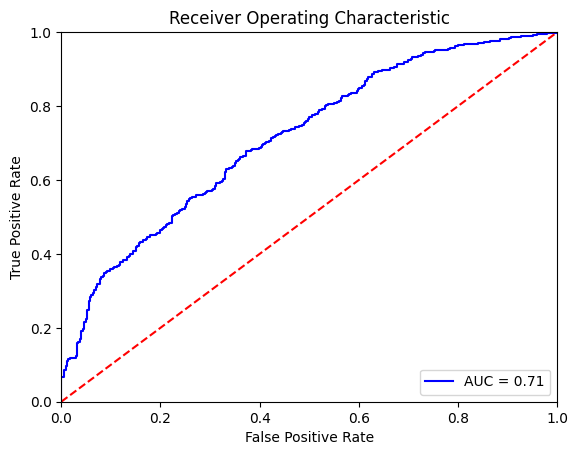

In [ ]:
# @title RF classifier (Complete performance metrics)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy_RF_class = accuracy_score(y_test_2, predictions_RF_class)
print(accuracy_RF_class)

precision_RF_class = precision_score(y_test_2, predictions_RF_class)
print(precision_RF_class)

recall_RF_class = recall_score(y_test_2, predictions_RF_class)
print(recall_RF_class)

F1_RF_class = f1_score(y_test_2, predictions_RF_class)
print(F1_RF_class)

roc_auc_RF_class = roc_auc_score(y_test_2, forest_class.predict_proba(X_test)[:, 1])
print(roc_auc_RF_class)


## Visualization of ROC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


probs = forest_class.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test_2, preds)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()


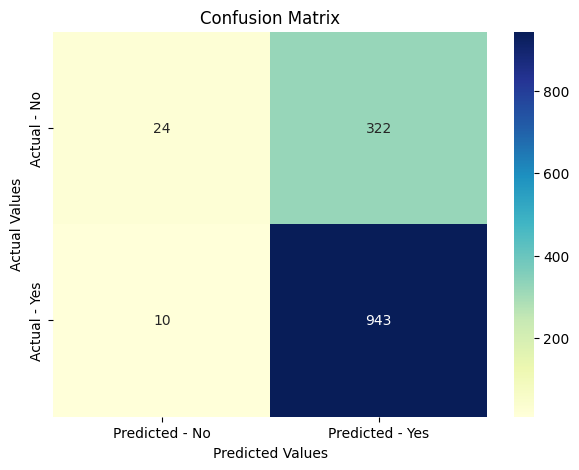

In [ ]:
# @title RF classifier (Confusion matrix)


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


predictions_RF_class = forest_class.predict(X_test)

cm_RF = confusion_matrix(y_test_2, predictions_RF_class)

cm_RF_df = pd.DataFrame(cm_RF, index=[i for i in ["Actual - No", "Actual - Yes"]],
                     columns=[i for i in ["Predicted - No", "Predicted - Yes"]])

plt.figure(figsize=(7,5))

sns.heatmap(cm_RF_df, annot=True, fmt="d", cmap="YlGnBu")

plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

0.7328714395688991
0.7885714285714286
0.8688352570828961
0.8267598602096854
0.6981148669549763


<function matplotlib.pyplot.xlabel(xlabel, fontdict=None, labelpad=None, *, loc=None, **kwargs)>

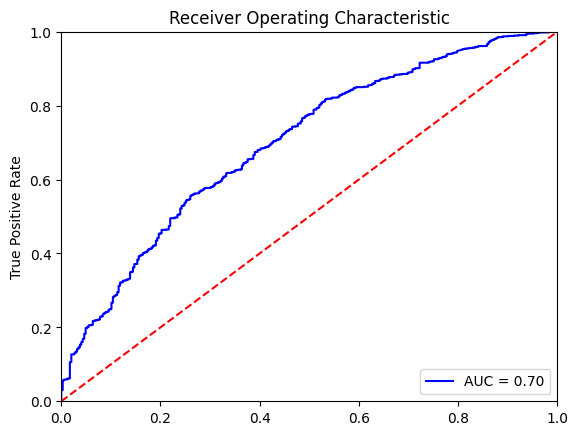

In [ ]:
# @title SVC classifier (Complete performance metrics)


accuracy_SVC_class = accuracy_score(y_test_2, predictions_SVC_class)
print(accuracy_SVC_class)

precision_SVC_class = precision_score(y_test_2, predictions_SVC_class)
print(precision_SVC_class)

recall_SVC_class = recall_score(y_test_2, predictions_SVC_class)
print(recall_SVC_class)

F1_SVC_class = f1_score(y_test_2, predictions_SVC_class)
print(F1_SVC_class)

roc_auc_SVC_class = roc_auc_score(y_test_2, SVC_class.predict_proba(X_test)[:, 1])
print(roc_auc_SVC_class)

## Visualization of ROC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


probs = SVC_class.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test_2, preds)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel



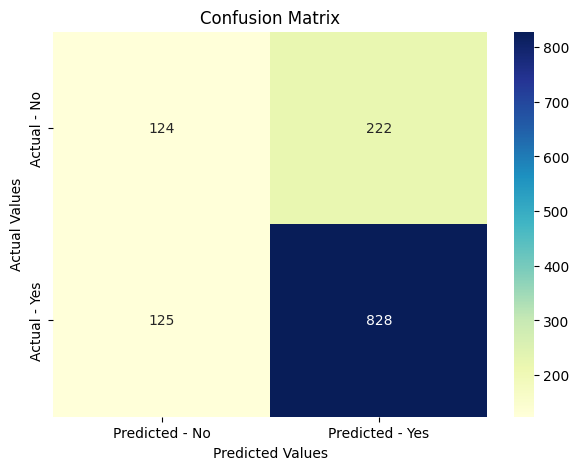

In [ ]:
# @title SVC classifier (Confusion matrix)


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


predictions_SVC_class = SVC_class.predict(X_test)

cm_SVC = confusion_matrix(y_test_2, predictions_SVC_class)

cm_SVC_df = pd.DataFrame(cm_SVC, index=[i for i in ["Actual - No", "Actual - Yes"]],
                     columns=[i for i in ["Predicted - No", "Predicted - Yes"]])

plt.figure(figsize=(7,5))

sns.heatmap(cm_SVC_df, annot=True, fmt="d", cmap="YlGnBu")

plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

0.7390300230946882
0.7780797101449275
0.9013641133263379
0.8351968886728245
0.704844452262099


<function matplotlib.pyplot.xlabel(xlabel, fontdict=None, labelpad=None, *, loc=None, **kwargs)>

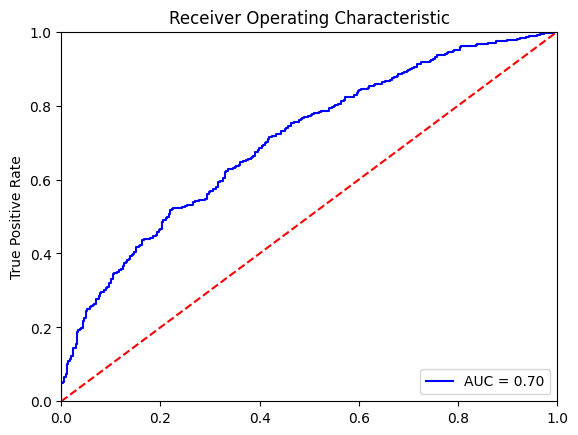

In [ ]:
# @title XGBoost Classifier (Complete performance metrics)

from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


accuracy_XGB_class = accuracy_score(y_test_2, predictions_XGB_class)
print(accuracy_XGB_class)

precision_XGB_class = precision_score(y_test_2, predictions_XGB_class)
print(precision_XGB_class)

recall_XGB_class = recall_score(y_test_2, predictions_XGB_class)
print(recall_XGB_class)

F1_XGB_class = f1_score(y_test_2, predictions_XGB_class)
print(F1_XGB_class)

roc_auc_XGB_class = roc_auc_score(y_test_2, XGB_class.predict_proba(X_test)[:, 1])
print(roc_auc_XGB_class)


## Visualization of ROC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


probs = XGB_class.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test_2, preds)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel


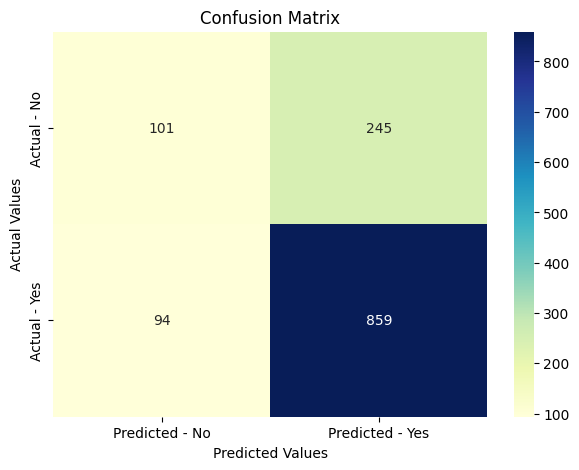

In [ ]:
# @title XGB classifier (Confusion matrix)


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


predictions_XGB_class = XGB_class.predict(X_test)

cm_XGB = confusion_matrix(y_test_2, predictions_XGB_class)

cm_XGB_df = pd.DataFrame(cm_XGB, index=[i for i in ["Actual - No", "Actual - Yes"]],
                     columns=[i for i in ["Predicted - No", "Predicted - Yes"]])

plt.figure(figsize=(7,5))

sns.heatmap(cm_XGB_df, annot=True, fmt="d", cmap="YlGnBu")

plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

0.7421093148575828
0.7460191082802548
0.9832109129066107
0.8483476686283385
0.6896445056378094


<function matplotlib.pyplot.xlabel(xlabel, fontdict=None, labelpad=None, *, loc=None, **kwargs)>

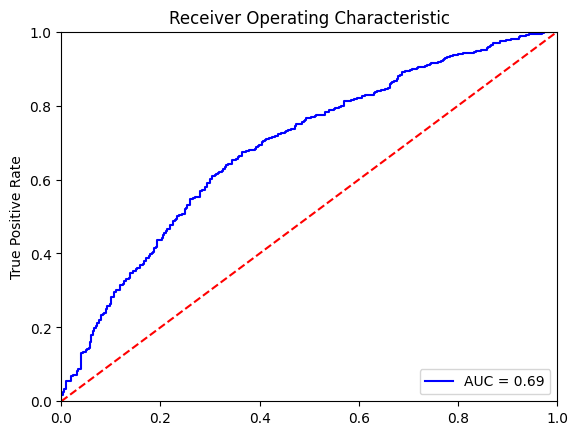

In [ ]:
# @title KNN Classifier (Complete performance metrics)

from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


accuracy_KNN_class = accuracy_score(y_test_2, predictions_KNN_class)
print(accuracy_KNN_class)

precision_KNN_class = precision_score(y_test_2, predictions_KNN_class)
print(precision_KNN_class)

recall_KNN_class = recall_score(y_test_2, predictions_KNN_class)
print(recall_KNN_class)

F1_KNN_class = f1_score(y_test_2, predictions_KNN_class)
print(F1_KNN_class)

roc_auc_KNN_class = roc_auc_score(y_test_2, KNN_class.predict_proba(X_test)[:, 1])
print(roc_auc_KNN_class)


## Visualization of ROC
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


probs = KNN_class.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = roc_curve(y_test_2, preds)
roc_auc = auc(fpr, tpr)

plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel


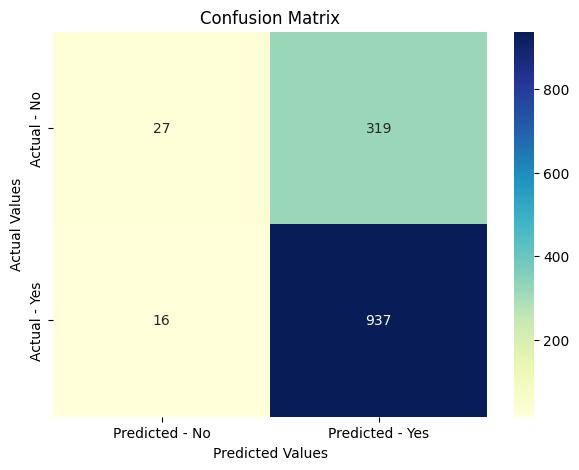

In [ ]:
# @title KNN classifier (Confusion matrix)


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


predictions_KNN_class = KNN_class.predict(X_test)

cm_KNN = confusion_matrix(y_test_2, predictions_KNN_class)

cm_KNN_df = pd.DataFrame(cm_KNN, index=[i for i in ["Actual - No", "Actual - Yes"]],
                     columns=[i for i in ["Predicted - No", "Predicted - Yes"]])

plt.figure(figsize=(7,5))

sns.heatmap(cm_KNN_df, annot=True, fmt="d", cmap="YlGnBu")

plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

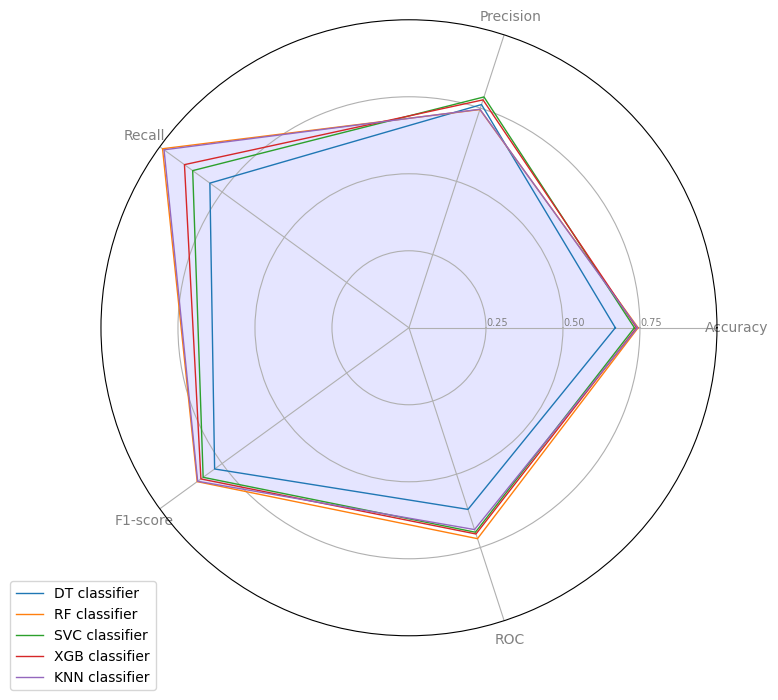

In [ ]:
# @title Comparative visualization of model performances (Final)


import numpy as np
import matplotlib.pyplot as plt

# Define the metrics and their corresponding scores for each model
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC']
model_names = ['DT classifier', 'RF classifier', 'SVC classifier', 'XGB classifier', 'KNN classifier']

accuracy_scores = [0.670, 0.744, 0.732, 0.739, 0.742]
precision_scores = [0.762, 0.745, 0.788, 0.778, 0.746]
recall_scores = [0.799, 0.989, 0.868, 0.901, 0.983]
f1_scores = [0.780, 0.850, 0.826, 0.835, 0.848]
roc_scores = [0.620, 0.720, 0.698, 0.704, 0.689]

# Combine the scores of all metrics for each model into a single list of lists
all_scores = np.array([accuracy_scores, precision_scores, recall_scores, f1_scores, roc_scores])

# Compute angles for each axis
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # Close the plot

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Draw one axe per variable and add labels
plt.xticks(angles[:-1], metrics, color='grey', size=10)

# Draw ylabels
ax.set_rlabel_position(0)
plt.yticks([0.25, 0.5, 0.75], ["0.25", "0.50", "0.75"], color="grey", size=7)
plt.ylim(0, 1)

# Plot data
for i in range(len(model_names)):
    values = all_scores[:, i].tolist()
    ax.plot(angles, values + [values[0]], linewidth=1, linestyle='solid', label=model_names[i])  # Connect back to the start point

# Fill area
ax.fill(angles, values + [values[0]], 'b', alpha=0.1)

plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.show()



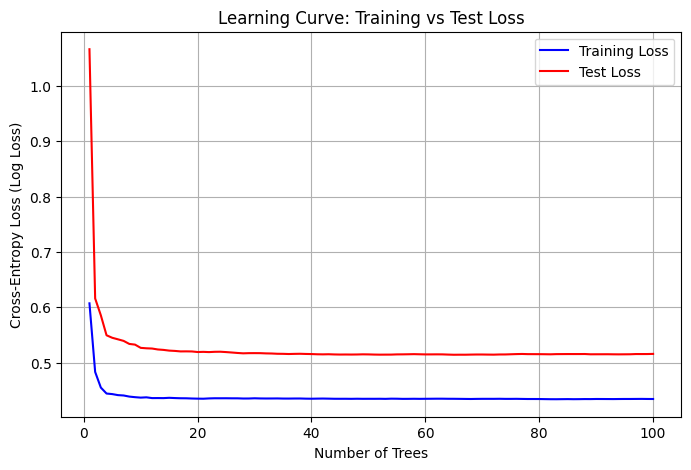

In [ ]:
#@title Learning Curve (Cross-entropy (log) Loss) (RF classifier)

from sklearn.metrics import log_loss
X_train = df_obesity
y_train = df_obesity_labels_2

X_test = X_test
y_test = y_test_2


n_trees = np.arange(1, 101)  # Track trees from 1 to 100
rf = RandomForestClassifier(
    n_estimators=1,  # Start with 1 tree
    warm_start=True,
    max_depth=61,
    max_features=24,
    min_samples_split=81,
    random_state=42
)

# Create the full pipeline
model_pipeline = Pipeline([
    ("preprocessor", preprocessing),
    ("randomforestclassifier", rf)
])

# Arrays to store loss values
train_losses = []
test_losses = []
n_trees = np.arange(1, 101)  # Track trees from 1 to 100

# Train incrementally and calculate loss
for n in n_trees:
    # Access RandomForestClassifier inside pipeline
    model_pipeline.named_steps["randomforestclassifier"].set_params(n_estimators=n)

    # Fit the pipeline
    model_pipeline.fit(X_train, y_train)

    # Predict probabilities
    train_probs = model_pipeline.predict_proba(X_train)
    test_probs = model_pipeline.predict_proba(X_test)

    # Compute log loss (cross-entropy)
    train_loss = log_loss(y_train, train_probs)
    test_loss = log_loss(y_test, test_probs)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

# Plot the loss curve
plt.figure(figsize=(8, 5))
plt.plot(n_trees, train_losses, label="Training Loss", color='blue')
plt.plot(n_trees, test_losses, label="Test Loss", color='red')
plt.xlabel("Number of Trees")
plt.ylabel("Cross-Entropy Loss (Log Loss)")
plt.title("Learning Curve: Training vs Test Loss")
plt.legend()
plt.grid(True)
plt.show()

# Feature Importance

In [ ]:
# @title Feature Selection (Lasso)

# Defining a custom WrapperFeatureSelector class

# from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn.feature_selection import SelectFromModel

# class WrapperFeatureSelection(BaseEstimator, TransformerMixin):
#     def __init__(self, estimator, threshold=0.1):
#         self.estimator = estimator
#         self.threshold = threshold
#         self.feature_selector = None

#     def fit(self, X, y):
#         self.estimator.fit(X, y)
#         self.feature_selector = SelectFromModel(self.estimator, threshold=self.threshold)
#         self.feature_selector.fit(X, y)
#         return self

#     def transform(self, X):
#         if self.feature_selector is None:
#             raise ValueError("The model has not been fitted yet.")
#         return self.feature_selector.transform(X)

#     def get_support(self, indices=False):
#         if self.feature_selector is None:
#             raise ValueError("The model has not been fitted yet.")
#         return self.feature_selector.get_support(indices)

#     def get_params(self, deep=True):
#         return {'estimator': self.estimator, 'threshold': self.threshold}

#     def set_params(self, **params):
#         if 'estimator' in params:
#             self.estimator = params['estimator']
#         if 'threshold' in params:
#             self.threshold = params['threshold']
#         return self


# from sklearn.pipeline import Pipeline
# from sklearn.linear_model import Lasso
# from sklearn.pipeline import make_pipeline

# lasso = Lasso(alpha=0.01)
# feature_selector_lasso = WrapperFeatureSelection(estimator=lasso, threshold=0.1)

# selector_pipeline_lasso = Pipeline([
#     ('preprocessing', preprocessing),
#     ('feature_selector', feature_selector_lasso)
# ])

# selected_features_train_lasso = selector_pipeline_lasso.fit_transform(df_obesity,df_obesity_labels_1)

# selected_feature_indices_lasso = feature_selector_lasso.get_support(indices=True)
# transformed_column_names_lasso = selector_pipeline_lasso.named_steps['preprocessing'].get_feature_names_out()
# selected_column_names_lasso = [transformed_column_names_lasso[idx] for idx in selected_feature_indices_lasso]

# model_coefficients_lasso = feature_selector_lasso.estimator.coef_
# column_importance_map_lasso = dict(zip(selected_column_names_lasso, model_coefficients_lasso))
# sorted_columns_lasso = sorted(column_importance_map_lasso.items(), key=lambda x: abs(x[1]), reverse=True)

# print("Sorted Columns based on Importance:")  # The importances of the features selected by the feature selector (**After** feature selection)
# for column, importance in sorted_columns_lasso:
#     print(f"{column}: {importance}")


# sorted_feature_importance_lasso = sorted(zip(model_coefficients_lasso,
#                                             transformed_column_names_lasso),
#                                         key=lambda x: abs(x[0]), reverse=True)

# print("Sorted Columns based on Importance:")  # The importances of the features **before** fter feature selection
# for importance, column in sorted_feature_importance_lasso:
#     print(f"{column}: {importance}")

In [ ]:
# @title Visualizing the Lasso feature selection results

# import matplotlib.pyplot as plt


# top_30_features_lasso = sorted_columns_lasso[:30]


# features, importance = zip(*top_30_features_lasso)

# plt.figure(figsize=(10, 8))
# plt.barh(features, importance, color='skyblue')
# plt.xlabel('Importance')
# plt.title('Top 30 Features')
# plt.gca().invert_yaxis()
# plt.show()

In [ ]:
# @title Feature Selection (Wrapper-RF)

# Defining a custom WrapperFeatureSelector class

# from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn.feature_selection import SelectFromModel
# from sklearn.ensemble import RandomForestClassifier

# class WrapperFeatureSelection(BaseEstimator, TransformerMixin):
#     def __init__(self, estimator, threshold=0.1):
#         self.estimator = estimator
#         self.threshold = threshold
#         self.feature_selector = None

#     def fit(self, X, y):
#         self.estimator.fit(X, y)
#         self.feature_selector = SelectFromModel(self.estimator, threshold=self.threshold)
#         self.feature_selector.fit(X, y)
#         return self

#     def transform(self, X):
#         if self.feature_selector is None:
#             raise ValueError("The model has not been fitted yet.")
#         return self.feature_selector.transform(X)

#     def get_support(self, indices=False):
#         if self.feature_selector is None:
#             raise ValueError("The model has not been fitted yet.")
#         return self.feature_selector.get_support(indices)

#     def get_params(self, deep=True):
#         return {'estimator': self.estimator, 'threshold': self.threshold}

#     def set_params(self, **params):
#         if 'estimator' in params:
#             self.estimator = params['estimator']
#         if 'threshold' in params:
#             self.threshold = params['threshold']
#         return self


# from sklearn.pipeline import Pipeline
# from sklearn.linear_model import Lasso
# from sklearn.pipeline import make_pipeline
# # from sklearn.feature_selection import NegativeCorrelationFilter



# # lasso = Lasso(alpha=0.01)
# feature_selector_wrapper_RF = WrapperFeatureSelection(estimator=RandomForestClassifier(random_state=42),threshold=0.01)

# selector_pipeline_wrapper_RF = Pipeline([
#     ('preprocessing', preprocessing),
#     ('feature_selector', feature_selector_wrapper_RF)
# ])


# selected_features_train_wrapper_RF = selector_pipeline_wrapper_RF.fit_transform(df_obesity,df_obesity_labels_2)

# selected_feature_indices_wrapper_RF = feature_selector_wrapper_RF.get_support(indices=True)
# transformed_column_names_wrapper_RF = selector_pipeline_wrapper_RF.named_steps['preprocessing'].get_feature_names_out()
# selected_column_names_wrapper_RF = [transformed_column_names_wrapper_RF[idx] for idx in selected_feature_indices_wrapper_RF]

# if len(selected_feature_indices_wrapper_RF) > 0:
#     # Retrieve feature importances from the RandomForestClassifier
#     model_wrapper_RF = feature_selector_wrapper_RF.estimator
#     importances_wrapper_RF = model_wrapper_RF.feature_importances_

#     # Ensure there are importances available to display
#     if len(importances_wrapper_RF) > 0:
#         # Get selected importances and their corresponding indices
#         selected_importances_wrapper_RF = importances_wrapper_RF[selected_feature_indices_wrapper_RF]

#         # Sort feature importances and select top features
#         num_features_to_display = min(len(selected_importances_wrapper_RF), 30)
#         indices = np.argsort(selected_importances_wrapper_RF)[::-1][:num_features_to_display]
#         sorted_column_names = [selected_column_names_wrapper_RF[idx] for idx in indices]
#         sorted_importances = selected_importances_wrapper_RF[indices]

#         # Plotting feature importances
#         plt.figure(figsize=(10, 8))
#         plt.barh(range(len(sorted_importances)), sorted_importances, align='center')
#         plt.yticks(range(len(sorted_importances)), sorted_column_names)
#         plt.xlabel('Feature Importance')
#         plt.title('Top Selected Features Importance (Random Forest)')
#         plt.gca().invert_yaxis()
#         plt.show()
#     else:
#         print("No importances available to display.")
# else:
#     print("No features were selected.")



In [ ]:
# @title Feature Selection (RFE-RF classifier)

# from sklearn.ensemble import RandomForestClassifier
# from sklearn.feature_selection import RFE #the Recursive Feature Elimination (RFE) method from sklearn as a wrapper feature selector
# from sklearn.pipeline import make_pipeline
# from sklearn.pipeline import Pipeline




# estimator_RFE_RF = RandomForestClassifier(random_state=42)

# selector_RFE_RF = RFE(estimator_RFE_RF, n_features_to_select=50, step=1)

# # selector = selector.fit(df_obesity,df_obesity_labels_2)

# RFE_selector_pipeline = Pipeline([
#   ('preprocessing', preprocessing),
#   ('feature_selection', selector_RFE_RF)
# ])

# feature_selector_RFE_RF = RFE_selector_pipeline.fit_transform(df_obesity,df_obesity_labels_2)

# feature_names_RFE_RF = RFE_selector_pipeline.named_steps['preprocessing'].get_feature_names_out()

# ranking_RFE_RF = RFE_selector_pipeline.named_steps['feature_selection'].ranking_

# features_importance_RFE_RF = sorted(list(enumerate(ranking_RFE_RF)), key=lambda x:x[1])

# for feature in features_importance_RFE_RF:
#     print(f"Feature {feature_names_RFE_RF[feature[0]]} importance: {feature[1]}")





In [ ]:
# @title Visualizing RFE-RF feaure selector

# import matplotlib.pyplot as plt


# top_30_features_RFE_RF = features_importance_RFE_RF[:30]


# features, importance = zip(*top_30_features_RFE_RF)

# plt.figure(figsize=(10, 8))
# plt.barh(features, importance, color='skyblue')
# plt.xlabel('Importance')
# plt.title('Top 30 Features')
# plt.gca().invert_yaxis()
# plt.show()

This code calculates permutation importances for each feature in the dataset based on how much the model performance (measured by accuracy by default) drops when the feature's values are randomly shuffled.

Permutation importances inherently consider both positive and negative associations with the outcome. Features that, when shuffled, result in a considerable drop in model performance are considered more important, regardless of whether they are positively or negatively associated with the outcome.

In [ ]:
# @title Permutation importances

# from sklearn.inspection import permutation_importance
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.datasets import make_classification
# from sklearn.pipeline import Pipeline
# import matplotlib.pyplot as plt




# selector_permutation_RF = RandomForestClassifier(random_state=42)

# # Create a pipeline with preprocessing and feature selection using Random Forest
# pipeline_selector_permutation_RF = Pipeline([
#     ('preprocessing', preprocessing),
#     ('feature_selector', selector_permutation_RF)
# ])




# selected_features_permutation_RF = pipeline_selector_permutation_RF.fit(df_obesity,df_obesity_labels_2)

# # Calculate permutation importances
# result = permutation_importance(selected_features_permutation_RF, df_obesity,df_obesity_labels_2, n_repeats=10, random_state=42)

# # Get indices of top 30 features by importance
# top_30_indices = result.importances_mean.argsort()[-30:]

# # Plotting permutation importances for the top 30 features
# plt.figure(figsize=(10, 8))
# plt.barh(range(len(top_30_indices)), result.importances_mean[top_30_indices], align='center')
# plt.yticks(range(len(top_30_indices)), df_obesity.columns[top_30_indices])
# plt.xlabel('Permutation Importance')
# plt.title('Top 30 Feature Importance (Permutation) - Random Forest')
# plt.show()







In [ ]:
# @title SHAP (SHapley Additive exPlanations) (Random forest)

!pip install shap
from sklearn.ensemble import RandomForestClassifier

selector_SHAP = RandomForestClassifier(random_state=42, max_depth=61, max_features=24, min_samples_split=81)

from sklearn.ensemble import RandomForestClassifier



##% To calculate feature importances of non-encoded categorical variables
# cat_pipeline_NEW = Pipeline([
#    ('impute', SimpleImputer(strategy= 'most_frequent')),
#   #  ('encoder', OneHotEncoder(handle_unknown= 'ignore')),
# ])



# preprocessing_feature_imp = make_column_transformer(
#     (num_pipeline, make_column_selector(dtype_include=np.number)),
#     (cat_pipeline_NEW, make_column_selector(dtype_include='category'))
# )

# preprocessing_feature_imp = make_column_transformer(
#     (num_pipeline, make_column_selector(dtype_include=np.number)),
#     (cat_pipeline_NEW, make_column_selector(dtype_include='category'))
# )

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include='category'))
)

pipeline_selector_SHAP = Pipeline([
    ('preprocessing', preprocessing),
    ('feature_selector', selector_SHAP)
])

selected_features_SHAP = pipeline_selector_SHAP.fit(df_obesity,df_obesity_labels_2)

model_for_shap = pipeline_selector_SHAP.named_steps['feature_selector']

import shap

# Calculate SHAP values
# Preprocess the df_obesity data using the same preprocessing steps in the pipeline
preprocessed_df_obesity = pipeline_selector_SHAP.named_steps['preprocessing'].transform(df_obesity)
# Get feature names after preprocessing
transformed_column_names = pipeline_selector_SHAP.named_steps['preprocessing'].get_feature_names_out()



# Calculate SHAP values on the preprocessed data
explainer = shap.Explainer(model_for_shap, preprocessed_df_obesity)
shap_values = explainer.shap_values(preprocessed_df_obesity)



## SHAP values for both negative and positive class

# Calculate mean absolute SHAP values for each feature
mean_abs_shap_values = np.mean([np.abs(sv) for sv in shap_values], axis=0)



## SHAP values only for the positive class

# shap_values_positive_class = shap_values[1]
# mean_abs_shap_values = np.abs(shap_values_positive_class).mean(axis=0)



mean_abs_shap_values_list = mean_abs_shap_values.tolist()


# Combine feature names and their corresponding mean SHAP values
feature_importance = list(zip(transformed_column_names, mean_abs_shap_values_list))

# Sort features based on mean absolute SHAP values (importance)
feature_importance_sorted = sorted(feature_importance, key=lambda x: x[1], reverse=True)

# Display the sorted feature importances
for feature, importance in feature_importance_sorted:
    print(f"{feature}: {importance}")

<ipython-input-113-447f0383f56e>:22: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(distance_matrix, method='ward')


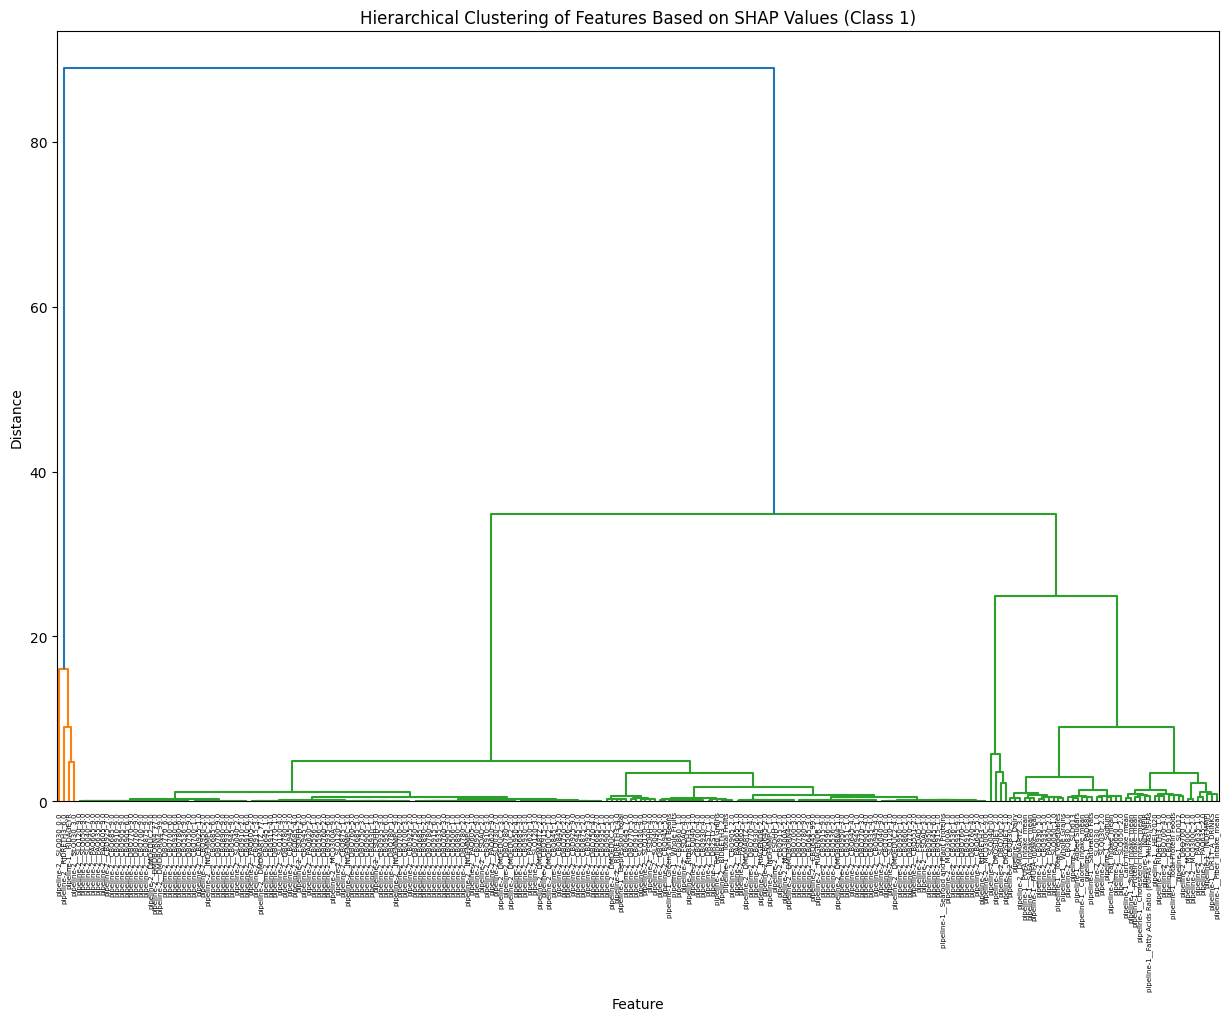

ANOVA F-value: 31.83562455467755, p-value: 1.4562637805730541e-127


In [ ]:
# @title Hierarchical clustering and ANOVA test on individual features (TEST)
import shap
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import f_oneway
import matplotlib.pyplot as plt

# Assuming shap_values has shape (n_samples, n_features, n_classes)
# For binary classification, we'll select the SHAP values for class 1 (positive class)
shap_values_matrix = shap_values[:, :, 1]  # Shape: (n_samples, n_features)

# Get feature names after preprocessing
transformed_column_names = pipeline_selector_SHAP.named_steps['preprocessing'].get_feature_names_out()

# Step 1: Calculate the mean SHAP values across all samples for each feature
mean_shap_values = np.mean(shap_values_matrix, axis=0)  # Shape: (n_features,)

# Step 2: Calculate the distance matrix based on SHAP values for features
distance_matrix = squareform(pdist(shap_values_matrix.T, metric='euclidean'))

# Step 3: Perform hierarchical clustering using Ward's method
linkage_matrix = linkage(distance_matrix, method='ward')

# Step 4: Plot dendrogram, with preprocessed feature names as labels
plt.figure(figsize=(15, 10))  # Increase the figure size for better readability
dendrogram(linkage_matrix, labels=transformed_column_names, leaf_rotation=90)
plt.title('Hierarchical Clustering of Features Based on SHAP Values (Class 1)')
plt.xlabel('Feature')
plt.ylabel('Distance')
plt.show()

# Step 5: Form clusters by cutting the dendrogram
# Adjust `t` to control how many clusters you want (e.g., 1.0 for 3-5 clusters)
clusters = fcluster(linkage_matrix, t=1.0, criterion='distance')

# Step 6: Compute mean SHAP values for each cluster
cluster_mean_shap_values = {i: np.mean(shap_values_matrix[:, clusters == i], axis=1) for i in set(clusters)}

# Step 7: Perform ANOVA to compare SHAP values across clusters
anova_results = f_oneway(*[cluster_mean_shap_values[i] for i in set(clusters)])

print(f"ANOVA F-value: {anova_results.statistic}, p-value: {anova_results.pvalue}")



In [ ]:
# @title Feature importances using Beeswarm plot

# rename_dict = {
#     "pipeline-2__SLQ030_0.0": "SLQ030_0.0: sleep quality",
#     "pipeline-1__RIDAGEYR": "RIDAGEYR: age",
#     "pipeline-2__SLQ030_3.0": "SLQ030_3.0: sleep quality",
#     "pipeline-2__RIDRETH3_6.0": "RIDRETH3_6.0: race/ethnicity",
#     "pipeline-2__DRQSDIET_2.0": "DRQSDIET_2.0: being on a diet",
#     "pipeline-2__DBQ700_2.0": "DBQ700_2.0: having a healthy diet (perception)",
#     "pipeline-2__DRQSDIET_1.0": "DRQSDIET_1.0: being on a diet",
#     "pipeline-2__SLQ040_0.0": "SLQ040_0.0: sleep quality",
#     "pipeline-2__MCQ300C_1.0": "MCQ300C_1.0: family history of diabetes",
#     "pipeline-2__MCQ300C_2.0": "MCQ300C_2.0: family history of diabetes",
#     "pipeline-2__CBQ910_5.0": "CBQ910_5.0: eating behavior (food label)",
#     "pipeline-2__PAQ635_2.0": "PAQ635_2.0: PA (walking/bike)",
#     "pipeline-2__DBQ700_4.0": "DBQ700_4.0: having a healthy diet (perception)",
#     "pipeline-1__SLD012": "SLD012: sleep duration (weekdays)",
#     "pipeline-2__PAQ635_1.0": "PAQ635_1.0: PA (walking/bike)",
#     "pipeline-2__PAQ650_1.0": "PAQ650_1.0: PA (vigorous)",
#     "pipeline-2__SLQ030_1.0": "SLQ030_1.0: sleep quality",
#     "pipeline-1__INDFMMPI": "INDFMMPI: poverty level index",
#     "pipeline-1__Fiber_intake_mean": "Fiber_intake_mean",
#     "pipeline-1__Carb_intake_mean": "Carb_intake_mean",
#     "pipeline-1__DR1T_A_DRINKS": "DR1T_A_DRINKS: alcoholic drinks(D1)",
#     "pipeline-2__SLQ050_2.0": "SLQ050_2.0: sleep disorder",
#     "pipeline-1__HEI-2020": "HEI-2020",
#     "pipeline-2__CBQ830_1.0": "CBQ830_1.0: eating behavior (eating out/buffet)",
#     "pipeline-1__Total Protein Foods": "Total_Protein_Foods",
#     "pipeline-1__Sugar_intake_mean": "Sugar_intake_mean",
#     "pipeline-2__RIDRETH3_1.0": "RIDRETH3_1.0: race/ethnicity",
#     "pipeline-1__Saturated Fats": "Saturated_Fats",
#     "pipeline-1__Fat_intake_mean": "Fat_intake_mean",
#     "pipeline-1__Cholesterol_intake_mean": "Cholesterol_intake_mean"
# }

##% Renamed dictionary without original variable names
rename_dict = {
    "pipeline-2__SLQ030_0.0": "sleep quality",
    "pipeline-1__RIDAGEYR": "age",
    "pipeline-2__SLQ030_3.0": "sleep quality",
    "pipeline-2__RIDRETH3_6.0": "race/ethnicity",
    "pipeline-2__DRQSDIET_2.0": "being on a diet",
    "pipeline-2__DBQ700_2.0": "having a healthy diet (perception)",
    "pipeline-2__DRQSDIET_1.0": "being on a diet",
    "pipeline-2__SLQ040_0.0": "sleep quality",
    "pipeline-2__MCQ300C_1.0": "family history of diabetes",
    "pipeline-2__MCQ300C_2.0": "family history of diabetes",
    "pipeline-2__CBQ910_5.0": "eating behavior (food label)",
    "pipeline-2__PAQ635_2.0": "physical activity (walking/bike)",
    "pipeline-2__DBQ700_4.0": "having a healthy diet (perception)",
    "pipeline-1__SLD012": "sleep duration (weekdays)",
    "pipeline-2__PAQ635_1.0": "physical activity (walking/bike)",
    "pipeline-2__PAQ650_1.0": "Pphysical activity (vigorous)",
    "pipeline-2__SLQ030_1.0": "sleep quality",
    "pipeline-1__INDFMMPI": "poverty level index",
    "pipeline-1__Fiber_intake_mean": "Fiber intake (g/day)",
    "pipeline-1__Carb_intake_mean": "Carbohydrate intake (g/day)",
    "pipeline-1__DR1T_A_DRINKS": "alcoholic drinks (no. of drinks)",
    "pipeline-2__SLQ050_2.0": "sleep disorder",
    "pipeline-1__HEI-2020": "HEI-2020",
    "pipeline-2__CBQ830_1.0": "eating behavior (eating out/buffet)",
    "pipeline-1__Total Protein Foods": "Total Protein Foods-score (HEI component)",
    "pipeline-1__Sugar_intake_mean": "Sugar intake (g/day)",
    "pipeline-2__RIDRETH3_1.0": "race/ethnicity",
    "pipeline-1__Saturated Fats": "Saturated Fats-score (HEI component)",
    "pipeline-1__Fat_intake_mean": "Fat intake (g/day)",
    "pipeline-1__Cholesterol_intake_mean": "Cholesterol intake (g/day)"
}


import pandas as pd

# Convert the numpy array to a DataFrame temporarily for renaming
preprocessed_df_obesity_df = pd.DataFrame(preprocessed_df_obesity, columns=transformed_column_names)

# Rename columns in the DataFrame using the provided dictionary
preprocessed_df_obesity_renamed_df = preprocessed_df_obesity_df.rename(columns=rename_dict)

# Convert back to numpy array if needed
preprocessed_df_obesity_renamed = preprocessed_df_obesity_renamed_df.values

# Calculate SHAP values for individual samples using the DataFrame with renamed columns
explainer = shap.Explainer(model_for_shap, preprocessed_df_obesity_renamed_df)
shap_values = explainer(preprocessed_df_obesity_renamed_df)  # This returns SHAP values for all samples

# Extract SHAP values for a specific class (e.g., class 1 for positive class)
shap_values_class = shap_values[..., 1]

# Check the shape of the SHAP values and preprocessed data
print(f"SHAP values for selected class shape: {shap_values_class.shape}")
print(f"Preprocessed data shape: {preprocessed_df_obesity_renamed_df.shape}")

# Verify the SHAP values match the feature dimensions (after removing the class dimension)
assert shap_values_class.shape == preprocessed_df_obesity_renamed_df.shape, "SHAP values and feature data shape mismatch!"

# Generate the Beeswarm plot for the selected class
shap.summary_plot(shap_values_class, features=preprocessed_df_obesity_renamed_df, feature_names=preprocessed_df_obesity_renamed_df.columns, plot_type='dot')

# Show the plot
plt.show()



In [ ]:
# @title SHAP interaction investigation (features)

explainer = shap.Explainer(model_for_shap, preprocessed_df_obesity)
shap_interaction_values = explainer.shap_interaction_values(preprocessed_df_obesity)
# shap_interaction_values

# Get the sum of absolute SHAP interaction values for each feature pair
interaction_sum = np.abs(shap_interaction_values).sum(axis=0)

# Get the indices of the top interactions and sort them by value
sorted_indices = np.unravel_index(np.argsort(-interaction_sum, axis=None), interaction_sum.shape)
sorted_interaction_values = interaction_sum[sorted_indices]

# Display the most important interactions sorted from highest to lowest
for idx in range(10):  # Display top 10 interactions
    i, j = sorted_indices[0][idx], sorted_indices[1][idx]

    # Get the interaction value
    interaction_value = sorted_interaction_values[idx]

    # Convert to scalar if necessary and display interaction
    interaction_value = np.squeeze(interaction_value)

    if isinstance(interaction_value, np.ndarray):
        if interaction_value.size > 1:
            interaction_value = interaction_value.mean()  # Use mean if it's a multi-element array

    # Print feature interactions along with their interaction value
    print(f"Interaction between {transformed_column_names[i]} and {transformed_column_names[j]}: {interaction_value:.10f}")





Interaction between pipeline-1__RIDAGEYR and pipeline-1__RIDAGEYR: 0.0000000000
Interaction between pipeline-2__CBQ945_1.0 and pipeline-2__CBQ700_3.0: 0.0000000000
Interaction between pipeline-2__CBQ945_1.0 and pipeline-2__CBQ700_3.0: 0.0000000000
Interaction between pipeline-2__CBQ945_1.0 and pipeline-2__CBQ700_2.0: 0.0000000000
Interaction between pipeline-2__CBQ945_1.0 and pipeline-2__CBQ700_2.0: 0.0000000000
Interaction between pipeline-2__CBQ945_1.0 and pipeline-2__CBQ700_1.0: 0.0000000000
Interaction between pipeline-2__CBQ945_1.0 and pipeline-2__CBQ700_1.0: 0.0000000000
Interaction between pipeline-2__CBQ945_1.0 and pipeline-2__CBQ645_99.0: 0.0000000000
Interaction between pipeline-2__CBQ945_1.0 and pipeline-2__CBQ645_99.0: 0.0000000000
Interaction between pipeline-2__CBQ945_1.0 and pipeline-2__CBQ645_7.0: 0.0000000000


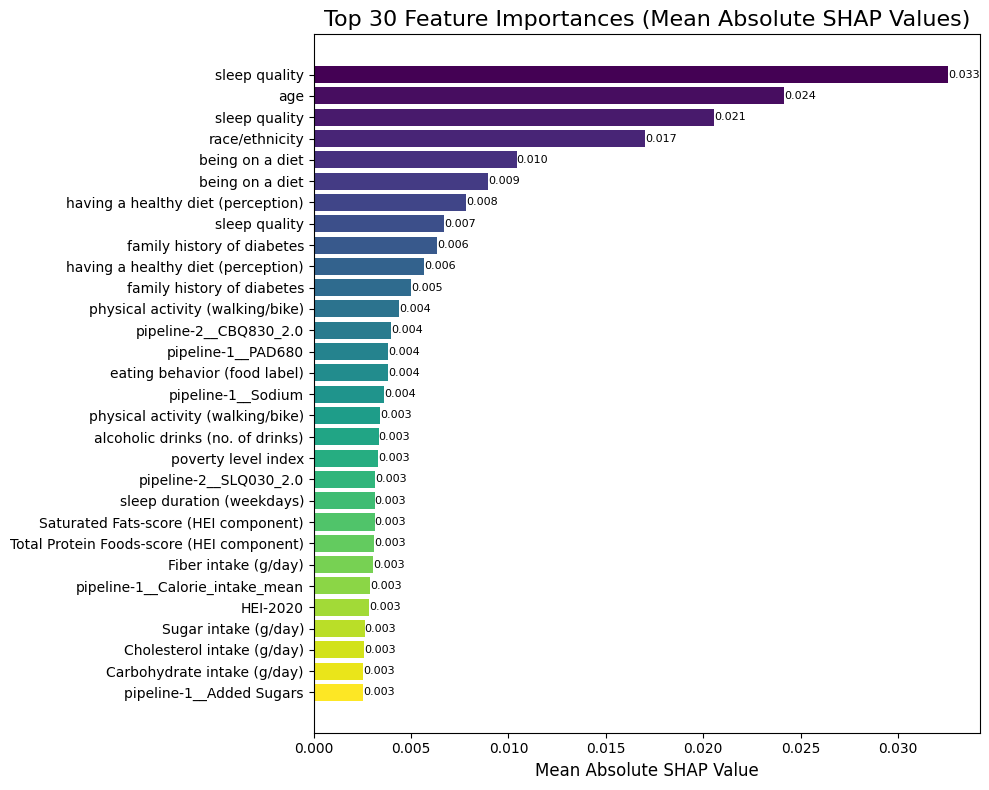

In [ ]:
# @title Plot the SHAP summary plot with feature names (Random Forest) (Valued Bars + Renamed)


import matplotlib.pyplot as plt
import numpy as np

# rename_dict = {
#     "pipeline-2__SLQ030_0.0": "SLQ030_0.0: sleep quality",
#     "pipeline-1__RIDAGEYR": "RIDAGEYR: age",
#     "pipeline-2__SLQ030_3.0": "SLQ030_3.0: sleep quality",
#     "pipeline-2__RIDRETH3_6.0": "RIDRETH3_6.0: race/ethnicity",
#     "pipeline-2__DRQSDIET_2.0": "DRQSDIET_2.0: being on a diet",
#     "pipeline-2__DBQ700_2.0": "DBQ700_2.0: having a healthy diet (perception)",
#     "pipeline-2__DRQSDIET_1.0": "DRQSDIET_1.0: being on a diet",
#     "pipeline-2__SLQ040_0.0": "SLQ040_0.0: sleep quality",
#     "pipeline-2__MCQ300C_1.0": "MCQ300C_1.0: family history of diabetes",
#     "pipeline-2__MCQ300C_2.0": "MCQ300C_2.0: family history of diabetes",
#     "pipeline-2__CBQ910_5.0": "CBQ910_5.0: eating behavior (food label)",
#     "pipeline-2__PAQ635_2.0": "PAQ635_2.0: PA (walking/bike)",
#     "pipeline-2__DBQ700_4.0": "DBQ700_4.0: having a healthy diet (perception)",
#     "pipeline-1__SLD012": "SLD012: sleep duration (weekdays)",
#     "pipeline-2__PAQ635_1.0": "PAQ635_1.0: PA (walking/bike)",
#     "pipeline-2__PAQ650_1.0": "PAQ650_1.0: PA (vigorous)",
#     "pipeline-2__SLQ030_1.0": "SLQ030_1.0: sleep quality",
#     "pipeline-1__INDFMMPI": "INDFMMPI: poverty level index",
#     "pipeline-1__Fiber_intake_mean": "Fiber_intake_mean",
#     "pipeline-1__Carb_intake_mean": "Carb_intake_mean",
#     "pipeline-1__DR1T_A_DRINKS": "DR1T_A_DRINKS: alcoholic drinks(D1)",
#     "pipeline-2__SLQ050_2.0": "SLQ050_2.0: sleep disorder",
#     "pipeline-1__HEI-2020": "HEI-2020",
#     "pipeline-2__CBQ830_1.0": "CBQ830_1.0: eating behavior (eating out/buffet)",
#     "pipeline-1__Total Protein Foods": "Total_Protein_Foods",
#     "pipeline-1__Sugar_intake_mean": "Sugar_intake_mean",
#     "pipeline-2__RIDRETH3_1.0": "RIDRETH3_1.0: race/ethnicity",
#     "pipeline-1__Saturated Fats": "Saturated_Fats",
#     "pipeline-1__Fat_intake_mean": "Fat_intake_mean",
#     "pipeline-1__Cholesterol_intake_mean": "Cholesterol_intake_mean"
# }

##% Renamed dictionary without original variable names
rename_dict = {
    "pipeline-2__SLQ030_0.0": "sleep quality",
    "pipeline-1__RIDAGEYR": "age",
    "pipeline-2__SLQ030_3.0": "sleep quality",
    "pipeline-2__RIDRETH3_6.0": "race/ethnicity",
    "pipeline-2__DRQSDIET_2.0": "being on a diet",
    "pipeline-2__DBQ700_2.0": "having a healthy diet (perception)",
    "pipeline-2__DRQSDIET_1.0": "being on a diet",
    "pipeline-2__SLQ040_0.0": "sleep quality",
    "pipeline-2__MCQ300C_1.0": "family history of diabetes",
    "pipeline-2__MCQ300C_2.0": "family history of diabetes",
    "pipeline-2__CBQ910_5.0": "eating behavior (food label)",
    "pipeline-2__PAQ635_2.0": "physical activity (walking/bike)",
    "pipeline-2__DBQ700_4.0": "having a healthy diet (perception)",
    "pipeline-1__SLD012": "sleep duration (weekdays)",
    "pipeline-2__PAQ635_1.0": "physical activity (walking/bike)",
    "pipeline-2__PAQ650_1.0": "Pphysical activity (vigorous)",
    "pipeline-2__SLQ030_1.0": "sleep quality",
    "pipeline-1__INDFMMPI": "poverty level index",
    "pipeline-1__Fiber_intake_mean": "Fiber intake (g/day)",
    "pipeline-1__Carb_intake_mean": "Carbohydrate intake (g/day)",
    "pipeline-1__DR1T_A_DRINKS": "alcoholic drinks (no. of drinks)",
    "pipeline-2__SLQ050_2.0": "sleep disorder",
    "pipeline-1__HEI-2020": "HEI-2020",
    "pipeline-2__CBQ830_1.0": "eating behavior (eating out/buffet)",
    "pipeline-1__Total Protein Foods": "Total Protein Foods-score (HEI component)",
    "pipeline-1__Sugar_intake_mean": "Sugar intake (g/day)",
    "pipeline-2__RIDRETH3_1.0": "race/ethnicity",
    "pipeline-1__Saturated Fats": "Saturated Fats-score (HEI component)",
    "pipeline-1__Fat_intake_mean": "Fat intake (g/day)",
    "pipeline-1__Cholesterol_intake_mean": "Cholesterol intake (g/day)"
}

##% Renamed variables without one-hot encoding step
# rename_dict = {
#     "pipeline-2__SLQ030": "SLQ030: sleep quality",
#     "pipeline-1__RIDAGEYR": "RIDAGEYR: age",
#     "pipeline-2__RIDRETH3": "RIDRETH3: race/ethnicity",
#     "pipeline-2__DRQSDIET": "DRQSDIET: being on a diet",
#     "pipeline-2__DBQ700": "DBQ700: having a healthy diet (perception)",
#     "pipeline-2__SLQ040": "SLQ040: sleep quality",
#     "pipeline-2__MCQ300C": "MCQ300C: family history of diabetes",
#     "pipeline-2__CBQ910": "CBQ910: eating behavior (food label)",
#     "pipeline-2__PAQ635": "PAQ635: PA (walking/bike)",
#     "pipeline-1__SLD012": "SLD012: sleep duration (weekdays)",
#     "pipeline-2__PAQ650": "PAQ650: PA (vigorous)",
#     "pipeline-1__INDFMMPI": "INDFMMPI: poverty level index",
#     "pipeline-1__Fiber_intake_mean": "Fiber intake (g/day) (mean)",
#     "pipeline-1__Carb_intake_mean": "Carbohydrate intake (g/day)(mean)",
#     "pipeline-1__DR1T_A_DRINKS": "DR1T_A_DRINKS: alcoholic drinks (Day 1)(no. of drinks)",
#     "pipeline-2__SLQ050": "SLQ050: sleep disorder",
#     "pipeline-1__HEI-2020": "HEI-2020 (Total score)",
#     "pipeline-2__CBQ830": "CBQ830: eating behavior (eating out/buffet)",
#     "pipeline-1__Total Protein Foods": "Total Protein Foods-score (HEI component)",
#     "pipeline-1__Sugar_intake_mean": "Sugar intake-score (HEI component)",
#     "pipeline-1__Saturated Fats": "Saturated Fats-score (HEI component)",
#     "pipeline-1__Fat_intake_mean": "Fat intake (g/day)",
#     "pipeline-1__Cholesterol_intake_mean": "Cholesterol intake (g/day)",
#     "pipeline-1__PAD680": "PAQ635: Sedentary behaviors (Duration)",
#     "pipeline-2__CBQ930": "CBQ930: eating behavior (food label)",
#     "pipeline-2__CBQ935": "CBQ935: eating behavior (food label)",
#     "pipeline-2__CBQ905": "CBQ905: eating behavior (food label)",
#     "pipeline-1__Sodium": "Sodium-score (HEI component)",
#     "pipeline-1__Dairy": "Dairy-score (HEI component)",
#     "pipeline-1__PUFA_intake_mean": "PUFA intake (g/day)",
#     "pipeline-1__MUFA_intake_mean": "MUFA intake (g/day)",
#     "pipeline-1__INDFMPIR": "INDFMPIR: Ratio of family income to poverty",
# }

import matplotlib.pyplot as plt
import numpy as np

# Unzipping the sorted feature names and their respective SHAP values
features_sorted, importances_sorted = zip(*feature_importance_sorted)

# Convert importances_sorted to a flat list in case it's nested
importances_sorted = [item if isinstance(item, (int, float)) else item[0] for item in importances_sorted]

# Rename the features using the provided rename_dict
top_n = 30
top_features_sorted = features_sorted[:top_n]
top_importances_sorted = importances_sorted[:top_n]

# Rename the features using the rename_dict (if a feature has a corresponding new name in the dictionary)
top_features_renamed = [rename_dict.get(feature, feature) for feature in top_features_sorted]

# Generate colors for the bar plot
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features_renamed)))

# Plot the feature importances as a horizontal bar plot
plt.figure(figsize=(10, 8))
plt.title(f'Top {top_n} Feature Importances (Mean Absolute SHAP Values)', fontsize=16)
bars = plt.barh(range(len(top_features_renamed)), top_importances_sorted, color=colors, align='center')

# Set the renamed feature names on the y-axis and SHAP values on the x-axis
plt.yticks(range(len(top_features_renamed)), top_features_renamed, fontsize=10)
plt.xlabel('Mean Absolute SHAP Value', fontsize=12)
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature on top

# Annotate the bar plot with SHAP values
for bar, value in zip(bars, top_importances_sorted):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{value:.3f}', va='center', ha='left', fontsize=8)

plt.tight_layout()
plt.show()



In [ ]:
# @title SHAP (SHapley Additive exPlanations) (XGBooster)

# !pip install shap
from xgboost import XGBClassifier

selector_SHAP_xgb = XGBClassifier(random_state=42)



pipeline_selector_SHAP_xgb = Pipeline([
    ('preprocessing', preprocessing),
    ('feature_selector_xgb', selector_SHAP_xgb)
])

selected_features_SHAP_xgb = pipeline_selector_SHAP_xgb.fit(df_obesity,df_obesity_labels_2)

model_for_shap_xgb = pipeline_selector_SHAP_xgb.named_steps['feature_selector_xgb']

import shap

# Calculate SHAP values
# Preprocess the df_obesity data using the same preprocessing steps in the pipeline
preprocessed_df_obesity_xgb = pipeline_selector_SHAP_xgb.named_steps['preprocessing'].transform(df_obesity)
# Get feature names after preprocessing
transformed_column_names_xgb = pipeline_selector_SHAP_xgb.named_steps['preprocessing'].get_feature_names_out()

# Calculate SHAP values on the preprocessed data
explainer_xgb = shap.Explainer(model_for_shap_xgb, preprocessed_df_obesity_xgb)
shap_values_xgb = explainer_xgb.shap_values(preprocessed_df_obesity_xgb)

import numpy as np


## SHAP values for both negative and positive class

# Calculate mean absolute SHAP values for each feature
# mean_abs_shap_values = np.mean([np.abs(sv) for sv in shap_values], axis=0)



## SHAP values only for the positive class

shap_values_positive_class_xgb = shap_values_xgb[1]
# Check if shap_values_positive_class_xgb is 1D or 2D
if len(shap_values_positive_class_xgb.shape) == 1:
    # If it's 1D, just take the absolute value
    mean_abs_shap_values_xgb = np.abs(shap_values_positive_class_xgb)
else:
    # If it's 2D, take the mean along axis 0
    mean_abs_shap_values_xgb = np.abs(shap_values_positive_class_xgb).mean(axis=0)



mean_abs_shap_values_list_xgb = mean_abs_shap_values_xgb.tolist()


# Combine feature names and their corresponding mean SHAP values
feature_importance_xgb = list(zip(transformed_column_names_xgb, mean_abs_shap_values_list_xgb))

# Sort features based on mean absolute SHAP values (importance)
feature_importance_sorted_xgb = sorted(feature_importance_xgb, key=lambda x: x[1], reverse=True)

# Display the sorted feature importances
for feature, importance in feature_importance_sorted_xgb:
    print(f"{feature}: {importance}")


# Plot the SHAP summary plot with feature names
# import matplotlib.pyplot as plt

feature_importance_sorted_xgb = sorted(feature_importance_xgb, key=lambda x: x[1], reverse=True)

features_sorted_xgb, importances_sorted_xgb = zip(*feature_importance_sorted_xgb)



100%|===================| 5187/5193 [00:34<00:00]       

pipeline-2__DRQSDIET_1.0: 1.2592888411483727
pipeline-1__PUFA_intake_mean: 0.30178401091136037
pipeline-1__Sodium: 0.29124267827603034
pipeline-1__Added Sugars: 0.2845510730042588
pipeline-1__PAD680: 0.2640296609024517
pipeline-1__Refined Grains: 0.2572804816183634
pipeline-2__SLQ030_3.0: 0.24824107615742833
pipeline-1__Depression_total: 0.23159073480172082
pipeline-1__Dairy: 0.22484723857836797
pipeline-1__RIDAGEYR: 0.19669670331611996
pipeline-2__PAQ635_1.0: 0.1777507416822482
pipeline-1__Whole Grains: 0.17615651341853664
pipeline-1__Cholesterol_intake_mean: 0.17528470375807956
pipeline-2__RIDRETH3_6.0: 0.16469473600853235
pipeline-2__SLQ030_0.0: 0.1569909278699197
pipeline-2__CBQ830_1.0: 0.150918900789693
pipeline-1__SAFA_intake_mean: 0.1493705950723961
pipeline-1__DR1T_A_DRINKS: 0.13535917553585022
pipeline-1__Sugar_intake_mean: 0.12783442211686633
pipeline-2__DBQ770_5.0: 0.11205776620656252
pipeline-1__HEI-2020: 0.10408671348355711
pipeline-2__DBQ700_4.0: 0.09599096450721845
pipel

30
30


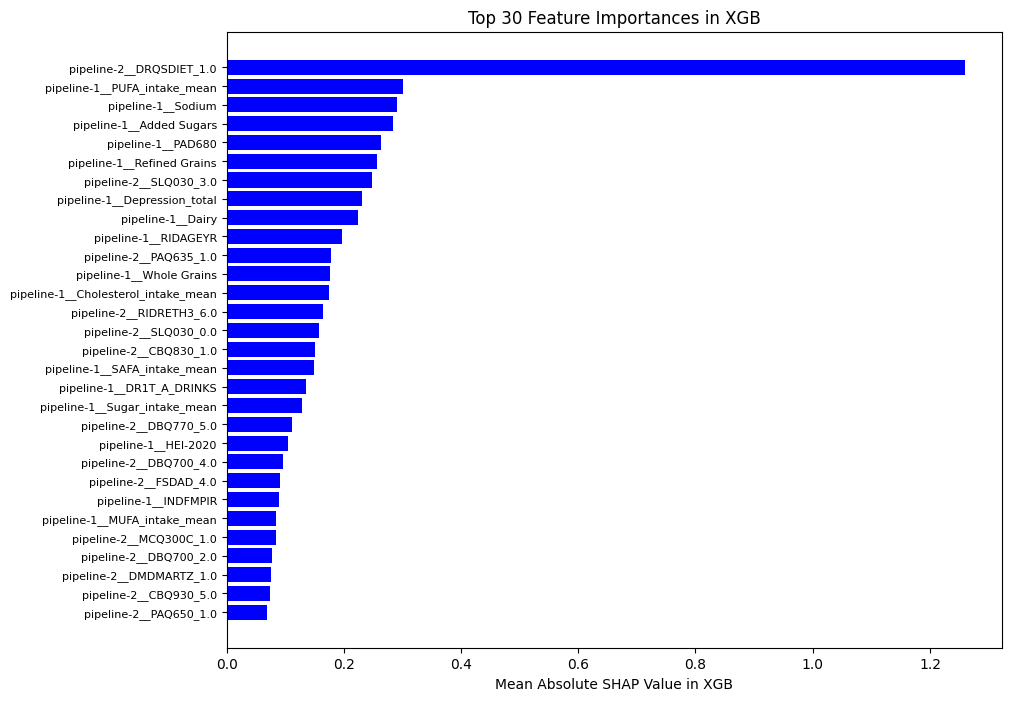

In [ ]:
# @title Plot the SHAP summary plot with feature names (XGBoost)
import matplotlib.pyplot as plt

# Select the top 30 features
top_features_sorted_xgb = features_sorted_xgb[:30]
# Flatten importances_sorted
if isinstance(importances_sorted_xgb[0], list):
    importances_sorted_xgb = [item for sublist in importances_sorted_xgb for item in sublist]

# Now select the top 30 features
importances_sorted_top_xgb = [importances_sorted_xgb[i] for i in range(30)]


print(len(top_features_sorted_xgb))
print(len(importances_sorted_top_xgb))

# Plot the feature importances
plt.figure(figsize=(10, 8))
plt.title('Top 30 Feature Importances in XGB')
plt.barh(range(len(top_features_sorted_xgb)), importances_sorted_top_xgb, color='b', align='center')
plt.yticks(range(len(top_features_sorted_xgb)), top_features_sorted_xgb, fontsize=8)
plt.xlabel('Mean Absolute SHAP Value in XGB')
plt.gca().invert_yaxis()  # Invert the y-axis to have the feature with the highest importance at the top
plt.show()

In [ ]:
# @title Mean importance of the features derived from the two models

# import numpy as np
# import shap
# import matplotlib.pyplot as plt

# # Function to calculate mean SHAP values and sort them
# def calculate_mean_shap_and_sort(explainer_rf, explainer_xgb, preprocessed_data_rf, preprocessed_data_xgb, transformed_column_names_rf, transformed_column_names_xgb):
#     # Calculate SHAP values on the preprocessed data
#     shap_values_rf = explainer_rf.shap_values(preprocessed_data_rf)
#     shap_values_xgb = explainer_xgb.shap_values(preprocessed_data_xgb)

#     # If SHAP values from RF are 3D (multi-class classification), take mean along the first axis
#     if len(shap_values_rf) == 3:
#         shap_values_rf = np.mean(shap_values_rf, axis=0)
#     else:
#         shap_values_rf = shap_values_rf[0]

#     # If SHAP values from XGB are 2D, reshape to match the number of samples
#     if len(shap_values_xgb.shape) == 2:
#         shap_values_xgb = np.expand_dims(shap_values_xgb, axis=0)

#     # Ensure that SHAP values from both models have the same number of features
#     num_features_rf = shap_values_rf.shape[1]
#     num_features_xgb = shap_values_xgb.shape[1]
#     min_num_features = min(num_features_rf, num_features_xgb)
#     shap_values_rf = shap_values_rf[:, :min_num_features]
#     shap_values_xgb = shap_values_xgb[:, :min_num_features]

#     # Combine SHAP values from both models
#     shap_values_combined = np.concatenate((shap_values_rf, shap_values_xgb))

#     # Calculate mean absolute SHAP values for each feature
#     mean_abs_shap_values_combined = np.abs(shap_values_combined).mean(axis=0)

#     # Combine feature names from both models
#     transformed_column_names_combined = transformed_column_names_rf[:min_num_features] + transformed_column_names_xgb[:min_num_features]

#     # Combine feature names and their corresponding mean SHAP values
#     feature_importance_combined = list(zip(transformed_column_names_combined, mean_abs_shap_values_combined))

#     # Sort features based on mean absolute SHAP values (importance)
#     feature_importance_sorted_combined = sorted(feature_importance_combined, key=lambda x: x[1], reverse=True)

#     return feature_importance_sorted_combined

# # Function to plot the top features
# def plot_top_features(feature_importance_sorted, top_n=30):
#     features_sorted, importances_sorted = zip(*feature_importance_sorted[:top_n])
#     y_pos = np.arange(len(features_sorted))
#     plt.figure(figsize=(10, 8))
#     plt.barh(y_pos, importances_sorted, align='center')
#     plt.yticks(y_pos, features_sorted)
#     plt.xlabel('Mean SHAP Values')
#     plt.title('Top 30 Features with Highest Mean SHAP Values')
#     plt.gca().invert_yaxis()
#     plt.show()

# # Calculate SHAP values for RandomForestClassifier
# explainer_rf = shap.Explainer(model_for_shap, preprocessed_df_obesity)
# # Calculate SHAP values for XGBClassifier
# explainer_xgb = shap.Explainer(model_for_shap_xgb, preprocessed_df_obesity_xgb)

# # Calculate mean SHAP values and sort them
# feature_importance_sorted_combined = calculate_mean_shap_and_sort(explainer_rf, explainer_xgb, preprocessed_df_obesity, preprocessed_df_obesity_xgb, transformed_column_names, transformed_column_names_xgb)

# # Print and plot the top features
# print("Top Features:")
# for feature, importance in feature_importance_sorted_combined:
#     print(f"{feature}: {importance}")
# plot_top_features(feature_importance_sorted_combined)




# Domain importances

In [ ]:
# @title Introduction of Domains


# feature_to_domain = {
# 'pipeline-1__RIDAGEYR': 'Sociodemographic',
# 'pipeline-1__INDFMPIR': 'Socioeconomic',
# 'pipeline-1__INDFMMPI': 'Socioeconomic',
# 'pipeline-1__PAD680': 'Physical activity',
# 'pipeline-1__SLD012': 'Sleep',
# 'pipeline-1__SLD013': 'Sleep',
# 'pipeline-1__DR1T_A_DRINKS': 'Dietary' ,
# 'pipeline-1__Depression_total' : 'Psychologic',
# 'pipeline-1__Total Fruits': 'Dietary' ,
# 'pipeline-1__Whole Fruits': 'Dietary' ,
# 'pipeline-1__Total Vegetables' : 'Dietary' ,
# 'pipeline-1__Greens and Beans': 'Dietary' ,
# 'pipeline-1__Whole Grains': 'Dietary' ,
# 'pipeline-1__Dairy': 'Dietary' ,
# 'pipeline-1__Total Protein Foods': 'Dietary' ,
# 'pipeline-1__Seafood and Plant Proteins': 'Dietary' ,
# 'pipeline-1__Fatty Acids Ratio (PUFAs + MUFAs)/SFAs': 'Dietary' ,
# 'pipeline-1__Refined Grains': 'Dietary' ,
# 'pipeline-1__Sodium' :'Dietary' ,
# 'pipeline-1__Added Sugars': 'Dietary' ,
# 'pipeline-1__Saturated Fats':'Dietary' ,
# 'pipeline-1__HEI-2020': 'Dietary' ,
# 'pipeline-1__Calorie_intake_mean':'Dietary' ,
# 'pipeline-1__Protein_intake_mean': 'Dietary' ,
# 'pipeline-1__Carb_intake_mean': 'Dietary' ,
# 'pipeline-1__Fat_intake_mean': 'Dietary' ,
# 'pipeline-1__Sugar_intake_mean': 'Dietary' ,
# 'pipeline-1__Fiber_intake_mean': 'Dietary' ,
# 'pipeline-1__SAFA_intake_mean': 'Dietary' ,
# 'pipeline-1__MUFA_intake_mean': 'Dietary' ,
# 'pipeline-1__PUFA_intake_mean': 'Dietary' ,
# 'pipeline-1__Cholesterol_intake_mean': 'Dietary' ,
# 'pipeline-2__RIAGENDR_1.0': 'Sociodemographic',
# 'pipeline-2__RIAGENDR_2.0': 'Sociodemographic',
# 'pipeline-2__RIDRETH3_1.0': 'Sociodemographic',
# 'pipeline-2__RIDRETH3_2.0': 'Sociodemographic',
# 'pipeline-2__RIDRETH3_3.0': 'Sociodemographic',
# 'pipeline-2__RIDRETH3_4.0': 'Sociodemographic',
# 'pipeline-2__RIDRETH3_6.0': 'Sociodemographic',
# 'pipeline-2__RIDRETH3_7.0': 'Sociodemographic',
# 'pipeline-2__DMDBORN4_1.0': 'Sociodemographic',
# 'pipeline-2__DMDBORN4_2.0': 'Sociodemographic',
# 'pipeline-2__DMDBORN4_77.0': 'Sociodemographic',
# 'pipeline-2__DMDBORN4_99.0': 'Sociodemographic',
# 'pipeline-2__DMDEDUC2_1.0': 'Sociodemographic',
# 'pipeline-2__DMDEDUC2_2.0': 'Sociodemographic',
# 'pipeline-2__DMDEDUC2_3.0': 'Sociodemographic',
# 'pipeline-2__DMDEDUC2_4.0': 'Sociodemographic',
# 'pipeline-2__DMDEDUC2_5.0': 'Sociodemographic',
# 'pipeline-2__DMDEDUC2_9.0': 'Sociodemographic',
# 'pipeline-2__DMDMARTZ_1.0': 'Sociodemographic',
# 'pipeline-2__DMDMARTZ_2.0': 'Sociodemographic',
# 'pipeline-2__DMDMARTZ_3.0': 'Sociodemographic',
# 'pipeline-2__DMDMARTZ_77.0': 'Sociodemographic',
# 'pipeline-2__CBQ506_1.0': 'Behavioral',
# 'pipeline-2__CBQ506_2.0': 'Behavioral',
# 'pipeline-2__CBQ536_1.0': 'Behavioral',
# 'pipeline-2__CBQ536_2.0': 'Behavioral',
# 'pipeline-2__CBQ536_9.0': 'Behavioral',
# 'pipeline-2__CBQ551_1.0': 'Behavioral',
# 'pipeline-2__CBQ551_2.0': 'Behavioral',
# 'pipeline-2__CBQ830_1.0': 'Behavioral',
# 'pipeline-2__CBQ830_2.0': 'Behavioral',
# 'pipeline-2__CBQ845_1.0': 'Behavioral',
# 'pipeline-2__CBQ845_2.0': 'Behavioral',
# 'pipeline-2__CBQ860_1.0': 'Behavioral',
# 'pipeline-2__CBQ860_2.0': 'Behavioral',
# 'pipeline-2__CBQ875_1.0': 'Behavioral',
# 'pipeline-2__CBQ875_2.0': 'Behavioral',
# 'pipeline-2__CBQ875_9.0': 'Behavioral',
# 'pipeline-2__CBQ890_1.0': 'Behavioral',
# 'pipeline-2__CBQ890_2.0': 'Behavioral',
# 'pipeline-2__CBQ890_9.0': 'Behavioral',
# 'pipeline-2__CBQ645_1.0': 'Behavioral',
# 'pipeline-2__CBQ645_2.0': 'Behavioral',
# 'pipeline-2__CBQ645_3.0': 'Behavioral',
# 'pipeline-2__CBQ645_4.0': 'Behavioral',
# 'pipeline-2__CBQ645_5.0': 'Behavioral',
# 'pipeline-2__CBQ645_6.0': 'Behavioral',
# 'pipeline-2__CBQ645_7.0': 'Behavioral',
# 'pipeline-2__CBQ645_99.0': 'Behavioral',
# 'pipeline-2__CBQ700_1.0': 'Behavioral',
# 'pipeline-2__CBQ700_2.0': 'Behavioral',
# 'pipeline-2__CBQ700_3.0': 'Behavioral',
# 'pipeline-2__CBQ700_4.0': 'Behavioral',
# 'pipeline-2__CBQ700_5.0': 'Behavioral',
# 'pipeline-2__CBQ700_6.0': 'Behavioral',
# 'pipeline-2__CBQ700_9.0': 'Behavioral',
# 'pipeline-2__DBQ780_1.0': 'Behavioral',
# 'pipeline-2__DBQ780_2.0': 'Behavioral',
# 'pipeline-2__DBQ780_3.0': 'Behavioral',
# 'pipeline-2__DBQ780_4.0': 'Behavioral',
# 'pipeline-2__DBQ780_5.0': 'Behavioral',
# 'pipeline-2__DBQ780_6.0': 'Behavioral',
# 'pipeline-2__DBQ780_9.0': 'Behavioral',
# 'pipeline-2__DBQ750_1.0': 'Behavioral',
# 'pipeline-2__DBQ750_2.0': 'Behavioral',
# 'pipeline-2__DBQ750_3.0': 'Behavioral',
# 'pipeline-2__DBQ750_4.0': 'Behavioral',
# 'pipeline-2__DBQ750_5.0': 'Behavioral',
# 'pipeline-2__DBQ750_9.0': 'Behavioral',
# 'pipeline-2__DBQ760_1.0': 'Behavioral',
# 'pipeline-2__DBQ760_2.0': 'Behavioral',
# 'pipeline-2__DBQ760_3.0': 'Behavioral',
# 'pipeline-2__DBQ760_4.0': 'Behavioral',
# 'pipeline-2__DBQ760_5.0': 'Behavioral',
# 'pipeline-2__DBQ760_9.0': 'Behavioral',
# 'pipeline-2__DBQ770_1.0': 'Behavioral',
# 'pipeline-2__DBQ770_2.0': 'Behavioral',
# 'pipeline-2__DBQ770_3.0': 'Behavioral',
# 'pipeline-2__DBQ770_4.0': 'Behavioral',
# 'pipeline-2__DBQ770_5.0': 'Behavioral',
# 'pipeline-2__DBQ770_6.0': 'Behavioral',
# 'pipeline-2__DBQ770_9.0': 'Behavioral',
# 'pipeline-2__CBQ905_1.0': 'Behavioral',
# 'pipeline-2__CBQ905_2.0': 'Behavioral',
# 'pipeline-2__CBQ905_3.0': 'Behavioral',
# 'pipeline-2__CBQ905_4.0': 'Behavioral',
# 'pipeline-2__CBQ905_5.0': 'Behavioral',
# 'pipeline-2__CBQ905_6.0': 'Behavioral',
# 'pipeline-2__CBQ905_9.0': 'Behavioral',
# 'pipeline-2__CBQ910_1.0': 'Behavioral',
# 'pipeline-2__CBQ910_2.0': 'Behavioral',
# 'pipeline-2__CBQ910_3.0': 'Behavioral',
# 'pipeline-2__CBQ910_4.0': 'Behavioral',
# 'pipeline-2__CBQ910_5.0': 'Behavioral',
# 'pipeline-2__CBQ910_6.0': 'Behavioral',
# 'pipeline-2__CBQ910_9.0': 'Behavioral',
# 'pipeline-2__CBQ685_1.0': 'Behavioral',
# 'pipeline-2__CBQ685_2.0': 'Behavioral',
# 'pipeline-2__CBQ685_3.0': 'Behavioral',
# 'pipeline-2__CBQ685_4.0': 'Behavioral',
# 'pipeline-2__CBQ685_5.0': 'Behavioral',
# 'pipeline-2__CBQ685_6.0': 'Behavioral',
# 'pipeline-2__CBQ685_9.0': 'Behavioral',
# 'pipeline-2__CBQ915_1.0': 'Behavioral',
# 'pipeline-2__CBQ915_2.0': 'Behavioral',
# 'pipeline-2__CBQ915_3.0': 'Behavioral',
# 'pipeline-2__CBQ915_4.0': 'Behavioral',
# 'pipeline-2__CBQ915_5.0': 'Behavioral',
# 'pipeline-2__CBQ915_6.0': 'Behavioral',
# 'pipeline-2__CBQ915_9.0': 'Behavioral',
# 'pipeline-2__CBD925_1.0': 'Behavioral',
# 'pipeline-2__CBD925_2.0': 'Behavioral',
# 'pipeline-2__CBD925_3.0': 'Behavioral',
# 'pipeline-2__CBD925_7.0': 'Behavioral',
# 'pipeline-2__CBD925_9.0': 'Behavioral',
# 'pipeline-2__CBQ930_1.0': 'Behavioral',
# 'pipeline-2__CBQ930_2.0': 'Behavioral',
# 'pipeline-2__CBQ930_3.0': 'Behavioral',
# 'pipeline-2__CBQ930_4.0': 'Behavioral',
# 'pipeline-2__CBQ930_5.0': 'Behavioral',
# 'pipeline-2__CBQ930_6.0': 'Behavioral',
# 'pipeline-2__CBQ930_9.0': 'Behavioral',
# 'pipeline-2__CBQ935_1.0': 'Behavioral',
# 'pipeline-2__CBQ935_2.0': 'Behavioral',
# 'pipeline-2__CBQ935_3.0': 'Behavioral',
# 'pipeline-2__CBQ935_4.0': 'Behavioral',
# 'pipeline-2__CBQ935_5.0': 'Behavioral',
# 'pipeline-2__CBQ935_6.0': 'Behavioral',
# 'pipeline-2__CBQ935_9.0': 'Behavioral',
# 'pipeline-2__CBQ945_1.0': 'Behavioral',
# 'pipeline-2__CBQ945_2.0': 'Behavioral',
# 'pipeline-2__CBQ945_3.0': 'Behavioral',
# 'pipeline-2__CBQ945_4.0': 'Behavioral',
# 'pipeline-2__CBQ945_5.0': 'Behavioral',
# 'pipeline-2__CBQ945_6.0': 'Behavioral',
# 'pipeline-2__CBQ945_9.0': 'Behavioral',
# 'pipeline-2__CBQ950_1.0': 'Behavioral',
# 'pipeline-2__CBQ950_2.0': 'Behavioral',
# 'pipeline-2__CBQ950_3.0': 'Behavioral',
# 'pipeline-2__CBQ950_4.0': 'Behavioral',
# 'pipeline-2__CBQ950_5.0': 'Behavioral',
# 'pipeline-2__CBQ950_6.0': 'Behavioral',
# 'pipeline-2__CBQ950_9.0': 'Behavioral',
# 'pipeline-2__DBQ700_1.0': 'Behavioral',
# 'pipeline-2__DBQ700_2.0': 'Behavioral',
# 'pipeline-2__DBQ700_3.0': 'Behavioral',
# 'pipeline-2__DBQ700_4.0': 'Behavioral',
# 'pipeline-2__DBQ700_5.0': 'Behavioral',
# 'pipeline-2__DBQ700_9.0': 'Behavioral',
# 'pipeline-2__CBQ596_1.0': 'Behavioral',
# 'pipeline-2__CBQ596_2.0': 'Behavioral',
# 'pipeline-2__CBQ596_9.0': 'Behavioral',
# 'pipeline-2__DRQSDIET_1.0': 'Behavioral',
# 'pipeline-2__DRQSDIET_2.0': 'Behavioral',
# 'pipeline-2__DR2STY_1.0': 'Behavioral',
# 'pipeline-2__DR2STY_2.0': 'Behavioral',
# 'pipeline-2__FSDHH_1.0': 'Socioeconomic',
# 'pipeline-2__FSDHH_2.0': 'Socioeconomic',
# 'pipeline-2__FSDHH_3.0': 'Socioeconomic',
# 'pipeline-2__FSDHH_4.0': 'Socioeconomic',
# 'pipeline-2__FSDAD_1.0': 'Socioeconomic',
# 'pipeline-2__FSDAD_2.0': 'Socioeconomic',
# 'pipeline-2__FSDAD_3.0': 'Socioeconomic',
# 'pipeline-2__FSDAD_4.0': 'Socioeconomic',
# 'pipeline-2__INDFMMPC_1.0': 'Socioeconomic',
# 'pipeline-2__INDFMMPC_2.0': 'Socioeconomic',
# 'pipeline-2__INDFMMPC_3.0': 'Socioeconomic',
# 'pipeline-2__INDFMMPC_7.0': 'Socioeconomic',
# 'pipeline-2__INDFMMPC_9.0': 'Socioeconomic',
# 'pipeline-2__MCQ300C_1.0': 'Medical history',
# 'pipeline-2__MCQ300C_2.0': 'Medical history',
# 'pipeline-2__MCQ300C_9.0': 'Medical history',
# 'pipeline-2__MCQ300A_1.0': 'Medical history',
# 'pipeline-2__MCQ300A_2.0': 'Medical history',
# 'pipeline-2__MCQ300A_9.0': 'Medical history',
# 'pipeline-2__PAQ605_1.0': 'Physical activity',
# 'pipeline-2__PAQ605_2.0': 'Physical activity',
# 'pipeline-2__PAQ605_9.0': 'Physical activity',
# 'pipeline-2__PAQ620_1.0': 'Physical activity',
# 'pipeline-2__PAQ620_2.0': 'Physical activity',
# 'pipeline-2__PAQ620_9.0': 'Physical activity',
# 'pipeline-2__PAQ635_1.0': 'Physical activity',
# 'pipeline-2__PAQ635_2.0': 'Physical activity',
# 'pipeline-2__PAQ635_9.0': 'Physical activity',
# 'pipeline-2__PAQ650_1.0': 'Physical activity',
# 'pipeline-2__PAQ650_2.0': 'Physical activity',
# 'pipeline-2__PAQ665_1.0': 'Physical activity',
# 'pipeline-2__PAQ665_2.0': 'Physical activity',
# 'pipeline-2__PAQ665_9.0': 'Physical activity',
# 'pipeline-2__SLQ030_0.0': 'Sleep',
# 'pipeline-2__SLQ030_1.0': 'Sleep',
# 'pipeline-2__SLQ030_2.0': 'Sleep',
# 'pipeline-2__SLQ030_3.0': 'Sleep',
# 'pipeline-2__SLQ030_7.0': 'Sleep',
# 'pipeline-2__SLQ030_9.0': 'Sleep',
# 'pipeline-2__SLQ040_0.0': 'Sleep',
# 'pipeline-2__SLQ040_1.0': 'Sleep',
# 'pipeline-2__SLQ040_2.0': 'Sleep',
# 'pipeline-2__SLQ040_3.0': 'Sleep',
# 'pipeline-2__SLQ040_7.0': 'Sleep',
# 'pipeline-2__SLQ040_9.0': 'Sleep',
# 'pipeline-2__SLQ050_1.0': 'Sleep',
# 'pipeline-2__SLQ050_2.0': 'Sleep',
# 'pipeline-2__SLQ050_9.0': 'Sleep',
# 'pipeline-2__SLQ120_0.0': 'Sleep',
# 'pipeline-2__SLQ120_1.0': 'Sleep',
# 'pipeline-2__SLQ120_2.0': 'Sleep',
# 'pipeline-2__SLQ120_3.0': 'Sleep',
# 'pipeline-2__SLQ120_4.0': 'Sleep',
# 'pipeline-2__SLQ120_9.0': 'Sleep'
# }


# @title Introduction of Domains


feature_to_domain = {
'pipeline-1__RIDAGEYR': 'Intrinsic factors',
'pipeline-1__INDFMPIR': 'Socioeconomic',
'pipeline-1__INDFMMPI': 'Socioeconomic',
'pipeline-1__PAD680': 'Physical activity',
'pipeline-1__SLD012': 'Sleep',
'pipeline-1__SLD013': 'Sleep',
'pipeline-1__DR1T_A_DRINKS': 'Dietary' ,
'pipeline-1__Depression_total' : 'Depression',
'pipeline-1__Total Fruits': 'Dietary' ,
'pipeline-1__Whole Fruits': 'Dietary' ,
'pipeline-1__Total Vegetables' : 'Dietary' ,
'pipeline-1__Greens and Beans': 'Dietary' ,
'pipeline-1__Whole Grains': 'Dietary' ,
'pipeline-1__Dairy': 'Dietary' ,
'pipeline-1__Total Protein Foods': 'Dietary' ,
'pipeline-1__Seafood and Plant Proteins': 'Dietary' ,
'pipeline-1__Fatty Acids Ratio (PUFAs + MUFAs)/SFAs': 'Dietary' ,
'pipeline-1__Refined Grains': 'Dietary' ,
'pipeline-1__Sodium' :'Dietary' ,
'pipeline-1__Added Sugars': 'Dietary' ,
'pipeline-1__Saturated Fats':'Dietary' ,
'pipeline-1__HEI-2020': 'Dietary' ,
'pipeline-1__Calorie_intake_mean':'Dietary' ,
'pipeline-1__Protein_intake_mean': 'Dietary' ,
'pipeline-1__Carb_intake_mean': 'Dietary' ,
'pipeline-1__Fat_intake_mean': 'Dietary' ,
'pipeline-1__Sugar_intake_mean': 'Dietary' ,
'pipeline-1__Fiber_intake_mean': 'Dietary' ,
'pipeline-1__SAFA_intake_mean': 'Dietary' ,
'pipeline-1__MUFA_intake_mean': 'Dietary' ,
'pipeline-1__PUFA_intake_mean': 'Dietary' ,
'pipeline-1__Cholesterol_intake_mean': 'Dietary' ,
'pipeline-2__RIAGENDR_1.0': 'Intrinsic factors',
'pipeline-2__RIAGENDR_2.0': 'Intrinsic factors',
'pipeline-2__RIDRETH3_1.0': 'Intrinsic factors',
'pipeline-2__RIDRETH3_2.0': 'Intrinsic factors',
'pipeline-2__RIDRETH3_3.0': 'Intrinsic factors',
'pipeline-2__RIDRETH3_4.0': 'Intrinsic factors',
'pipeline-2__RIDRETH3_6.0': 'Intrinsic factors',
'pipeline-2__RIDRETH3_7.0': 'Intrinsic factors',
'pipeline-2__DMDBORN4_1.0': 'Intrinsic factors',
'pipeline-2__DMDBORN4_2.0': 'Intrinsic factors',
'pipeline-2__DMDBORN4_77.0': 'Intrinsic factors',
'pipeline-2__DMDBORN4_99.0': 'Intrinsic factors',
'pipeline-2__DMDEDUC2_1.0': 'Intrinsic factors',
'pipeline-2__DMDEDUC2_2.0': 'Intrinsic factors',
'pipeline-2__DMDEDUC2_3.0': 'Intrinsic factors',
'pipeline-2__DMDEDUC2_4.0': 'Intrinsic factors',
'pipeline-2__DMDEDUC2_5.0': 'Intrinsic factors',
'pipeline-2__DMDEDUC2_9.0': 'Intrinsic factors',
'pipeline-2__DMDMARTZ_1.0': 'Intrinsic factors',
'pipeline-2__DMDMARTZ_2.0': 'Intrinsic factors',
'pipeline-2__DMDMARTZ_3.0': 'Intrinsic factors',
'pipeline-2__DMDMARTZ_77.0': 'Intrinsic factors',
'pipeline-2__CBQ506_1.0': 'Behavioral',
'pipeline-2__CBQ506_2.0': 'Behavioral',
'pipeline-2__CBQ536_1.0': 'Behavioral',
'pipeline-2__CBQ536_2.0': 'Behavioral',
'pipeline-2__CBQ536_9.0': 'Behavioral',
'pipeline-2__CBQ551_1.0': 'Behavioral',
'pipeline-2__CBQ551_2.0': 'Behavioral',
'pipeline-2__CBQ830_1.0': 'Behavioral',
'pipeline-2__CBQ830_2.0': 'Behavioral',
'pipeline-2__CBQ845_1.0': 'Behavioral',
'pipeline-2__CBQ845_2.0': 'Behavioral',
'pipeline-2__CBQ860_1.0': 'Behavioral',
'pipeline-2__CBQ860_2.0': 'Behavioral',
'pipeline-2__CBQ875_1.0': 'Behavioral',
'pipeline-2__CBQ875_2.0': 'Behavioral',
'pipeline-2__CBQ875_9.0': 'Behavioral',
'pipeline-2__CBQ890_1.0': 'Behavioral',
'pipeline-2__CBQ890_2.0': 'Behavioral',
'pipeline-2__CBQ890_9.0': 'Behavioral',
'pipeline-2__CBQ645_1.0': 'Behavioral',
'pipeline-2__CBQ645_2.0': 'Behavioral',
'pipeline-2__CBQ645_3.0': 'Behavioral',
'pipeline-2__CBQ645_4.0': 'Behavioral',
'pipeline-2__CBQ645_5.0': 'Behavioral',
'pipeline-2__CBQ645_6.0': 'Behavioral',
'pipeline-2__CBQ645_7.0': 'Behavioral',
'pipeline-2__CBQ645_99.0': 'Behavioral',
'pipeline-2__CBQ700_1.0': 'Behavioral',
'pipeline-2__CBQ700_2.0': 'Behavioral',
'pipeline-2__CBQ700_3.0': 'Behavioral',
'pipeline-2__CBQ700_4.0': 'Behavioral',
'pipeline-2__CBQ700_5.0': 'Behavioral',
'pipeline-2__CBQ700_6.0': 'Behavioral',
'pipeline-2__CBQ700_9.0': 'Behavioral',
'pipeline-2__DBQ780_1.0': 'Behavioral',
'pipeline-2__DBQ780_2.0': 'Behavioral',
'pipeline-2__DBQ780_3.0': 'Behavioral',
'pipeline-2__DBQ780_4.0': 'Behavioral',
'pipeline-2__DBQ780_5.0': 'Behavioral',
'pipeline-2__DBQ780_6.0': 'Behavioral',
'pipeline-2__DBQ780_9.0': 'Behavioral',
'pipeline-2__DBQ750_1.0': 'Behavioral',
'pipeline-2__DBQ750_2.0': 'Behavioral',
'pipeline-2__DBQ750_3.0': 'Behavioral',
'pipeline-2__DBQ750_4.0': 'Behavioral',
'pipeline-2__DBQ750_5.0': 'Behavioral',
'pipeline-2__DBQ750_9.0': 'Behavioral',
'pipeline-2__DBQ760_1.0': 'Behavioral',
'pipeline-2__DBQ760_2.0': 'Behavioral',
'pipeline-2__DBQ760_3.0': 'Behavioral',
'pipeline-2__DBQ760_4.0': 'Behavioral',
'pipeline-2__DBQ760_5.0': 'Behavioral',
'pipeline-2__DBQ760_9.0': 'Behavioral',
'pipeline-2__DBQ770_1.0': 'Behavioral',
'pipeline-2__DBQ770_2.0': 'Behavioral',
'pipeline-2__DBQ770_3.0': 'Behavioral',
'pipeline-2__DBQ770_4.0': 'Behavioral',
'pipeline-2__DBQ770_5.0': 'Behavioral',
'pipeline-2__DBQ770_6.0': 'Behavioral',
'pipeline-2__DBQ770_9.0': 'Behavioral',
'pipeline-2__CBQ905_1.0': 'Behavioral',
'pipeline-2__CBQ905_2.0': 'Behavioral',
'pipeline-2__CBQ905_3.0': 'Behavioral',
'pipeline-2__CBQ905_4.0': 'Behavioral',
'pipeline-2__CBQ905_5.0': 'Behavioral',
'pipeline-2__CBQ905_6.0': 'Behavioral',
'pipeline-2__CBQ905_9.0': 'Behavioral',
'pipeline-2__CBQ910_1.0': 'Behavioral',
'pipeline-2__CBQ910_2.0': 'Behavioral',
'pipeline-2__CBQ910_3.0': 'Behavioral',
'pipeline-2__CBQ910_4.0': 'Behavioral',
'pipeline-2__CBQ910_5.0': 'Behavioral',
'pipeline-2__CBQ910_6.0': 'Behavioral',
'pipeline-2__CBQ910_9.0': 'Behavioral',
'pipeline-2__CBQ685_1.0': 'Behavioral',
'pipeline-2__CBQ685_2.0': 'Behavioral',
'pipeline-2__CBQ685_3.0': 'Behavioral',
'pipeline-2__CBQ685_4.0': 'Behavioral',
'pipeline-2__CBQ685_5.0': 'Behavioral',
'pipeline-2__CBQ685_6.0': 'Behavioral',
'pipeline-2__CBQ685_9.0': 'Behavioral',
'pipeline-2__CBQ915_1.0': 'Behavioral',
'pipeline-2__CBQ915_2.0': 'Behavioral',
'pipeline-2__CBQ915_3.0': 'Behavioral',
'pipeline-2__CBQ915_4.0': 'Behavioral',
'pipeline-2__CBQ915_5.0': 'Behavioral',
'pipeline-2__CBQ915_6.0': 'Behavioral',
'pipeline-2__CBQ915_9.0': 'Behavioral',
'pipeline-2__CBD925_1.0': 'Behavioral',
'pipeline-2__CBD925_2.0': 'Behavioral',
'pipeline-2__CBD925_3.0': 'Behavioral',
'pipeline-2__CBD925_7.0': 'Behavioral',
'pipeline-2__CBD925_9.0': 'Behavioral',
'pipeline-2__CBQ930_1.0': 'Behavioral',
'pipeline-2__CBQ930_2.0': 'Behavioral',
'pipeline-2__CBQ930_3.0': 'Behavioral',
'pipeline-2__CBQ930_4.0': 'Behavioral',
'pipeline-2__CBQ930_5.0': 'Behavioral',
'pipeline-2__CBQ930_6.0': 'Behavioral',
'pipeline-2__CBQ930_9.0': 'Behavioral',
'pipeline-2__CBQ935_1.0': 'Behavioral',
'pipeline-2__CBQ935_2.0': 'Behavioral',
'pipeline-2__CBQ935_3.0': 'Behavioral',
'pipeline-2__CBQ935_4.0': 'Behavioral',
'pipeline-2__CBQ935_5.0': 'Behavioral',
'pipeline-2__CBQ935_6.0': 'Behavioral',
'pipeline-2__CBQ935_9.0': 'Behavioral',
'pipeline-2__CBQ945_1.0': 'Behavioral',
'pipeline-2__CBQ945_2.0': 'Behavioral',
'pipeline-2__CBQ945_3.0': 'Behavioral',
'pipeline-2__CBQ945_4.0': 'Behavioral',
'pipeline-2__CBQ945_5.0': 'Behavioral',
'pipeline-2__CBQ945_6.0': 'Behavioral',
'pipeline-2__CBQ945_9.0': 'Behavioral',
'pipeline-2__CBQ950_1.0': 'Behavioral',
'pipeline-2__CBQ950_2.0': 'Behavioral',
'pipeline-2__CBQ950_3.0': 'Behavioral',
'pipeline-2__CBQ950_4.0': 'Behavioral',
'pipeline-2__CBQ950_5.0': 'Behavioral',
'pipeline-2__CBQ950_6.0': 'Behavioral',
'pipeline-2__CBQ950_9.0': 'Behavioral',
'pipeline-2__DBQ700_1.0': 'Behavioral',
'pipeline-2__DBQ700_2.0': 'Behavioral',
'pipeline-2__DBQ700_3.0': 'Behavioral',
'pipeline-2__DBQ700_4.0': 'Behavioral',
'pipeline-2__DBQ700_5.0': 'Behavioral',
'pipeline-2__DBQ700_9.0': 'Behavioral',
'pipeline-2__CBQ596_1.0': 'Behavioral',
'pipeline-2__CBQ596_2.0': 'Behavioral',
'pipeline-2__CBQ596_9.0': 'Behavioral',
'pipeline-2__DRQSDIET_1.0': 'Behavioral',
'pipeline-2__DRQSDIET_2.0': 'Behavioral',
'pipeline-2__DR2STY_1.0': 'Behavioral',
'pipeline-2__DR2STY_2.0': 'Behavioral',
'pipeline-2__FSDHH_1.0': 'Socioeconomic',
'pipeline-2__FSDHH_2.0': 'Socioeconomic',
'pipeline-2__FSDHH_3.0': 'Socioeconomic',
'pipeline-2__FSDHH_4.0': 'Socioeconomic',
'pipeline-2__FSDAD_1.0': 'Socioeconomic',
'pipeline-2__FSDAD_2.0': 'Socioeconomic',
'pipeline-2__FSDAD_3.0': 'Socioeconomic',
'pipeline-2__FSDAD_4.0': 'Socioeconomic',
'pipeline-2__INDFMMPC_1.0': 'Socioeconomic',
'pipeline-2__INDFMMPC_2.0': 'Socioeconomic',
'pipeline-2__INDFMMPC_3.0': 'Socioeconomic',
'pipeline-2__INDFMMPC_7.0': 'Socioeconomic',
'pipeline-2__INDFMMPC_9.0': 'Socioeconomic',
'pipeline-2__MCQ300C_1.0': 'Intrinsic factors',
'pipeline-2__MCQ300C_2.0': 'Intrinsic factors',
'pipeline-2__MCQ300C_9.0': 'Intrinsic factors',
'pipeline-2__MCQ300A_1.0': 'Intrinsic factors',
'pipeline-2__MCQ300A_2.0': 'Intrinsic factors',
'pipeline-2__MCQ300A_9.0': 'Intrinsic factors',
'pipeline-2__PAQ605_1.0': 'Physical activity',
'pipeline-2__PAQ605_2.0': 'Physical activity',
'pipeline-2__PAQ605_9.0': 'Physical activity',
'pipeline-2__PAQ620_1.0': 'Physical activity',
'pipeline-2__PAQ620_2.0': 'Physical activity',
'pipeline-2__PAQ620_9.0': 'Physical activity',
'pipeline-2__PAQ635_1.0': 'Physical activity',
'pipeline-2__PAQ635_2.0': 'Physical activity',
'pipeline-2__PAQ635_9.0': 'Physical activity',
'pipeline-2__PAQ650_1.0': 'Physical activity',
'pipeline-2__PAQ650_2.0': 'Physical activity',
'pipeline-2__PAQ665_1.0': 'Physical activity',
'pipeline-2__PAQ665_2.0': 'Physical activity',
'pipeline-2__PAQ665_9.0': 'Physical activity',
'pipeline-2__SLQ030_0.0': 'Sleep',
'pipeline-2__SLQ030_1.0': 'Sleep',
'pipeline-2__SLQ030_2.0': 'Sleep',
'pipeline-2__SLQ030_3.0': 'Sleep',
'pipeline-2__SLQ030_7.0': 'Sleep',
'pipeline-2__SLQ030_9.0': 'Sleep',
'pipeline-2__SLQ040_0.0': 'Sleep',
'pipeline-2__SLQ040_1.0': 'Sleep',
'pipeline-2__SLQ040_2.0': 'Sleep',
'pipeline-2__SLQ040_3.0': 'Sleep',
'pipeline-2__SLQ040_7.0': 'Sleep',
'pipeline-2__SLQ040_9.0': 'Sleep',
'pipeline-2__SLQ050_1.0': 'Sleep',
'pipeline-2__SLQ050_2.0': 'Sleep',
'pipeline-2__SLQ050_9.0': 'Sleep',
'pipeline-2__SLQ120_0.0': 'Sleep',
'pipeline-2__SLQ120_1.0': 'Sleep',
'pipeline-2__SLQ120_2.0': 'Sleep',
'pipeline-2__SLQ120_3.0': 'Sleep',
'pipeline-2__SLQ120_4.0': 'Sleep',
'pipeline-2__SLQ120_9.0': 'Sleep'
}



In [ ]:
# @title Original Domains

# from collections import defaultdict

# # Initial dictionary
# feature_to_domain = {
#     'pipeline-1__RIDAGEYR': 'Sociodemographic',
#     'pipeline-1__INDFMPIR': 'Socioeconomic',
#     'pipeline-1__INDFMMPI': 'Socioeconomic',
#     'pipeline-1__PAD680': 'Physical activity',
#     'pipeline-1__SLD012': 'Sleep',
#     'pipeline-1__SLD013': 'Sleep',
#     'pipeline-1__DR1T_A_DRINKS': 'Dietary',
#     'pipeline-1__Depression_total': 'Psychologic',
#     'pipeline-1__Total Fruits': 'Dietary',
#     'pipeline-1__Whole Fruits': 'Dietary',
#     'pipeline-1__Total Vegetables': 'Dietary',
#     'pipeline-1__Greens and Beans': 'Dietary',
#     'pipeline-1__Whole Grains': 'Dietary',
#     'pipeline-1__Dairy': 'Dietary',
#     'pipeline-1__Total Protein Foods': 'Dietary',
#     'pipeline-1__Seafood and Plant Proteins': 'Dietary',
#     'pipeline-1__Fatty Acids Ratio (PUFAs + MUFAs)/SFAs': 'Dietary',
#     'pipeline-1__Refined Grains': 'Dietary',
#     'pipeline-1__Sodium': 'Dietary',
#     'pipeline-1__Added Sugars': 'Dietary',
#     'pipeline-1__Saturated Fats': 'Dietary',
#     'pipeline-1__HEI-2020': 'Dietary',
#     'pipeline-1__Calorie_intake_mean': 'Dietary',
#     'pipeline-1__Protein_intake_mean': 'Dietary',
#     'pipeline-1__Carb_intake_mean': 'Dietary',
#     'pipeline-1__Fat_intake_mean': 'Dietary',
#     'pipeline-1__Sugar_intake_mean': 'Dietary',
#     'pipeline-1__Fiber_intake_mean': 'Dietary',
#     'pipeline-1__SAFA_intake_mean': 'Dietary',
#     'pipeline-1__MUFA_intake_mean': 'Dietary',
#     'pipeline-1__PUFA_intake_mean': 'Dietary',
#     'pipeline-1__Cholesterol_intake_mean': 'Dietary',
#     'pipeline-2__RIAGENDR_1.0': 'Sociodemographic',
#     'pipeline-2__RIAGENDR_2.0': 'Sociodemographic',
#     'pipeline-2__RIDRETH3_1.0': 'Sociodemographic',
#     'pipeline-2__RIDRETH3_2.0': 'Sociodemographic',
#     'pipeline-2__RIDRETH3_3.0': 'Sociodemographic',
#     'pipeline-2__RIDRETH3_4.0': 'Sociodemographic',
#     'pipeline-2__RIDRETH3_6.0': 'Sociodemographic',
#     'pipeline-2__RIDRETH3_7.0': 'Sociodemographic',
#     'pipeline-2__DMDBORN4_1.0': 'Sociodemographic',
#     'pipeline-2__DMDBORN4_2.0': 'Sociodemographic',
#     'pipeline-2__DMDBORN4_77.0': 'Sociodemographic',
#     'pipeline-2__DMDBORN4_99.0': 'Sociodemographic',
#     'pipeline-2__DMDEDUC2_1.0': 'Sociodemographic',
#     'pipeline-2__DMDEDUC2_2.0': 'Sociodemographic',
#     'pipeline-2__DMDEDUC2_3.0': 'Sociodemographic',
#     'pipeline-2__DMDEDUC2_4.0': 'Sociodemographic',
#     'pipeline-2__DMDEDUC2_5.0': 'Sociodemographic',
#     'pipeline-2__DMDEDUC2_9.0': 'Sociodemographic',
#     'pipeline-2__DMDMARTZ_1.0': 'Sociodemographic',
#     'pipeline-2__DMDMARTZ_2.0': 'Sociodemographic',
#     'pipeline-2__DMDMARTZ_3.0': 'Sociodemographic',
#     'pipeline-2__DMDMARTZ_77.0': 'Sociodemographic',
#     'pipeline-2__CBQ506_1.0': 'Behavioral',
#     'pipeline-2__CBQ506_2.0': 'Behavioral',
#     'pipeline-2__CBQ536_1.0': 'Behavioral',
#     'pipeline-2__CBQ536_2.0': 'Behavioral',
#     'pipeline-2__CBQ536_9.0': 'Behavioral',
#     'pipeline-2__CBQ551_1.0': 'Behavioral',
#     'pipeline-2__CBQ551_2.0': 'Behavioral',
#     'pipeline-2__CBQ830_1.0': 'Behavioral',
#     'pipeline-2__CBQ830_2.0': 'Behavioral',
#     'pipeline-2__CBQ845_1.0': 'Behavioral',
#     'pipeline-2__CBQ845_2.0': 'Behavioral',
#     'pipeline-2__CBQ860_1.0': 'Behavioral',
#     'pipeline-2__CBQ860_2.0': 'Behavioral',
#     'pipeline-2__CBQ875_1.0': 'Behavioral',
#     'pipeline-2__CBQ875_2.0': 'Behavioral',
#     'pipeline-2__CBQ875_9.0': 'Behavioral',
#     'pipeline-2__CBQ890_1.0': 'Behavioral',
#     'pipeline-2__CBQ890_2.0': 'Behavioral',
#     'pipeline-2__CBQ890_9.0': 'Behavioral',
#     'pipeline-2__CBQ645_1.0': 'Behavioral',
#     'pipeline-2__CBQ645_2.0': 'Behavioral',
#     'pipeline-2__CBQ645_3.0': 'Behavioral',
#     'pipeline-2__CBQ645_4.0': 'Behavioral',
#     'pipeline-2__CBQ645_5.0': 'Behavioral',
#     'pipeline-2__CBQ645_6.0': 'Behavioral',
#     'pipeline-2__CBQ645_7.0': 'Behavioral',
#     'pipeline-2__CBQ645_99.0': 'Behavioral',
#     'pipeline-2__CBQ700_1.0': 'Behavioral',
#     'pipeline-2__CBQ700_2.0': 'Behavioral',
#     'pipeline-2__CBQ700_3.0': 'Behavioral',
#     'pipeline-2__CBQ700_4.0': 'Behavioral',
#     'pipeline-2__CBQ700_5.0': 'Behavioral',
#     'pipeline-2__CBQ700_6.0': 'Behavioral',
#     'pipeline-2__CBQ700_9.0': 'Behavioral',
#     'pipeline-2__DBQ780_1.0': 'Behavioral',
#     'pipeline-2__DBQ780_2.0': 'Behavioral',
#     'pipeline-2__DBQ780_3.0': 'Behavioral',
#     'pipeline-2__DBQ780_4.0': 'Behavioral',
#     'pipeline-2__DBQ780_5.0': 'Behavioral',
#     'pipeline-2__DBQ780_6.0': 'Behavioral',
#     'pipeline-2__DBQ780_9.0': 'Behavioral',
#     'pipeline-2__DBQ750_1.0': 'Behavioral',
#     'pipeline-2__DBQ750_2.0': 'Behavioral',
#     'pipeline-2__DBQ750_3.0': 'Behavioral',
#     'pipeline-2__DBQ750_4.0': 'Behavioral',
#     'pipeline-2__DBQ750_5.0': 'Behavioral',
#     'pipeline-2__DBQ750_9.0': 'Behavioral',
#     'pipeline-2__DBQ760_1.0': 'Behavioral',
#     'pipeline-2__DBQ760_2.0': 'Behavioral',
#     'pipeline-2__DBQ760_3.0': 'Behavioral',
#     'pipeline-2__DBQ760_4.0': 'Behavioral',
#     'pipeline-2__DBQ760_5.0': 'Behavioral',
#     'pipeline-2__DBQ760_9.0': 'Behavioral',
#     'pipeline-2__DBQ770_1.0': 'Behavioral',
#     'pipeline-2__DBQ770_2.0': 'Behavioral',
#     'pipeline-2__DBQ770_3.0': 'Behavioral',
#     'pipeline-2__DBQ770_4.0': 'Behavioral',
#     'pipeline-2__DBQ770_5.0': 'Behavioral',
#     'pipeline-2__DBQ770_6.0': 'Behavioral',
#     'pipeline-2__DBQ770_9.0': 'Behavioral',
#     'pipeline-2__CBQ905_1.0': 'Behavioral',
#     'pipeline-2__CBQ905_2.0': 'Behavioral',
#     'pipeline-2__CBQ905_3.0': 'Behavioral',
#     'pipeline-2__CBQ905_4.0': 'Behavioral',
#     'pipeline-2__CBQ905_5.0': 'Behavioral',
#     'pipeline-2__CBQ905_6.0': 'Behavioral',
#     'pipeline-2__CBQ905_9.0': 'Behavioral',
#     'pipeline-2__CBQ910_1.0': 'Behavioral',
#     'pipeline-2__CBQ910_2.0': 'Behavioral',
#     'pipeline-2__CBQ910_3.0': 'Behavioral',
#     'pipeline-2__CBQ910_4.0': 'Behavioral',
#     'pipeline-2__CBQ910_5.0': 'Behavioral',
#     'pipeline-2__CBQ910_6.0': 'Behavioral',
#     'pipeline-2__CBQ910_9.0': 'Behavioral',
#     'pipeline-2__CBQ685_1.0': 'Behavioral',
#     'pipeline-2__CBQ685_2.0': 'Behavioral',
#     'pipeline-2__CBQ685_3.0': 'Behavioral',
#     'pipeline-2__CBQ685_4.0': 'Behavioral',
#     'pipeline-2__CBQ685_5.0': 'Behavioral',
#     'pipeline-2__CBQ685_6.0': 'Behavioral',
#     'pipeline-2__CBQ685_9.0': 'Behavioral',
#     'pipeline-2__CBQ915_1.0': 'Behavioral',
#     'pipeline-2__CBQ915_2.0': 'Behavioral',
#     'pipeline-2__CBQ915_3.0': 'Behavioral',
#     'pipeline-2__CBQ915_4.0': 'Behavioral',
#     'pipeline-2__CBQ915_5.0': 'Behavioral',
#     'pipeline-2__CBQ915_6.0': 'Behavioral',
#     'pipeline-2__CBQ915_9.0': 'Behavioral',
#     'pipeline-2__CBD925_1.0': 'Behavioral',
#     'pipeline-2__CBD925_2.0': 'Behavioral',
#     'pipeline-2__CBD925_3.0': 'Behavioral',
#     'pipeline-2__CBD925_7.0': 'Behavioral',
#     'pipeline-2__CBD925_9.0': 'Behavioral',
#     'pipeline-2__CBQ930_1.0': 'Behavioral',
#     'pipeline-2__CBQ930_2.0': 'Behavioral',
#     'pipeline-2__CBQ930_3.0': 'Behavioral',
#     'pipeline-2__CBQ930_4.0': 'Behavioral',
#     'pipeline-2__CBQ930_5.0': 'Behavioral',
#     'pipeline-2__CBQ930_6.0': 'Behavioral',
#     'pipeline-2__CBQ930_9.0': 'Behavioral',
#     'pipeline-2__CBQ935_1.0': 'Behavioral',
#     'pipeline-2__CBQ935_2.0': 'Behavioral',
#     'pipeline-2__CBQ935_3.0': 'Behavioral',
#     'pipeline-2__CBQ935_4.0': 'Behavioral',
#     'pipeline-2__CBQ935_5.0': 'Behavioral',
#     'pipeline-2__CBQ935_6.0': 'Behavioral',
#     'pipeline-2__CBQ935_9.0': 'Behavioral',
#     'pipeline-2__CBQ945_1.0': 'Behavioral',
#     'pipeline-2__CBQ945_2.0': 'Behavioral',
#     'pipeline-2__CBQ945_3.0': 'Behavioral',
#     'pipeline-2__CBQ945_4.0': 'Behavioral',
#     'pipeline-2__CBQ945_5.0': 'Behavioral',
#     'pipeline-2__CBQ945_6.0': 'Behavioral',
#     'pipeline-2__CBQ945_9.0': 'Behavioral',
#     'pipeline-2__CBQ950_1.0': 'Behavioral',
#     'pipeline-2__CBQ950_2.0': 'Behavioral',
#     'pipeline-2__CBQ950_3.0': 'Behavioral',
#     'pipeline-2__CBQ950_4.0': 'Behavioral',
#     'pipeline-2__CBQ950_5.0': 'Behavioral',
#     'pipeline-2__CBQ950_6.0': 'Behavioral',
#     'pipeline-2__CBQ950_9.0': 'Behavioral',
#     'pipeline-2__DBQ700_1.0': 'Behavioral',
#     'pipeline-2__DBQ700_2.0': 'Behavioral',
#     'pipeline-2__DBQ700_3.0': 'Behavioral',
#     'pipeline-2__DBQ700_4.0': 'Behavioral',
#     'pipeline-2__DBQ700_5.0': 'Behavioral',
#     'pipeline-2__DBQ700_9.0': 'Behavioral',
#     'pipeline-2__CBQ596_1.0': 'Behavioral',
#     'pipeline-2__CBQ596_2.0': 'Behavioral',
#     'pipeline-2__CBQ596_9.0': 'Behavioral',
#     'pipeline-2__DRQSDIET_1.0': 'Behavioral',
#     'pipeline-2__DRQSDIET_2.0': 'Behavioral',
#     'pipeline-2__DR2STY_1.0': 'Behavioral',
#     'pipeline-2__DR2STY_2.0': 'Behavioral',
#     'pipeline-2__FSDHH_1.0': 'Socioeconomic',
#     'pipeline-2__FSDHH_2.0': 'Socioeconomic',
#     'pipeline-2__FSDHH_3.0': 'Socioeconomic',
#     'pipeline-2__FSDHH_4.0': 'Socioeconomic',
#     'pipeline-2__FSDAD_1.0': 'Socioeconomic',
#     'pipeline-2__FSDAD_2.0': 'Socioeconomic',
#     'pipeline-2__FSDAD_3.0': 'Socioeconomic',
#     'pipeline-2__FSDAD_4.0': 'Socioeconomic',
#     'pipeline-2__INDFMMPC_1.0': 'Socioeconomic',
#     'pipeline-2__INDFMMPC_2.0': 'Socioeconomic',
#     'pipeline-2__INDFMMPC_3.0': 'Socioeconomic',
#     'pipeline-2__INDFMMPC_7.0': 'Socioeconomic',
#     'pipeline-2__INDFMMPC_9.0': 'Socioeconomic',
#     'pipeline-2__MCQ300C_1.0': 'Medical history',
#     'pipeline-2__MCQ300C_2.0': 'Medical history',
#     'pipeline-2__MCQ300C_9.0': 'Medical history',
#     'pipeline-2__MCQ300A_1.0': 'Medical history',
#     'pipeline-2__MCQ300A_2.0': 'Medical history',
#     'pipeline-2__MCQ300A_9.0': 'Medical history',
#     'pipeline-2__PAQ605_1.0': 'Physical activity',
#     'pipeline-2__PAQ605_2.0': 'Physical activity',
#     'pipeline-2__PAQ605_9.0': 'Physical activity',
#     'pipeline-2__PAQ620_1.0': 'Physical activity',
#     'pipeline-2__PAQ620_2.0': 'Physical activity',
#     'pipeline-2__PAQ620_9.0': 'Physical activity',
#     'pipeline-2__PAQ635_1.0': 'Physical activity',
#     'pipeline-2__PAQ635_2.0': 'Physical activity',
#     'pipeline-2__PAQ635_9.0': 'Physical activity',
#     'pipeline-2__PAQ650_1.0': 'Physical activity',
#     'pipeline-2__PAQ650_2.0': 'Physical activity',
#     'pipeline-2__PAQ665_1.0': 'Physical activity',
#     'pipeline-2__PAQ665_2.0': 'Physical activity',
#     'pipeline-2__PAQ665_9.0': 'Physical activity',
#     'pipeline-2__SLQ030_0.0': 'Sleep',
#     'pipeline-2__SLQ030_1.0': 'Sleep',
#     'pipeline-2__SLQ030_2.0': 'Sleep',
#     'pipeline-2__SLQ030_3.0': 'Sleep',
#     'pipeline-2__SLQ030_7.0': 'Sleep',
#     'pipeline-2__SLQ030_9.0': 'Sleep',
#     'pipeline-2__SLQ040_0.0': 'Sleep',
#     'pipeline-2__SLQ040_1.0': 'Sleep',
#     'pipeline-2__SLQ040_2.0': 'Sleep',
#     'pipeline-2__SLQ040_3.0': 'Sleep',
#     'pipeline-2__SLQ040_7.0': 'Sleep',
#     'pipeline-2__SLQ040_9.0': 'Sleep',
#     'pipeline-2__SLQ050_1.0': 'Sleep',
#     'pipeline-2__SLQ050_2.0': 'Sleep',
#     'pipeline-2__SLQ050_9.0': 'Sleep',
#     'pipeline-2__SLQ120_0.0': 'Sleep',
#     'pipeline-2__SLQ120_1.0': 'Sleep',
#     'pipeline-2__SLQ120_2.0': 'Sleep',
#     'pipeline-2__SLQ120_3.0': 'Sleep',
#     'pipeline-2__SLQ120_4.0': 'Sleep',
#     'pipeline-2__SLQ120_9.0': 'Sleep'
# }

# # Process dictionary to remove prefixes and one-hot encoding suffixes, and merge keys
# cleaned_feature_to_domain = {}
# for key, value in feature_to_domain.items():
#     # Remove 'pipeline-1__' and 'pipeline-2__'
#     base_key = key.replace('pipeline-1__', '').replace('pipeline-2__', '')
#     # Remove one-hot encoding suffixes
#     base_key = base_key.split('_')[0]
#     # Add to cleaned dictionary
#     cleaned_feature_to_domain[base_key] = value

# # Verify the cleaned dictionary
# cleaned_feature_to_domain


In [ ]:
# @title Domain importances (With HEI components)

!pip install shap
from sklearn.ensemble import RandomForestClassifier
import shap


# Extract unique domain names
domain_names = set(feature_to_domain.values())

# Create a dictionary to store features within each domain
domain_features = {domain: [] for domain in domain_names}
for feature, domain in feature_to_domain.items():
    domain_features[domain].append(feature)

# Create the pipeline with the preprocessing step
selector_SHAP = RandomForestClassifier(random_state=42, max_depth=61, max_features=24, min_samples_split=81)
pipeline_selector_SHAP = Pipeline([
    ('preprocessing', preprocessing),
    ('feature_selector', selector_SHAP)
])

# Fit the pipeline to the training data
pipeline_selector_SHAP.fit(df_obesity, df_obesity_labels_2)

# Transform the original DataFrame using the preprocessing pipeline
transformed_df = pipeline_selector_SHAP.named_steps['preprocessing'].transform(df_obesity)

# Retrieve the transformed column names
transformed_column_names = pipeline_selector_SHAP.named_steps['preprocessing'].get_feature_names_out()

# Initialize dictionary to store features by domain
X_domain = {}

# Iterate through domain features
for domain, features in domain_features.items():
    # Select columns based on transformed column names
    domain_cols_mask = np.isin(transformed_column_names, features)
    # Retrieve the corresponding columns from the transformed DataFrame
    X_domain[domain] = transformed_df[:, domain_cols_mask]



# Generate synthetic target variable (binary classification)
y = df_obesity_labels_2

# Train a random forest classifier for each domain
# Initialize dictionary to store domain importances
domain_importances = {}

# Iterate through domain features
for domain, X_train_domain in X_domain.items():
    # Fit the classifier
    pipeline_selector_SHAP.named_steps['feature_selector'].fit(X_train_domain, y)

    # Explain the model's predictions using SHAP
    explainer = shap.Explainer(pipeline_selector_SHAP.named_steps['feature_selector'], X_train_domain)
    shap_values = explainer(X_train_domain)

    # Calculate the mean absolute SHAP values
    domain_importances[domain] = np.mean(np.abs(shap_values.values))

sorted_domain_importances= {k: v for k, v in sorted(domain_importances.items(), key=lambda item: item[1], reverse=True)}

print("\nDomain Importances (Training Set):")
for domain, importance in sorted_domain_importances.items():
    print(f"{domain}: {importance:.4f}")


100%|===================| 10349/10386 [02:08<00:00]       


Domain Importances (Training Set):
Depression: 0.0314
Sleep: 0.0094
Intrinsic factors: 0.0086
Physical activity: 0.0083
Socioeconomic: 0.0072
Dietary: 0.0070
Behavioral: 0.0020


In [ ]:
# @title Randomization Inference (Permutation Testing) (Part I : Basic SHAP calculation)


!pip install shap
import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Extract unique domain names
domain_names = set(feature_to_domain.values())

# Create a dictionary to store features within each domain
domain_features = {domain: [] for domain in domain_names}
for feature, domain in feature_to_domain.items():
    domain_features[domain].append(feature)

# Create the pipeline with the preprocessing step
selector_SHAP = RandomForestClassifier(random_state=42, max_depth=61, max_features=24, min_samples_split=81)
pipeline_selector_SHAP = Pipeline([
    ('preprocessing', preprocessing),
    ('feature_selector', selector_SHAP)
])

# Fit the pipeline to the training data
pipeline_selector_SHAP.fit(df_obesity, df_obesity_labels_2)

# Transform the original DataFrame using the preprocessing pipeline
transformed_df = pipeline_selector_SHAP.named_steps['preprocessing'].transform(df_obesity)

# Retrieve the transformed column names
transformed_column_names = pipeline_selector_SHAP.named_steps['preprocessing'].get_feature_names_out()

# Initialize dictionary to store features by domain
X_domain = {}

# Iterate through domain features
for domain, features in domain_features.items():
    # Select columns based on transformed column names
    domain_cols_mask = np.isin(transformed_column_names, features)
    # Retrieve the corresponding columns from the transformed DataFrame
    X_domain[domain] = transformed_df[:, domain_cols_mask]

# Generate synthetic target variable (binary classification)
y = df_obesity_labels_2

# Function to calculate SHAP values for a given domain
def calculate_shap_values(X_train_domain, y, sample_weight=None):
    # Use the existing pipeline to fit the model for the specific domain
    pipeline_selector_SHAP.named_steps['feature_selector'].fit(X_train_domain, y, sample_weight=sample_weight)

    # Create the SHAP explainer using the trained pipeline's classifier
    explainer = shap.Explainer(pipeline_selector_SHAP.named_steps['feature_selector'], X_train_domain)

    # Calculate SHAP values
    shap_values = explainer(X_train_domain, check_additivity=False)

    # Calculate mean absolute SHAP values as domain importance
    domain_importance = np.mean(np.abs(shap_values.values))

    return domain_importance

# Now you can use the updated function to calculate domain importances
from tqdm import tqdm  # Import tqdm for progress tracking

# Dictionary to store SHAP importances for each domain
domain_importances = {}

# Iterate through the domains with a progress bar
for domain, X_train_domain in tqdm(X_domain.items(), desc="Calculating SHAP Values", total=len(X_domain)):
    domain_importances[domain] = calculate_shap_values(X_train_domain, y)


# Sort domain importances
sorted_domain_importances = {k: v for k, v in sorted(domain_importances.items(), key=lambda item: item[1], reverse=True)}

# Print original domain importances
print("\nOriginal Domain Importances (Training Set):")
for domain, importance in sorted_domain_importances.items():
    print(f"{domain}: {importance:.4f}")


In [ ]:
# @title Randomization Inference (Permutation Testing) (Part II : Permutation Testing for Domain Importance)

# ------ Permutation Testing for Domain Importance ------

import joblib
from sklearn.utils import shuffle
import shap
import numpy as np
from tqdm import tqdm  # Import tqdm for progress tracking

# Parallelized function to perform permutation test with tqdm progress bar
def permutation_test_domain_parallel(X_domain, y, num_permutations, sample_weight=None, n_jobs=-1):
    # Initialize a list to collect results
    permuted_importances_list = []

    def compute_permutation(permutation_index):
        y_permuted = shuffle(y)
        permuted_importances = {}
        for domain, X_train_domain in X_domain.items():
            # Fit the model with permuted labels
            pipeline_selector_SHAP.named_steps['feature_selector'].fit(X_train_domain, y_permuted)
            explainer = shap.Explainer(pipeline_selector_SHAP.named_steps['feature_selector'], X_train_domain)
            shap_values = explainer(X_train_domain, check_additivity=False)
            permuted_importances[domain] = np.mean(np.abs(shap_values.values))
        return permuted_importances

    # Use joblib to parallelize the permutation tests, with tqdm for progress tracking
    results = joblib.Parallel(n_jobs=n_jobs)(
        joblib.delayed(compute_permutation)(i) for i in tqdm(range(num_permutations), desc="Permutation Tests")
    )

    # Aggregate results across all permutations
    permuted_importances_aggregated = {domain: [] for domain in X_domain.keys()}
    for result in results:
        for domain, importance in result.items():
            permuted_importances_aggregated[domain].append(importance)

    return permuted_importances_aggregated




# Run the parallelized permutation test
num_permutations = 20
n_jobs = -1  # Use all available CPUs
permuted_domain_importances_parallel = permutation_test_domain_parallel(X_domain, y, num_permutations, n_jobs=n_jobs)



# ------ Calculate p-values ------

import seaborn as sns

# Compute p-values and 95% CIs for each domain
p_values = {}
confidence_intervals = {}

for domain, original_importance in domain_importances.items():
    permuted_values = np.array(permuted_domain_importances_parallel[domain])

    # Compute p-value as the proportion of permuted SHAP values greater than or equal to the original SHAP value
    p_values[domain] = np.mean(permuted_values >= original_importance)

    # Calculate the 95% confidence interval for the permuted SHAP values
    lower_bound = np.percentile(permuted_values, 2.5)
    upper_bound = np.percentile(permuted_values, 97.5)
    confidence_intervals[domain] = (lower_bound, upper_bound)

# Print p-values and 95% CIs for each domain
print("\nP-values and 95% Confidence Intervals for Domain Importances (Permutation Test):")
for domain, p_value in p_values.items():
    ci = confidence_intervals[domain]
    print(f"{domain}: p-value = {p_value:.4f}, 95% CI = ({ci[0]:.4f}, {ci[1]:.4f})")

# ------ Visualization: Box Plot for Each Domain's SHAP Importance Distribution ------

# Create a list to store data for plotting
plot_data = []

# Prepare data for each domain
for domain, original_importance in domain_importances.items():
    permuted_values = np.array(permuted_domain_importances_parallel[domain])

    # Create a dictionary with permuted SHAP values and the original value
    for value in permuted_values:
        plot_data.append({'Domain': domain, 'Importance': value, 'Type': 'Permuted'})

    # Append original SHAP importance
    plot_data.append({'Domain': domain, 'Importance': original_importance, 'Type': 'Original'})

# Convert plot data to a pandas DataFrame
import pandas as pd
plot_df = pd.DataFrame(plot_data)

# Create the box plot using seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='Domain', y='Importance', data=plot_df[plot_df['Type'] == 'Permuted'], showfliers=False)
sns.stripplot(x='Domain', y='Importance', data=plot_df[plot_df['Type'] == 'Original'], color='red', size=8, marker='D', label='Original')

# Customize the plot
plt.title('Domain Importance Permutation Test (Box Plot)')
plt.xlabel('Domain')
plt.ylabel('Mean Absolute SHAP Values')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # Optional: horizontal line at 0
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [ ]:
# @title Visualization of the above code (Separately modified)


# ------ Visualization: Box Plot for Each Domain's SHAP Importance Distribution ------

# Create a list to store data for plotting
plot_data = []

# Prepare data for each domain
for domain, original_importance in domain_importances.items():
    permuted_values = np.array(permuted_domain_importances_parallel[domain])

    # Create a dictionary with permuted SHAP values
    for value in permuted_values:
        plot_data.append({'Domain': domain, 'Importance': value, 'Type': 'Permuted'})

    # Append original SHAP importance
    plot_data.append({'Domain': domain, 'Importance': original_importance, 'Type': 'Original'})

# Convert plot data to a pandas DataFrame
import pandas as pd
plot_df = pd.DataFrame(plot_data)

# Create the box plot using seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(x='Domain', y='Importance', data=plot_df[plot_df['Type'] == 'Permuted'], showfliers=False)

# Plot the original SHAP values (one diamond per domain, but add a single legend entry)
for domain in domain_importances.keys():
    original_importance = domain_importances[domain]
    plt.scatter(x=[domain], y=[original_importance], color='red', s=80, marker='D')

# Manually add a custom legend for the original predictive values
plt.plot([], [], 'D', color='red', label='Domain predictive values from the original model')

# Customize the plot
plt.title('Domain Importance Permutation Test (Box Plot)')
plt.xlabel('Domain')
plt.ylabel('Mean Absolute SHAP Values')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)  # Optional: horizontal line at 0
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [ ]:
# @title Randomization Inference (Permutation Testing) (Part III : Handling Sample Weights)

# ------ Handling Sample Weights ------

# # If you want to include sample weights in the model, pass them during the classifier training and SHAP calculation
# # Example of sample weight array (you can modify it as per your dataset)
# sample_weight = np.random.rand(len(y))  # Replace this with actual sample weights if available

# # Perform weighted permutation test
# weighted_permuted_domain_importances = permutation_test_domain(X_domain, y, num_permutations, sample_weight=sample_weight)

# # Compute weighted p-values
# weighted_p_values = {}
# for domain, original_importance in domain_importances.items():
#     permuted_values = np.array(weighted_permuted_domain_importances[domain])
#     weighted_p_values[domain] = np.mean(permuted_values >= original_importance)

# # Print weighted p-values
# print("\nWeighted P-values for Domain Importances (Permutation Test):")
# for domain, p_value in weighted_p_values.items():
#     print(f"{domain}: {p_value:.4f}")


In [ ]:
# @title Hierarchical clustering (Domain-level) (NOT GOOD!!)

import shap
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import f_oneway
import matplotlib.pyplot as plt


domain_shap_values_matrix = np.array([domain_importances[domain] for domain in domain_features.keys()])


n_samples = X_domain[list(X_domain.keys())[0]].shape[0]  # Get the number of samples from any domain
domain_shap_values_matrix = np.tile(domain_shap_values_matrix, (n_samples, 1))

# Step 2: Calculate the distance matrix based on the domain-level SHAP values
distance_matrix = pdist(domain_shap_values_matrix.T, metric='euclidean')

# Step 3: Perform hierarchical clustering using Ward's method on domains
linkage_matrix = linkage(distance_matrix, method='ward')

# Step 4: Plot dendrogram for domains
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, labels=list(domain_features.keys()), leaf_rotation=90)
plt.title('Hierarchical Clustering of Domains Based on SHAP Values')
plt.xlabel('Domain')
plt.ylabel('Distance')
plt.show()

# Step 5: Form clusters by cutting the dendrogram
clusters = fcluster(linkage_matrix, t=2.0, criterion='distance')  # Adjust 't' to control the number of clusters

# Step 6: Compute mean SHAP values for each cluster
cluster_mean_shap_values = {i: np.mean(domain_shap_values_matrix[:, clusters == i], axis=1) for i in set(clusters)}

# Step 7: Perform ANOVA to compare SHAP values across domain clusters
anova_results = f_oneway(*[cluster_mean_shap_values[i] for i in set(clusters)])

print(f"ANOVA F-value: {anova_results.statistic}, p-value: {anova_results.pvalue}")

100%|===================| 10366/10386 [02:08<00:00]       

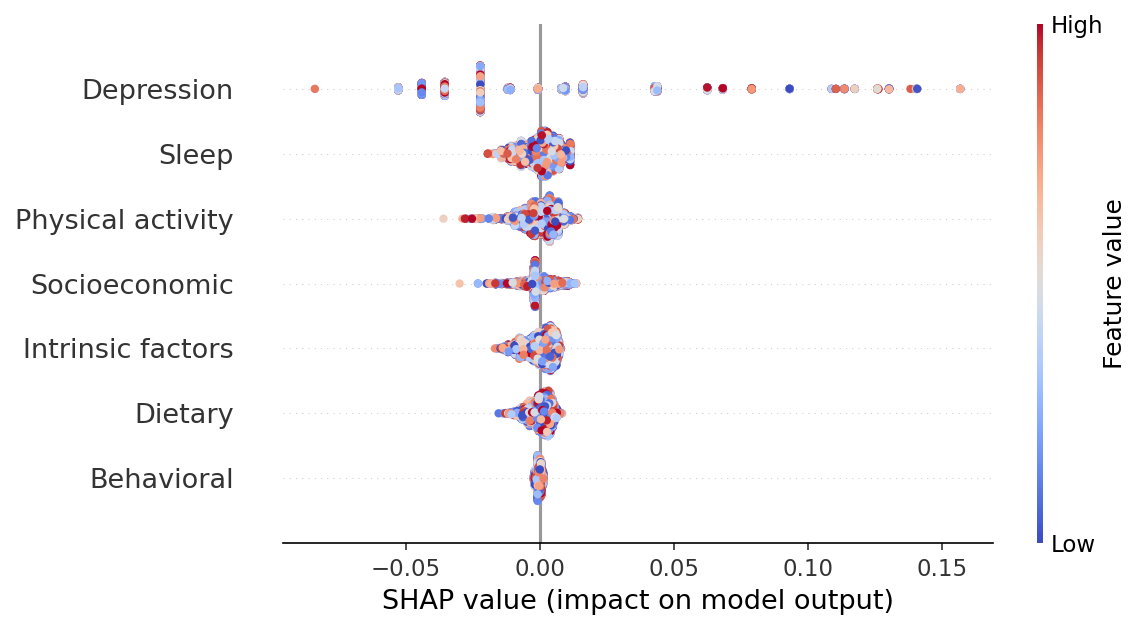

In [ ]:
# @title Beeswarm plot for domains (Original)


import shap
import numpy as np
import matplotlib.pyplot as plt

# Initialize dictionary to store aggregated SHAP values per domain
aggregated_shap_values_by_domain = {}
domain_importances = {}

# Iterate through each domain to train model and get SHAP values
for domain, X_train_domain in X_domain.items():
    # Fit the classifier for each domain
    pipeline_selector_SHAP.named_steps['feature_selector'].fit(X_train_domain, y)

    # Explain the model's predictions using SHAP for each domain
    explainer = shap.Explainer(pipeline_selector_SHAP.named_steps['feature_selector'], X_train_domain)
    shap_values = explainer(X_train_domain)

    # Aggregate SHAP values over the second axis (features) for each domain
    aggregated_shap_values = np.mean(shap_values.values[:, :, 1], axis=1)  # For class 1 SHAP values

    # Store the aggregated SHAP values in the dictionary
    aggregated_shap_values_by_domain[domain] = aggregated_shap_values

    # Calculate the mean absolute SHAP value per domain for sorting
    domain_importances[domain] = np.mean(np.abs(shap_values.values[:, :, 1]))

# Sort domains by their mean absolute SHAP values (as in the original code)
sorted_domains = [domain for domain, _ in sorted(domain_importances.items(), key=lambda item: item[1], reverse=True)]

# Prepare the data for plotting
sorted_shap_values = []
sorted_domain_names = []

# Process domains for plotting
for domain in sorted_domains:
    # Access SHAP values stored in the dictionary
    domain_shap_values = aggregated_shap_values_by_domain[domain]

    sorted_shap_values.append(domain_shap_values)

    # Rename Sociodemographic to Demographic if needed
    if domain == 'Sociodemographic':
        sorted_domain_names.append('Demographic')
    else:
        sorted_domain_names.append(domain)

# Convert to numpy arrays for plotting
sorted_shap_values = np.vstack(sorted_shap_values).T

# Generate dummy feature values for coloring
dummy_feature_values = np.random.rand(sorted_shap_values.shape[0], len(sorted_domains))

# Increase the figure resolution by setting DPI and figure size
plt.figure(figsize=(10, 8), dpi=150)

# Create the beeswarm plot for domains with direction of association
shap.summary_plot(
    sorted_shap_values,
    features=dummy_feature_values,  # Use dummy feature values for coloring
    feature_names=sorted_domain_names,  # Use sorted domain names
    plot_type='dot',
    color_bar=True,
    cmap="coolwarm"
)

SHAP values shape: (5193, 7)
Dummy feature values shape: (5193, 7)
Number of domain names: 7


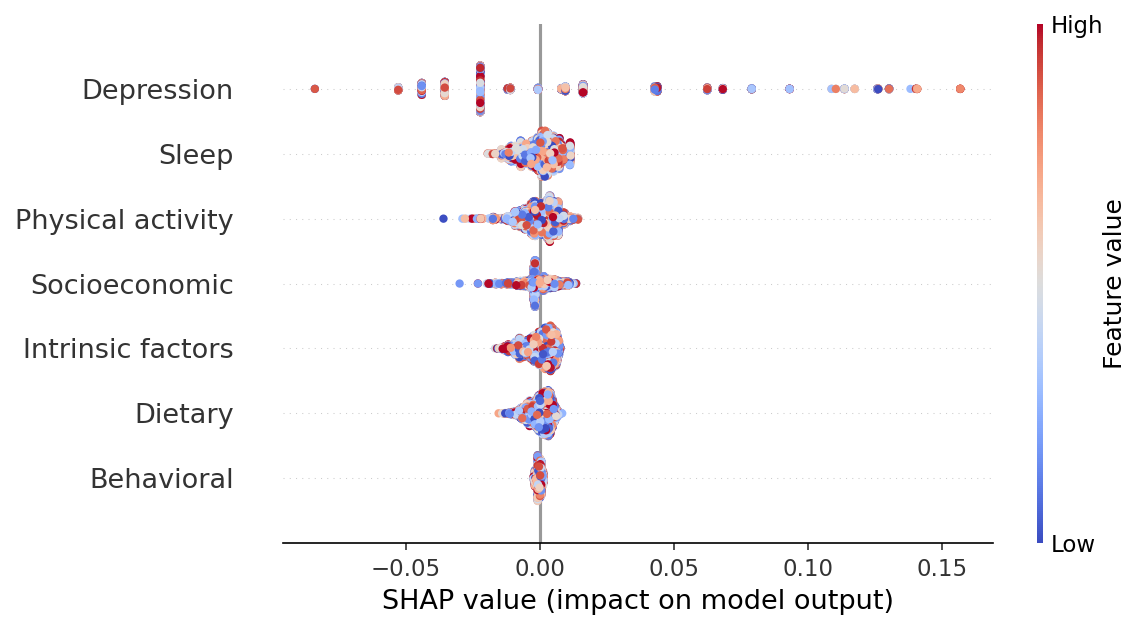

In [ ]:
# @title The plotting section of the above code!


# Prepare the data for plotting
sorted_shap_values = []
sorted_domain_names = []

# Process domains for plotting
for domain in sorted_domains:
    sorted_shap_values.append(aggregated_shap_values_by_domain[domain])

    # Append domain names and rename Sociodemographic to Demographic
    if domain == 'Sociodemographic':
        sorted_domain_names.append('Demographic')
    else:
        sorted_domain_names.append(domain)

# Convert to numpy arrays for plotting
sorted_shap_values = np.vstack(sorted_shap_values).T  # Stack and transpose for SHAP plot format

# Ensure correct number of columns for feature values (for coloring)
dummy_feature_values = np.random.rand(sorted_shap_values.shape[0], sorted_shap_values.shape[1])

# Check the shape of SHAP values and dummy feature values
print(f"SHAP values shape: {sorted_shap_values.shape}")
print(f"Dummy feature values shape: {dummy_feature_values.shape}")
print(f"Number of domain names: {len(sorted_domain_names)}")

# Check if the number of domain names matches the SHAP values' shape[1]
if len(sorted_domain_names) != sorted_shap_values.shape[1]:
    raise ValueError(f"Number of domain names ({len(sorted_domain_names)}) does not match the number of SHAP value columns ({sorted_shap_values.shape[1]}).")

# Increase the figure resolution by setting DPI and figure size
plt.figure(figsize=(10, 8), dpi=150)  # Modestly increasing the size and resolution

# Create the beeswarm plot for domains with direction of association
shap.summary_plot(
    sorted_shap_values,
    features=dummy_feature_values,  # Use dummy feature values for coloring
    feature_names=sorted_domain_names,  # Use sorted domain names
    plot_type='dot',
    color_bar=True,  # Include the color bar for interpretation
    cmap="coolwarm"  # Colormap to visualize direction and importance
)

In [ ]:
# @title Domain interactions (Batch method)

# The entire dataset is divided into batches (i.e., smaller chunks of data) to avoid crashes due to memory constraints
# The interaction between pairs of domains (i,j) is calculated; then, the sum of interactions between feature pairs across the domains is reported


!pip install shap
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import shap
from math import ceil

# Parameters for batch processing
batch_size = 500  # Set a reasonable batch size based on memory capacity

# Extract unique domain names
domain_names = set(feature_to_domain.values())

# Create a dictionary to store features within each domain
domain_features = {domain: [] for domain in domain_names}
for feature, domain in feature_to_domain.items():
    domain_features[domain].append(feature)

# Create the pipeline with the preprocessing step
selector_SHAP = RandomForestClassifier(random_state=42, max_depth=61, max_features=24, min_samples_split=81)
pipeline_selector_SHAP = Pipeline([
    ('preprocessing', preprocessing),
    ('feature_selector', selector_SHAP)
])

# Fit the pipeline to the training data
pipeline_selector_SHAP.fit(df_obesity, df_obesity_labels_2)

# Transform the original DataFrame using the preprocessing pipeline
transformed_df = pipeline_selector_SHAP.named_steps['preprocessing'].transform(df_obesity)

# Retrieve the transformed column names
transformed_column_names = pipeline_selector_SHAP.named_steps['preprocessing'].get_feature_names_out()

# Initialize dictionary to store features by domain
X_domain = {}

# Iterate through domain features and get corresponding columns
for domain, features in domain_features.items():
    domain_cols_mask = np.isin(transformed_column_names, features)
    X_domain[domain] = transformed_df[:, domain_cols_mask]

# Generate the target variable (binary classification)
y = df_obesity_labels_2

# Initialize dictionary to store SHAP interaction values for domains
domain_interactions = {}

# Define function to process each batch
def process_batch(batch_indices, X_train_i, X_train_j, pipeline_selector_SHAP):
    # Extract the batch data
    X_batch_i = X_train_i[batch_indices, :]
    X_batch_j = X_train_j[batch_indices, :]

    # Fit the classifier on the first domain's batch data
    pipeline_selector_SHAP.named_steps['feature_selector'].fit(X_batch_i, y[batch_indices])

    # Explain the model's predictions using SHAP interaction values
    explainer_i = shap.Explainer(pipeline_selector_SHAP.named_steps['feature_selector'], X_batch_i)
    interaction_values_i = explainer_i.shap_interaction_values(X_batch_i)

    # Fit the classifier on the second domain's batch data
    pipeline_selector_SHAP.named_steps['feature_selector'].fit(X_batch_j, y[batch_indices])

    # Explain the model's predictions for the second domain
    explainer_j = shap.Explainer(pipeline_selector_SHAP.named_steps['feature_selector'], X_batch_j)
    interaction_values_j = explainer_j.shap_interaction_values(X_batch_j)

    # Ensure the interaction matrices can be broadcasted
    num_features_i = interaction_values_i.shape[1]
    num_features_j = interaction_values_j.shape[1]

    # Initialize an accumulator for the interaction sum
    interaction_sum_batch = 0

    # Iterate over feature pairs (cross-domain)
    for feature_i in range(num_features_i):  # Features in domain_i
        for feature_j in range(min(num_features_j, num_features_i)):  # Limit to avoid index errors
            # Accumulate the interaction values between feature i and feature j
            interaction_sum_batch += np.abs(interaction_values_i[:, feature_i, feature_j]).sum()

    return interaction_sum_batch

# Iterate through domain pairs to compute SHAP interaction values in batches
domain_names_list = list(domain_names)

for i, domain_i in enumerate(domain_names_list):
    for j, domain_j in enumerate(domain_names_list[i:], start=i):  # Include self-interaction

        # Retrieve the number of features in each domain
        X_domain_i = X_domain[domain_i]
        X_domain_j = X_domain[domain_j]

        # Initialize interaction sum for this domain pair
        interaction_sum_total = 0

        # Determine the number of batches
        n_samples = X_domain_i.shape[0]  # Use the sample size from domain_i (same for domain_j)
        n_batches = ceil(n_samples / batch_size)

        # Process each batch and accumulate interaction values
        for batch_idx in range(n_batches):
            # Define batch start and end indices
            batch_start = batch_idx * batch_size
            batch_end = min((batch_idx + 1) * batch_size, n_samples)

            # Get interaction values for the batch
            interaction_sum_batch = process_batch(np.arange(batch_start, batch_end), X_domain_i, X_domain_j, pipeline_selector_SHAP)

            # Accumulate the interaction values
            interaction_sum_total += interaction_sum_batch

            # Clear memory after each batch
            del interaction_sum_batch

        # Store the total interaction sum between domain_i and domain_j
        domain_interactions[(domain_i, domain_j)] = interaction_sum_total

        # Clear memory after each domain pair computation
        del X_domain_i, X_domain_j

# Sort domain interactions by interaction sum
sorted_domain_interactions = sorted(domain_interactions.items(), key=lambda x: x[1], reverse=True)

# Display the most important domain interactions
print("\nTop 10 Domain Interactions:")
for (domain_i, domain_j), interaction_value in sorted_domain_interactions[:10]:
    print(f"Interaction between {domain_i} and {domain_j}: {interaction_value:.4f}")







Top 10 Domain Interactions:
Interaction between Physical activity and Physical activity: 0.0000
Interaction between Physical activity and Intrinsic factors: 0.0000
Interaction between Physical activity and Dietary: 0.0000
Interaction between Physical activity and Psychologic: 0.0000
Interaction between Physical activity and Socioeconomic: 0.0000
Interaction between Physical activity and Sleep: 0.0000
Interaction between Physical activity and Behavioral: 0.0000
Interaction between Intrinsic factors and Intrinsic factors: 0.0000
Interaction between Intrinsic factors and Dietary: 0.0000
Interaction between Intrinsic factors and Psychologic: 0.0000


In [ ]:
# @title Visualization of domain importances (With HEI components)

# # Extract domain names and importances
# domain_names = list(sorted_domain_importances.keys())
# importances = list(sorted_domain_importances.values())

# # Create a horizontal bar plot
# plt.figure(figsize=(10, 6))
# plt.barh(domain_names, importances, color='skyblue')
# plt.xlabel('Importance')
# plt.ylabel('Domain')
# plt.title('Domain Importances')
# plt.gca().invert_yaxis()  # Invert y-axis for readability

# # Show the plot
# plt.show()

In [ ]:
# @title Visualization of domain importances (With HEI components) (More beautiful)

import matplotlib.pyplot as plt
import numpy as np

domain_names = list(sorted_domain_importances.keys())
importances = list(sorted_domain_importances.values())

# Generate colors
colors = plt.cm.viridis(np.linspace(0, 1, len(domain_names)))

# Create a horizontal bar plot
plt.figure(figsize=(10, 6))
bars = plt.barh(domain_names, importances, color=colors)
plt.xlabel('Importance')
plt.ylabel('Domain')
plt.title('Domain Importances')
plt.gca().invert_yaxis()  # Invert y-axis for readability

# Add text annotations for the importances
for bar, value in zip(bars, importances):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{value:.3f}', va='center', ha='left', fontsize=8)

# Show the plot
plt.show()

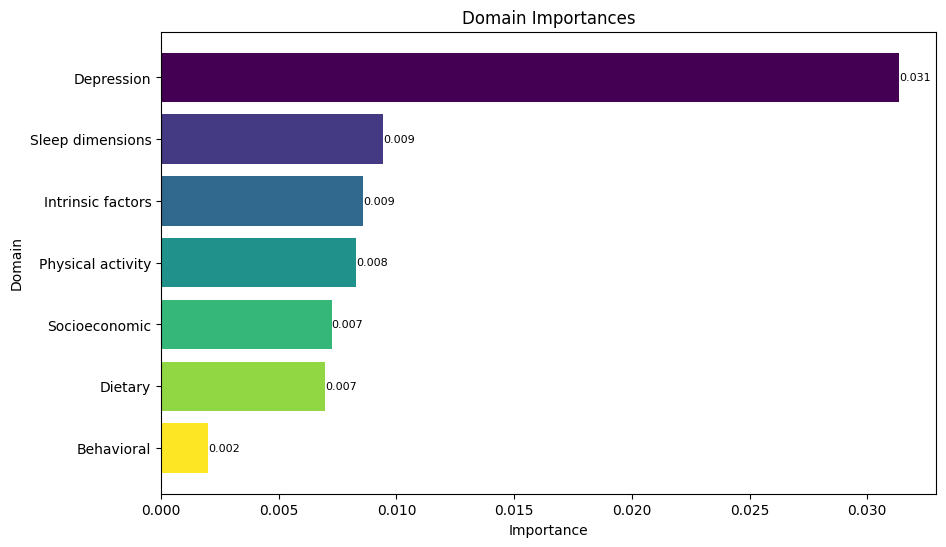

In [ ]:
# @title Visualization of domain importances (With HEI components) (More beautiful + Renamed)

# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np

# Define the mapping of old domain names to new domain names
domain_rename_dict = {
    # 'Sociodemographic': 'Demographic',
    'Sleep': 'Sleep dimensions'
}

# Get domain names and importances
domain_names = list(sorted_domain_importances.keys())
importances = list(sorted_domain_importances.values())

# Rename the domains using the domain_rename_dict
renamed_domain_names = [domain_rename_dict.get(domain, domain) for domain in domain_names]

# Generate colors
colors = plt.cm.viridis(np.linspace(0, 1, len(renamed_domain_names)))

# Create a horizontal bar plot
plt.figure(figsize=(10, 6))
bars = plt.barh(renamed_domain_names, importances, color=colors)
plt.xlabel('Importance')
plt.ylabel('Domain')
plt.title('Domain Importances')
plt.gca().invert_yaxis()  # Invert y-axis for readability

# Add text annotations for the importances
for bar, value in zip(bars, importances):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{value:.3f}', va='center', ha='left', fontsize=8)

# Show the plot
plt.show()



In [ ]:
# @title Domain importances (Decision tree) (for visualization purposes)


# from sklearn.tree import DecisionTreeClassifier
# from sklearn.base import BaseEstimator, TransformerMixin
# from sklearn import tree
# from IPython.display import display, Image
# import graphviz



# # Extract unique domain names
# domain_names_DT = set(feature_to_domain.values())

# # Create a dictionary to store features within each domain
# domain_features_DT = {domain: [] for domain in domain_names_DT}
# for feature, domain in feature_to_domain.items():
#     domain_features_DT[domain].append(feature)


# class DomainAggregator(BaseEstimator, TransformerMixin):
#     def __init__(self, domain_features):
#         self.domain_features = domain_features

#     def fit(self, X, y=None):
#         return self

#     def transform(self, X):
#         X_aggregated = pd.DataFrame()
#         for domain, features in self.domain_features.items():
#             X_aggregated[domain] = X[:, np.isin(transformed_column_names_DT, features)].mean(axis=1)
#         return X_aggregated




# domain_classifier_pipeline= Pipeline([
#     ('preprocessing', preprocessing),
#     ('aggregator', DomainAggregator(domain_features_DT)),
#     ('domain_classifier', DecisionTreeClassifier(random_state=42, max_depth=11, max_features=73, min_samples_split=69))
# ])


# domain_classifier_pipeline.fit(df_obesity, df_obesity_labels_2)

# # Visualize the decision tree
# transformed_df_DT = domain_classifier_pipeline.named_steps['preprocessing'].transform(df_obesity)
# transformed_column_names_DT = domain_classifier_pipeline.named_steps['preprocessing'].get_feature_names_out()
# X_domain_DT = {}

# for domain, features in domain_features_DT.items():
#     domain_cols_mask_DT = np.isin(transformed_column_names_DT, features)
#     X_domain_DT[domain] = transformed_df_DT[:, domain_cols_mask_DT]

# # Visualize the decision tree
# dot_data = tree.export_graphviz(domain_classifier_pipeline.named_steps['domain_classifier'], out_file=None,
#                                 feature_names=list(domain_features_DT.keys()),
#                                 class_names=['0', '1'],
#                                 filled=True, rounded=True,
#                                 special_characters=True)
# graph = graphviz.Source(dot_data)
# graph.render("domain_classifier_DT", format='png')

# # Display the image inline
# display(Image(filename="domain_classifier_DT.png"))



In [ ]:
# @title Bayesian post-hoc model


# from cmdstanpy import CmdStanModel
# import numpy as np

# # Define your Stan model and write to a file
# stan_model_code = """
# data {
#     int<lower=0> N;  // number of samples
#     int<lower=0> K;  // number of predictors
#     matrix[N, K] X;  // predictor matrix
#     array[N] int<lower=0, upper=1> y;  // binary outcome
# }

# parameters {
#     vector[K] beta;  // coefficients
#     real alpha;      // intercept
# }

# model {
#     // Priors
#     beta ~ normal(0, 5);
#     alpha ~ normal(0, 5);

#     // Likelihood
#     y ~ bernoulli_logit(X * beta + alpha);
# }

# generated quantities {
#     vector[N] log_likelihood;

#     for (n in 1:N) {
#         log_likelihood[n] = bernoulli_logit_lpmf(y[n] | X[n] * beta + alpha);
#     }
# }
# """

# # Write to a file
# with open('logistic_regression.stan', 'w') as f:
#     f.write(stan_model_code)

# # Compile the model
# stan_model = CmdStanModel(stan_file='logistic_regression.stan')

# def bayesian_model_comparison(X, y, model_name):
#     # Prepare data for Stan
#     stan_data = {
#         'N': X.shape[0],
#         'K': X.shape[1],
#         'X': X,
#         'y': y
#     }

#     # Fit the model with modified settings
#     # Fit the model with 4 chains
#     fit = stan_model.sample(data=stan_data, iter_sampling=500, chains=4, parallel_chains=4, max_treedepth=15)


#     # Diagnose the model
#     print(fit.diagnose())

#     # Extract log-likelihood
#     log_likelihood = fit.stan_variable('log_likelihood')
#     log_marginal_likelihood = log_likelihood.sum()

#     return model_name, log_marginal_likelihood

# # Define your X and y data for indirect, direct, and complete models
# X_indirect = np.concatenate([X_domain['Psychologic'], X_domain['Sleep'], X_domain['Socioeconomic']], axis=1)
# X_direct = np.concatenate([X_domain['Physical activity'], X_domain['Dietary'], X_domain['Behavioral']], axis=1)
# X_complete = np.concatenate([X_indirect, X_direct], axis=1)

# # Model comparisons
# model_results = []
# model_results.append(bayesian_model_comparison(X_indirect, y, 'Indirect Domains Model'))
# model_results.append(bayesian_model_comparison(X_direct, y, 'Direct Domains Model'))
# model_results.append(bayesian_model_comparison(X_complete, y, 'Complete Control Model'))

# # Output results
# for model_name, log_marginal_likelihood in model_results:
#     print(f"{model_name}: Log Marginal Likelihood = {log_marginal_likelihood}")


# # Compute Bayes Factors
# log_marginal_indirect = model_results[0][1]
# log_marginal_direct = model_results[1][1]
# log_marginal_complete = model_results[2][1]

# # Bayes Factor between Indirect and Complete
# bayes_factor_indirect_complete = np.exp(log_marginal_indirect - log_marginal_complete)
# print(f"Bayes Factor (Indirect vs Complete): {bayes_factor_indirect_complete}")

# # Bayes Factor between Direct and Complete
# bayes_factor_direct_complete = np.exp(log_marginal_direct - log_marginal_complete)
# print(f"Bayes Factor (Direct vs Complete): {bayes_factor_direct_complete}")


In [ ]:
# @title Compute Bayes Factors (NOT USEFUL)
# log_marginal_indirect = model_results[0][1]
# log_marginal_direct = model_results[1][1]
# log_marginal_complete = model_results[2][1]

# # Bayes Factor between Indirect and Complete
# bayes_factor_indirect_complete = np.exp(log_marginal_indirect - log_marginal_complete)
# print(f"Bayes Factor (Indirect vs Complete): {bayes_factor_indirect_complete}")

# # Bayes Factor between Direct and Complete
# bayes_factor_direct_complete = np.exp(log_marginal_direct - log_marginal_complete)
# print(f"Bayes Factor (Direct vs Complete): {bayes_factor_direct_complete}")

# # Bayes Factor between Indirect and Direct
# bayes_factor_indirect_direct = np.exp(log_marginal_indirect - log_marginal_direct)
# print(f"Bayes Factor (Indirect vs Direct): {bayes_factor_indirect_direct}")

# bayes_factor_direct_indirect = np.exp(log_marginal_direct - log_marginal_indirect)
# print(f"Bayes Factor (Direct vs indirect): {bayes_factor_indirect_direct}")


In [ ]:
# @title PDP/ICE Plots and domain-wise comparisons (CRASHED)

# from sklearn.inspection import partial_dependence
# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.pipeline import Pipeline
# from sklearn.ensemble import RandomForestClassifier

# # Function to calculate and plot PDP for a domain collectively with memory optimization
# def plot_pdp_for_domain(model, X_train_domain, domain, grid_resolution=10, max_features=10):
#     """ Generate and plot PDP for each domain collectively with memory optimization """

#     # Get the list of feature indices for this domain (0 to n_features_in_domain - 1)
#     domain_feature_indices = list(range(X_train_domain.shape[1]))

#     # Limit the number of features to a maximum if needed (for memory efficiency)
#     domain_feature_indices = domain_feature_indices[:max_features]

#     # Calculate partial dependence for selected features in the domain collectively
#     try:
#         pd_results = partial_dependence(model, X_train_domain, features=domain_feature_indices,
#                                         kind='average', grid_resolution=grid_resolution)

#         # Accessing the averaged values and the grid points from the Bunch object correctly
#         pd_values = pd_results.average
#         grid_values = pd_results.values

#         # Plot PDP for the domain collectively
#         fig, ax = plt.subplots(figsize=(10, 6))
#         for pd, values in zip(pd_values, grid_values):
#             ax.plot(values, pd, label=f"Domain: {domain}")

#         ax.set_xlabel("Feature values")
#         ax.set_ylabel("Partial Dependence")
#         ax.set_title(f"Partial Dependence Plot - {domain} (collective)")
#         plt.legend()
#         plt.show()
#     except ValueError as e:
#         print(f"Error plotting PDP for domain '{domain}': {e}")

# # Extract unique domain names
# domain_names = set(feature_to_domain.values())

# # Create a dictionary to store features within each domain
# domain_features = {domain: [] for domain in domain_names}
# for feature, domain in feature_to_domain.items():
#     domain_features[domain].append(feature)

# # Initialize the RandomForestClassifier and pipeline
# selector_SHAP = RandomForestClassifier(random_state=42, max_depth=61, max_features=24, min_samples_split=81)
# pipeline_selector_SHAP = Pipeline([
#     ('preprocessing', preprocessing),
#     ('feature_selector', selector_SHAP)
# ])

# # Fit the pipeline to the training data
# pipeline_selector_SHAP.fit(df_obesity, df_obesity_labels_2)

# # Transform the original DataFrame using the preprocessing pipeline
# transformed_df = pipeline_selector_SHAP.named_steps['preprocessing'].transform(df_obesity)

# # Retrieve the transformed column names
# transformed_column_names = pipeline_selector_SHAP.named_steps['preprocessing'].get_feature_names_out()

# # Initialize dictionary to store features by domain
# X_domain = {}

# # Iterate through domain features to subset the transformed data based on domain features
# for domain, features in domain_features.items():
#     # Select columns based on transformed column names
#     domain_cols_mask = np.isin(transformed_column_names, features)
#     # Retrieve the corresponding columns from the transformed DataFrame
#     X_domain[domain] = transformed_df[:, domain_cols_mask]

# # Generate synthetic target variable (binary classification)
# y = df_obesity_labels_2

# # Train a random forest classifier for each domain and plot PDP
# for domain, X_train_domain in X_domain.items():
#     # Fit the classifier
#     domain_model = pipeline_selector_SHAP.named_steps['feature_selector']
#     domain_model.fit(X_train_domain, y)

#     # Plot PDP for this domain collectively with optimized memory settings
#     plot_pdp_for_domain(domain_model, X_train_domain, domain, grid_resolution=5, max_features=5)


In [ ]:
# @title Permutation Importance Model (Wrong!)

# # Install necessary packages
# !pip install scikit-learn shap

# import numpy as np
# import pandas as pd
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
# from sklearn.model_selection import cross_val_predict, StratifiedKFold
# from sklearn.pipeline import Pipeline


# pipeline_selector_SHAP = Pipeline([
#     ('preprocessing', preprocessing),
#     ('feature_selector', RandomForestClassifier(random_state=42, max_depth=61, max_features=24, min_samples_split=81))
# ])

# # Fit the pipeline on the entire dataset (df_obesity)
# pipeline_selector_SHAP.fit(df_obesity, df_obesity_labels_2)

# # Define a function to calculate metrics using cross-validation directly on the DataFrame
# def cross_val_metrics(model, X, y):
#     cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
#     y_pred = cross_val_predict(model, X, y, cv=cv, method="predict")
#     y_pred_proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]

#     metrics = {
#         'accuracy': accuracy_score(y, y_pred),
#         'precision': precision_score(y, y_pred),
#         'recall': recall_score(y, y_pred),
#         'f1': f1_score(y, y_pred),
#         'roc_auc': roc_auc_score(y, y_pred_proba)
#     }
#     return metrics

# # Calculate baseline metrics using cross-validation
# baseline_metrics = cross_val_metrics(pipeline_selector_SHAP, df_obesity, df_obesity_labels_2)

# print("\nBaseline Metrics (Mean across 10 folds):")
# for metric, value in baseline_metrics.items():
#     print(f"{metric.capitalize()}: {value:.4f}")

# # Permutation Importance Function with cross-validation
# def permutation_importance_domain_cv(pipeline, X_train, y_train, domain_features, transformed_column_names, baseline_metrics):
#     """
#     Calculate the permutation importance of each domain by shuffling domain features
#     and measuring the drop in performance (cross-validated metrics).

#     Args:
#     pipeline : trained pipeline model
#     X_train : Training set features (DataFrame)
#     y_train : Training set labels
#     domain_features : Dictionary of domain names to list of features
#     transformed_column_names : List of transformed feature names after preprocessing
#     baseline_metrics : Dictionary of baseline metrics to compare against

#     Returns:
#     domain_permutation_importance : Dictionary of domain names to drop in metrics
#     """
#     # Store the drop in metrics for each domain
#     domain_permutation_importance = {}

#     for domain, features in domain_features.items():
#         # Get the indices of features for this domain
#         domain_cols_mask = X_train.columns.isin(features)

#         # Make a copy of X_train
#         X_train_permuted = X_train.copy()

#         # Shuffle the values of the domain features
#         X_train_permuted.loc[:, domain_cols_mask] = np.random.permutation(X_train.loc[:, domain_cols_mask])

#         # Calculate metrics after shuffling with cross-validation
#         permuted_metrics = cross_val_metrics(pipeline, X_train_permuted, y_train)

#         # Calculate the drop in each metric
#         metric_drops = {metric: baseline_metrics[metric] - permuted_metrics[metric] for metric in baseline_metrics}
#         domain_permutation_importance[domain] = metric_drops

#     return domain_permutation_importance

# # Perform permutation importance analysis
# domain_importance_scores = permutation_importance_domain_cv(
#     pipeline_selector_SHAP,
#     df_obesity,
#     df_obesity_labels_2,
#     domain_features,
#     transformed_column_names,
#     baseline_metrics
# )

# # Display the results
# print("\nPermutation Importance (Drop in Metrics) per Domain:")
# for domain, metric_drops in domain_importance_scores.items():
#     print(f"\n{domain}:")
#     for metric, drop in metric_drops.items():
#         print(f"  {metric.capitalize()} drop: {drop:.4f}")

In [ ]:
# @title Bootstrapping Domain Importances (Sampled) (Crashed!)


# Install necessary packages
# !pip install shap scikit-learn numpy

# # Import required libraries
# import numpy as np
# import shap
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.pipeline import Pipeline
# from sklearn.utils import resample
# import gc

# # Extract unique domain names
# domain_names = set(feature_to_domain.values())

# # Create a dictionary to store features within each domain
# domain_features = {domain: [] for domain in domain_names}
# for feature, domain in feature_to_domain.items():
#     domain_features[domain].append(feature)

# # Create the pipeline with the preprocessing step
# selector_SHAP = RandomForestClassifier(random_state=42, max_depth=61, max_features=24, min_samples_split=81)
# pipeline_selector_SHAP = Pipeline([
#     ('preprocessing', preprocessing),
#     ('feature_selector', selector_SHAP)
# ])
# # Fit the pipeline on the entire dataset
# pipeline_selector_SHAP.fit(df_obesity, df_obesity_labels_2)

# # Transform the entire dataset using the preprocessing step
# transformed_sample = pipeline_selector_SHAP.named_steps['preprocessing'].transform(df_obesity)

# # Check the shape of transformed_sample
# print(f"Shape of transformed_sample: {transformed_sample.shape}")

# # Update transformed_column_names to reflect the transformed data
# transformed_column_names = pipeline_selector_SHAP.named_steps['preprocessing'].get_feature_names_out()

# # Dictionary to store bootstrap domain importances
# bootstrap_importances = {domain: [] for domain in domain_features}

# # Initialize TreeExplainer (optimized for tree-based models)
# explainer = shap.TreeExplainer(pipeline_selector_SHAP.named_steps['feature_selector'])

# # Bootstrap iterations (reduced number)
# n_iterations = 10  # Start with fewer iterations

# # Loop through bootstrap iterations
# for i in range(n_iterations):
#     # Resample the data with a smaller sample size
#     X_bootstrap, y_bootstrap = resample(transformed_sample, df_obesity_labels_2, n_samples=500, random_state=i)

#     # Iterate through domains and calculate SHAP values
#     for domain, features in domain_features.items():
#         domain_cols_mask = np.isin(transformed_column_names, features)

#         # Skip if no features selected for the domain
#         if domain_cols_mask.sum() == 0:
#             continue

#         X_domain_bootstrap = X_bootstrap[:, domain_cols_mask]

#         # Fit the model for this domain
#         pipeline_selector_SHAP.named_steps['feature_selector'].fit(X_domain_bootstrap, y_bootstrap)

#         # Calculate SHAP values efficiently using TreeExplainer
#         try:
#             shap_values = explainer.shap_values(X_domain_bootstrap)
#         except Exception as e:
#             print(f"Error calculating SHAP values for domain '{domain}': {e}")
#             continue

#         # Calculate mean absolute SHAP value and store it
#         mean_shap_value = np.mean(np.abs(shap_values))
#         bootstrap_importances[domain].append(mean_shap_value)

#         # Free up memory
#         del X_domain_bootstrap, shap_values
#         gc.collect()

# # Calculate confidence intervals for each domain
# confidence_level = 0.95
# confidence_intervals = {}
# for domain, importances in bootstrap_importances.items():
#     lower_bound = np.percentile(importances, (1 - confidence_level) / 2 * 100)
#     upper_bound = np.percentile(importances, (1 + confidence_level) / 2 * 100)
#     confidence_intervals[domain] = (lower_bound, upper_bound)

# # Display results
# print("\nBootstrap Domain Importances (Confidence Intervals):")
# for domain, (lower, upper) in confidence_intervals.items():
#     print(f"{domain}: {lower:.4f} - {upper:.4f}")

# # Check if confidence intervals exclude zero
# significant_domains = [domain for domain, (lower, upper) in confidence_intervals.items() if lower > 0]
# print("\nSignificant Domains:")
# for domain in significant_domains:
#     print(domain)


In [ ]:
# @title Dataset + Domains without redundant HEI components


# df_obesity_comp_rem = df_obesity.drop(columns =['DR1T_A_DRINKS', 'Total Fruits', 'Whole Fruits', 'Total Vegetables', 'Greens and Beans',
#                                     'Whole Grains', 'Dairy', 'Total Protein Foods', 'Seafood and Plant Proteins', 'Fatty Acids Ratio (PUFAs + MUFAs)/SFAs',
#                                     'Refined Grains', 'Sodium', 'Added Sugars', 'Saturated Fats', 'Sugar_intake_mean',
#                                     'Fiber_intake_mean', 'SAFA_intake_mean', 'MUFA_intake_mean', 'PUFA_intake_mean', 'Cholesterol_intake_mean'])

# feature_to_domain_comp_rem = {
# 'pipeline-1__RIDAGEYR': 'Sociodemographic',
# 'pipeline-1__INDFMPIR': 'Socioeconomic',
# 'pipeline-1__INDFMMPI': 'Socioeconomic',
# 'pipeline-1__PAD680': 'Physical activity',
# 'pipeline-1__SLD012': 'Sleep',
# 'pipeline-1__SLD013': 'Sleep',
# 'pipeline-1__Depression_total' : 'Psychologic',
# 'pipeline-1__HEI-2020': 'Dietary' ,
# 'pipeline-1__Calorie_intake_mean':'Dietary' ,
# 'pipeline-1__Protein_intake_mean': 'Dietary' ,
# 'pipeline-1__Carb_intake_mean': 'Dietary' ,
# 'pipeline-1__Fat_intake_mean': 'Dietary' ,
# 'pipeline-2__RIAGENDR_1.0': 'Sociodemographic',
# 'pipeline-2__RIAGENDR_2.0': 'Sociodemographic',
# 'pipeline-2__RIDRETH3_1.0': 'Sociodemographic',
# 'pipeline-2__RIDRETH3_2.0': 'Sociodemographic',
# 'pipeline-2__RIDRETH3_3.0': 'Sociodemographic',
# 'pipeline-2__RIDRETH3_4.0': 'Sociodemographic',
# 'pipeline-2__RIDRETH3_6.0': 'Sociodemographic',
# 'pipeline-2__RIDRETH3_7.0': 'Sociodemographic',
# 'pipeline-2__DMDBORN4_1.0': 'Sociodemographic',
# 'pipeline-2__DMDBORN4_2.0': 'Sociodemographic',
# 'pipeline-2__DMDBORN4_77.0': 'Sociodemographic',
# 'pipeline-2__DMDBORN4_99.0': 'Sociodemographic',
# 'pipeline-2__DMDEDUC2_1.0': 'Sociodemographic',
# 'pipeline-2__DMDEDUC2_2.0': 'Sociodemographic',
# 'pipeline-2__DMDEDUC2_3.0': 'Sociodemographic',
# 'pipeline-2__DMDEDUC2_4.0': 'Sociodemographic',
# 'pipeline-2__DMDEDUC2_5.0': 'Sociodemographic',
# 'pipeline-2__DMDEDUC2_9.0': 'Sociodemographic',
# 'pipeline-2__DMDMARTZ_1.0': 'Sociodemographic',
# 'pipeline-2__DMDMARTZ_2.0': 'Sociodemographic',
# 'pipeline-2__DMDMARTZ_3.0': 'Sociodemographic',
# 'pipeline-2__DMDMARTZ_77.0': 'Sociodemographic',
# 'pipeline-2__CBQ506_1.0': 'Behavioral',
# 'pipeline-2__CBQ506_2.0': 'Behavioral',
# 'pipeline-2__CBQ536_1.0': 'Behavioral',
# 'pipeline-2__CBQ536_2.0': 'Behavioral',
# 'pipeline-2__CBQ536_9.0': 'Behavioral',
# 'pipeline-2__CBQ551_1.0': 'Behavioral',
# 'pipeline-2__CBQ551_2.0': 'Behavioral',
# 'pipeline-2__CBQ830_1.0': 'Behavioral',
# 'pipeline-2__CBQ830_2.0': 'Behavioral',
# 'pipeline-2__CBQ845_1.0': 'Behavioral',
# 'pipeline-2__CBQ845_2.0': 'Behavioral',
# 'pipeline-2__CBQ860_1.0': 'Behavioral',
# 'pipeline-2__CBQ860_2.0': 'Behavioral',
# 'pipeline-2__CBQ875_1.0': 'Behavioral',
# 'pipeline-2__CBQ875_2.0': 'Behavioral',
# 'pipeline-2__CBQ875_9.0': 'Behavioral',
# 'pipeline-2__CBQ890_1.0': 'Behavioral',
# 'pipeline-2__CBQ890_2.0': 'Behavioral',
# 'pipeline-2__CBQ890_9.0': 'Behavioral',
# 'pipeline-2__CBQ645_1.0': 'Behavioral',
# 'pipeline-2__CBQ645_2.0': 'Behavioral',
# 'pipeline-2__CBQ645_3.0': 'Behavioral',
# 'pipeline-2__CBQ645_4.0': 'Behavioral',
# 'pipeline-2__CBQ645_5.0': 'Behavioral',
# 'pipeline-2__CBQ645_6.0': 'Behavioral',
# 'pipeline-2__CBQ645_7.0': 'Behavioral',
# 'pipeline-2__CBQ645_99.0': 'Behavioral',
# 'pipeline-2__CBQ700_1.0': 'Behavioral',
# 'pipeline-2__CBQ700_2.0': 'Behavioral',
# 'pipeline-2__CBQ700_3.0': 'Behavioral',
# 'pipeline-2__CBQ700_4.0': 'Behavioral',
# 'pipeline-2__CBQ700_5.0': 'Behavioral',
# 'pipeline-2__CBQ700_6.0': 'Behavioral',
# 'pipeline-2__CBQ700_9.0': 'Behavioral',
# 'pipeline-2__DBQ780_1.0': 'Behavioral',
# 'pipeline-2__DBQ780_2.0': 'Behavioral',
# 'pipeline-2__DBQ780_3.0': 'Behavioral',
# 'pipeline-2__DBQ780_4.0': 'Behavioral',
# 'pipeline-2__DBQ780_5.0': 'Behavioral',
# 'pipeline-2__DBQ780_6.0': 'Behavioral',
# 'pipeline-2__DBQ780_9.0': 'Behavioral',
# 'pipeline-2__DBQ750_1.0': 'Behavioral',
# 'pipeline-2__DBQ750_2.0': 'Behavioral',
# 'pipeline-2__DBQ750_3.0': 'Behavioral',
# 'pipeline-2__DBQ750_4.0': 'Behavioral',
# 'pipeline-2__DBQ750_5.0': 'Behavioral',
# 'pipeline-2__DBQ750_9.0': 'Behavioral',
# 'pipeline-2__DBQ760_1.0': 'Behavioral',
# 'pipeline-2__DBQ760_2.0': 'Behavioral',
# 'pipeline-2__DBQ760_3.0': 'Behavioral',
# 'pipeline-2__DBQ760_4.0': 'Behavioral',
# 'pipeline-2__DBQ760_5.0': 'Behavioral',
# 'pipeline-2__DBQ760_9.0': 'Behavioral',
# 'pipeline-2__DBQ770_1.0': 'Behavioral',
# 'pipeline-2__DBQ770_2.0': 'Behavioral',
# 'pipeline-2__DBQ770_3.0': 'Behavioral',
# 'pipeline-2__DBQ770_4.0': 'Behavioral',
# 'pipeline-2__DBQ770_5.0': 'Behavioral',
# 'pipeline-2__DBQ770_6.0': 'Behavioral',
# 'pipeline-2__DBQ770_9.0': 'Behavioral',
# 'pipeline-2__CBQ905_1.0': 'Behavioral',
# 'pipeline-2__CBQ905_2.0': 'Behavioral',
# 'pipeline-2__CBQ905_3.0': 'Behavioral',
# 'pipeline-2__CBQ905_4.0': 'Behavioral',
# 'pipeline-2__CBQ905_5.0': 'Behavioral',
# 'pipeline-2__CBQ905_6.0': 'Behavioral',
# 'pipeline-2__CBQ905_9.0': 'Behavioral',
# 'pipeline-2__CBQ910_1.0': 'Behavioral',
# 'pipeline-2__CBQ910_2.0': 'Behavioral',
# 'pipeline-2__CBQ910_3.0': 'Behavioral',
# 'pipeline-2__CBQ910_4.0': 'Behavioral',
# 'pipeline-2__CBQ910_5.0': 'Behavioral',
# 'pipeline-2__CBQ910_6.0': 'Behavioral',
# 'pipeline-2__CBQ910_9.0': 'Behavioral',
# 'pipeline-2__CBQ685_1.0': 'Behavioral',
# 'pipeline-2__CBQ685_2.0': 'Behavioral',
# 'pipeline-2__CBQ685_3.0': 'Behavioral',
# 'pipeline-2__CBQ685_4.0': 'Behavioral',
# 'pipeline-2__CBQ685_5.0': 'Behavioral',
# 'pipeline-2__CBQ685_6.0': 'Behavioral',
# 'pipeline-2__CBQ685_9.0': 'Behavioral',
# 'pipeline-2__CBQ915_1.0': 'Behavioral',
# 'pipeline-2__CBQ915_2.0': 'Behavioral',
# 'pipeline-2__CBQ915_3.0': 'Behavioral',
# 'pipeline-2__CBQ915_4.0': 'Behavioral',
# 'pipeline-2__CBQ915_5.0': 'Behavioral',
# 'pipeline-2__CBQ915_6.0': 'Behavioral',
# 'pipeline-2__CBQ915_9.0': 'Behavioral',
# 'pipeline-2__CBD925_1.0': 'Behavioral',
# 'pipeline-2__CBD925_2.0': 'Behavioral',
# 'pipeline-2__CBD925_3.0': 'Behavioral',
# 'pipeline-2__CBD925_7.0': 'Behavioral',
# 'pipeline-2__CBD925_9.0': 'Behavioral',
# 'pipeline-2__CBQ930_1.0': 'Behavioral',
# 'pipeline-2__CBQ930_2.0': 'Behavioral',
# 'pipeline-2__CBQ930_3.0': 'Behavioral',
# 'pipeline-2__CBQ930_4.0': 'Behavioral',
# 'pipeline-2__CBQ930_5.0': 'Behavioral',
# 'pipeline-2__CBQ930_6.0': 'Behavioral',
# 'pipeline-2__CBQ930_9.0': 'Behavioral',
# 'pipeline-2__CBQ935_1.0': 'Behavioral',
# 'pipeline-2__CBQ935_2.0': 'Behavioral',
# 'pipeline-2__CBQ935_3.0': 'Behavioral',
# 'pipeline-2__CBQ935_4.0': 'Behavioral',
# 'pipeline-2__CBQ935_5.0': 'Behavioral',
# 'pipeline-2__CBQ935_6.0': 'Behavioral',
# 'pipeline-2__CBQ935_9.0': 'Behavioral',
# 'pipeline-2__CBQ945_1.0': 'Behavioral',
# 'pipeline-2__CBQ945_2.0': 'Behavioral',
# 'pipeline-2__CBQ945_3.0': 'Behavioral',
# 'pipeline-2__CBQ945_4.0': 'Behavioral',
# 'pipeline-2__CBQ945_5.0': 'Behavioral',
# 'pipeline-2__CBQ945_6.0': 'Behavioral',
# 'pipeline-2__CBQ945_9.0': 'Behavioral',
# 'pipeline-2__CBQ950_1.0': 'Behavioral',
# 'pipeline-2__CBQ950_2.0': 'Behavioral',
# 'pipeline-2__CBQ950_3.0': 'Behavioral',
# 'pipeline-2__CBQ950_4.0': 'Behavioral',
# 'pipeline-2__CBQ950_5.0': 'Behavioral',
# 'pipeline-2__CBQ950_6.0': 'Behavioral',
# 'pipeline-2__CBQ950_9.0': 'Behavioral',
# 'pipeline-2__DBQ700_1.0': 'Behavioral',
# 'pipeline-2__DBQ700_2.0': 'Behavioral',
# 'pipeline-2__DBQ700_3.0': 'Behavioral',
# 'pipeline-2__DBQ700_4.0': 'Behavioral',
# 'pipeline-2__DBQ700_5.0': 'Behavioral',
# 'pipeline-2__DBQ700_9.0': 'Behavioral',
# 'pipeline-2__CBQ596_1.0': 'Behavioral',
# 'pipeline-2__CBQ596_2.0': 'Behavioral',
# 'pipeline-2__CBQ596_9.0': 'Behavioral',
# 'pipeline-2__DRQSDIET_1.0': 'Behavioral',
# 'pipeline-2__DRQSDIET_2.0': 'Behavioral',
# 'pipeline-2__DR2STY_1.0': 'Behavioral',
# 'pipeline-2__DR2STY_2.0': 'Behavioral',
# 'pipeline-2__FSDHH_1.0': 'Socioeconomic',
# 'pipeline-2__FSDHH_2.0': 'Socioeconomic',
# 'pipeline-2__FSDHH_3.0': 'Socioeconomic',
# 'pipeline-2__FSDHH_4.0': 'Socioeconomic',
# 'pipeline-2__FSDAD_1.0': 'Socioeconomic',
# 'pipeline-2__FSDAD_2.0': 'Socioeconomic',
# 'pipeline-2__FSDAD_3.0': 'Socioeconomic',
# 'pipeline-2__FSDAD_4.0': 'Socioeconomic',
# 'pipeline-2__INDFMMPC_1.0': 'Socioeconomic',
# 'pipeline-2__INDFMMPC_2.0': 'Socioeconomic',
# 'pipeline-2__INDFMMPC_3.0': 'Socioeconomic',
# 'pipeline-2__INDFMMPC_7.0': 'Socioeconomic',
# 'pipeline-2__INDFMMPC_9.0': 'Socioeconomic',
# 'pipeline-2__MCQ300C_1.0': 'Medical history',
# 'pipeline-2__MCQ300C_2.0': 'Medical history',
# 'pipeline-2__MCQ300C_9.0': 'Medical history',
# 'pipeline-2__MCQ300A_1.0': 'Medical history',
# 'pipeline-2__MCQ300A_2.0': 'Medical history',
# 'pipeline-2__MCQ300A_9.0': 'Medical history',
# 'pipeline-2__PAQ605_1.0': 'Physical activity',
# 'pipeline-2__PAQ605_2.0': 'Physical activity',
# 'pipeline-2__PAQ605_9.0': 'Physical activity',
# 'pipeline-2__PAQ620_1.0': 'Physical activity',
# 'pipeline-2__PAQ620_2.0': 'Physical activity',
# 'pipeline-2__PAQ620_9.0': 'Physical activity',
# 'pipeline-2__PAQ635_1.0': 'Physical activity',
# 'pipeline-2__PAQ635_2.0': 'Physical activity',
# 'pipeline-2__PAQ635_9.0': 'Physical activity',
# 'pipeline-2__PAQ650_1.0': 'Physical activity',
# 'pipeline-2__PAQ650_2.0': 'Physical activity',
# 'pipeline-2__PAQ665_1.0': 'Physical activity',
# 'pipeline-2__PAQ665_2.0': 'Physical activity',
# 'pipeline-2__PAQ665_9.0': 'Physical activity',
# 'pipeline-2__SLQ030_0.0': 'Sleep',
# 'pipeline-2__SLQ030_1.0': 'Sleep',
# 'pipeline-2__SLQ030_2.0': 'Sleep',
# 'pipeline-2__SLQ030_3.0': 'Sleep',
# 'pipeline-2__SLQ030_7.0': 'Sleep',
# 'pipeline-2__SLQ030_9.0': 'Sleep',
# 'pipeline-2__SLQ040_0.0': 'Sleep',
# 'pipeline-2__SLQ040_1.0': 'Sleep',
# 'pipeline-2__SLQ040_2.0': 'Sleep',
# 'pipeline-2__SLQ040_3.0': 'Sleep',
# 'pipeline-2__SLQ040_7.0': 'Sleep',
# 'pipeline-2__SLQ040_9.0': 'Sleep',
# 'pipeline-2__SLQ050_1.0': 'Sleep',
# 'pipeline-2__SLQ050_2.0': 'Sleep',
# 'pipeline-2__SLQ050_9.0': 'Sleep',
# 'pipeline-2__SLQ120_0.0': 'Sleep',
# 'pipeline-2__SLQ120_1.0': 'Sleep',
# 'pipeline-2__SLQ120_2.0': 'Sleep',
# 'pipeline-2__SLQ120_3.0': 'Sleep',
# 'pipeline-2__SLQ120_4.0': 'Sleep',
# 'pipeline-2__SLQ120_9.0': 'Sleep'
# }



In [ ]:
# @title Domain importances (Without HEI components)

# !pip install shap
# from sklearn.ensemble import RandomForestClassifier
# import shap


# # Extract unique domain names
# domain_names_ed = set(feature_to_domain_comp_rem.values())

# # Create a dictionary to store features within each domain
# domain_features_ed = {domain_ed: [] for domain_ed in domain_names_ed}
# for feature_ed, domain_ed in feature_to_domain_comp_rem.items():
#     domain_features_ed[domain_ed].append(feature_ed)

# # Create the pipeline with the preprocessing step
# selector_SHAP_ed = RandomForestClassifier(random_state=42, max_depth=61, max_features=24, min_samples_split=81)
# pipeline_selector_SHAP_ed = Pipeline([
#     ('preprocessing', preprocessing),
#     ('feature_selector', selector_SHAP_ed)
# ])

# # Fit the pipeline to the training data
# pipeline_selector_SHAP_ed.fit(df_obesity_comp_rem, df_obesity_labels_2)

# # Transform the original DataFrame using the preprocessing pipeline
# transformed_df_ed = pipeline_selector_SHAP_ed.named_steps['preprocessing'].transform(df_obesity_comp_rem)

# # Retrieve the transformed column names
# transformed_column_names_ed = pipeline_selector_SHAP_ed.named_steps['preprocessing'].get_feature_names_out()

# # Initialize dictionary to store features by domain
# X_domain_ed = {}

# # Iterate through domain features
# for domain_ed, features_ed in domain_features_ed.items():
#     # Select columns based on transformed column names
#     domain_cols_mask_ed = np.isin(transformed_column_names_ed, features_ed)
#     # Retrieve the corresponding columns from the transformed DataFrame
#     X_domain_ed[domain_ed] = transformed_df_ed[:, domain_cols_mask_ed]



# # Generate synthetic target variable (binary classification)
# y = df_obesity_labels_2

# # Train a random forest classifier for each domain
# # Initialize dictionary to store domain importances
# domain_importances_ed = {}

# # Iterate through domain features
# for domain_ed, X_train_domain_ed in X_domain_ed.items():
#     X_train_domain_ed_dense = X_train_domain_ed.toarray()
#     # Fit the classifier
#     pipeline_selector_SHAP_ed.named_steps['feature_selector'].fit(X_train_domain_ed_dense, y)
#    # Explain the model's predictions using SHAP
#     explainer_ed = shap.Explainer(pipeline_selector_SHAP_ed.named_steps['feature_selector'], X_train_domain_ed_dense)
#     shap_values_ed = explainer_ed(X_train_domain_ed_dense, check_additivity=False)
#    # Calculate the mean absolute SHAP values
#     domain_importances_ed[domain_ed] = np.mean(np.abs(shap_values_ed.values))

# sorted_domain_importances_ed = {k: v for k, v in sorted(domain_importances_ed.items(), key=lambda item: item[1], reverse=True)}

# print("\nDomain Importances (Training Set):")
# for domain_ed, importance_ed in sorted_domain_importances_ed.items():
#     print(f"{domain_ed}: {importance_ed:.4f}")


In [ ]:
# @title Visualization of domain importances (Without HEI components)


# # Extract domain names and importances
# domain_names_ed = list(sorted_domain_importances_ed.keys())
# importances_ed = list(sorted_domain_importances_ed.values())

# # Create a horizontal bar plot
# plt.figure(figsize=(10, 6))
# plt.barh(domain_names_ed, importances_ed, color='skyblue')
# plt.xlabel('Importance')
# plt.ylabel('Domain')
# plt.title('Domain Importances (Without HEI components)')
# plt.gca().invert_yaxis()  # Invert y-axis for readability

# # Show the plot
# plt.show()

# PATH analysis (SEM) (Testing!)

In [ ]:
# @title Retrieving Latent Variables

def get_keys_by_value(my_dict, target_value):
    return ' + '.join(key for key, value in my_dict.items() if value == target_value)


domain_keys = get_keys_by_value(feature_to_domain, 'Sociodemographic')
print("Domain keys keys:", domain_keys)

domain_keys = get_keys_by_value(feature_to_domain, 'Socioeconomic')
print("Domain keys keys:", domain_keys)

domain_keys = get_keys_by_value(feature_to_domain, 'Psychologic')
print("Domain keys keys:", domain_keys)

domain_keys = get_keys_by_value(feature_to_domain, 'Physical activity')
print("Domain keys keys:", domain_keys)

domain_keys = get_keys_by_value(feature_to_domain, 'Sleep')
print("Domain keys keys:", domain_keys)

domain_keys = get_keys_by_value(feature_to_domain, 'Dietary')
print("Domain keys keys:", domain_keys)

domain_keys = get_keys_by_value(feature_to_domain, 'Behavioral')
print("Domain keys keys:", domain_keys)

domain_keys = get_keys_by_value(feature_to_domain, 'Medical history')
print("Domain keys keys:", domain_keys)


Domain keys keys: pipeline-1__RIDAGEYR + pipeline-2__RIAGENDR_1.0 + pipeline-2__RIAGENDR_2.0 + pipeline-2__RIDRETH3_1.0 + pipeline-2__RIDRETH3_2.0 + pipeline-2__RIDRETH3_3.0 + pipeline-2__RIDRETH3_4.0 + pipeline-2__RIDRETH3_6.0 + pipeline-2__RIDRETH3_7.0 + pipeline-2__DMDBORN4_1.0 + pipeline-2__DMDBORN4_2.0 + pipeline-2__DMDBORN4_77.0 + pipeline-2__DMDBORN4_99.0 + pipeline-2__DMDEDUC2_1.0 + pipeline-2__DMDEDUC2_2.0 + pipeline-2__DMDEDUC2_3.0 + pipeline-2__DMDEDUC2_4.0 + pipeline-2__DMDEDUC2_5.0 + pipeline-2__DMDEDUC2_9.0 + pipeline-2__DMDMARTZ_1.0 + pipeline-2__DMDMARTZ_2.0 + pipeline-2__DMDMARTZ_3.0 + pipeline-2__DMDMARTZ_77.0
Domain keys keys: pipeline-1__INDFMPIR + pipeline-1__INDFMMPI + pipeline-2__FSDHH_1.0 + pipeline-2__FSDHH_2.0 + pipeline-2__FSDHH_3.0 + pipeline-2__FSDHH_4.0 + pipeline-2__FSDAD_1.0 + pipeline-2__FSDAD_2.0 + pipeline-2__FSDAD_3.0 + pipeline-2__FSDAD_4.0 + pipeline-2__INDFMMPC_1.0 + pipeline-2__INDFMMPC_2.0 + pipeline-2__INDFMMPC_3.0 + pipeline-2__INDFMMPC_7.0 + 

In [ ]:
# @title Retrieving the preprocessed dataset



preprocessor = preprocessing.fit(df_obesity)


num_cols = preprocessor.transformers_[0][1].get_feature_names_out(df_obesity.select_dtypes(include=[np.number]).columns.tolist())
cat_cols = preprocessor.transformers_[1][1].get_feature_names_out(df_obesity.select_dtypes(include=['category']).columns.tolist())

processed_columns = num_cols.tolist() + cat_cols.tolist()

# Convert the processed data to a DataFrame
processed_df = pd.DataFrame(preprocessor.transform(df_obesity), columns=processed_columns)

# processed_df

new_column_names = {
    'Whole Fruits': 'Whole_Fruits',
    'Total Fruits': 'Total_Fruits',
    'Total Vegetables' : 'Total_Vegetables',
    'Greens and Beans' : 'Greens_and_Beans',
    'Whole Grains' : 'Whole_Grains',
    'Total Protein Foods' : 'Total_Protein_Foods',
    'Seafood and Plant Proteins' : 'Seafood_and_Plant_Proteins',
    'Fatty Acids Ratio (PUFAs + MUFAs)/SFAs' : 'Fatty_Acids_Ratio_PUFAs_MUFAs_SFAs',
    'Refined Grains' : 'Refined_Grains',
    'Added Sugars' : 'Added_Sugars',
    'Saturated Fats' : 'Saturated_Fats',
    'HEI-2020' : 'HEI_2020',



}

processed_df.rename(columns=new_column_names, inplace=True)

processed_df['df_obesity_labels_1'] = df_obesity_labels_1.tolist()



In [ ]:
# @title A Sample of the PATH Model


import pandas as pd
from semopy import Model, ModelMeans, calc_stats
import graphviz
import matplotlib.pyplot as plt


data = processed_df


# Simplified Model Example
model_desc_simple = """
# Latent variables
Sociodemographic =~ RIDAGEYR + RIAGENDR_2.0 + RIAGENDR_1.0 + RIDRETH3_1.0 + RIDRETH3_2.0
Socioeconomic =~ INDFMPIR + INDFMMPI + FSDHH_1.0 + FSDHH_2.0
Psychologic =~ Depression_total
Physical_activity =~ PAD680 + PAQ605_1.0 + PAQ605_2.0
Sleep =~ SLD012 + SLD013 + SLQ030_0.0 + SLQ030_1.0
Dietary =~ DR1T_A_DRINKS + Total_Fruits + Whole_Fruits
Behavioral =~ CBQ506_1.0 + CBQ506_2.0 + CBQ536_1.0
Medical_history =~ MCQ300C_1.0 + MCQ300C_2.0

# Direct paths
df_obesity_labels_1 ~ Sociodemographic + Socioeconomic + Psychologic + Physical_activity + Sleep + Dietary + Behavioral + Medical_history

# Indirect paths (mediators)
Socioeconomic ~ Sociodemographic
Socioeconomic ~ Psychologic
Socioeconomic ~ Physical_activity
Socioeconomic ~ Sleep
Socioeconomic ~ Dietary
Socioeconomic ~ Behavioral
Socioeconomic ~ Medical_history
"""

# Initialize the simplified model
model_path_simple = Model(model_desc_simple)

# Fit the simplified model to the data
model_path_simple.fit(data)

# Get the estimates for the simplified model
estimates_simple = model_path_simple.inspect()
print(estimates_simple)

# Assess model fit for the simplified model
model_means_simple = ModelMeans(model_desc_simple)
model_means_simple.fit(data)
stats_simple = calc_stats(model_means_simple)
print(stats_simple)

# Calculate and display various goodness-of-fit indices for the simplified model
# chi2_simple = stats_simple['chi2']
# df_simple = stats_simple['DoF']
# p_value_simple = stats_simple['p-value']
# rmsea_simple = stats_simple['rmsea']
# cfi_simple = stats_simple['cfi']
# tli_simple = stats_simple['tli']


# print(f"Chi-Square: {chi2_simple}")
# print(f"Degrees of Freedom: {DoF_simple}")
# print(f"p-value: {p_value_simple}")
# print(f"RMSEA: {rmsea_simple}")
# print(f"CFI: {cfi_simple}")
# print(f"TLI: {tli_simple}")


# Visualization section
dot = model_to_dot(model_path_simple)
(graph,) = pydot.graph_from_dot_data(dot)
graph.write_png("sem_model_simple.png")
Image("sem_model_simple.png")




                   lval  op                 rval   Estimate         Std. Err  \
0         Socioeconomic   ~     Sociodemographic   1.508005   4674973.129572   
1         Socioeconomic   ~          Psychologic  -1.492496   2478069.545053   
2         Socioeconomic   ~    Physical_activity   0.086525    463859.850953   
3         Socioeconomic   ~                Sleep  -0.131468    130279.190675   
4         Socioeconomic   ~              Dietary   0.090666   2248733.336592   
..                  ...  ..                  ...        ...              ...   
90           SLQ030_0.0  ~~           SLQ030_0.0   0.184683         0.003633   
91           SLQ030_1.0  ~~           SLQ030_1.0   0.181158         0.003555   
92         Total_Fruits  ~~         Total_Fruits   0.054536         0.004985   
93         Whole_Fruits  ~~         Whole_Fruits   0.000000         0.006803   
94  df_obesity_labels_1  ~~  df_obesity_labels_1  46.758224  29464619.182835   

      z-value   p-value  
0         0.0

       DoF  DoF Baseline          chi2  chi2 p-value  chi2 Baseline       CFI  \
Value  238           299  1.608815e-07           1.0      27.541612  0.123254   

       GFI  AGFI  NFI       TLI  RMSEA         AIC         BIC     LogLik  
Value  1.0   1.0  1.0 -0.101458      0  182.118435  922.840989  21.940782  


NameError: name 'model_to_dot' is not defined

In [ ]:
# @title PATH Model



# import pandas as pd
# from semopy import Model, ModelMeans, calc_stats
# import graphviz
# import matplotlib.pyplot as plt


# data = processed_df

# # Define the model with latent variables
# model_desc = """
# # Latent variables
# Sociodemographic =~ RIDAGEYR + RIAGENDR_2.0 + RIAGENDR_1.0 + RIDRETH3_1.0 + RIDRETH3_2.0 + RIDRETH3_3.0 + RIDRETH3_4.0 + \
#  RIDRETH3_6.0 + RIDRETH3_7.0 + DMDBORN4_1.0 + DMDBORN4_2.0 + DMDBORN4_77.0 + DMDBORN4_99.0 + DMDEDUC2_1.0 + DMDEDUC2_2.0 + \
#  DMDEDUC2_3.0 + DMDEDUC2_4.0 + DMDEDUC2_5.0 + DMDEDUC2_9.0 + DMDMARTZ_1.0 + DMDMARTZ_2.0 + DMDMARTZ_3.0 + DMDMARTZ_77.0

# Socioeconomic =~ INDFMPIR + INDFMMPI + FSDHH_1.0 + FSDHH_2.0 + FSDHH_3.0 + FSDHH_4.0 + FSDAD_1.0 + FSDAD_2.0 + FSDAD_3.0 + \
#  FSDAD_4.0 + INDFMMPC_1.0 + INDFMMPC_2.0 + INDFMMPC_3.0 + INDFMMPC_7.0 + INDFMMPC_9.0

# Psychologic =~ Depression_total

# Physical_activity =~ PAD680 + PAQ605_1.0 + PAQ605_2.0 + PAQ605_9.0 + PAQ620_1.0 + PAQ620_2.0 + PAQ620_9.0 + PAQ635_1.0 + \
#  PAQ635_2.0 + PAQ635_9.0 + PAQ650_1.0 + PAQ650_2.0 + PAQ665_1.0 + PAQ665_2.0 + PAQ665_9.0

# Sleep =~ SLD012 + SLD013 + SLQ030_0.0 + SLQ030_1.0 + SLQ030_2.0 + SLQ030_3.0 + SLQ030_7.0 + SLQ030_9.0 + SLQ040_0.0 + \
#  SLQ040_1.0 + SLQ040_2.0 + SLQ040_3.0 + SLQ040_7.0 + SLQ040_9.0 + SLQ050_1.0 + SLQ050_2.0 + SLQ050_9.0 + SLQ120_0.0 + \
#  SLQ120_1.0 + SLQ120_2.0 + SLQ120_3.0 + SLQ120_4.0 + SLQ120_9.0

# Dietary =~ DR1T_A_DRINKS + Total_Fruits + Whole_Fruits + Total_Vegetables + Greens_and_Beans + Whole_Grains + Dairy + Total_Protein_Foods + \
#  Seafood_and_Plant_Proteins + Fatty_Acids_Ratio_PUFAs_MUFAs_SFAs + Refined_Grains + Sodium + Added_Sugars + Saturated_Fats + \
#  HEI_2020 + Calorie_intake_mean + Protein_intake_mean + Carb_intake_mean + Fat_intake_mean + Sugar_intake_mean + Fiber_intake_mean + \
#  SAFA_intake_mean + MUFA_intake_mean + PUFA_intake_mean + Cholesterol_intake_mean

# Behavioral =~ CBQ506_1.0 + CBQ506_2.0 + CBQ536_1.0 + CBQ536_2.0 + CBQ536_9.0 + CBQ551_1.0 + CBQ551_2.0 + CBQ830_1.0 + CBQ830_2.0 + \
#  CBQ845_1.0 + CBQ845_2.0 + CBQ860_1.0 + CBQ860_2.0 + CBQ875_1.0 + CBQ875_2.0 + CBQ875_9.0 + CBQ890_1.0 + CBQ890_2.0 + CBQ890_9.0 + \
#  CBQ645_1.0 + CBQ645_2.0 + CBQ645_3.0 + CBQ645_4.0 + CBQ645_5.0 + CBQ645_6.0 + CBQ645_7.0 + CBQ645_99.0 + CBQ700_1.0 + CBQ700_2.0 + \
#  CBQ700_3.0 + CBQ700_4.0 + CBQ700_5.0 + CBQ700_6.0 + CBQ700_9.0 + DBQ780_1.0 + DBQ780_2.0 + DBQ780_3.0 + DBQ780_4.0 + DBQ780_5.0 + \
#  DBQ780_6.0 + DBQ780_9.0 + DBQ750_1.0 + DBQ750_2.0 + DBQ750_3.0 + DBQ750_4.0 + DBQ750_5.0 + DBQ750_9.0 + DBQ760_1.0 + DBQ760_2.0 + \
#  DBQ760_3.0 + DBQ760_4.0 + DBQ760_5.0 + DBQ760_9.0 + DBQ770_1.0 + DBQ770_2.0 + DBQ770_3.0 + DBQ770_4.0 + DBQ770_5.0 + DBQ770_6.0 + \
#  DBQ770_9.0 + CBQ905_1.0 + CBQ905_2.0 + CBQ905_3.0 + CBQ905_4.0 + CBQ905_5.0 + CBQ905_6.0 + CBQ905_9.0 + CBQ910_1.0 + CBQ910_2.0 + \
#  CBQ910_3.0 + CBQ910_4.0 + CBQ910_5.0 + CBQ910_6.0 + CBQ910_9.0 + CBQ685_1.0 + CBQ685_2.0 + CBQ685_3.0 + CBQ685_4.0 + CBQ685_5.0 + \
#  CBQ685_6.0 + CBQ685_9.0 + CBQ915_1.0 + CBQ915_2.0 + CBQ915_3.0 + CBQ915_4.0 + CBQ915_5.0 + CBQ915_6.0 + CBQ915_9.0 + CBD925_1.0 + \
#  CBD925_2.0 + CBD925_3.0 + CBD925_7.0 + CBD925_9.0 + CBQ930_1.0 + CBQ930_2.0 + CBQ930_3.0 + CBQ930_4.0 + CBQ930_5.0 + CBQ930_6.0 + \
#  CBQ930_9.0 + CBQ935_1.0 + CBQ935_2.0 + CBQ935_3.0 + CBQ935_4.0 + CBQ935_5.0 + CBQ935_6.0 + CBQ935_9.0 + CBQ945_1.0 + CBQ945_2.0 + \
#  CBQ945_3.0 + CBQ945_4.0 + CBQ945_5.0 + CBQ945_6.0 + CBQ945_9.0 + CBQ950_1.0 + CBQ950_2.0 + CBQ950_3.0 + CBQ950_4.0 + CBQ950_5.0 + \
#  CBQ950_6.0 + CBQ950_9.0 + DBQ700_1.0 + DBQ700_2.0 + DBQ700_3.0 + DBQ700_4.0 + DBQ700_5.0 + DBQ700_9.0 + CBQ596_1.0 + CBQ596_2.0 + \
#  CBQ596_9.0 + DRQSDIET_1.0 + DRQSDIET_2.0 + DR2STY_1.0 + DR2STY_2.0

# Medical_history =~ MCQ300C_1.0 + MCQ300C_2.0 + MCQ300C_9.0 + MCQ300A_1.0 + MCQ300A_2.0 + MCQ300A_9.0

# # Direct paths
# df_obesity_labels_1 ~ Sociodemographic + Socioeconomic + Psychologic + Physical_activity + Sleep + Dietary + Behavioral + Medical_history

# # Indirect paths (mediators)
# Socioeconomic ~ Sociodemographic
# Socioeconomic ~ Psychologic
# Socioeconomic ~ Physical_activity
# Socioeconomic ~ Sleep
# Socioeconomic ~ Dietary
# Socioeconomic ~ Behavioral
# Socioeconomic ~ Medical_history
# """

# # Initialize the model
# model_path = Model(model_desc)

# # Fit the model to the data
# model_path.fit(data)

# # Get the estimates
# estimates = model_path.inspect()
# print(estimates)

# # Assess model fit
# model_means = ModelMeans(model_desc)
# model_means.fit(data)
# stats = calc_stats(model_means)
# print(stats)

# # Calculate and display various goodness-of-fit indices
# chi2 = stats['chi2']
# df = stats['DoF']
# p_value = stats['chi2 p-value']
# rmsea = stats['RMSEA']
# cfi = stats['CFI']
# tli = stats['TLI']


# print(f"Chi-Square: {chi2}")
# print(f"Degrees of Freedom: {DoF}")
# print(f"p-value: {p_value}")
# print(f"RMSEA: {rmsea}")
# print(f"CFI: {cfi}")
# print(f"TLI: {tli}")



# # Plot the results
# graph = model_path.inspect_graph()
# graph.render('sem_model', format='png', cleanup=True)
# graphviz.Source.from_file('sem_model').view()



In [ ]:
# @title Plot the SEM results

# import pydot
# from IPython.display import Image
# from semopy import Model

# # Function to convert SEM model to dot format for visualization
# def model_to_dot(model):
#     dot_str = "digraph G {"

#     # Inspect the model to get parameters
#     params = model.inspect()

#     # Add latent variable definitions
#     for index, row in params.iterrows():
#         if row['op'] == '=~':
#             dot_str += f'"{row["rhs"]}" -> "{row["lhs"]}" [label="loads"];'

#     # Add regression paths
#     for index, row in params.iterrows():
#         if row['op'] == '~':
#             dot_str += f'"{row["rhs"]}" -> "{row["lhs"]}" [label="regresses"];'

#     # Add covariances
#     for index, row in params.iterrows():
#         if row['op'] == '~~' and row['lhs'] != row['rhs']:
#             dot_str += f'"{row["lhs"]}" -> "{row["rhs"]}" [dir="both" label="covaries"];'

#     dot_str += "}"
#     return dot_str

# # Convert model to dot format
# dot_str = model_to_dot(model_path)

# # Use pydot to create a graph from dot format
# (graph,) = pydot.graph_from_dot_data(dot_str)

# # Save the graph as a PNG file
# graph.write_png("sem_model.png")

# # Display the graph
# Image("sem_model.png")

# Agent-based modeling (Simulation)

In [ ]:
#@title Relatedd packages and libraries

!pip install simpy
!pip install mesa==0.8.8

from mesa.time import RandomActivation
from mesa.space import MultiGrid

In [ ]:
#@title Prototype II (Agenet-based modeling) (180-day projections)

### Does NOT match the actual features of the actual data; thus, it is totally hypothetical! ###

# import numpy as np
# import pandas as pd
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.pipeline import Pipeline
# from sklearn.compose import make_column_transformer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, RobustScaler
# from sklearn.impute import SimpleImputer
# import mesa
# import matplotlib.pyplot as plt

# # Step 1: Define preprocessing pipelines
# num_pipeline = Pipeline([
#     ('impute', SimpleImputer(strategy='median')),
#     ('transform', PowerTransformer(method='yeo-johnson')),
#     ('standardize', RobustScaler())
# ])

# cat_pipeline = Pipeline([
#     ('impute', SimpleImputer(strategy='most_frequent')),
#     ('encoder', OneHotEncoder(handle_unknown='ignore'))
# ])

# preprocessing = make_column_transformer(
#     (num_pipeline, make_column_selector(dtype_include=np.number)),
#     (cat_pipeline, make_column_selector(dtype_include='category'))
# )

# X_transformed = preprocessing.fit_transform(df_obesity)

# num_feature_names = preprocessing.named_transformers_['pipeline-1'].named_steps['impute'].feature_names_in_
# num_feature_names = [f"pipeline-1__{col}" for col in num_feature_names]  # Prefix numerical features

# cat_feature_names = preprocessing.named_transformers_['pipeline-2'].named_steps['encoder'].get_feature_names_out(
#     preprocessing.named_transformers_['pipeline-2'].named_steps['impute'].feature_names_in_
# )

# feature_names = np.concatenate([num_feature_names, cat_feature_names])
# X_transformed_pd = pd.DataFrame(X_transformed, columns=feature_names)

# # Step 2: Train the RandomForestRegressor model
# X = df_obesity  # Your input features
# y = df_obesity_labels_1  # Target variable (BMI)

# intervention_predictor = RandomForestRegressor(n_estimators=100, random_state=42)

# ABM_model = Pipeline([
#     ('preprocessing', preprocessing),
#     ('model', intervention_predictor)
# ])

# # Extracting relevant transformed feature names
# depression = X_transformed_pd.get('pipeline-1__Depression_total', np.nan)
# psqi = X_transformed_pd.get('pipeline-1__SLD012', np.nan)
# met = X_transformed_pd.get('pipeline-1__PAD680', np.nan)

# # Step 3: Define the agent class for the simulation
# class BMI_Agent(mesa.Agent):
#     def __init__(self, unique_id, model, depression, psqi, met, bmi, rf_model):
#         super().__init__(unique_id, model)
#         self.depression = depression
#         self.psqi = psqi
#         self.met = met
#         self.bmi = bmi
#         self.rf_model = rf_model
#         self.depression_improvement = (depression - 4) / 180
#         self.psqi_improvement = (psqi + 5) / 180
#         self.met_improvement = (met - 4) / 180
#         self.prediction_started = False

#     def step(self):
#         self.depression = max(1, self.depression - self.depression_improvement)
#         self.psqi = min(10, self.psqi + self.psqi_improvement)
#         self.met = max(1, self.met - self.met_improvement)

#         if self.prediction_started:
#             feature_values = {name: 0 for name in feature_names}
#             feature_mapping = {
#                 "pipeline-1__Depression_total": self.depression,
#                 "pipeline-1__SLD012": self.psqi,
#                 "pipeline-1__PAD680": self.met
#             }

#             for transformed_col in feature_names:
#                 for original_col, value in feature_mapping.items():
#                     if original_col in transformed_col:
#                         feature_values[transformed_col] = value

#             features_df = pd.DataFrame([feature_values])
#             features_transformed = self.rf_model.named_steps['preprocessing'].transform(features_df)
#             predicted_bmi = self.rf_model.named_steps['model'].predict(features_transformed)[0]
#             noise = np.random.normal(0, 0.1)
#             self.bmi = predicted_bmi + noise
#             print(f"Predicted BMI: {predicted_bmi}, Updated BMI: {self.bmi}")

#         elif self.model.schedule.steps >= 10:
#             self.prediction_started = True

# # Step 4: Define the model class
# class ObesityModel(mesa.Model):
#     def __init__(self, N, rf_model):
#         self.num_agents = N
#         self.schedule = mesa.time.RandomActivation(self)
#         self.agent = BMI_Agent(1, self, depression=9, psqi=3, met=8, bmi=40, rf_model=rf_model)
#         self.schedule.add(self.agent)
#         self.bmi_values = []
#         self.depression_values = []
#         self.psqi_values = []
#         self.met_values = []

#     def step(self):
#         self.schedule.step()
#         self.bmi_values.append(self.agent.bmi)
#         self.depression_values.append(self.agent.depression)
#         self.psqi_values.append(self.agent.psqi)
#         self.met_values.append(self.agent.met)

# # Step 5: Create the model instance and run the simulation
# model = ObesityModel(N=1, rf_model=ABM_model)
# for _ in range(180):
#     model.step()

# # Step 6: Visualize results
# plt.figure(figsize=(12, 8))
# plt.plot(range(180), model.bmi_values, label="Predicted BMI", color='blue', linewidth=2)
# plt.plot(range(180), model.depression_values, label="Depression", color='red', linestyle='--', linewidth=2)
# plt.plot(range(180), model.psqi_values, label="Sleep Duration", color='green', linestyle='--', linewidth=2)
# plt.plot(range(180), model.met_values, label="Sedentary Behaviors", color='purple', linestyle='--', linewidth=2)
# plt.xlabel('Time Steps (Days)')
# plt.ylabel('Values')
# plt.title('BMI, Depression, Sleep Duration, and Sedentary Behaviors Over 6 Months')
# plt.legend()
# plt.grid(True)
# plt.show()



In [ ]:
# import numpy as np
# import pandas as pd
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.pipeline import Pipeline
# from sklearn.pipeline import make_pipeline
# from sklearn.compose import make_column_transformer, make_column_selector
# from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, RobustScaler
# from sklearn.impute import SimpleImputer
# import mesa
# import matplotlib.pyplot as plt



# rf_model = make_pipeline (preprocessing, RandomForestRegressor(random_state=42))
# rf_model.fit(df_obesity, df_obesity_labels_1)

# # Define preprocessing pipelines
# num_pipeline = Pipeline([
#     ('impute', SimpleImputer(strategy='median')),
#     ('transform', PowerTransformer(method='yeo-johnson')),
#     ('standardize', RobustScaler())
# ])

# cat_pipeline = Pipeline([
#     ('impute', SimpleImputer(strategy='most_frequent')),
#     ('encoder', OneHotEncoder(handle_unknown='ignore'))
# ])

# # Define preprocessing using make_column_transformer
# preprocessing = make_column_transformer(
#     (num_pipeline, make_column_selector(dtype_include=np.number)),
#     (cat_pipeline, make_column_selector(dtype_include='category'))
# )

# # Define the model pipeline
# ABM_model = Pipeline([
#     ('preprocessing', preprocessing),
#     ('model', rf_model)
# ])

# # Fit the pipeline with the data
# ABM_model.fit(df_obesity, df_obesity_labels_1)

# # Extract feature names after preprocessing
# transformed_column_names = ABM_model.named_steps['preprocessing'].get_feature_names_out()


# # Define the agent class
# class BMI_Agent(mesa.Agent):
#     def __init__(self, unique_id, model, depression, psqi, met, bmi, rf_model):
#         super().__init__(unique_id, model)
#         self.depression = depression
#         self.psqi = psqi
#         self.met = met
#         self.bmi = bmi
#         self.rf_model = rf_model
#         self.depression_improvement = (depression - 4) / 180
#         self.psqi_improvement = (psqi + 5) / 180
#         self.met_improvement = (met - 4) / 180
#         self.prediction_started = False

#     def step(self):
#         self.depression = max(1, self.depression - self.depression_improvement)
#         self.psqi = min(10, self.psqi + self.psqi_improvement)
#         self.met = max(1, self.met - self.met_improvement)

#         if self.prediction_started:
#             feature_values = {name: 0 for name in transformed_column_names}
#             feature_mapping = {
#                 "pipeline-1__Depression_total": self.depression,
#                 "pipeline-1__SLD012": self.psqi,
#                 "pipeline-1__PAD680": self.met
#             }

#             for transformed_col in transformed_column_names:
#                 for original_col, value in feature_mapping.items():
#                     if original_col in transformed_col:
#                         feature_values[transformed_col] = value

#             # Ensure all expected columns are present
#             features_df = pd.DataFrame([feature_values], columns=transformed_column_names)
#             features_transformed = self.rf_model.named_steps['preprocessing'].transform(features_df)
#             predicted_bmi = self.rf_model.named_steps['model'].predict(features_transformed)[0]
#             noise = np.random.normal(0, 0.1)
#             self.bmi = predicted_bmi + noise
#         else:
#             if self.model.schedule.steps >= 10:
#                 self.prediction_started = True

# # Define the model class
# class ObesityModel(mesa.Model):
#     def __init__(self, N, rf_model):
#         self.num_agents = N
#         self.schedule = mesa.time.RandomActivation(self)
#         self.agent = BMI_Agent(1, self, depression=9, psqi=3, met=8, bmi=40, rf_model=rf_model)
#         self.schedule.add(self.agent)
#         self.bmi_values = []
#         self.depression_values = []
#         self.psqi_values = []
#         self.met_values = []

#     def step(self):
#         self.schedule.step()
#         self.bmi_values.append(self.agent.bmi)
#         self.depression_values.append(self.agent.depression)
#         self.psqi_values.append(self.agent.psqi)
#         self.met_values.append(self.agent.met)

# # Run the simulation
# model = ObesityModel(N=1, rf_model=ABM_model)
# for _ in range(180):
#     model.step()

# # Visualization
# plt.figure(figsize=(12, 8))
# plt.plot(range(180), model.bmi_values, label="Predicted BMI", color='blue', linewidth=2)
# plt.plot(range(180), model.depression_values, label="Depression", color='red', linestyle='--', linewidth=2)
# plt.plot(range(180), model.psqi_values, label="Sleep Duration", color='green', linestyle='--', linewidth=2)
# plt.plot(range(180), model.met_values, label="Sedentary Behaviors", color='purple', linestyle='--', linewidth=2)
# plt.xlabel('Time Steps (Days)')
# plt.ylabel('Values')
# plt.title('BMI, Depression, Sleep Duration, and Sedentary Behaviors Over 6 Months')
# plt.legend()
# plt.grid(True)
# plt.show()

In [64]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, RobustScaler
from sklearn.impute import SimpleImputer
import mesa
from mesa import Model
from mesa.time import RandomActivation
import matplotlib.pyplot as plt

# Define preprocessing pipelines
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('transform', PowerTransformer(method='yeo-johnson')),
    ('standardize', RobustScaler())
])

cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include='category'))
)

rf_model = Pipeline([
    ('preprocessing', preprocessing),
    ('model', RandomForestRegressor(random_state=42))
])

# Fit the pipeline with the data
rf_model.fit(df_obesity, df_obesity_labels_1)

# Extract transformed feature names
transformed_feature_names = preprocessing.get_feature_names_out()

# Compute default values for missing features
default_values = {}
for col in df_obesity.columns:
    if df_obesity[col].dtype.kind in 'biufc':  # Numeric column
        default_values[col] = df_obesity[col].median()
    else:  # Categorical column
        default_values[col] = df_obesity[col].mode()[0]

# Apply preprocessing to sample data
sample_data = df_obesity.iloc[[0]]
preprocessed_sample = preprocessing.transform(sample_data)

# Convert preprocessed data to a dictionary
init_data = dict(zip(transformed_feature_names, preprocessed_sample.flatten()))


class BMI_Agent(mesa.Agent):
    def __init__(self, unique_id, model, rf_model, preprocessor, transformed_feature_names, default_values):
        super().__init__(unique_id, model)
        self.rf_model = rf_model
        self.preprocessor = preprocessor
        self.transformed_feature_names = transformed_feature_names

        # Initialize agent's attributes with default values
        for feature in transformed_feature_names:
            original_feature = feature.split("_")[0]  # Extract the original feature name
            setattr(self, feature, default_values.get(original_feature, 0))

        # Set specific modifiable features
        self.Depression = default_values.get("pipeline-1__Depression_total", 5)
        self.SleepHours = default_values.get("pipeline-1__SLD012", 6)
        self.Sedentary = default_values.get("pipeline-1__PAD680", 300)

    def step(self):
        # Prepare input data dictionary
        input_dict = {feature: getattr(self, feature, 0) for feature in self.transformed_feature_names}

        # Ensure modifiable features are set
        input_dict["pipeline-1__Depression_total"] = self.Depression
        input_dict["pipeline-1__SLD012"] = self.SleepHours
        input_dict["pipeline-1__PAD680"] = self.Sedentary

        # Convert to DataFrame and preprocess
        input_data = pd.DataFrame([input_dict])
        transformed_data = self.preprocessor.transform(input_data)

        # Predict BMI
        self.bmi = self.rf_model.predict(transformed_data)[0]

        # Update key intervention factors
        self.update_intervention_factors()

    def update_intervention_factors(self):
        self.Depression = max(0, self.Depression - 0.1)  # Reduce depression
        self.SleepHours = min(10, self.SleepHours + 0.1)  # Increase sleep hours
        self.Sedentary = max(0, self.Sedentary - 5)  # Reduce sedentary behavior


class ObesityModel(Model):
    def __init__(self, rf_model, preprocessor, transformed_feature_names, default_values):
        self.schedule = RandomActivation(self)

        self.agent = BMI_Agent(1, self, rf_model, preprocessor, transformed_feature_names, default_values)
        self.schedule.add(self.agent)

        self.bmi_values = []
        self.depression_values = []
        self.sleep_values = []
        self.sedentary_values = []

    def step(self):
        self.schedule.step()
        self.bmi_values.append(self.agent.bmi)
        self.depression_values.append(self.agent.Depression)
        self.sleep_values.append(self.agent.SleepHours)
        self.sedentary_values.append(self.agent.Sedentary)


# Run the simulation
model = ObesityModel(rf_model, preprocessing, transformed_feature_names, default_values)

for _ in range(180):
    model.step()

# Visualization
plt.figure(figsize=(12, 8))
plt.plot(range(180), model.bmi_values, label="Predicted BMI", color='blue', linewidth=2)
plt.plot(range(180), model.depression_values, label="Depression", color='red', linestyle='--', linewidth=2)
plt.plot(range(180), model.sleep_values, label="Sleep Hours", color='green', linestyle='--', linewidth=2)
plt.plot(range(180), model.sedentary_values, label="Sedentary Behavior", color='purple', linestyle='--', linewidth=2)

plt.xlabel('Time Steps (Days)')
plt.ylabel('Values')
plt.title('BMI, Depression, Sleep Hours, and Sedentary Behavior Over 6 Months')
plt.legend()
plt.grid(True)
plt.show()


ValueError: columns are missing: {'Fiber_intake_mean', 'Carb_intake_mean', 'PAQ665', 'Saturated Fats', 'INDFMPIR', 'FSDAD', 'Total Vegetables', 'DRQSDIET', 'CBQ890', 'INDFMMPC', 'Sugar_intake_mean', 'DBQ750', 'CBQ950', 'PAQ620', 'CBQ945', 'SLQ040', 'PAQ635', 'CBQ910', 'CBQ695A', 'DMDMARTZ', 'CBQ875', 'DR1T_A_DRINKS', 'Sodium', 'Dairy', 'CBD925', 'DR2STY', 'PAD680', 'CBQ596', 'CBQ880', 'PUFA_intake_mean', 'Total Protein Foods', 'CBQ700', 'DMDBORN4', 'CBQ930', 'FSDHH', 'CBQ506', 'Fat_intake_mean', 'CBQ536', 'CBQ935', 'DBQ700', 'PAQ650', 'Seafood and Plant Proteins', 'CBQ685', 'CBQ915', 'INDFMMPI', 'SLD012', 'RIAGENDR', 'SLQ120', 'SAFA_intake_mean', 'RIDRETH3', 'Whole Grains', 'HEI-2020', 'RIDAGEYR', 'Added Sugars', 'Cholesterol_intake_mean', 'Whole Fruits', 'DBQ760', 'CBQ845', 'MUFA_intake_mean', 'Total Fruits', 'Refined Grains', 'CBQ830', 'SLD013', 'DBQ780', 'SLQ050', 'SLQ030', 'Protein_intake_mean', 'CBQ645', 'DMDEDUC2', 'DBQ770', 'Fatty Acids Ratio (PUFAs + MUFAs)/SFAs', 'CBQ860', 'PA

In [65]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, RobustScaler
from sklearn.impute import SimpleImputer
import mesa
from mesa import Model
from mesa.time import RandomActivation
import matplotlib.pyplot as plt

# Define preprocessing pipelines
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('transform', PowerTransformer(method='yeo-johnson')),
    ('standardize', RobustScaler())
])

cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include='category'))
)

rf_model = Pipeline([
    ('preprocessing', preprocessing),
    ('model', RandomForestRegressor(random_state=42))
])

# Fit the pipeline with the data
rf_model.fit(df_obesity, df_obesity_labels_1)

# Extract transformed feature names
transformed_feature_names = preprocessing.get_feature_names_out()

# Compute default values for missing features
default_values = {}
for col in df_obesity.columns:
    if df_obesity[col].dtype.kind in 'biufc':  # Numeric column
        default_values[col] = df_obesity[col].median()
    else:  # Categorical column
        default_values[col] = df_obesity[col].mode()[0]

# Apply preprocessing to sample data
sample_data = df_obesity.iloc[[0]]
preprocessed_sample = preprocessing.transform(sample_data)

# Convert preprocessed data to a dictionary
init_data = dict(zip(transformed_feature_names, preprocessed_sample.flatten()))


class BMI_Agent(mesa.Agent):
    def __init__(self, unique_id, model, rf_model, preprocessor, transformed_feature_names, default_values):
        super().__init__(unique_id, model)
        self.rf_model = rf_model
        self.preprocessor = preprocessor
        self.transformed_feature_names = transformed_feature_names

        # Initialize agent's attributes with default values
        for feature in transformed_feature_names:
            original_feature = feature.split("__")[-1]  # Extract the original feature name
            setattr(self, feature, default_values.get(original_feature, 0))

        # Set specific modifiable features
        self.Depression = default_values.get("Depression_total", 5)
        self.SleepHours = default_values.get("SLD012", 6)
        self.Sedentary = default_values.get("PAD680", 300)

    def step(self):
        # Prepare input data dictionary
        input_dict = {feature: getattr(self, feature, 0) for feature in self.transformed_feature_names}

        # Ensure modifiable features are set
        input_dict["pipeline-1__Depression_total"] = self.Depression
        input_dict["pipeline-1__SLD012"] = self.SleepHours
        input_dict["pipeline-1__PAD680"] = self.Sedentary

        # Convert to DataFrame and preprocess
        input_data = pd.DataFrame([input_dict])
        transformed_data = self.preprocessor.transform(input_data)

        # Predict BMI
        self.bmi = self.rf_model.predict(transformed_data)[0]

        # Update key intervention factors
        self.update_intervention_factors()

    def update_intervention_factors(self):
        self.Depression = max(0, self.Depression - 0.1)  # Reduce depression
        self.SleepHours = min(10, self.SleepHours + 0.1)  # Increase sleep hours
        self.Sedentary = max(0, self.Sedentary - 5)  # Reduce sedentary behavior


class ObesityModel(Model):
    def __init__(self, rf_model, preprocessor, transformed_feature_names, default_values):
        self.schedule = RandomActivation(self)

        self.agent = BMI_Agent(1, self, rf_model, preprocessor, transformed_feature_names, default_values)
        self.schedule.add(self.agent)

        self.bmi_values = []
        self.depression_values = []
        self.sleep_values = []
        self.sedentary_values = []

    def step(self):
        self.schedule.step()
        self.bmi_values.append(self.agent.bmi)
        self.depression_values.append(self.agent.Depression)
        self.sleep_values.append(self.agent.SleepHours)
        self.sedentary_values.append(self.agent.Sedentary)


# Run the simulation
model = ObesityModel(rf_model, preprocessing, transformed_feature_names, default_values)

for _ in range(180):
    model.step()

# Visualization
plt.figure(figsize=(12, 8))
plt.plot(range(180), model.bmi_values, label="Predicted BMI", color='blue', linewidth=2)
plt.plot(range(180), model.depression_values, label="Depression", color='red', linestyle='--', linewidth=2)
plt.plot(range(180), model.sleep_values, label="Sleep Hours", color='green', linestyle='--', linewidth=2)
plt.plot(range(180), model.sedentary_values, label="Sedentary Behavior", color='purple', linestyle='--', linewidth=2)

plt.xlabel('Time Steps (Days)')
plt.ylabel('Values')
plt.title('BMI, Depression, Sleep Hours, and Sedentary Behavior Over 6 Months')
plt.legend()
plt.grid(True)
plt.show()

ValueError: columns are missing: {'Fiber_intake_mean', 'Carb_intake_mean', 'PAQ665', 'Saturated Fats', 'INDFMPIR', 'FSDAD', 'Total Vegetables', 'DRQSDIET', 'CBQ890', 'INDFMMPC', 'Sugar_intake_mean', 'DBQ750', 'CBQ950', 'PAQ620', 'CBQ945', 'SLQ040', 'PAQ635', 'CBQ910', 'CBQ695A', 'DMDMARTZ', 'CBQ875', 'DR1T_A_DRINKS', 'Sodium', 'Dairy', 'CBD925', 'DR2STY', 'PAD680', 'CBQ596', 'CBQ880', 'PUFA_intake_mean', 'Total Protein Foods', 'CBQ700', 'DMDBORN4', 'CBQ930', 'FSDHH', 'CBQ506', 'Fat_intake_mean', 'CBQ536', 'CBQ935', 'DBQ700', 'PAQ650', 'Seafood and Plant Proteins', 'CBQ685', 'CBQ915', 'INDFMMPI', 'SLD012', 'RIAGENDR', 'SLQ120', 'SAFA_intake_mean', 'RIDRETH3', 'Whole Grains', 'HEI-2020', 'RIDAGEYR', 'Added Sugars', 'Cholesterol_intake_mean', 'Whole Fruits', 'DBQ760', 'CBQ845', 'MUFA_intake_mean', 'Total Fruits', 'Refined Grains', 'CBQ830', 'SLD013', 'DBQ780', 'SLQ050', 'SLQ030', 'Protein_intake_mean', 'CBQ645', 'DMDEDUC2', 'DBQ770', 'Fatty Acids Ratio (PUFAs + MUFAs)/SFAs', 'CBQ860', 'PA

Step 4: Depression=8.58333333333333, PSQI=3.6666666666666665, MET=7.666666666666668
Predicted BMI: 35.268999999999984, Updated BMI: 35.29312140718729
Step 5: Depression=8.499999999999996, PSQI=3.8, MET=7.600000000000001
Predicted BMI: 35.268999999999984, Updated BMI: 35.32814143181243
Step 6: Depression=8.416666666666663, PSQI=3.933333333333333, MET=7.533333333333335
Predicted BMI: 35.268999999999984, Updated BMI: 35.4723333444964
Step 7: Depression=8.333333333333329, PSQI=4.066666666666666, MET=7.466666666666669
Predicted BMI: 35.268999999999984, Updated BMI: 35.232985475728924
Step 8: Depression=8.249999999999995, PSQI=4.2, MET=7.400000000000002
Predicted BMI: 35.268999999999984, Updated BMI: 35.234467858011406
Step 9: Depression=8.16666666666666, PSQI=4.333333333333334, MET=7.333333333333336
Predicted BMI: 35.268999999999984, Updated BMI: 35.22057940531382
Step 10: Depression=8.083333333333327, PSQI=4.466666666666668, MET=7.266666666666669
Predicted BMI: 35.268999999999984, Updated 

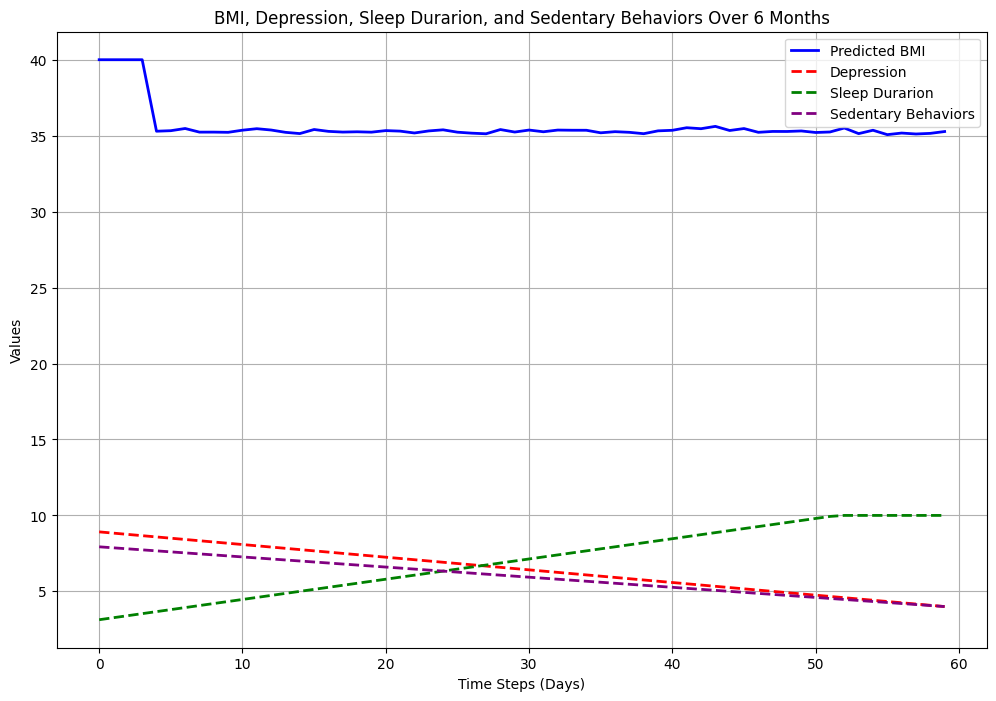

In [ ]:
#@title Prototype II (Agenet-based modeling) (60-day projections)


import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import mesa
import matplotlib.pyplot as plt



# Step 2: Train the RandomForestRegressor model
X = df_obesity
y = df_obesity_labels_1

intervention_predictor = RandomForestRegressor(n_estimators=100, random_state=42)

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include='category'))
)

ABM_model = Pipeline([
    ('preprocessing', preprocessing),
    ('model', intervention_predictor)
])

model = ABM_model.fit(X, y)

depression = df_obesity['Depression_total']
psqi = df_obesity['SLD012'] # Sleep duration (weekdays and weekends)
met = df_obesity['PAD680'] # Minutes sedentary behavior

# Step 3: Define the agent class for the simulation
class BMI_Agent(mesa.Agent):
    """ An agent with depression, psqi, met, and bmi values """

    def __init__(self, unique_id, model, depression, psqi, met, bmi, rf_model):
        super().__init__(unique_id, model)
        self.depression = depression
        self.psqi = psqi
        self.met = met
        self.bmi = bmi  # Start with actual BMI
        self.rf_model = rf_model  # Random Forest model passed to the agent
        self.depression_improvement = (depression - 4) / 60  # Improvement over 60 days
        self.psqi_improvement = (psqi + 5) / 60  # Improvement over 60 days
        self.met_improvement = (met - 4) / 60  # Improvement over 60 days
        self.prediction_started = False  # Flag to start predictions after some steps

    def step(self):
        """ Apply incremental intervention and predict BMI based on the RandomForest model """
        # Apply incremental intervention
        self.depression = max(1, self.depression - self.depression_improvement)
        self.psqi = min(10, self.psqi + self.psqi_improvement)
        self.met = max(1, self.met - self.met_improvement)

        if self.prediction_started:
        # Step 1: Create a placeholder DataFrame with all 80 features
           feature_values = {col: 0 for col in df_obesity.columns}  # Default all features to 0
           feature_values["Depression_total"] = self.depression
           feature_values["SLD012"] = self.psqi
           feature_values["PAD680"] = self.met

        # Log updated values for debugging
           print(f"Step {self.model.schedule.steps}: Depression={self.depression}, PSQI={self.psqi}, MET={self.met}")

           features_df = pd.DataFrame([feature_values])  # Convert to DataFrame

        # Step 2: Apply the preprocessing step
           features_transformed = self.rf_model.named_steps['preprocessing'].transform(features_df)

        # Step 3: Predict BMI using the trained model
           predicted_bmi = self.rf_model.named_steps['model'].predict(features_transformed)[0]

        # Step 4: Add small noise for smooth predictions
           noise = np.random.normal(0, 0.1)
           self.bmi = predicted_bmi + noise

        # Log BMI predictions for debugging
           print(f"Predicted BMI: {predicted_bmi}, Updated BMI: {self.bmi}")

        else:
           # Start prediction after 10 steps
           if self.model.schedule.steps >= 3:
               self.prediction_started = True



# Step 4: Define the model class
class ObesityModel(mesa.Model):
    """ A model with a single agent to simulate BMI changes over time """

    def __init__(self, N, rf_model):
        self.num_agents = N
        self.schedule = mesa.time.RandomActivation(self)
        self.grid = mesa.space.MultiGrid(1, 1, True)

        # Create the agent(s) with the provided initial characteristics
        self.agent = BMI_Agent(1, self, depression=9, psqi=3, met=8, bmi=40, rf_model=rf_model)
        self.schedule.add(self.agent)

        # Lists to store BMI, depression, PSQI, and MET values of the agent over time
        self.bmi_values = []
        self.depression_values = []
        self.psqi_values = []
        self.met_values = []

    def step(self):
        """ Advance the simulation by one step """
        self.schedule.step()

        # Append the values to track over time
        self.bmi_values.append(self.agent.bmi)
        self.depression_values.append(self.agent.depression)
        self.psqi_values.append(self.agent.psqi)
        self.met_values.append(self.agent.met)

# Step 5: Create the model instance and run the simulation
model = ObesityModel(N=1, rf_model=ABM_model)  # Pass the full pipeline

# Simulate for 2 months (approximately 60 time steps)
for _ in range(60):
    model.step()

# Step 6: Visualize the BMI changes and the interventions over time
plt.figure(figsize=(12, 8))

# Plotting BMI values
plt.plot(range(60), model.bmi_values, label="Predicted BMI", color='blue', linewidth=2)

# Plotting depression values
plt.plot(range(60), model.depression_values, label="Depression", color='red', linestyle='--', linewidth=2)

# Plotting PSQI values (Sleep Quality)
plt.plot(range(60), model.psqi_values, label="Sleep Durarion", color='green', linestyle='--', linewidth=2)

# Plotting MET values (Physical Activity)
plt.plot(range(60), model.met_values, label="Sedentary Behaviors", color='purple', linestyle='--', linewidth=2)

# Add labels and title
plt.xlabel('Time Steps (Days)')
plt.ylabel('Values')
plt.title('BMI, Depression, Sleep Durarion, and Sedentary Behaviors Over 6 Months')

# Show legend and grid
plt.legend()
plt.grid(True)

# Show the plot
plt.show()




# LSTM (Simulation)

In [ ]:
#@title Packages and Libraries

!pip install tensorflow scikit-learn
!pip install gradio
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
!pip install tensorflow-gpu


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.0306 - val_loss: 0.4397
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.9479 - val_loss: 0.4789
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0078 - val_loss: 0.4190
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9609 - val_loss: 0.4256
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.8936 - val_loss: 0.6353
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.9353 - val_loss: 0.4679
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9550 - val_loss: 0.5210
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.8717 - val_loss: 0.6210
Epoch 9/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.8110 - val_loss: 1.0052
Epoch 10/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.8287 - val_loss: 0.5290
Epoch 11/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.7598 - val_loss: 0.3980
Epoch 12/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 

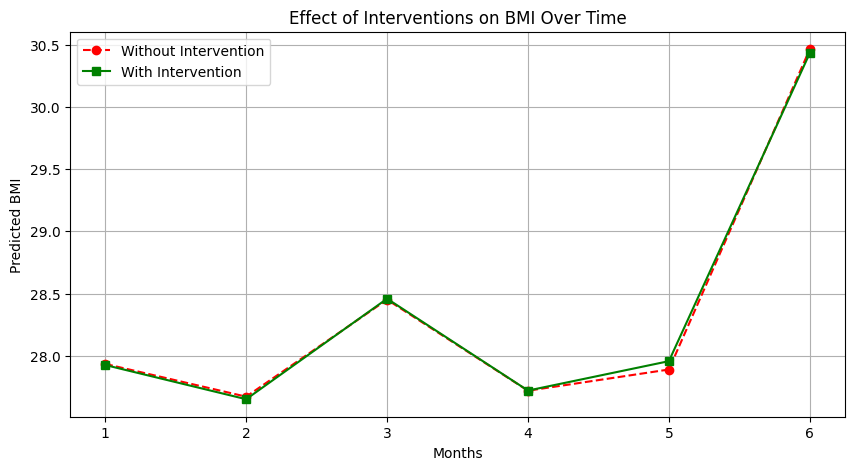

In [ ]:
#@title Long Short-term Memory (LTSM) (Simulation)

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt

X = df_final
y = df_obesity_labels_1
# Apply preprocessing pipeline to the dataset
X_preprocessed = preprocessing.fit_transform(X)

# Standardize the target variable
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Convert dataset into sequences for LSTM
def create_sequences(data_X, data_y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(data_X) - seq_length):  # Ensure index remains valid
        X_seq.append(data_X[i:i + seq_length])
        y_seq.append(data_y[i + seq_length] if i + seq_length < len(data_y) else data_y[-1])  # Prevent out-of-bounds error
    return np.array(X_seq), np.array(y_seq)

# Define sequence length (6 months)
seq_length = 6
X_seq, y_seq = create_sequences(X_preprocessed, y_scaled, seq_length)

# Split into train and test sets
split_idx = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

# Define LSTM model
model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(seq_length, X_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Select a random individual from the dataset
random_idx = np.random.randint(len(X_test))
individual = X_test[random_idx]

# Simulate BMI predictions over 6 months
n_months = 6
bmi_predictions_without_intervention = []
bmi_predictions_with_intervention = []

for month in range(n_months):
    predicted_bmi_no_intervention = model.predict(individual.reshape(1, seq_length, -1)).flatten()[0]

    # Apply interventions
    modified_individual = individual.copy()
    modified_individual[:, 0] *= 0.90  # Reduce depression by 10%
    modified_individual[:, 1] *= 1.05  # Increase sleep duration by 5%
    modified_individual[:, 2] *= 0.90  # Reduce sedentary time by 10%

    predicted_bmi_with_intervention = model.predict(modified_individual.reshape(1, seq_length, -1)).flatten()[0]

    bmi_predictions_without_intervention.append(predicted_bmi_no_intervention)
    bmi_predictions_with_intervention.append(predicted_bmi_with_intervention)

    # Shift sequences
    individual = np.vstack((individual[1:], np.hstack((individual[-1, :-1], [predicted_bmi_no_intervention]))))
    modified_individual = np.vstack((modified_individual[1:], np.hstack((modified_individual[-1, :-1], [predicted_bmi_with_intervention]))))

# Convert BMI predictions back to original scale
bmi_predictions_without_intervention = scaler_y.inverse_transform(np.array(bmi_predictions_without_intervention).reshape(-1, 1)).flatten()
bmi_predictions_with_intervention = scaler_y.inverse_transform(np.array(bmi_predictions_with_intervention).reshape(-1, 1)).flatten()

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_months + 1), bmi_predictions_without_intervention, label="Without Intervention", linestyle='--', marker='o', color='red')
plt.plot(range(1, n_months + 1), bmi_predictions_with_intervention, label="With Intervention", linestyle='-', marker='s', color='green')
plt.xlabel("Months")
plt.ylabel("Predicted BMI")
plt.title("Effect of Interventions on BMI Over Time")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
#@title Long Short-term Memory (LTSM) (Exemplery Patient-Without specified BMI)

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import matplotlib.pyplot as plt

X = df_final
y = df_obesity_labels_1
# Apply preprocessing pipeline to the dataset
X_preprocessed = preprocessing.fit_transform(X)

# Standardize the target variable
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Convert dataset into sequences for LSTM
def create_sequences(data_X, data_y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(data_X) - seq_length):  # Ensure index remains valid
        X_seq.append(data_X[i:i + seq_length])
        y_seq.append(data_y[i + seq_length] if i + seq_length < len(data_y) else data_y[-1])  # Prevent out-of-bounds error
    return np.array(X_seq), np.array(y_seq)

# Define sequence length (6 months)
seq_length = 6
X_seq, y_seq = create_sequences(X_preprocessed, y_scaled, seq_length)

# Split into train and test sets
split_idx = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

# Define LSTM model
model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(seq_length, X_seq.shape[2])),
    Dropout(0.2),
    LSTM(32, activation='relu', return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


# Define the characteristics of the specific individual
# Example: depression = 8, sleep = 5, sedentary behavior (sed) = 6
individual_characteristics = np.array([[8, 5, 6]])

# Pad the individual data to match the number of features used by the model

padded_individual = np.zeros((1, 252))  # Create an array with 84 features
padded_individual[:, :3] = individual_characteristics  # Fill the first 3 features with the individual data

# Create a sequence by repeating the individual’s data to match the LSTM input sequence length
individual_sequence = np.tile(padded_individual, (seq_length, 1))  # Repeat the individual's data to form a sequence
individual_sequence = individual_sequence.reshape(1, seq_length, 252)  # Reshape to match LSTM input (1, 6, 252)

# Simulate BMI predictions for this specific individual without any intervention
bmi_predictions_without_intervention = []
bmi_predictions_with_intervention = []

for month in range(n_months):
    # Predict BMI without intervention
    predicted_bmi_no_intervention = model.predict(individual_sequence).flatten()[0]

    # Apply interventions
    modified_individual = individual_sequence.copy()
    modified_individual[:, 0, 0] *= 0.90  # Reduce depression by 10%
    modified_individual[:, 0, 1] *= 1.05  # Increase sleep duration by 5%
    modified_individual[:, 0, 2] *= 0.90  # Reduce sedentary time by 10%

    # Predict BMI with intervention
    predicted_bmi_with_intervention = model.predict(modified_individual).flatten()[0]

    bmi_predictions_without_intervention.append(predicted_bmi_no_intervention)
    bmi_predictions_with_intervention.append(predicted_bmi_with_intervention)

    # Shift sequences
    individual_sequence = np.vstack((individual_sequence[0][1:], np.hstack((individual_sequence[0][-1, :-1], [predicted_bmi_no_intervention]))))
    individual_sequence = individual_sequence.reshape(1, seq_length, 252)

    modified_individual = np.vstack((modified_individual[0][1:], np.hstack((modified_individual[0][-1, :-1], [predicted_bmi_with_intervention]))))
    modified_individual = modified_individual.reshape(1, seq_length, 252)

# Convert BMI predictions back to the original scale
bmi_predictions_without_intervention = scaler_y.inverse_transform(np.array(bmi_predictions_without_intervention).reshape(-1, 1)).flatten()
bmi_predictions_with_intervention = scaler_y.inverse_transform(np.array(bmi_predictions_with_intervention).reshape(-1, 1)).flatten()

# Plot results
plt.figure(figsize=(10, 5))
plt.plot(range(1, n_months + 1), bmi_predictions_without_intervention, label="Without Intervention", linestyle='--', marker='o', color='red')
plt.plot(range(1, n_months + 1), bmi_predictions_with_intervention, label="With Intervention", linestyle='-', marker='s', color='green')
plt.xlabel("Months")
plt.ylabel("Predicted BMI")
plt.title("Effect of Interventions on BMI Over Time for Specific Individual")
plt.legend()
plt.grid(True)
plt.show()


Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.9826 - val_loss: 0.6101
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9712 - val_loss: 0.5506
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.9645 - val_loss: 0.5769
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.9527 - val_loss: 0.6776
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.9337 - val_loss: 0.6811
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.9002 - val_loss: 0.6580
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.8558 - val_loss: 0.5640
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.7944 - val_loss: 0.6498
Epoch 9/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.7333 - val_loss: 0.7289
Epoch 10/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.6570 - val_loss: 1.0249
Epoch 11/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.5816 - val_loss: 1.0326
Epoch 12/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


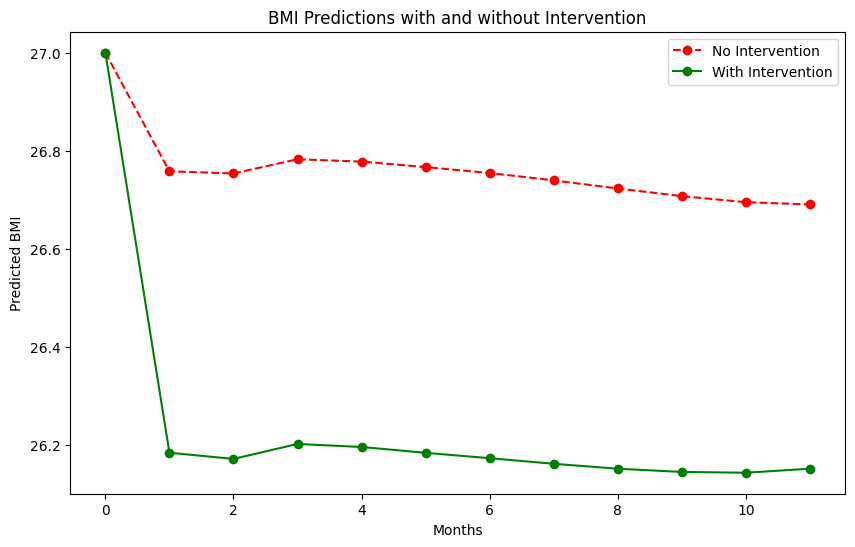

In [ ]:
#@title Long Short-term Memory (LTSM) (Exemplery Patient-With specified BMI)


import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import layers, models, initializers
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.losses import MeanSquaredError
import matplotlib.pyplot as plt
import joblib
import random
import os

# 🌱 Set a fixed seed for reproducibility
# Set random seeds
os.environ['PYTHONHASHSEED'] = '0'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Ensure deterministic operations in TensorFlow
os.environ['TF_DETERMINISTIC_OPS'] = '1'



# Load preprocessed data
X = df_final
y = df_obesity_labels_1

preprocessing = make_column_transformer(
    (num_pipeline, make_column_selector(dtype_include=np.number)),
    (cat_pipeline, make_column_selector(dtype_include='category'))
)

LTSM_model = Pipeline([
    ('preprocessing', preprocessing)
])

# Load or create a preprocessing pipeline

X_preprocessed = preprocessing.fit_transform(X)

# Standardize the target variable
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1))

# Convert dataset into sequences for LSTM
def create_sequences(data_X, data_y, seq_length, initial_bmi):
    X_seq, y_seq = [], []
    for i in range(len(data_X) - seq_length + 1):  # Ensure valid index
        sequence_with_bmi = np.hstack((np.full((seq_length, 1), initial_bmi), data_X[i:i + seq_length]))
        X_seq.append(sequence_with_bmi)
        y_seq.append(data_y[min(i + seq_length, len(data_y) - 1)])  # Safe indexing

    return np.array(X_seq), np.array(y_seq)

# Define parameters
seq_length = 10  # Sequence length
initial_bmi = 27  # Example initial BMI

# Create sequences
X_seq, y_seq = create_sequences(X_preprocessed, y_scaled, seq_length, initial_bmi)

# Split into train and test sets
split_idx = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

# Define LSTM model

model = models.Sequential([
    layers.LSTM(64, kernel_initializer=initializers.glorot_uniform(seed=42), return_sequences=True),
    layers.LSTM(32, kernel_initializer=initializers.glorot_uniform(seed=42)),
    layers.Dense(1, kernel_initializer=initializers.glorot_uniform(seed=42))
])

# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Save trained model and scalers
model.save("bmi_lstm_model.h5")
joblib.dump(y_scaler, "y_scaler.pkl")

# 🎯 Load model and scalers for prediction
model = tf.keras.models.load_model("bmi_lstm_model.h5",
                                   custom_objects={'mse': MeanSquaredError()})  # Explicitly define MSE
y_scaler = joblib.load("y_scaler.pkl")

# Define individual characteristics
individual_characteristics = np.array([[8, 5, 6]], dtype=np.float64)  # Depression, Sleep, Sedentary

# 🚀 Create the input sequence (Initial BMI + Risk Factors)
individual_sequence_with_bmi = np.hstack((
    np.full((seq_length, 1), initial_bmi),
    np.tile(individual_characteristics, (seq_length, 1))
))

# 🛠️ Pad to match the required input size
padded_sequence = np.zeros((seq_length, X_seq.shape[2]))
padded_sequence[:, :individual_sequence_with_bmi.shape[1]] = individual_sequence_with_bmi

# 🔄 Predict BMI at the initial step
predicted_bmi = model.predict(padded_sequence.reshape(1, seq_length, -1)).flatten()[0]
predicted_bmi = y_scaler.inverse_transform([[predicted_bmi]])[0, 0]  # Convert back to original scale

# 🔄 Store predictions
bmi_predictions_without_intervention = [initial_bmi]
bmi_predictions_with_intervention = [initial_bmi]

# Simulate BMI predictions over time
n_months = 12  # Number of months
for _ in range(n_months - 1):
    predicted_bmi_no_intervention = model.predict(padded_sequence.reshape(1, seq_length, -1)).flatten()[0]
    predicted_bmi_no_intervention = y_scaler.inverse_transform([[predicted_bmi_no_intervention]])[0, 0]

    # 🛠️ Apply intervention
    modified_sequence = padded_sequence.copy()
    modified_sequence[:, 1] *= 0.90  # Reduce depression
    modified_sequence[:, 2] *= 1.05  # Increase sleep
    modified_sequence[:, 3] *= 0.90  # Reduce sedentary

    predicted_bmi_with_intervention = model.predict(modified_sequence.reshape(1, seq_length, -1)).flatten()[0]
    predicted_bmi_with_intervention = y_scaler.inverse_transform([[predicted_bmi_with_intervention]])[0, 0]

    # 📌 Store predictions
    bmi_predictions_without_intervention.append(predicted_bmi_no_intervention)
    bmi_predictions_with_intervention.append(predicted_bmi_with_intervention)

    # 🔄 Update sequences
    new_row_no_intervention = np.zeros((1, X_seq.shape[2]))
    new_row_no_intervention[0, 0] = predicted_bmi_no_intervention
    new_row_no_intervention[0, 1:4] = individual_characteristics.flatten()

    new_row_with_intervention = np.zeros((1, X_seq.shape[2]))
    new_row_with_intervention[0, 0] = predicted_bmi_with_intervention
    new_row_with_intervention[0, 1:4] = individual_characteristics.flatten()

    padded_sequence = np.vstack((padded_sequence[1:], new_row_no_intervention))
    modified_sequence = np.vstack((modified_sequence[1:], new_row_with_intervention))

# 📈 Plot results
plt.figure(figsize=(10, 6))
plt.plot(range(n_months), bmi_predictions_without_intervention, label="No Intervention", color="red", linestyle="--", marker="o")
plt.plot(range(n_months), bmi_predictions_with_intervention, label="With Intervention", color="green", linestyle="-", marker="o")
plt.xlabel("Months")
plt.ylabel("Predicted BMI")
plt.title("BMI Predictions with and without Intervention")
plt.legend()
plt.show()


In [ ]:
#@title BMI prediction UI (Gradio - Prototype I)


import gradio as gr
import numpy as np
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
from tensorflow.keras.losses import MeanSquaredError
import io as io

# Load trained model and scalers
custom_objects = {"mse": MeanSquaredError()}

model = tf.keras.models.load_model("bmi_lstm_model.h5", custom_objects={'mse': MeanSquaredError()})
y_scaler = joblib.load("y_scaler.pkl")

# Define parameters
seq_length = 10  # Sequence length
initial_bmi = 27  # Example initial BMI
n_months = 12  # Prediction duration
num_features = 253




# Prediction function
def predict_bmi(depression, sleep_hours, sedentary):
    individual_characteristics = np.array([[depression, sleep_hours, sedentary]], dtype=np.float32)
    individual_sequence_with_bmi = np.hstack((
        np.full((seq_length, 1), initial_bmi),
        np.tile(individual_characteristics, (seq_length, 1))
    ))
    padded_sequence = np.pad(individual_sequence_with_bmi, ((0, 0), (0, num_features - individual_sequence_with_bmi.shape[1])), mode='constant')
    padded_sequence[:, :individual_sequence_with_bmi.shape[1]] = individual_sequence_with_bmi

    bmi_predictions_without_intervention = [initial_bmi]
    bmi_predictions_with_intervention = [initial_bmi]

    for _ in range(n_months - 1):
        predicted_bmi_no_intervention = model.predict(padded_sequence.reshape(1, seq_length, -1)).flatten()[0]
        predicted_bmi_no_intervention = y_scaler.inverse_transform([[predicted_bmi_no_intervention]])[0, 0]

        modified_sequence = padded_sequence.copy()
        modified_sequence[:, 1] *= 0.90  # Reduce depression
        modified_sequence[:, 2] *= 1.05  # Increase sleep
        modified_sequence[:, 3] *= 0.90  # Reduce sedentary

        predicted_bmi_with_intervention = model.predict(modified_sequence.reshape(1, seq_length, -1)).flatten()[0]
        predicted_bmi_with_intervention = y_scaler.inverse_transform([[predicted_bmi_with_intervention]])[0, 0]

        bmi_predictions_without_intervention.append(predicted_bmi_no_intervention)
        bmi_predictions_with_intervention.append(predicted_bmi_with_intervention)

        new_row_no_intervention = np.zeros((1, padded_sequence.shape[1]))
        new_row_no_intervention[0, 0] = predicted_bmi_no_intervention
        new_row_no_intervention[0, 1:4] = individual_characteristics.flatten()

        new_row_with_intervention = np.zeros((1, modified_sequence.shape[1]))
        new_row_with_intervention[0, 0] = predicted_bmi_with_intervention
        new_row_with_intervention[0, 1:4] = individual_characteristics.flatten()

        padded_sequence = np.vstack((padded_sequence[1:], new_row_no_intervention))
        modified_sequence = np.vstack((modified_sequence[1:], new_row_with_intervention))

    # Plot results
    plt.figure(figsize=(8, 5))
    plt.plot(range(n_months), bmi_predictions_without_intervention, label="No Intervention", color="red", linestyle="--", marker="o")
    plt.plot(range(n_months), bmi_predictions_with_intervention, label="With Intervention", color="green", linestyle="-", marker="o")
    plt.xlabel("Months")
    plt.ylabel("Predicted BMI")
    plt.title("BMI Predictions with and without Intervention")
    plt.legend()
    plt.grid()
    plt.savefig("bmi_plot.png")  # Save for local use
    buf = io.BytesIO()
    plt.savefig(buf, format="png")  # Save to memory buffer
    buf.seek(0)

    return plt

    return "bmi_plot.png"

# Create Gradio UI
iface = gr.Interface(
    fn=predict_bmi,
    inputs=[
        gr.Slider(1, 10, step=1, label="Depression (Score)"),
        gr.Slider(4, 10, step=0.5, label="Sleep (Hours)"),
        gr.Slider(1, 10, step=1, label="Sedentary Behavior (Hours)"),
    ],
    outputs=gr.Plot(),
    title="BMI Prediction Model",
    description="Enter your depression, sleep, and sedentary behavior scores to predict your BMI trends with and without intervention."
)

# Launch UI
iface.launch(show_error = True)


Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://cddd42a615a71df1a4.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
#@title BMI prediction UI (Gradio - Prototype II)


import gradio as gr
import numpy as np
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt
import io

# Load trained model and scalers
from tensorflow.keras.losses import MeanSquaredError

model = tf.keras.models.load_model("bmi_lstm_model.h5", custom_objects={'mse': MeanSquaredError()})
y_scaler = joblib.load("y_scaler.pkl")

# Define parameters
seq_length = 10  # Sequence length
initial_bmi = 27  # Example initial BMI
n_months = 12  # Prediction duration
num_features = 253

# Prediction function
def predict_bmi(depression, sleep_hours, sedentary, apply_intervention):
    individual_characteristics = np.array([[depression, sleep_hours, sedentary]], dtype=np.float32)
    individual_sequence_with_bmi = np.hstack((
        np.full((seq_length, 1), initial_bmi),
        np.tile(individual_characteristics, (seq_length, 1))
    ))
    padded_sequence = np.pad(individual_sequence_with_bmi, ((0, 0), (0, num_features - individual_sequence_with_bmi.shape[1])), mode='constant')
    padded_sequence[:, :individual_sequence_with_bmi.shape[1]] = individual_sequence_with_bmi

    bmi_predictions = [initial_bmi]

    for _ in range(n_months - 1):
        predicted_bmi = model.predict(padded_sequence.reshape(1, seq_length, -1)).flatten()[0]
        predicted_bmi = y_scaler.inverse_transform([[predicted_bmi]])[0, 0]

        if apply_intervention:
            padded_sequence[:, 1] *= 0.90  # Reduce depression
            padded_sequence[:, 2] *= 1.05  # Increase sleep
            padded_sequence[:, 3] *= 0.90  # Reduce sedentary

        bmi_predictions.append(predicted_bmi)

        new_row = np.zeros((1, padded_sequence.shape[1]))
        new_row[0, 0] = predicted_bmi
        new_row[0, 1:4] = individual_characteristics.flatten()

        padded_sequence = np.vstack((padded_sequence[1:], new_row))

    # Plot results dynamically
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(n_months), bmi_predictions, label="Predicted BMI", color="blue", marker="o")
    ax.set_xlabel("Months")
    ax.set_ylabel("Predicted BMI")
    ax.set_title("BMI Prediction with Intervention" if apply_intervention else "BMI Prediction without Intervention")
    ax.legend()
    ax.grid()

    return fig

# Create Gradio UI
iface = gr.Interface(
    fn=predict_bmi,
    inputs=[
        gr.Slider(0, 10, value=5, label="Depression Score"),
        gr.Slider(3, 12, value=7, label="Sleep Duration (hrs)"),
        gr.Slider(0, 20, value=50, label="Sedentary Behavior"),
        gr.Checkbox(label="Apply Intervention")
    ],
    outputs=gr.Plot(),
    live=True,  # Enables dynamic updates
    title="BMI Prediction Model",
    description="Adjust the sliders and select whether to apply an intervention to see the predicted BMI trends."
)

# Launch UI
iface.launch(show_error=True)

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://76f934ceaf51e33d3b.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Saving the files

In [ ]:
# @title Saving the datasets

#%% Saving the files (Separately as for one-day and two-day dietary data)
# save_dataset_excel(df_modified_excl, '/content/drive/MyDrive/2017-prepand NHANES datasets/Modified Dataset(1-day).xlsx')
# save_dataset_excel(df_modified_excl, '/content/drive/MyDrive/2017-prepand NHANES datasets/Modified Dataset(2-days).xlsx')
# save_dataset_excel(modified_df_hei, '/content/drive/MyDrive/2017-prepand NHANES datasets/Modified Dataset (HEI_comp)(2-days).xlsx')
# save_dataset_excel(modified_df_5, '/content/drive/MyDrive/2017-prepand NHANES datasets/Modified Dataset (Final exclusion).xlsx')